# EDA 04 (Previous Application)

## Resumen

`previous_application` recoge 1.670.214 solicitudes previas al propio prestamista, 37 columnas y 338.857 clientes. Enlaza directamente por `SK_ID_CURR`, sin tabla puente, y cubre el 94,65% de train, la cobertura más alta de las tres tablas auxiliares: 291.057 clientes tienen alguna solicitud y 16.454 no tienen ninguna.

Esa ausencia tiene el signo contrario al del buró, y eso gobierna toda la lectura. Quien nunca ha pedido nada aquí da 5,96% de default frente al 8,19% de quien sí, cuando no constar en el buró daba 10,12%. No son la misma ausencia ni miden lo mismo: una es opacidad y la otra es no haber necesitado esta financiación. Tampoco se solapan, con V de Cramér de 0,0047 y solo 2.470 clientes (0,80%) sin rastro en ninguna de las dos fuentes, así que las dos banderas se conservan. La consecuencia práctica es que rellenar con cero a quien no aparece sienta a un grupo de menor riesgo en el extremo bajo de cada variable, de modo que infla lo que penaliza en lugar de enmascararlo, y toda medición va condicionada a tener alguna solicitud.

Lo que aporta esta tabla, y no aporta ninguna otra fuente, es qué contestó esta casa: si concedió, cuánto sobre lo pedido, a qué precio y por qué dijo que no. Las cuatro señales de cabeza son proporciones entre cifras del contrato y ninguna es una magnitud. Lo concedido frente a lo pedido rinde 0,1458 y ordena el riesgo del 6,45% de quien de media recibe menos de lo que solicita al 16,00% de quien recibe más de un 30% de más; detrás van el coste implícito medio con 0,1334, la proporción de rechazos con 0,1204 (del 7,07% al 17,79%) y la sobreconcesión con 0,1194. Medido por solicitud, ninguna de las nueve magnitudes alcanzaba 0,09 y en la cola de lo solicitado el importe grande describía al cliente solvente: el tamaño de la operación no es el riesgo, lo es la relación entre lo que se pide, lo que se concede y lo que se acaba devolviendo.

De las 28 variables de cliente conservo 20. Con las cuatro de cabeza entran el ritmo de solicitudes por año (0,1149, más de cinco veces lo que rinde el conteo bruto), la longitud de relación (0,1129) acompañada siempre de la marca de historial recortado, la captación en la calle (0,0924, que fuera de ventana reciente no dice nada), lo que queda por vencer como magnitud (0,0842), la entrada media (0,0811) y el plazo medio pactado (0,0810). En las banderas la señal vive en lo raro y severo, que es lo que no quiero perder: pedir más de 60 cuotas y no obtenerlas vale +13,61pp sobre 78 clientes y el registro que no llegó a definirse ni en tipo ni en producto +11,54pp sobre 284, las dos con impacto de cartera mínimo. La única protectora es el historial recortado, con -3,06pp, y su lectura importa más que su cifra: el cliente de relación larga (5,70%) se comporta como quien nunca ha pasado por aquí (5,96%), así que no es que ver menos historial proteja, es que llevar años siendo cliente protege. La codificación pesa tanto como el efecto, y el ejemplo es el motivo del rechazo: contado está a cero en el 97,67% de los clientes y ahí los empates hunden el rank-biserial hasta 0,0351, mientras que como bandera y medido dentro de quien acumula algún rechazo vale +9,83pp, y hasta +12,23pp en el tramo alto de conteo.

Los descartes conviene separarlos por firmeza. Firmes y target-independientes los tres de redundancia estructural: el máximo del coste contra su media (0,8616), y el conteo y la proporción de liquidación anticipada contra su bandera (0,8586 y 0,8539), que rinde +2,19pp frente a sus 0,0446 y 0,0477. Otras tres bajan a denominador o a fuente de otra, entre ellas la actividad de los últimos doce meses, que solapa 0,6702 con el ritmo de solicitudes por año y desaparece dentro de sus estratos, quedándose como el material de su propia bandera; esa bandera sí se conserva, pero solo como término de la interacción con la relación larga, que es lo único que el ritmo no absorbe. Y dos quedan a decidir por capacidad predictiva, la hora temprana (0,0502) y la recencia de la última solicitud (0,0489), provisionales porque dependen del objetivo; la recencia se queda de todos modos como control, porque ni la proporción de rechazos ni las tres de captación se pueden leer sin ella.

Tres límites para leer todo lo anterior. Esta tabla no compite con lo que ya tengo, se suma: el solape máximo de las 28 contra los tres `EXT_SOURCE` y contra lo que conservo del buró es 0,2652, y lo pone la longitud de relación contra la antigüedad del historial del buró, lejos del 0,391 que allí obligó a exigirle a las temporales que demostraran valor por encima del score. Las 28 superan Bonferroni con alfa de 1,79e-03, y eso no acredita a ninguna: con 291.057 clientes hasta el conteo de solicitudes, que rinde 0,0210 y no uso como predictor, sale con p = 5,80e-08, así que quien decide es el tamaño del efecto y el umbral de 2pp. Y todas las tasas están calculadas sobre la cartera completa, de modo que sobre el conjunto de entrenamiento hay que recomputarlas, refijar los cortes medidos aquí (las 15 solicitudes, las 4 en doce meses, el año de adelanto, las 60 cuotas y el 1,1 de sobreconcesión) y resolver el mínimo de denominador de la proporción de rechazos, que es una disyuntiva ya medida entre 0,1204 cubriendo a todos y 0,1558 cubriendo al 81,95%.

### Índice

- 1. Carga
- 2. Distribución variable marco (solicitudes por cliente) + cruce con `TARGET`
- 3. Verificación dtypes / Clasificación variables
- 4. Análisis distribuciones variables
- 5. Análisis Missings
- 6. Análisis Correlaciones
- 7. Análisis Temporal
- 8. Análisis de Outliers
- 9. Estrategia de agregación (nivel cliente)
- 10. Validación por bloques (`TARGET` real)
- 11. Conclusiones y features candidatas

In [1]:
import re
import sys
from itertools import combinations
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (chi2_contingency, fisher_exact, mannwhitneyu, norm,
                         pearsonr, spearmanr)

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_table, verify_dtypes
from src.features.eval import EvaluadorSenal

COLOR_NODEF, COLOR_DEF = "steelblue", "crimson"

### 1. Carga

In [2]:
prev = load_table("previous_application")
train = load_table("application_train").copy()  # copia: el ajuste de tipos deja el frame fragmentado

prev.info(memory_usage="deep")
prev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   SK_ID_PREV                   1670214 non-null  uint32  
 1   SK_ID_CURR                   1670214 non-null  uint32  
 2   NAME_CONTRACT_TYPE           1670214 non-null  category
 3   AMT_ANNUITY                  1297979 non-null  float32 
 4   AMT_APPLICATION              1670214 non-null  float32 
 5   AMT_CREDIT                   1670213 non-null  float32 
 6   AMT_DOWN_PAYMENT             774370 non-null   float32 
 7   AMT_GOODS_PRICE              1284699 non-null  float32 
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  category
 9   HOUR_APPR_PROCESS_START      1670214 non-null  uint8   
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  category
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  uint8   
 12  RATE_DOWN_PAYMENT           

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430054,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615234,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735352,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335938,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.394531,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# cada fila es una solicitud previa: la clave es SK_ID_PREV, SK_ID_CURR se repite por cliente
assert prev["SK_ID_PREV"].is_unique, "SK_ID_PREV no es identificador único"
print(f"solicitudes: {len(prev):,} | clientes distintos: {prev['SK_ID_CURR'].nunique():,}")
print(f"Integridad: SK_ID_PREV único | duplicados de fila completa: {int(prev.duplicated().sum())}")
print(f"nulos en las claves: {prev[['SK_ID_PREV', 'SK_ID_CURR']].isnull().sum().to_dict()}")

solicitudes: 1,670,214 | clientes distintos: 338,857


Integridad: SK_ID_PREV único | duplicados de fila completa: 0
nulos en las claves: {'SK_ID_PREV': 0, 'SK_ID_CURR': 0}


In [4]:
# la cobertura es directa por SK_ID_CURR: no hay tabla puente ni créditos huérfanos posibles
tiene_prev = train["SK_ID_CURR"].isin(prev["SK_ID_CURR"])
print(f"clientes de train con solicitudes previas: {tiene_prev.sum():,} ({tiene_prev.mean() * 100:.2f}%)")
print(f"clientes de train sin ninguna: {(~tiene_prev).sum():,}")
print(f"solicitudes enlazables a train: {prev['SK_ID_CURR'].isin(train['SK_ID_CURR']).sum():,}")

# en el buró el grupo sin historial era el de más riesgo, aquí espero lo contrario
ev_cli = EvaluadorSenal(train, train["TARGET"])
ev_cli.evaluar_flags([("HAS_PREV_APPLICATION", tiene_prev.astype(int).values, None, "global")])

clientes de train con solicitudes previas: 291,057 (94.65%)
clientes de train sin ninguna: 16,454
solicitudes enlazables a train: 1,413,701


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
HAS_PREV_APPLICATION,global,8.19% (n=291057),5.96% (n=16454),+2.24 pp,10.2,1.2383986890374153e-24


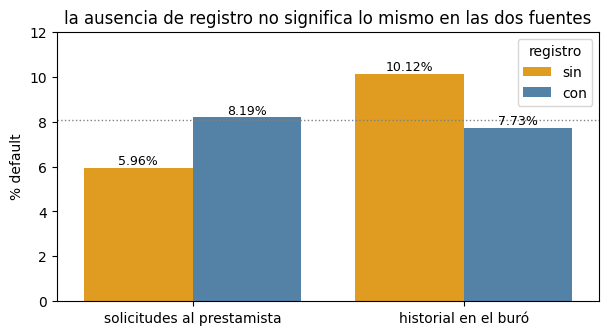

In [5]:
# no tener registro, ¿protege o penaliza? la misma pregunta en las dos fuentes de historial
bureau_ids = load_table("bureau", usecols=["SK_ID_CURR"], reduce_memory=False)["SK_ID_CURR"]
tiene_bureau = train["SK_ID_CURR"].isin(bureau_ids)

comp = pd.DataFrame([
    {"fuente": f, "registro": r, "tasa": train["TARGET"][m if r == "con" else ~m].mean() * 100}
    for f, m in [("solicitudes al prestamista", tiene_prev), ("historial en el buró", tiene_bureau)]
    for r in ("sin", "con")])

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(comp, x="fuente", y="tasa", hue="registro",
            palette={"sin": "orange", "con": COLOR_NODEF}, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=9)
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax.set(xlabel="", ylabel="% default", ylim=(0, 12),
       title="la ausencia de registro no significa lo mismo en las dos fuentes")
plt.show()

In [6]:
# ¿son la misma ausencia? si lo fueran sobraría una de las dos banderas, como pasó con las
# consultas al buró de la solicitud actual, que solapaban un 94,32% con no tener historial
cruce = train.groupby([tiene_bureau, tiene_prev], observed=True)["TARGET"].agg(
    clientes="size", tasa="mean")
cruce["% default"] = (cruce.pop("tasa") * 100).round(2)
cruce.index = cruce.index.set_names(["historial en el buró", "solicitudes previas"])
display(cruce)

v = (chi2_contingency(pd.crosstab(tiene_bureau, tiene_prev))[0] / len(train)) ** 0.5
sin_ambas = (~tiene_bureau) & (~tiene_prev)
print(f"V de Cramér entre las dos ausencias: {v:.4f} | clientes sin ninguna de las dos fuentes: "
      f"{sin_ambas.sum():,} ({sin_ambas.mean() * 100:.2f}%), con {train.loc[sin_ambas, 'TARGET'].mean() * 100:.2f}% "
      "de default")

clientes  % default
historial en el buró solicitudes previas                     
False                False                    2470       7.29
                     True                    41550      10.29
True                 False                   13984       5.72
                     True                   249507       7.84

V de Cramér entre las dos ausencias: 0.0047 | clientes sin ninguna de las dos fuentes: 2,470 (0.80%), con 7.29% de default


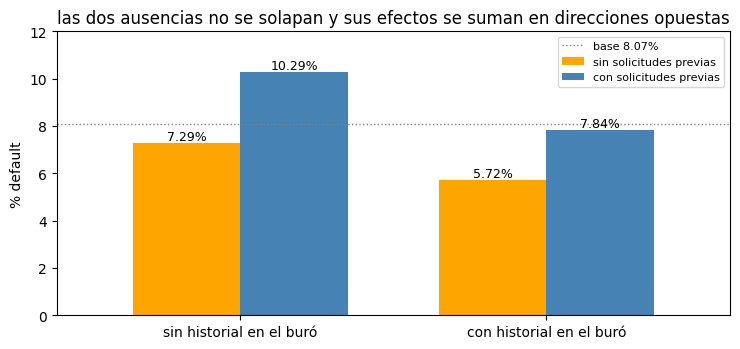

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
tabla = cruce["% default"].unstack()
tabla.index = ["sin historial en el buró", "con historial en el buró"]
tabla.columns = ["sin solicitudes previas", "con solicitudes previas"]
tabla.plot.bar(ax=ax, color=["orange", COLOR_NODEF], rot=0, width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=9)
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1,
           label=f"base {train['TARGET'].mean() * 100:.2f}%")
ax.set(ylabel="% default", xlabel="", ylim=(0, 12),
       title="las dos ausencias no se solapan y sus efectos se suman en direcciones opuestas")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ¿veo todas las solicitudes de cada cliente o solo un tramo? la más antigua lo delata: si en ella
# el cliente ya constaba como recurrente, hubo solicitudes anteriores que no están en la tabla
prev_t = prev[prev["SK_ID_CURR"].isin(train["SK_ID_CURR"])]
primera = prev_t.loc[prev_t.groupby("SK_ID_CURR")["DAYS_DECISION"].idxmin()].copy()
primera["TARGET"] = primera["SK_ID_CURR"].map(train.set_index("SK_ID_CURR")["TARGET"])

# el corte de la ventana: ¿se apilan contra él o se reparten como los nuevos?
t = primera.groupby("NAME_CLIENT_TYPE", observed=True).agg(
    clientes=("SK_ID_CURR", "size"), dias_mediana=("DAYS_DECISION", "median"),
    tasa=("TARGET", "mean"), corte=("DAYS_DECISION", lambda s: (s < -2500).mean()))
t["% de clientes"] = (t["clientes"] / len(primera) * 100).round(2)
t["% default"] = (t.pop("tasa") * 100).round(2)
t["% antes de -2.500 días"] = (t.pop("corte") * 100).round(2)
display(t)

print(f"ventana de la tabla: {prev['DAYS_DECISION'].min()} días ({-prev['DAYS_DECISION'].min() / 365.25:.1f} años)")
# la marca de recorte la voy a usar como control, pero antes compruebo si además discrimina
recortado = (primera.set_index("SK_ID_CURR")["NAME_CLIENT_TYPE"].isin(["Repeater", "Refreshed"])
             .reindex(train["SK_ID_CURR"], fill_value=False).values)
ev_cli.evaluar_flags([("PREV_HISTORIAL_RECORTADO", recortado.astype(int),
                       tiene_prev.values, "con previas")])

dup_contrato = prev["FLAG_LAST_APPL_PER_CONTRACT"].eq("N")
dup_dia = prev["NFLAG_LAST_APPL_IN_DAY"].eq(0)
print(f"registros que no son el último de su contrato: {dup_contrato.sum():,} ({dup_contrato.mean() * 100:.2f}%) | "
      f"que no son el último del día: {dup_dia.sum():,} ({dup_dia.mean() * 100:.2f}%)")

,clientes,dias_mediana,% de clientes,% default,% antes de -2.500 días
NAME_CLIENT_TYPE,,,,,
New,237097,-1320.0,81.46,8.76,14.17
Refreshed,18509,-1348.0,6.36,5.66,5.24
Repeater,35425,-2662.0,12.17,5.71,69.36
XNA,26,-172.0,0.01,3.85,0.00


ventana de la tabla: -2922 días (8.0 años)


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_HISTORIAL_RECORTADO,con previas,5.7% (n=53934),8.76% (n=237123),-3.06 pp,-23.4,2.462813870787095e-121


registros que no son el último de su contrato: 8,475 (0.51%) | que no son el último del día: 5,900 (0.35%)


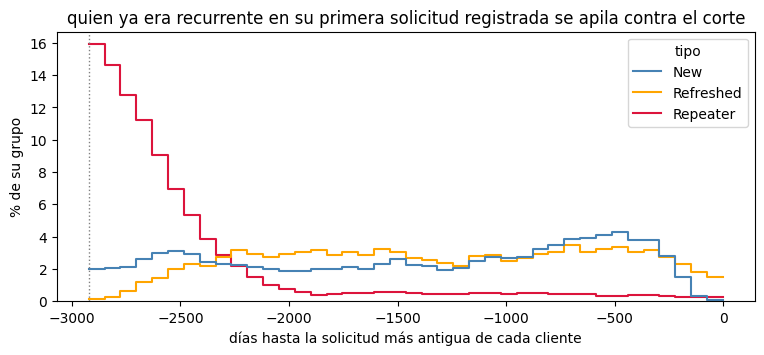

In [9]:
# si el recorte fuese aleatorio, los recurrentes se repartirían como los nuevos: se amontonan en el corte
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(data=primera.assign(tipo=primera["NAME_CLIENT_TYPE"].astype(str)).query("tipo != 'XNA'"),
             x="DAYS_DECISION", hue="tipo", bins=40, stat="percent", common_norm=False,
             element="step", fill=False,
             palette={"New": COLOR_NODEF, "Repeater": COLOR_DEF, "Refreshed": "orange"}, ax=ax)
ax.axvline(prev["DAYS_DECISION"].min(), color="gray", ls=":", lw=1)
ax.set(xlabel="días hasta la solicitud más antigua de cada cliente", ylabel="% de su grupo",
       title="quien ya era recurrente en su primera solicitud registrada se apila contra el corte")
plt.show()

`previous_application` reúne 1.670.214 solicitudes previas al propio prestamista en 37 columnas y
ocupa 146,6 MB con los tipos ya ajustados. `SK_ID_PREV` es identificador único, no hay un solo
duplicado de fila ni un nulo en las claves, así que cada fila es una solicitud distinta. El enlace
con el cliente es directo por `SK_ID_CURR`, sin tabla puente ni registros huérfanos posibles, a
diferencia del histórico mensual del buró, que tenía que apoyarse en `bureau` para saber de quién
era cada crédito.

La cobertura es la más alta de las tablas del buró y de las previas: 291.057 clientes de los 307.511
(94,65%) tienen al menos una solicitud, y solo 16.454 no tienen ninguna. Lo que no esperaba es el
signo. En el buró, no tener historial era el grupo de más riesgo, con 10,12% de default frente al
7,73% de quien sí lo tenía. Aquí ocurre justo lo contrario: quien nunca ha solicitado nada al
prestamista da 5,96%, frente al 8,19% de quien sí lo ha hecho, una diferencia de 2,24pp que penaliza
a quien tiene solicitudes previas (z = 10,2, p = 1,24e-24). Las dos ausencias no significan lo mismo.
La del buró es opacidad, un cliente del que no hay rastro externo; esta es sencillamente un cliente
que llega nuevo al prestamista, y quien ya ha pasado por él lo ha hecho porque necesitaba
financiación. Al agregar por cliente esto tiene una consecuencia que conviene anticipar: rellenar
con cero a los que no aparecen mete un grupo de menor riesgo en el grupo 0 de cada variable, así que
la distorsión irá en dirección contraria a la que vi en el buró, inflando lo que penaliza y
enmascarando lo que protege. Lo mediré global y condicionado en lugar de darlo por bueno.

Antes de seguir quería saber si veo el historial completo de cada cliente o solo un tramo, porque de
eso depende que un cliente sin rechazos lo esté de verdad o solo en la parte que observo. La
solicitud más antigua de cada uno lo delata: si en ella ya constaba como recurrente, hubo otras
anteriores que no están recogidas. Pasa en el 18,53% de los clientes, un 12,17% que ya eran
recurrentes y un 6,36% que venían de refrescar una relación anterior.

No es aleatorio, aunque los dos grupos llegan ahí por caminos distintos y conviene no mezclarlos. El
registro se corta en 8,0 años exactos, porque `DAYS_DECISION` no baja de -2.922, y quien ya era
recurrente se apila contra ese corte: el 69,36% tiene su solicitud más antigua antes de los -2.500
días, con mediana en -2.662 frente a los -1.320 de quienes arrancan como nuevos. Es relación continua
que empezó antes de lo que puedo ver. Quien vuelve tras refrescar la relación no se apila en el
borde, solo el 5,24%, menos incluso que el 14,17% de los propios clientes nuevos, y su mediana está
en -1.348: son clientes que regresan tras un paréntesis largo, de modo que su actividad anterior
también queda fuera pero su primera solicitud visible puede caer en cualquier punto del periodo. En
los dos casos hay historial que no veo, y en los dos el riesgo es menor, 5,71% y 5,66% frente al
8,76% de los nuevos, así que lo que señala es antigüedad de relación y no ocultación.

La consecuencia es acotada pero real. Los conteos absolutos, cuántas solicitudes o cuántos rechazos
acumula un cliente, quedan recortados por abajo justo en los de relación más larga, mientras que las
proporciones y las recencias no sufren ese recorte. Prefiero por tanto los ratios y la recencia antes
que los conteos crudos, y me llevo como control la marca de tener relación anterior a lo que veo,
igual que hice con la ventana de observación del histórico mensual del buró.

Esa marca, que iba a usar solo como control, resulta ser bastante más que eso. Contrastada contra el
objetivo entre los clientes que sí tienen solicitudes previas, tener relación anterior a lo que veo
vale -3,06pp (5,70% frente a 8,76%, z = -23,4), muy por encima del umbral con el que decido y en
sentido protector. Puesta al lado de la cobertura aparece una lectura que ninguna de las dos cifras
da por separado: el cliente de relación larga se comporta casi igual que el que nunca ha pasado por
el prestamista, 5,70% frente a 5,96%, y el riesgo se concentra en el de relación corta y enteramente
visible, con 8,76%. No es que ver menos historial proteja, sería absurdo; es que llevar años siendo
cliente protege, y el recorte de la ventana no es más que la huella que deja esa antigüedad. Entra
por tanto como control y también como candidata.

Queda una salvedad menor sobre qué representa una fila. El 0,51% de los registros no es el último de
su contrato y el 0,35% no es el último de su día, o sea que una misma operación puede aparecer
repetida por reintento o modificación. No rompe la clave, pero implica que contar filas es contar
registros y no contratos distintos. Dejo pendiente para el diseño de la agregación si me quedo solo
con el último registro de cada contrato.

Antes de quedarme con las dos banderas de ausencia había que descartar que fuesen la misma, porque en la solicitud que se evalúa las consultas al buró solapaban un 94,32% con no tener historial y una de las dos sobraba. Aquí no se solapan: la V de Cramér entre las dos ausencias es 0,0047 y solo 2.470 clientes, el 0,80%, faltan a la vez en las dos fuentes. Los cuatro grupos ordenan el riesgo de forma aditiva y con una lectura de negocio limpia. El más seguro es quien tiene historial en el buró y nunca ha pedido nada a este prestamista, con 5,72%; después van los que aparecen en las dos fuentes, con 7,84%, y los que no aparecen en ninguna, con 7,29% sobre una muestra pequeña; y el peor con diferencia es quien no consta en el buró pero sí ha pedido aquí, con 10,29%. Las dos banderas se conservan porque miden cosas distintas: no aparecer en el buró es opacidad, y no haber pedido nunca a este prestamista es no haber necesitado esta financiación.

### 2. Distribución variable marco (solicitudes por cliente) + cruce con `TARGET`

count    307511.00
mean          4.60
std           4.18
min           0.00
25%           2.00
50%           3.00
75%           6.00
90%          10.00
95%          13.00
99%          20.00
max          73.00


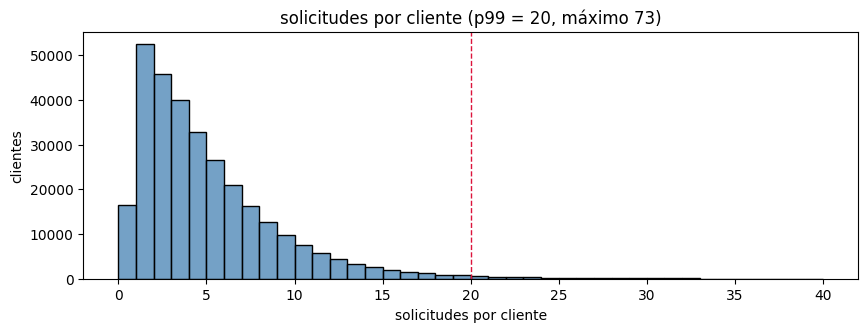

In [10]:
# solicitudes por cliente, contando también a los que no tienen ninguna
train["PREV_APPLICATION_COUNT"] = (prev_t.groupby("SK_ID_CURR").size()
                                   .reindex(train["SK_ID_CURR"], fill_value=0).values)
n_prev = train["PREV_APPLICATION_COUNT"]
print(n_prev.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 3.2))
sns.histplot(n_prev, bins=range(0, 41), color=COLOR_NODEF, ax=ax)
ax.axvline(n_prev.quantile(0.99), color=COLOR_DEF, ls="--", lw=1)
ax.set(xlabel="solicitudes por cliente", ylabel="clientes",
       title=f"solicitudes por cliente (p99 = {n_prev.quantile(0.99):.0f}, máximo {n_prev.max()})")
plt.show()

In [11]:
# ¿más solicitudes es más riesgo?
BINS, ETIQ = [-1, 0, 2, 5, 10, 100], ["0", "1 a 2", "3 a 5", "6 a 10", "11 o más"]
bins_prev = pd.cut(n_prev, BINS, labels=ETIQ)

t = train.groupby(bins_prev, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
t["% de clientes"] = (t["clientes"] / len(train) * 100).round(2)
t["% default"] = (t.pop("tasa") * 100).round(2)
display(t)

con = tiene_prev.values
print(f"solo con previas: Pearson {pearsonr(n_prev[con], train['TARGET'][con])[0]:.4f} | "
      f"Spearman {spearmanr(n_prev[con], train['TARGET'][con])[0]:.4f}")

# el grupo 0 es de menor riesgo, así que la medida global arrastra hacia abajo el tramo bajo
ev_cli.evaluar_continuas([("PREV_APPLICATION_COUNT", True, None, "global (relleno 0)")])

,clientes,% de clientes,% default
PREV_APPLICATION_COUNT,,,
0,16454,5.35,5.96
1 a 2,98332,31.98,8.13
3 a 5,99574,32.38,7.75
6 a 10,67646,22.00,8.28
11 o más,25505,8.29,9.93


solo con previas: Pearson 0.0198 | Spearman 0.0101


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATION_COUNT,global (relleno 0),307511,0.0343,1.517476601597145e-19,3.0,4.0


In [12]:
# la cola se propone como bandera, así que mido el corte en vez de heredarlo del binning
ev_corte = EvaluadorSenal(train, train["TARGET"])  # un barrido de umbral no es una feature
ev_corte.evaluar_flags([(f"corte en {k}", (n_prev >= k).astype(int).values, con, "con previas")
                        for k in (8, 11, 15, 20)])
print("cobertura sobre los que tienen previas: " + " | ".join(
    f"{k} o más {((n_prev >= k) & con).sum() / con.sum() * 100:.2f}%" for k in (8, 11, 15, 20)))

# me quedo con el único corte que cruza el umbral de dos puntos
ev_cli.evaluar_flags([("PREV_COUNT_COLA", (n_prev >= 15).astype(int).values, con, "con previas")])

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
corte en 8,con previas,9.17% (n=55694),7.96% (n=235363),+1.21 pp,9.4,7.380775874612578e-21
corte en 11,con previas,9.93% (n=25505),8.03% (n=265552),+1.91 pp,10.6,2.95638522862237e-26
corte en 15,con previas,11.07% (n=9422),8.1% (n=281635),+2.97 pp,10.4,4.070856406150945e-25
corte en 20,con previas,11.64% (n=3083),8.16% (n=287974),+3.49 pp,7.0,2.123723016484228e-12


cobertura sobre los que tienen previas: 8 o más 19.14% | 11 o más 8.76% | 15 o más 3.24% | 20 o más 1.06%


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_COUNT_COLA,con previas,11.07% (n=9422),8.1% (n=281635),+2.97 pp,10.4,4.070856406150945e-25


In [13]:
# ¿el conteo mide intensidad de relación o antigüedad? los de historial recortado lo separan
t = (train.assign(bin=bins_prev.values, historial=pd.Series(recortado)
                  .map({False: "completo", True: "recortado"}).values)[con]
     .groupby(["historial", "bin"], observed=True)["TARGET"].agg(clientes="size", tasa="mean")
     .reset_index())
t["% default"] = (t.pop("tasa") * 100).round(2)
display(t.pivot(index="bin", columns="historial"))

# la medición válida va la última: el acumulador se queda con ella para el ranking
ev_cli.evaluar_continuas([
    ("PREV_APPLICATION_COUNT", False, con & ~recortado, "historial completo"),
    ("PREV_APPLICATION_COUNT", False, con & recortado, "historial recortado"),
    ("PREV_APPLICATION_COUNT", False, con, "con previas")])

clientes           % default          
historial completo recortado  completo recortado
bin                                             
1 a 2        85355     12977      8.60      5.10
3 a 5        80914     18660      8.30      5.37
6 a 10       52031     15615      8.98      5.92
11 o más     18823      6682     10.89      7.23

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATION_COUNT,historial completo,237123,0.0271,7.17471583606348e-11,3.0,4.0
PREV_APPLICATION_COUNT,historial recortado,53934,0.063,3.6940755480901036e-09,5.0,5.0
PREV_APPLICATION_COUNT,con previas,291057,0.021,5.7987245591027506e-08,4.0,4.0


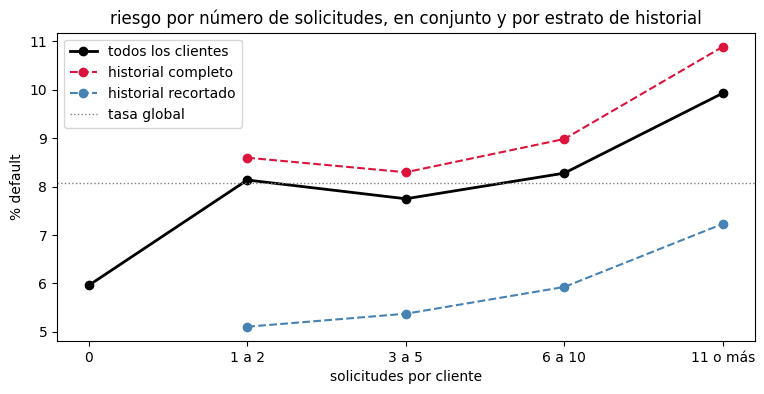

In [14]:
# las tres lecturas en un vistazo: la U, el salto de nivel entre estratos y dónde cae el grupo sin previas
tasa_bin = train.groupby(bins_prev, observed=True)["TARGET"].mean() * 100
tasa_estr = (train.assign(bin=bins_prev.values, historial=recortado)[con]
             .groupby(["historial", "bin"], observed=True)["TARGET"].mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ETIQ, tasa_bin.reindex(ETIQ), "o-", color="black", lw=2, label="todos los clientes")
ax.plot(ETIQ[1:], tasa_estr.xs(False).reindex(ETIQ[1:]), "o--", color=COLOR_DEF,
        label="historial completo")
ax.plot(ETIQ[1:], tasa_estr.xs(True).reindex(ETIQ[1:]), "o--", color=COLOR_NODEF,
        label="historial recortado")
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1, label="tasa global")
ax.set(xlabel="solicitudes por cliente", ylabel="% default",
       title="riesgo por número de solicitudes, en conjunto y por estrato de historial")
ax.legend()
plt.show()

In [15]:
# el conteo está censurado por la izquierda, así que lo normalizo por la ventana que sí observo
ventana = (-prev_t.groupby("SK_ID_CURR")["DAYS_DECISION"].min() / 365.25).clip(lower=0.5)
train["PREV_APPLICATIONS_PER_YEAR"] = n_prev / ventana.reindex(train["SK_ID_CURR"]).values
ev_cli.evaluar_continuas([("PREV_APPLICATIONS_PER_YEAR", False, con, "con previas")])

intensidad = train["PREV_APPLICATIONS_PER_YEAR"]
TRAMOS_INT = ["hasta 0,5", "de 0,5 a 1", "de 1 a 2", "de 2 a 4", "más de 4"]
tramo_int = pd.cut(intensidad, [0, 0.5, 1, 2, 4, 100], labels=TRAMOS_INT)
grad_int = train.groupby(tramo_int, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
grad_int["% default"] = (grad_int.pop("tasa") * 100).round(2)
display(grad_int)

# el extremo de un ratio suele ser ruido de denominador, así que compruebo de qué está hecho
extremo = intensidad > 4
print(f"clientes por encima de 4 solicitudes al año: {int(extremo.sum()):,} | con una sola solicitud: "
      f"{int((extremo & n_prev.eq(1)).sum())} | ventana mediana "
      f"{pd.Series(ventana.reindex(train['SK_ID_CURR']).values)[extremo.values].median():.2f} años")
print(f"no es la recencia con otro nombre: Pearson {intensidad.corr(train['SK_ID_CURR'].map(prev_t.groupby('SK_ID_CURR')['DAYS_DECISION'].max())):.4f} "
      f"con la última solicitud | {pearsonr(intensidad[con], n_prev[con])[0]:.4f} con el conteo bruto")

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATIONS_PER_YEAR,con previas,291057,0.1149,1.3959601637940034e-190,1.0,1.2


,clientes,% default
PREV_APPLICATIONS_PER_YEAR,,
"hasta 0,5",52201,7.12
"de 0,5 a 1",87741,6.84
de 1 a 2,91161,8.09
de 2 a 4,44624,10.30
más de 4,15330,14.10


clientes por encima de 4 solicitudes al año: 15,330 | con una sola solicitud: 0 | ventana mediana 1.47 años
no es la recencia con otro nombre: Pearson 0.3825 con la última solicitud | 0.5253 con el conteo bruto


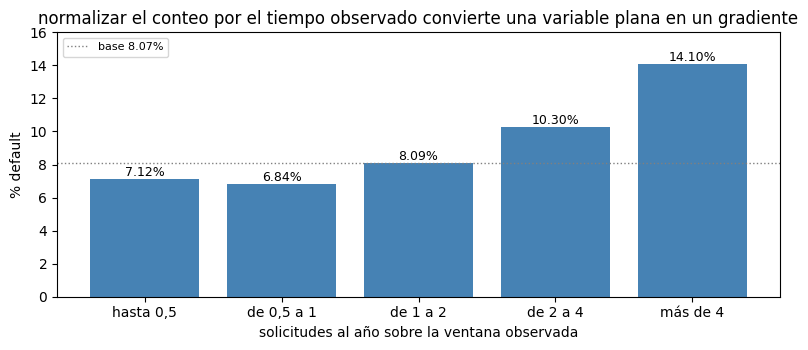

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(grad_int.index.astype(str), grad_int["% default"], color=COLOR_NODEF)
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=9)
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1,
           label=f"base {train['TARGET'].mean() * 100:.2f}%")
ax.set(ylabel="% default", xlabel="solicitudes al año sobre la ventana observada", ylim=(0, 16),
       title="normalizar el conteo por el tiempo observado convierte una variable plana en un gradiente")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# contar filas no es contar contratos: ¿cambia algo quedarse solo con el último registro de cada uno?
n_contr = (prev_t[prev_t["FLAG_LAST_APPL_PER_CONTRACT"].eq("Y")].groupby("SK_ID_CURR").size()
           .reindex(train["SK_ID_CURR"], fill_value=0).values)
por_bin = train.groupby(bins_prev, observed=True)["TARGET"]
comp = pd.DataFrame({
    "clientes": por_bin.size(),
    "% default (registros)": por_bin.mean() * 100,
    "% default (contratos)": (train.groupby(pd.cut(n_contr, BINS, labels=ETIQ), observed=True)["TARGET"]
                              .mean() * 100),
}).round(2)
display(comp)
cambia = n_prev.values != n_contr
print(f"clientes cuyo conteo cambia: {cambia.sum():,} ({cambia.mean() * 100:.2f}%) | "
      f"Pearson entre las dos versiones: {pearsonr(n_prev, n_contr)[0]:.4f}")

,clientes,% default (registros),% default (contratos)
0,16454,5.96,5.96
1 a 2,98332,8.13,8.14
3 a 5,99574,7.75,7.75
6 a 10,67646,8.28,8.27
11 o más,25505,9.93,9.94


clientes cuyo conteo cambia: 5,022 (1.63%) | Pearson entre las dos versiones: 0.9985


Lo primero que quiero saber de una tabla con varias filas por cliente es cuántas acumula cada uno. La
distribución es asimétrica y con cola larga: media de 4,60 solicitudes, mediana de 3, percentil 75 en
6, percentil 99 en 20 y un máximo de 73, del mismo orden que el máximo de 116 créditos que ya vi en
el historial del buró. La cola queda anotada para revisarla con el resto de valores extremos.

Esperaba un gradiente monótono creciente, del tipo cuantas más veces has pedido financiación peor te
comportas, y no es lo que sale. Reaparece la misma U que ya encontré con los créditos del buró: el
riesgo baja de 8,13% con una o dos solicitudes a 7,75% con tres a cinco, que es el mínimo, y desde
ahí sube a 8,28% y a 9,93% con once o más. Ni "más operaciones es más experiencia" ni "más
operaciones es sobreendeudamiento" gana de forma limpia, conviven las dos fuerzas. La diferencia con
el buró está en el extremo: allí el repunte final se quedaba en 8,18% y aquí llega a 9,93% sobre el
8,29% de los clientes, bastante más marcado.

La distorsión que temía al meter en el grupo bajo a quien no tiene ninguna solicitud aparece, y con
el signo contrario al que estoy acostumbrado. Midiendo sobre todos los clientes el conteo rinde
0,0343 y condicionado a tener alguna solicitud baja a 0,0210, o sea que se infla en lugar de
enmascararse. El mecanismo es el de siempre pero espejado, porque el grupo sin solicitudes es de
menor riesgo, 5,96%, y se sienta en el extremo bajo de una variable que penaliza, así que estira el
gradiente por abajo y regala pendiente. La cifra que vale es la condicionada.

Quería descartar que el conteo fuese antigüedad de relación disfrazada de volumen, y no lo es. El
gradiente se sostiene dentro de los dos grupos, de 8,60% a 10,89% en quienes tienen el historial
completo y de 5,10% a 7,23% en quienes ya tenían relación anterior a lo que veo, así que la
señal es propia. Lo llamativo es que en los recortados el efecto es más del doble, 0,0630 frente a
0,0271, y aun así el conjunto rinde menos que cualquiera de sus dos partes, 0,0210. La explicación
es que los recortados acumulan más solicitudes y a la vez tienen menos riesgo, de modo que
mezclarlos aplana la asociación. La medición honesta es la estratificada, y el recorte del historial
viaja como control y no como predictor.

Separar los dos grupos deja ver además que la U no es de los dos. En historial completo sí hay
bajada, de 8,60% a 8,30%, antes de subir a 8,98% y 10,89%, mientras que en historial recortado el
riesgo crece de principio a fin, 5,10%, 5,37%, 5,92% y 7,23%. O sea que la forma en U la pone el
cliente de relación corta, y entre los de relación larga más solicitudes es siempre peor, sin tramo
protector intermedio.

Sobre cómo codificarlo, la señal vive en el extremo y no en el orden. Pearson supera a Spearman,
0,0198 frente a 0,0101, justo lo contrario de lo que veía en las variables temporales del buró, donde
la brecha en sentido inverso delataba una relación monótona no lineal. Aquí ordenar a los clientes
por número de solicitudes aporta poco y lo que aporta es la cola, así que la codificación natural es
una bandera de cola antes que el valor continuo o un binning fino.

Lo que no puedo hacer es heredar el corte del binning solo porque el último tramo empiece en once:
esa raya la dibujé yo para mirar la distribución y no es un umbral medido. Barriendo cuatro cortes,
ocho o más solicitudes valen +1,21pp sobre el 19,14% de los clientes con previas, once o más +1,91pp
sobre el 8,76%, quince o más +2,97pp sobre el 3,24% y veinte o más +3,49pp sobre el 1,06%. El corte
que sugería la lectura de la distribución se queda por debajo del umbral de dos puntos y el primero
que lo cruza es quince, así que me quedo con ese, a sabiendas de que es un compromiso: lo que se gana
en diferencia se paga en cobertura, exactamente igual que al medir el corte de la mora reciente en el
histórico mensual del buró. Con un efecto de 0,0210 el conteo continuo por sí solo es débil, en la
misma línea del conteo de créditos del buró, y lo espero más como denominador de las proporciones que
construya que como variable por derecho propio.

Queda cerrada la duda de si una fila es una operación. Quedándome solo con el último registro de cada
contrato cambia el conteo de 5.022 clientes (1,63%), las dos versiones correlacionan 0,9985 y el
gradiente no se mueve ni una décima. Cuento filas sin filtrar, con la salvedad ya dicha de que una
misma operación puede aparecer repetida por reintento.

Queda una consecuencia que el propio conteo estaba pidiendo. Si está censurado por la izquierda justo en los clientes de relación más larga, lo que hay que medir no son solicitudes sino ritmo, dividiendo por los años de ventana que sí observo. Así rinde 0,1149 de rank-biserial frente al 0,0210 del conteo bruto, más de cinco veces, y el gradiente se vuelve monótono a partir del segundo tramo: 7,12% hasta media solicitud al año, 6,84% entre media y una, 8,09% entre una y dos, 10,30% entre dos y cuatro y 14,10% por encima de cuatro. Antes de creérmelo comprobé lo primero que estropea un ratio, que es el denominador corto, y no es el caso, porque ninguno de los 15.330 clientes del tramo alto llega ahí con una sola solicitud. Tampoco es la recencia con otro nombre, con Pearson de 0,3825 frente a la última solicitud, ni el conteo con otro nombre, con 0,5253. La intensidad de relación se lleva la señal y el conteo bruto se queda como denominador.

### 3. Verificación dtypes / Clasificación variables

In [18]:
chequeo = verify_dtypes("previous_application", prev)
print(chequeo["Estado"].value_counts().to_dict())
display(chequeo[chequeo["Estado"] != "OK"].style.hide(axis="index"))

{'OK': 34, 'IMPROVEMENT': 2, 'WARNING': 1}


Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
FLAG_LAST_APPL_PER_CONTRACT,category,Binary/Flag,IMPROVEMENT,"Texto Y/N (['Y', 'N']). Convertir a boolean."
NFLAG_LAST_APPL_IN_DAY,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolean o int8 para ahorrar memoria.
NAME_YIELD_GROUP,category,Binary/Flag,WARNING,"Flag no estándar: ['middle', 'low_action', 'high', 'low_normal', 'XNA']"


In [19]:
# el chequeo va por nombre y descripción, así que reviso los valores de las que dio por numéricas
for col in ["NFLAG_INSURED_ON_APPROVAL", "SELLERPLACE_AREA", "HOUR_APPR_PROCESS_START", "CNT_PAYMENT"]:
    print(f"{col:26s} {str(prev[col].dtype):8s} valores distintos: {prev[col].nunique():>5} | "
          f"mín {prev[col].min():>8.0f} | máx {prev[col].max():>8.0f} | "
          f"nulos {prev[col].isna().mean() * 100:5.2f}%")

valores = sorted(int(v) for v in prev["NFLAG_INSURED_ON_APPROVAL"].dropna().unique())
print(f"\nNFLAG_INSURED_ON_APPROVAL solo toma {valores}: es bandera, y es decimal por sus nulos")
zona = prev["SELLERPLACE_AREA"]
print(f"SELLERPLACE_AREA vale -1 en {zona.eq(-1).mean() * 100:.2f}% de las filas, llega a "
      f"{zona.max():,} y su segundo valor más frecuente es {zona.value_counts().index[1]}: "
      "es un código de zona, no una magnitud")

NFLAG_INSURED_ON_APPROVAL  float32  valores distintos:     2 | mín        0 | máx        1 | nulos 40.30%
SELLERPLACE_AREA           int32    valores distintos:  2097 | mín       -1 | máx  4000000 | nulos  0.00%
HOUR_APPR_PROCESS_START    uint8    valores distintos:    24 | mín        0 | máx       23 | nulos  0.00%
CNT_PAYMENT                float32  valores distintos:    49 | mín        0 | máx       84 | nulos 22.29%

NFLAG_INSURED_ON_APPROVAL solo toma [0, 1]: es bandera, y es decimal por sus nulos
SELLERPLACE_AREA vale -1 en 45.66% de las filas, llega a 4,000,000 y su segundo valor más frecuente es 0: es un código de zona, no una magnitud


In [20]:
# partición explícita: es la que decide qué columnas entran en cada análisis posterior, así que
# el conteo, el código de zona y la hora van separados aunque los tres sean enteros
GRUPOS = {
    "identificador": ["SK_ID_PREV", "SK_ID_CURR"],
    "bandera": ["FLAG_LAST_APPL_PER_CONTRACT", "NFLAG_LAST_APPL_IN_DAY", "NFLAG_INSURED_ON_APPROVAL"],
    "temporal": ["DAYS_DECISION", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION",
                 "DAYS_LAST_DUE", "DAYS_TERMINATION"],
    "importe": ["AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE"],
    "tasa": ["RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"],
    "conteo": ["CNT_PAYMENT"],
    "código": ["SELLERPLACE_AREA"],
    "cíclica": ["HOUR_APPR_PROCESS_START"],
}
GRUPOS["categórica"] = [c for c in prev.columns
                        if c not in {x for cols in GRUPOS.values() for x in cols}]

asignadas = [c for cols in GRUPOS.values() for c in cols]
assert len(asignadas) == len(set(asignadas)), "hay columnas en más de un grupo"
assert set(asignadas) == set(prev.columns), "la partición no cubre todas las columnas"
print({g: len(cols) for g, cols in GRUPOS.items()}, f"| total {len(asignadas)}")

{'identificador': 2, 'bandera': 3, 'temporal': 6, 'importe': 5, 'tasa': 3, 'conteo': 1, 'código': 1, 'cíclica': 1, 'categórica': 15} | total 37


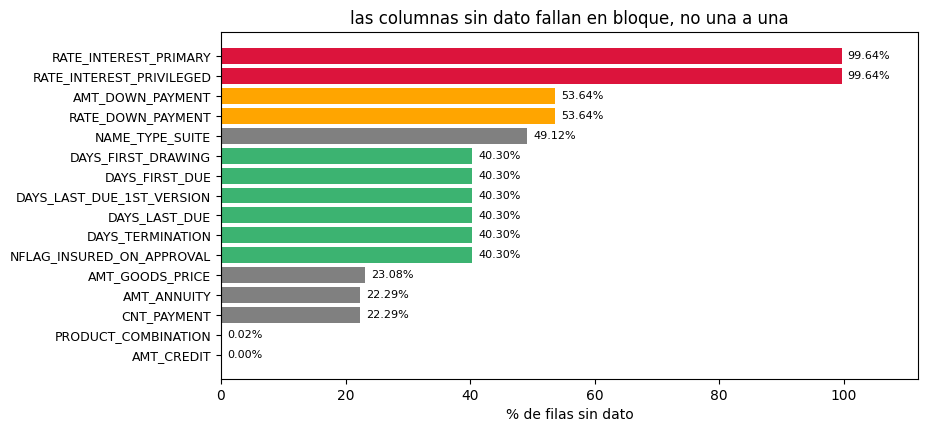

columnas con algún dato ausente: 16 de 37
  bloque de 2 columnas, 1,664,263 filas sin dato (99.64%): RATE_INTEREST_PRIMARY, RATE_INTEREST_PRIVILEGED
  bloque de 2 columnas, 895,844 filas sin dato (53.64%): AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT
  bloque de 6 columnas, 673,065 filas sin dato (40.30%): DAYS_FIRST_DRAWING, DAYS_FIRST_DUE, DAYS_LAST_DUE_1ST_VERSION, DAYS_LAST_DUE, DAYS_TERMINATION, NFLAG_INSURED_ON_APPROVAL
fallan solas: NAME_TYPE_SUITE, AMT_GOODS_PRICE, AMT_ANNUITY, CNT_PAYMENT, PRODUCT_COMBINATION, AMT_CREDIT


In [21]:
# ¿las columnas fallan sueltas o en bloque? mismo color = comparten exactamente las mismas filas sin dato
faltan = prev.isna().sum()
faltan = faltan[faltan > 0].sort_values(ascending=False)
pct = faltan / len(prev) * 100

# un mismo recuento no implica las mismas filas: agrupo por la máscara de nulos, no por el total
bloques = {}
for col in faltan.index:
    bloques.setdefault(prev[col].isna().values.tobytes(), []).append(col)

paleta = [COLOR_DEF, "orange", "gold", "mediumseagreen", COLOR_NODEF]
color = {c: paleta[i % len(paleta)] if len(m) > 1 else "gray"  # las que fallan solas van en gris
         for i, m in enumerate(bloques.values()) for c in m}
compartidos = [m for m in bloques.values() if len(m) > 1]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(pct)), pct.values, color=[color[c] for c in pct.index])
ax.set_yticks(range(len(pct)))
ax.set_yticklabels(pct.index, fontsize=9)
ax.invert_yaxis()
for i, v in enumerate(pct.values):
    ax.text(v + 1, i, f"{v:.2f}%", va="center", fontsize=8)
ax.set(xlabel="% de filas sin dato", xlim=(0, 112),
       title="las columnas sin dato fallan en bloque, no una a una")
plt.show()

print(f"columnas con algún dato ausente: {len(faltan)} de {prev.shape[1]}")
for miembros in compartidos:
    print(f"  bloque de {len(miembros)} columnas, {faltan[miembros[0]]:,} filas sin dato "
          f"({pct[miembros[0]]:.2f}%): {', '.join(miembros)}")
print(f"fallan solas: {', '.join(c for c in faltan.index if color[c] == 'gray')}")

Antes de mirar ninguna distribución quiero saber si el tipo con el que llega cada columna se
corresponde con lo que esa columna significa, porque un tipo mal entendido se arrastra a todo lo que
venga después. Contrastando los tipos contra las descripciones oficiales del conjunto de datos salen
34 columnas correctas de 37, dos mejoras de almacenamiento y un aviso.

Las dos mejoras son menores y no cambian ningún análisis: `FLAG_LAST_APPL_PER_CONTRACT` llega como
texto con Y y N, y `NFLAG_LAST_APPL_IN_DAY` como entero, y las dos son banderas que estarían mejor
como booleano. El aviso, en cambio, es una falsa alarma, y al mirarlo de cerca aparece el error
simétrico. `NAME_YIELD_GROUP` queda marcada como bandera con valores no estándar solo porque tiene
cinco, pero no es una bandera sino el tramo de tipo de interés ofertado, una ordinal que va de
low_action a high con XNA cuando no aplica. Y al revés, `NFLAG_INSURED_ON_APPROVAL` pasa el filtro
como numérica cuando únicamente toma 0 y 1: es decimal porque arrastra un 40,30% de ausencias, no
porque mida nada. La comprobación reconoce el nombre y la descripción, así que sirve de red pero no
de veredicto, y las tres marcas hay que leerlas con criterio.

Dos columnas más pasan como numéricas sin serlo. `SELLERPLACE_AREA` es un código de zona del punto de
venta: vale -1 en el 45,66% de las filas, que es ausencia disfrazada de número, su segundo valor más
frecuente es 0, y llega hasta 4.000.000 con el percentil 99 en 3.570 y solo 22 filas por encima de
100.000. Promediarla, correlacionarla o buscarle valores extremos no significaría nada, así que la
trato como categórica de alta cardinalidad y su -1 queda anotado como código centinela.
`HOUR_APPR_PROCESS_START` es cíclica, porque la hora 23 está a una hora de la 0 y no a veintitrés, de
modo que tampoco entra como continua.

Por eso fijo la clasificación de las 37 columnas de forma explícita, comprobando que cada una cae en
un grupo y solo uno: 2 identificadores, 3 banderas, 6 temporales, 5 importes, 3 tasas, 1 conteo, 1
código, 1 cíclica y 15 categóricas. El conteo, el código y la hora van separados aunque los tres sean
enteros, porque lo que decide en qué análisis entra cada columna es lo que mide, no cómo está
almacenada.

Sobre lo que falta, el dato no se pierde columna a columna sino en bloques que caen juntos. Y no lo
doy por bueno porque coincida el porcentaje, que sería una coincidencia posible, sino comparando qué
filas concretas fallan: las 1.664.263 sin tipo de interés son las mismas en las dos columnas de tasa,
las 895.844 sin entrada son las mismas en importe y en tasa de entrada, y las 673.065 sin fechas del
ciclo de vida son exactamente las mismas en las cinco fechas y en la bandera de seguro. Es un patrón
estructural, y ya adelanta que la ausencia dependerá del estado de la solicitud y del tipo de
producto, aunque el mecanismo lo clasifico al analizar las ausencias y no aquí.

`AMT_ANNUITY` y `CNT_PAYMENT` muestran las dos un 22,29%, pero no fallan en las mismas filas: se separan en 5 registros, así que son dos ausencias casi paralelas y no un bloque. Fiándome del porcentaje habría fusionado dos cosas distintas.

Por otro lado, el caso de `RATE_INTEREST_PRIMARY` y `RATE_INTEREST_PRIVILEGED` están informadas en 5.951 de 1.670.214 solicitudes, un 0,36%. Con esa cobertura no sostienen ningún análisis ni ninguna variable derivada, así que quedan como candidatas a eliminación por falta de información, a confirmar cuando mida su relación con el impago.


### 4. Análisis distribuciones variables

In [22]:
# las magnitudes son los importes, las tasas y el conteo de cuotas: el código de zona y la hora
# quedan fuera aunque sean números, porque no miden cantidad
MAGNITUDES = GRUPOS["importe"] + GRUPOS["tasa"] + GRUPOS["conteo"]
desc = prev[MAGNITUDES].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(desc.drop(columns="count").style.format("{:,.2f}"))

# el cero y el nulo se cuentan aparte: en esta tabla no significan lo mismo
resumen = pd.DataFrame({
    "% sin dato": prev[MAGNITUDES].isna().mean() * 100,
    "% a cero": prev[MAGNITUDES].eq(0).mean() * 100,
    "negativos": prev[MAGNITUDES].lt(0).sum(),
    "máximo": prev[MAGNITUDES].max(),
}).round(2)
display(resumen)
neg = prev.loc[prev['AMT_DOWN_PAYMENT'].lt(0), 'AMT_DOWN_PAYMENT']
print(f"valores negativos de la entrada: {sorted(round(float(v), 2) for v in neg)}")

,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_ANNUITY,"15,955.12","14,782.14",0.00,"2,137.18","2,726.59","6,321.78","11,250.00","20,658.42","45,336.78","69,685.79","418,058.16"
AMT_APPLICATION,"175,233.86","292,779.75",0.00,0.00,0.00,"18,720.00","71,046.00","180,360.00","787,500.00","1,350,000.00","6,905,160.00"
AMT_CREDIT,"196,114.03","318,574.62",0.00,0.00,0.00,"24,160.50","80,541.00","216,418.50","886,500.00","1,515,377.75","6,905,160.00"
AMT_DOWN_PAYMENT,"6,697.40","20,921.50",-0.90,0.00,0.00,0.00,"1,638.00","7,740.00","26,184.08","65,930.90","3,060,045.00"
AMT_GOODS_PRICE,"227,847.22","315,396.56",0.00,"15,300.00","22,882.50","50,841.00","112,320.00","234,000.00","900,000.00","1,395,000.00","6,905,160.00"
RATE_DOWN_PAYMENT,0.08,0.11,-0.00,0.00,0.00,0.00,0.05,0.11,0.29,0.52,1.00
RATE_INTEREST_PRIMARY,0.19,0.09,0.03,0.06,0.14,0.16,0.19,0.19,0.20,0.70,1.00
RATE_INTEREST_PRIVILEGED,0.77,0.10,0.37,0.42,0.64,0.72,0.84,0.85,0.87,0.87,1.00
CNT_PAYMENT,16.05,14.57,0.00,0.00,0.00,6.00,12.00,24.00,48.00,60.00,84.00


,% sin dato,% a cero,negativos,máximo
AMT_ANNUITY,22.29,0.10,0,4.180582e+05
AMT_APPLICATION,0.00,23.49,0,6.905160e+06
AMT_CREDIT,0.00,20.16,0,6.905160e+06
AMT_DOWN_PAYMENT,53.64,22.14,2,3.060045e+06
AMT_GOODS_PRICE,23.08,0.41,0,6.905160e+06
RATE_DOWN_PAYMENT,53.64,22.14,2,1.000000e+00
RATE_INTEREST_PRIMARY,99.64,0.00,0,1.000000e+00
RATE_INTEREST_PRIVILEGED,99.64,0.00,0,1.000000e+00
CNT_PAYMENT,22.29,8.68,0,8.400000e+01


valores negativos de la entrada: [-0.9, -0.45]


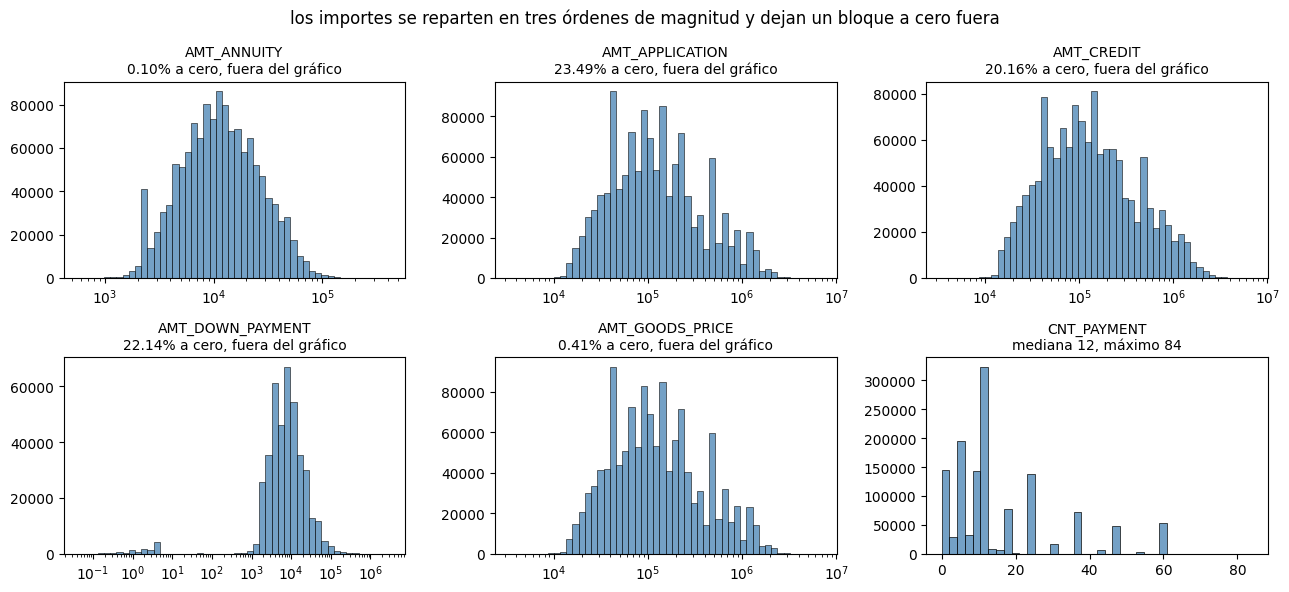

In [23]:
# escala log para los importes: sin ella la cola aplasta toda la masa contra el eje
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.flat, GRUPOS["importe"] + GRUPOS["conteo"]):
    s = prev[col]
    if col == "CNT_PAYMENT":
        sns.histplot(s.dropna(), bins=40, color=COLOR_NODEF, ax=ax)
        ax.set_title(f"{col}\nmediana {s.median():.0f}, máximo {s.max():.0f}", fontsize=10)
    else:
        sns.histplot(s[s > 0], bins=50, log_scale=True, color=COLOR_NODEF, ax=ax)
        ax.set_title(f"{col}\n{prev[col].eq(0).mean() * 100:.2f}% a cero, fuera del gráfico", fontsize=10)
    ax.set(xlabel="", ylabel="")
fig.suptitle("los importes se reparten en tres órdenes de magnitud y dejan un bloque a cero fuera")
plt.tight_layout()
plt.show()

In [24]:
# ¿el cero es un fallo de captura o es lo que le pasó a la operación?
CEROS = ["AMT_APPLICATION", "AMT_CREDIT", "AMT_GOODS_PRICE", "AMT_ANNUITY", "CNT_PAYMENT"]
reparto = pd.DataFrame({c: prev.loc[prev[c].eq(0), "NAME_CONTRACT_STATUS"].value_counts(normalize=True) * 100
                        for c in CEROS}).round(2)
reparto.index.name = "estado del contrato"
display(reparto)
print("filas a cero: " + " | ".join(f"{c} {prev[c].eq(0).sum():,}" for c in CEROS))

aprobadas = prev["CNT_PAYMENT"].eq(0) & prev["NAME_CONTRACT_STATUS"].eq("Approved")
print(f"cuotas a cero en operaciones aprobadas: {aprobadas.sum():,}, y son tarjetas el "
      f"{prev.loc[aprobadas, 'NAME_PORTFOLIO'].eq('Cards').mean() * 100:.2f}%")

# lo concedido frente a lo pedido, donde las dos cifras existen
ambos = prev["AMT_APPLICATION"].gt(0) & prev["AMT_CREDIT"].gt(0)
ratio = prev.loc[ambos, "AMT_CREDIT"] / prev.loc[ambos, "AMT_APPLICATION"]
print(f"concedido frente a solicitado ({ambos.sum():,} filas): igual {ratio.round(4).eq(1).mean() * 100:.2f}% | "
      f"menos {ratio.lt(0.999).mean() * 100:.2f}% | más {ratio.gt(1.001).mean() * 100:.2f}% | "
      f"mediana {ratio.median():.2f} | máximo {ratio.max():.0f}")

,AMT_APPLICATION,AMT_CREDIT,AMT_GOODS_PRICE,AMT_ANNUITY,CNT_PAYMENT
estado del contrato,,,,,
Approved,11.55,0.46,35.94,95.36,67.44
Canceled,77.87,90.73,0.12,0.00,0.33
Refused,10.46,8.66,56.82,4.64,32.24
Unused offer,0.13,0.15,7.12,0.00,0.00


filas a cero: AMT_APPLICATION 392,402 | AMT_CREDIT 336,768 | AMT_GOODS_PRICE 6,869 | AMT_ANNUITY 1,637 | CNT_PAYMENT 144,985
cuotas a cero en operaciones aprobadas: 97,771, y son tarjetas el 100.00%
concedido frente a solicitado (1,277,811 filas): igual 25.16% | menos 27.64% | más 47.09% | mediana 1.00 | máximo 20


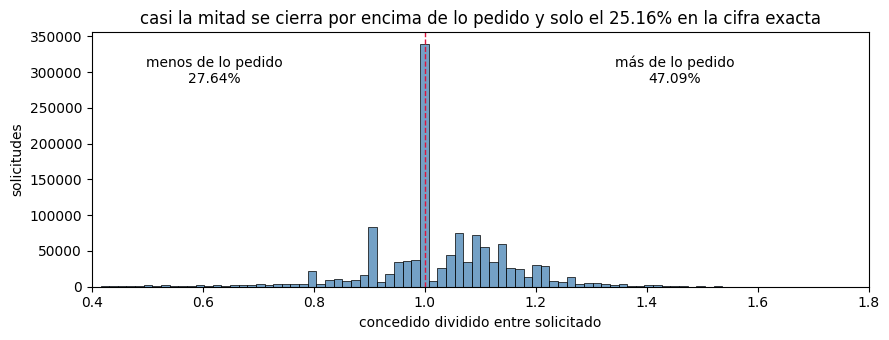

fuera del recorte del eje: 2,363 solicitudes (0.18%)


In [25]:
# la masa vive pegada al 1, así que recorto el eje y digo cuántas quedan fuera
dentro = ratio.between(0.4, 1.8)
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(ratio[dentro], bins=90, color=COLOR_NODEF, ax=ax)
ax.axvline(1, color=COLOR_DEF, ls="--", lw=1)
for x, etiqueta, v in [(0.62, "menos de lo pedido", ratio.lt(0.999).mean()),
                       (1.45, "más de lo pedido", ratio.gt(1.001).mean())]:
    ax.text(x, ax.get_ylim()[1] * 0.8, f"{etiqueta}\n{v * 100:.2f}%", ha="center", fontsize=10)
ax.set(xlabel="concedido dividido entre solicitado", ylabel="solicitudes", xlim=(0.4, 1.8),
       title=f"casi la mitad se cierra por encima de lo pedido y solo el "
             f"{ratio.round(4).eq(1).mean() * 100:.2f}% en la cifra exacta")
plt.tight_layout()
plt.show()
print(f"fuera del recorte del eje: {(~dentro).sum():,} solicitudes ({(~dentro).mean() * 100:.2f}%)")

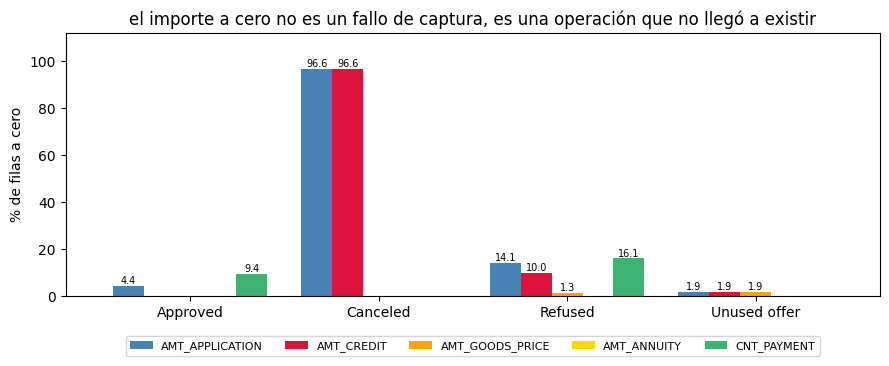

In [26]:
# dentro de cada estado, qué proporción de filas trae el importe a cero
pct_cero = (prev[CEROS].eq(0).groupby(prev["NAME_CONTRACT_STATUS"], observed=True).mean() * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 3.8))
pct_cero.plot.bar(ax=ax, rot=0, width=0.82,
                  color=[COLOR_NODEF, COLOR_DEF, "orange", "gold", "mediumseagreen"])
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v:.1f}" if v >= 1 else "" for v in c.datavalues], fontsize=7)
ax.set(xlabel="", ylabel="% de filas a cero", ylim=(0, 112),
       title="el importe a cero no es un fallo de captura, es una operación que no llegó a existir")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.13))
plt.tight_layout()
plt.show()

Los cinco importes tienen la forma que esperaba de un catálogo de crédito al consumo: masa en las
decenas de miles y una cola que se estira tres órdenes de magnitud, con el crédito concedido en una
mediana de 80.541 y un máximo de 6.905.160. Ese máximo aparece idéntico en lo solicitado, en lo
concedido y en el precio del bien, y es una única fila, así que lo anoto como candidato a revisar por
validez al mirar los valores extremos y no como un cliente de importe alto más. La cuota máxima,
418.058, se queda en seis veces su percentil 99, un desajuste mucho más contenido que los importes de
396 millones del historial del buró.

Lo propio de esta tabla es la masa en cero, y la explicación fácil, un fallo de captura, no se
sostiene. El 23,49% de lo solicitado y el 20,16% de lo concedido están a cero, y no se reparten por
igual: el 96,60% de las operaciones canceladas trae las dos cifras a cero, frente al 4,37% y el 0,15%
de las aprobadas. El cero no es un importe mal grabado, es una operación que no llegó a existir, y
por eso hay que tratarlo como categoría propia y no imputarlo ni promediarlo al agregar. Las cuotas
repiten el patrón con otro mecanismo: de las 144.985 filas con cero cuotas, las 97.771 aprobadas son
el 100% tarjetas, donde el revolving no tiene cuadro de amortización, y las 46.739 restantes son
rechazos que nunca llegaron a tenerlo. Es la misma estructura de ausencia, cero y valor que separaba
en el buró a quien no reportaba cuota, a quien la reportaba saldada y a quien tenía carga viva, y
allí el cero era el grupo más protector de los tres.

De lo concedido frente a lo pedido sale una candidata con fundamento estructural: sobre las 1.277.811
filas con las dos cifras positivas, solo el 25,16% recibe exactamente lo solicitado, el 27,64% recibe
menos y el 47,09% recibe más, con mediana en 1,00 y un máximo de 20 veces. Que casi la mitad de las
operaciones se cierren por encima de lo pedido es una decisión comercial del prestamista y no del
cliente, y la proporción entre ambas cifras es información que ninguna de las dos tiene por separado,
igual que ocurría con el préstamo y el valor del bien en la solicitud que se evalúa. Conviene ser
preciso con lo que estoy afirmando: eso es una afirmación sobre el contenido de información, no sobre
su poder predictivo. Cuánto discrimina se mide al estudiar las relaciones con el objetivo, que es
donde toca decidir si entra y con qué forma.

Dos avisos para más adelante. Las dos tasas de interés solo están informadas en 5.951 filas de
1.670.214, el 0,36%, así que son candidatas a eliminación por falta de información. Y la entrada
tiene, además del 53,64% sin dato y el 22,14% a cero, dos valores negativos de -0,9 y -0,45 y 2.165
filas con importes por debajo de 1, una segunda joroba de céntimos que la escala logarítmica deja a
la vista y que va al inventario de validez de dominio.

In [27]:
# las categóricas: cardinalidad, categoría dominante y peso de los códigos de no aplica
CATS = GRUPOS["categórica"]
tabla = pd.DataFrame({
    "categorías": prev[CATS].nunique(),
    "dominante (entre las filas con dato)": [f"{prev[c].value_counts().index[0]} "
                                            f"({prev[c].value_counts(normalize=True).iloc[0] * 100:.2f}%)"
                                            for c in CATS],
    "% XNA": [prev[c].eq("XNA").mean() * 100 for c in CATS],
    "% XAP": [prev[c].eq("XAP").mean() * 100 for c in CATS],
    "% sin dato": prev[CATS].isna().mean() * 100,
}).round(2)
display(tabla.sort_values(["% XNA", "% XAP"], ascending=False))

# higiene: variantes por espacios o caso que colapsarían al normalizar
sucias = [c for c in CATS
          if prev[c].astype("string").nunique() != prev[c].astype("string").str.strip().str.lower().nunique()]
print(f"higiene de las {len(CATS)} categóricas: {sucias if sucias else 'sin variantes por espacios ni caso'}")

,categorías,dominante (entre las filas con dato),% XNA,% XAP,% sin dato
NAME_PRODUCT_TYPE,3,XNA (63.68%),63.68,0.00,0.00
NAME_GOODS_CATEGORY,28,XNA (56.93%),56.93,0.00,0.00
NAME_SELLER_INDUSTRY,11,XNA (51.23%),51.23,0.00,0.00
NAME_CASH_LOAN_PURPOSE,25,XAP (55.24%),40.59,55.24,0.00
NAME_PAYMENT_TYPE,4,Cash through the bank (61.88%),37.56,0.00,0.00
NAME_YIELD_GROUP,5,XNA (30.97%),30.97,0.00,0.00
NAME_PORTFOLIO,5,POS (41.37%),22.29,0.00,0.00
CODE_REJECT_REASON,9,XAP (81.01%),0.31,81.01,0.00
NAME_CLIENT_TYPE,4,Repeater (73.72%),0.12,0.00,0.00
NAME_CONTRACT_TYPE,4,Cash loans (44.76%),0.02,0.00,0.00


higiene de las 15 categóricas: sin variantes por espacios ni caso


In [28]:
# cuántas categorías son residuales: es lo que decide si hay que agrupar antes de codificar
UMBRAL = 0.001
frec = {c: prev[c].value_counts() for c in CATS}
tabla = pd.DataFrame({
    "categorías": {c: len(v) for c, v in frec.items()},
    "bajo 0,1%": {c: int((v / len(prev) < UMBRAL).sum()) for c, v in frec.items()},
    "filas que suman": {c: int(v[v / len(prev) < UMBRAL].sum()) for c, v in frec.items()},
    "bajo 100 filas": {c: int(v.lt(100).sum()) for c, v in frec.items()},
})
display(tabla[tabla["bajo 0,1%"] > 0].sort_values("filas que suman", ascending=False))

# los códigos residuales se quedaron fuera del veredicto anterior por su propio umbral
for c, v in [("NAME_CONTRACT_TYPE", "XNA"), ("NAME_CLIENT_TYPE", "XNA")]:
    print(f"{c} = {v}: {prev[c].eq(v).sum():,} filas ({prev[c].eq(v).mean() * 100:.3f}%)")

,categorías,"bajo 0,1%",filas que suman,bajo 100 filas
NAME_CASH_LOAN_PURPOSE,25,15,9748,3
NAME_GOODS_CATEGORY,28,10,4242,4
NAME_SELLER_INDUSTRY,11,2,1728,0
NAME_PAYMENT_TYPE,4,1,1085,0
CODE_REJECT_REASON,9,1,717,0
CHANNEL_TYPE,8,1,452,0
NAME_PORTFOLIO,5,1,425,0
NAME_CONTRACT_TYPE,4,1,346,0


NAME_CONTRACT_TYPE = XNA: 346 filas (0.021%)
NAME_CLIENT_TYPE = XNA: 1,941 filas (0.116%)


In [29]:
# ¿el código es una categoría más o es ausencia? si el estado de la operación lo explica, es ausencia
ESTADOS = ["Approved", "Canceled", "Refused", "Unused offer"]
codigos = [(c, v) for c in CATS for v in ("XNA", "XAP") if prev[c].eq(v).mean() > 0.001]
rep = pd.DataFrame({f"{c} = {v}": prev.loc[prev[c].eq(v), "NAME_CONTRACT_STATUS"]
                    .value_counts(normalize=True) * 100 for c, v in codigos}).T[ESTADOS].round(2)
rep.insert(0, "filas", [prev[c].eq(v).sum() for c, v in codigos])
display(rep.sort_values("Approved"))

xap = prev["CODE_REJECT_REASON"].eq("XAP")
sin_rechazo = prev["NAME_CONTRACT_STATUS"].isin(["Approved", "Canceled"])
print(f"motivo de rechazo XAP frente a operación no rechazada: coinciden en el "
      f"{(xap == sin_rechazo).mean() * 100:.4f}% de las filas ({(xap != sin_rechazo).sum()} excepciones)")

# la finalidad del préstamo usa los dos códigos, y no significan lo mismo
finalidad = prev["NAME_CASH_LOAN_PURPOSE"].astype(str)
finalidad = finalidad.where(finalidad.isin(["XNA", "XAP"]), "informada")
display((pd.crosstab(prev["NAME_CONTRACT_TYPE"], finalidad, normalize="index") * 100).round(2))

NAME_CONTRACT_STATUS,filas,Approved,Canceled,Refused,Unused offer
NAME_PORTFOLIO = XNA,372230,0.00,82.15,10.99,6.86
CODE_REJECT_REASON = XNA,5244,0.15,0.00,99.85,0.00
NAME_YIELD_GROUP = XNA,517215,18.90,59.22,16.94,4.94
NAME_CLIENT_TYPE = XNA,1941,29.78,50.28,18.24,1.70
NAME_PAYMENT_TYPE = XNA,627384,33.76,49.90,16.26,0.08
NAME_SELLER_INDUSTRY = XNA,855720,40.90,36.68,22.37,0.06
NAME_CASH_LOAN_PURPOSE = XNA,677918,42.13,39.38,18.45,0.04
NAME_GOODS_CATEGORY = XNA,950809,43.16,33.25,23.54,0.05
NAME_PRODUCT_TYPE = XNA,1063666,58.90,28.77,9.85,2.49
CODE_REJECT_REASON = XAP,1353093,76.62,23.38,0.00,0.00


motivo de rechazo XAP frente a operación no rechazada: coinciden en el 99.9995% de las filas (9 excepciones)


NAME_CASH_LOAN_PURPOSE,XAP,XNA,informada
NAME_CONTRACT_TYPE,,,
Cash loans,0.0,90.68,9.32
Consumer loans,100.0,0.00,0.00
Revolving loans,100.0,0.00,0.00
XNA,100.0,0.00,0.00


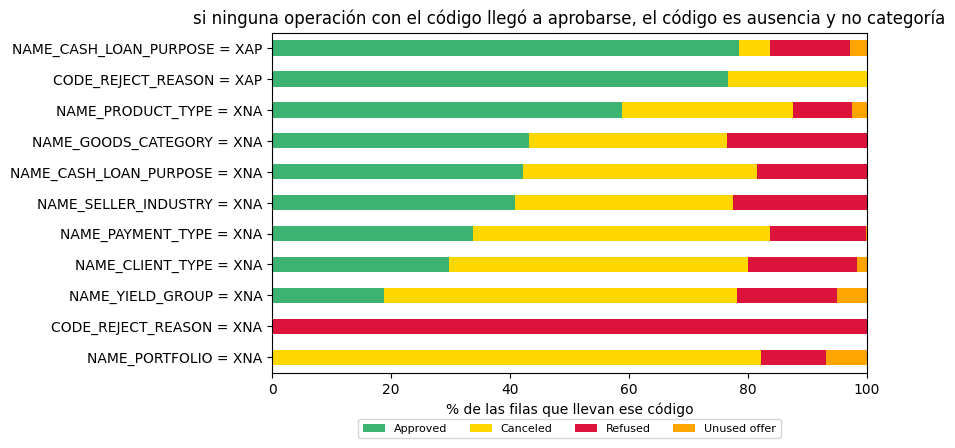

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.6))
rep[ESTADOS].sort_values("Approved").plot.barh(
    stacked=True, ax=ax, color=["mediumseagreen", "gold", COLOR_DEF, "orange"])
ax.set(xlabel="% de las filas que llevan ese código", ylabel="", xlim=(0, 100),
       title="si ninguna operación con el código llegó a aprobarse, el código es ausencia y no categoría")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

Las 15 categóricas salen limpias de higiene, sin variantes por espacios ni caso, y solo una tiene
ausencia declarada de verdad: el acompañante, con un 49,12%. Eso no significa que el resto esté
completo, porque aquí la ausencia se escribe con un código y no con un hueco, hasta el punto de que
en cuatro columnas el valor más frecuente es XNA o XAP.

La pregunta que decide qué hacer con ellos es si el código es una categoría más o es ausencia, y el
estado de la operación la contesta columna a columna. En el motivo de rechazo, XAP coincide con
"operación no rechazada" en el 99,9995% de las filas, con 9 excepciones sobre 1.670.214: por encima
del criterio del 95% con el que clasifiqué la fecha de cierre del buró, es ausencia estructural
determinista y no un motivo más. En la cartera, XNA cubre 372.230 filas de las que solo 4 están
aprobadas, así que tampoco nombra un producto, dice que no llegó a haberlo.

La finalidad del préstamo es el caso que más conviene no simplificar, porque usa los dos códigos con
significados distintos en la misma columna: XAP es el 100% de los créditos al consumo y del
revolving, donde la finalidad no aplica porque la operación es la compra, y XNA es el 90,68% de los
préstamos en efectivo, donde sí aplica y no se registró. Fundirlos en un solo nivel mezclaría "no
procede" con "no consta".

El resto no lo explica el estado y por tanto no puedo despacharlo como ausencia estructural: el tipo
de producto con un 63,68% de XNA, la categoría del bien con un 56,93%, la industria del vendedor con
un 51,23%, la forma de pago con un 37,56% y el tramo de interés con un 30,97% reparten sus códigos
entre los cuatro estados, con entre un 18,90% y un 58,90% de aprobadas dentro del propio código. Ahí
el código es ausencia informativa, y hay que medir si discrimina antes de decidir si entra como nivel
o se trata como hueco. Queda un caso menor en la misma línea: el XNA del motivo de rechazo, 5.244
filas de las que el 99,85% son rechazos, es un rechazo sin motivo registrado, ausencia dentro del
grupo al que sí aplica.

Queda una decisión de codificación que la cardinalidad por sí sola no resuelve: cuántos niveles son
residuales. La finalidad del préstamo tiene 15 categorías por debajo del 0,1% de las filas, que entre
todas suman 9.748 registros, y tres de ellas no llegan ni a 100 filas; la categoría del bien tiene
otras 10 que suman 4.242, cuatro de ellas también por debajo de 100. Es la misma situación que me
llevó a agrupar en un nivel Other los tipos de crédito minoritarios del buró, y aquí pesa más porque
son columnas de 25 y 28 niveles que al codificarse multiplicarían el ancho de la tabla sin aportar
masa. La agrupación tendrá que ir por tasa de riesgo parecida y no por frecuencia, con la cautela de
siempre sobre dónde se calcula esa tasa.

Quedan dos residuos que el umbral del 0,1% dejó fuera al separar código de categoría: el tipo de
contrato tiene 346 filas en XNA y el tipo de cliente 1.941. Son el mismo caso que los cuatro
registros de género sin informar de la tabla principal, cifras demasiado pequeñas para sostener una
categoría propia y demasiado concretas para inventarles un valor, así que van al mismo sitio que las
minoritarias.

In [31]:
# el mismo centinela que marcaba al inactivo en la tabla principal, ahora en las fechas del ciclo de vida
CENTINELA = 365243
real = prev[GRUPOS["temporal"]].ne(CENTINELA) & prev[GRUPOS["temporal"]].notna()
fechas = pd.DataFrame({
    "% con dato": real.mean() * 100,
    "% centinela": prev[GRUPOS["temporal"]].eq(CENTINELA).mean() * 100,
    "% sin dato": prev[GRUPOS["temporal"]].isna().mean() * 100,
    "mediana con dato": [prev[c].where(real[c]).median() for c in GRUPOS["temporal"]],
    "máximo con dato": [prev[c].where(real[c]).max() for c in GRUPOS["temporal"]],
}).round(2)
display(fechas)

ausencia = prev.isna()
ausencia[GRUPOS["temporal"]] |= prev[GRUPOS["temporal"]].eq(CENTINELA)
print(f"columnas sin dato por fila: {prev.isna().sum(axis=1).mean():.2f} declaradas frente a "
      f"{ausencia.sum(axis=1).mean():.2f} contando el centinela")

futuras = prev["DAYS_LAST_DUE_1ST_VERSION"].between(1, CENTINELA - 1)
print(f"vencimientos previstos en el futuro: {futuras.sum():,} filas, hasta "
      f"{prev.loc[futuras, 'DAYS_LAST_DUE_1ST_VERSION'].max():.0f} días")

,% con dato,% centinela,% sin dato,mediana con dato,máximo con dato
DAYS_DECISION,100.00,0.00,0.0,-581.0,-1.0
DAYS_FIRST_DRAWING,3.75,55.95,40.3,-621.0,-2.0
DAYS_FIRST_DUE,57.27,2.43,40.3,-874.0,-2.0
DAYS_LAST_DUE_1ST_VERSION,54.08,5.62,40.3,-480.0,2389.0
DAYS_LAST_DUE,47.06,12.65,40.3,-801.0,-2.0
DAYS_TERMINATION,46.18,13.53,40.3,-780.0,-2.0


columnas sin dato por fila: 6.65 declaradas frente a 7.55 contando el centinela
vencimientos previstos en el futuro: 224,392 filas, hasta 2389 días


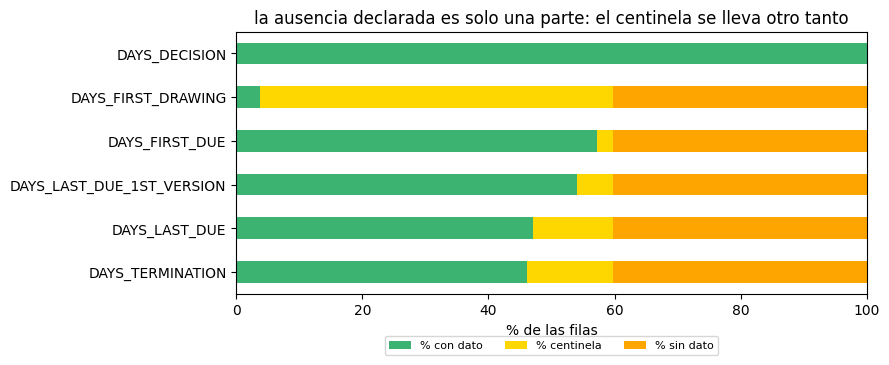

In [32]:
fig, ax = plt.subplots(figsize=(9, 3.8))
fechas[["% con dato", "% centinela", "% sin dato"]].iloc[::-1].plot.barh(
    stacked=True, ax=ax, color=["mediumseagreen", "gold", "orange"])
ax.set(xlabel="% de las filas", ylabel="", xlim=(0, 100),
       title="la ausencia declarada es solo una parte: el centinela se lleva otro tanto")
ax.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout()
plt.show()

In [33]:
# lo que queda de la partición: banderas, la hora cíclica y el código de zona
for c in GRUPOS["bandera"]:
    vc = (prev[c].astype("string").fillna("sin dato").value_counts(normalize=True) * 100).round(2)
    print(f"{c:28s} " + " | ".join(f"{k}: {v}%" for k, v in vc.items()))

hora, zona = prev["HOUR_APPR_PROCESS_START"], prev["SELLERPLACE_AREA"]
print(f"\nhora de la solicitud: mediana {hora.median():.0f}, el {hora.between(10, 15).mean() * 100:.2f}% "
      f"entre las 10 y las 15, mínimo {hora.min()} y máximo {hora.max()}")
print(f"código de zona: {zona.nunique():,} valores distintos, -1 en el {zona.eq(-1).mean() * 100:.2f}% "
      f"y 0 en el {zona.eq(0).mean() * 100:.2f}%")

FLAG_LAST_APPL_PER_CONTRACT  Y: 99.49% | N: 0.51%


NFLAG_LAST_APPL_IN_DAY       1: 99.65% | 0: 0.35%


NFLAG_INSURED_ON_APPROVAL    sin dato: 40.3% | 0.0: 39.85% | 1.0: 19.86%

hora de la solicitud: mediana 12, el 61.87% entre las 10 y las 15, mínimo 0 y máximo 23
código de zona: 2,097 valores distintos, -1 en el 45.66% y 0 en el 3.62%


In [34]:
# ¿la ausencia se reparte por igual entre filas o hay dos poblaciones?
por_fila = ausencia.sum(axis=1)
d = pd.DataFrame({"filas": por_fila.value_counts().sort_index()})
d["% de la tabla"] = (d["filas"] / len(prev) * 100).round(2)
display(d)
display(por_fila.groupby(prev["NAME_CONTRACT_STATUS"], observed=True)
        .agg(["size", "median", "mean"]).round(2))

# el pico alto y el importe a cero, ¿son la misma población?
vacia, cero = por_fila.ge(14), prev["AMT_CREDIT"].eq(0)
print(f"filas casi vacías: {vacia.sum():,} | con crédito a cero: {cero.sum():,} | ambas: {(vacia & cero).sum():,} "
      f"| Jaccard {(vacia & cero).sum() / (vacia | cero).sum():.4f}")
print(f"casi vacías sin crédito a cero: {(vacia & ~cero).sum()} | canceladas en el pico alto: "
      f"{por_fila[prev['NAME_CONTRACT_STATUS'].eq('Canceled')].ge(14).mean() * 100:.2f}%")

,filas,% de la tabla
1,61,0.00
2,3959,0.24
3,387055,23.17
4,185503,11.11
5,164030,9.82
6,94620,5.67
7,73422,4.40
8,107253,6.42
9,59251,3.55
10,151520,9.07


,size,median,mean
NAME_CONTRACT_STATUS,,,
Approved,1036781,4.0,4.79
Canceled,316319,14.0,13.86
Refused,290678,10.0,10.22
Unused offer,26436,11.0,10.90


filas casi vacías: 333,832 | con crédito a cero: 336,768 | ambas: 333,832 | Jaccard 0.9913
casi vacías sin crédito a cero: 0 | canceladas en el pico alto: 96.60%


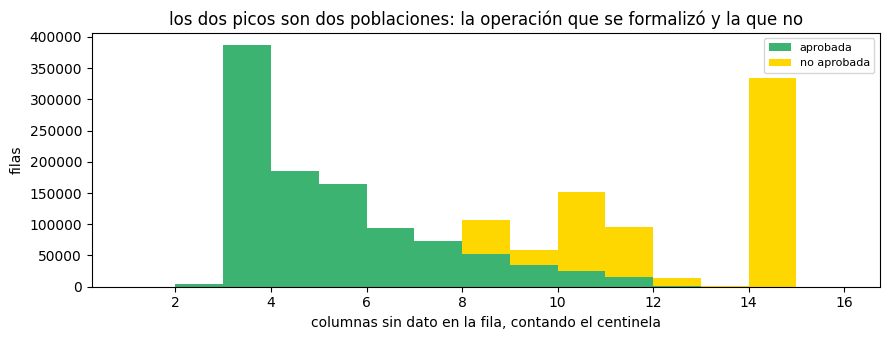

In [35]:
fig, ax = plt.subplots(figsize=(9, 3.5))
aprobada = prev["NAME_CONTRACT_STATUS"].eq("Approved")
ax.hist([por_fila[aprobada], por_fila[~aprobada]], bins=range(1, 17), stacked=True,
        color=["mediumseagreen", "gold"], label=["aprobada", "no aprobada"])
ax.set(xlabel="columnas sin dato en la fila, contando el centinela", ylabel="filas",
       title="los dos picos son dos poblaciones: la operación que se formalizó y la que no")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
# ¿hay una cuarta capa de ausencia escondida? busco el centinela y otros marcadores fuera de las fechas
num = prev.select_dtypes("number").drop(columns=GRUPOS["identificador"])
print("columnas con el centinela:", {c: int(num[c].eq(CENTINELA).sum()) for c in num if num[c].eq(CENTINELA).any()})
print("columnas con -1:", {c: int(num[c].eq(-1).sum()) for c in num if num[c].eq(-1).any()})
print("valor más repetido de cada importe:")
for c in GRUPOS["importe"]:
    v = prev[c].value_counts().head(2)
    print(f"  {c:20s} " + " | ".join(f"{i:,.0f} en {n:,} filas" for i, n in v.items()))

columnas con el centinela: {'DAYS_FIRST_DRAWING': 934444, 'DAYS_FIRST_DUE': 40645, 'DAYS_LAST_DUE_1ST_VERSION': 93864, 'DAYS_LAST_DUE': 211221, 'DAYS_TERMINATION': 225913}
columnas con -1: {'DAYS_DECISION': 2, 'SELLERPLACE_AREA': 762675, 'DAYS_LAST_DUE_1ST_VERSION': 675}
valor más repetido de cada importe:
  AMT_ANNUITY          2,250 en 31,865 filas | 11,250 en 13,974 filas
  AMT_APPLICATION      0 en 392,402 filas | 45,000 en 47,831 filas
  AMT_CREDIT           0 en 336,768 filas | 45,000 en 35,051 filas
  AMT_DOWN_PAYMENT     0 en 369,854 filas | 4,500 en 21,241 filas
  AMT_GOODS_PRICE      45,000 en 47,831 filas | 225,000 en 43,549 filas


Las fechas del ciclo de vida arrastran el mismo centinela 365243 que marcaba al inactivo en la
antigüedad laboral de la tabla principal, y aquí pesa más que en ningún otro sitio. La fecha de
primera disposición declara un 40,30% de ausencia y esconde otro 55,95% de centinela, así que solo
tiene dato real en 62.705 filas, el 3,75%: por debajo incluso de las tasas de interés, y candidata a
eliminación por el mismo motivo. Detrás van la terminación con un 13,53%, el último vencimiento con
un 12,65%, su versión inicial con un 5,62% y el primer vencimiento con un 2,43%. La fecha de la
decisión es la única entera y sin centinela, que es lo esperable porque es lo que da existencia al
registro.

El efecto agregado es que la ausencia declarada se queda corta: contando el centinela, las columnas
sin dato por fila pasan de 6,65 a 7,55 sobre 37. Cualquier lectura de completitud que se apoye solo
en el hueco subestima la ausencia real en casi una columna por fila, así que el centinela entra como
ausencia al analizar el dato que falta, no como fecha.

Hay una excepción que no es ausencia sino diseño. La versión inicial del último vencimiento es la
única fecha con valores futuros legítimos, 224.392 filas que llegan hasta 2.389 días por delante de
la solicitud: no es un hecho consumado sino el vencimiento previsto en el momento de firmar, igual
que la fecha de fin prevista del buró, donde ya vi que un 3,58% de los casos eran marcadores de
posición y no cierres reales. Que exista esa versión inicial junto a la definitiva abre además una
comparación interesante para más adelante, la del plan frente a lo que ocurrió.

El resto de la partición no da sorpresas. Las dos banderas de registro están casi saturadas, con un
99,49% de últimos registros por contrato y un 99,65% de últimos del día, coherente con el 0,51% y el
0,35% de duplicidad que ya había medido al contar solicitudes. La bandera de seguro comparte
exactamente el 40,30% de ausencia de las fechas y vale 1 en el 33,26% de las filas informadas, así
que ni se rellena con cero ni se lee sin la ausencia delante. La hora de la solicitud se comporta
como una variable cíclica normal, mediana en las 12 y un 61,87% de las operaciones entre las 10 y las
15. Y el código de zona confirma lo que ya se veía: 2.097 valores distintos, un -1 en el 45,66% de
las filas y un 0 en otro 3,62%, o sea una categórica de alta cardinalidad con su propio centinela
dentro.

La media de ausencias por fila esconde además que no hay una sola población. La distribución tiene
dos picos, el 23,17% de las filas con tres columnas sin dato y el 19,97% con catorce, y lo que los
separa es el estado de la operación: la mediana es de 4 columnas ausentes en las aprobadas y de 14 en
las canceladas, con medias de 4,79 y 13,86. El 96,60% de las canceladas cae en el pico alto, que es
exactamente la misma proporción que tenía el importe a cero, y no es casualidad: las filas casi
vacías son un subconjunto estricto de las de importe cero, con un Jaccard de 0,9913 y ni una sola
fila vacía que no lo lleve. Completitud del registro e importe a cero son dos formas de mirar el
mismo hecho, que la operación no llegó a formalizarse, así que una variable de completitud de la
solicitud no sería información nueva sino el estado del contrato recodificado. Lo dejo dicho para no
construirla como si lo fuera.

Con tres capas de ausencia por encima del hueco declarado convenía comprobar que no hay una cuarta, y
no la hay. El 365243 no aparece en ninguna columna fuera de las cinco fechas del ciclo de vida. El -1
solo funciona como marcador en el código de zona, porque los dos casos de la fecha de decisión y los
675 del vencimiento previsto son días reales. Y ningún importe esconde un valor repetido sospechoso:
sus valores más frecuentes, después del cero, son cifras comerciales redondas como 45.000 con 47.831
filas o 225.000 con 43.549. El inventario queda cerrado, y es lo que permite entrar a analizar el
dato que falta contando el centinela y los códigos como ausencia sin dejarse una capa fuera.

De las 37 columnas, tres salen candidatas a eliminación por falta de información: las dos tasas de
interés, informadas en el 0,36% de las filas, y la fecha de primera disposición, con un 3,75%. Nueve
llevan un código de ausencia en lugar de un hueco, de las que dos quedan explicadas por el estado de
la operación y el resto pendientes de medir. Cinco fechas arrastran centinela, y en los importes de
la operación y en el número de cuotas el cero funciona como estado y no como cantidad. Del lado
contrario sale una candidata a variable con fundamento propio, la proporción entre lo concedido y lo
solicitado. Todo ello entra en el análisis del dato que falta con la ausencia ya contada de verdad,
que es casi una columna por fila más de la que se declara.

### 5. Análisis Missings

In [37]:
# la ausencia real no es el hueco: hay que sumarle el centinela de las fechas y los códigos de no aplica
CODIGOS = {"NAME_CASH_LOAN_PURPOSE": ["XNA", "XAP"], "CODE_REJECT_REASON": ["XNA", "XAP"],
           "NAME_PAYMENT_TYPE": ["XNA"], "NAME_PORTFOLIO": ["XNA"], "NAME_PRODUCT_TYPE": ["XNA"],
           "NAME_GOODS_CATEGORY": ["XNA"], "NAME_SELLER_INDUSTRY": ["XNA"], "NAME_YIELD_GROUP": ["XNA"],
           "NAME_CLIENT_TYPE": ["XNA"]}

pt = prev_t.assign(TARGET=prev_t["SK_ID_CURR"].map(train.set_index("SK_ID_CURR")["TARGET"]).values)
print(f"solicitudes con objetivo heredado: {len(pt):,} | clientes: {pt['SK_ID_CURR'].nunique():,} | "
      f"tasa heredada: {pt['TARGET'].mean() * 100:.2f}%")
print(f"cada cliente aporta {len(pt) / pt['SK_ID_CURR'].nunique():.2f} solicitudes que comparten etiqueta, "
      "así que decido por tamaño del efecto y no por p-valor")

falta = pt[prev.columns].isna()
falta[GRUPOS["temporal"]] |= pt[GRUPOS["temporal"]].eq(CENTINELA)
con_codigo = falta.copy()
for col, valores in CODIGOS.items():
    con_codigo[col] |= pt[col].isin(valores)
print(f"\ncolumnas sin dato por fila: {pt[prev.columns].isna().sum(axis=1).mean():.2f} declaradas, "
      f"{falta.sum(axis=1).mean():.2f} con el centinela y {con_codigo.sum(axis=1).mean():.2f} con los códigos")

solicitudes con objetivo heredado: 1,413,701 | clientes: 291,057 | tasa heredada: 8.66%


cada cliente aporta 4.86 solicitudes que comparten etiqueta, así que decido por tamaño del efecto y no por p-valor



columnas sin dato por fila: 6.59 declaradas, 7.50 con el centinela y 11.87 con los códigos


In [38]:
# cada columna con ausencia contra el objetivo heredado
COLS_NA = [c for c in prev.columns if falta[c].any()]
ev_fila = EvaluadorSenal(pt, pt["TARGET"])  # no contamina el ranking de cliente
ev_fila.evaluar_flags([(c, falta[c].astype(int).values, None, "nivel solicitud") for c in COLS_NA])

# la familia cuenta cada contraste emitido y no cada columna, igual que en las demás pasadas:
# las 16 banderas de ausencia, los 26 deltas por bloque (7 globales y 19 dentro de un estado con
# muestra) y los 37 de los códigos (11 globales y 26 dentro de un estado con muestra)
familia = len(COLS_NA) + 26 + 37
alfa = 0.05 / familia
emitidos = len(COLS_NA)  # lo van sumando los dos bloques siguientes, y se comprueba al final
relevantes = [e["feature"] for e in ev_fila.fb_flags if abs(e["efecto"]) > 2 and e["p"] < alfa]
print(f"familia de {familia} contrastes emitidos, alfa de Bonferroni {alfa:.2e}")
print(f"cruzan a la vez los 2pp y la significancia: {relevantes}")

# esas columnas eran un bloque exacto de nulos: compruebo si el centinela lo mantiene
BLOQUE_VIDA = GRUPOS["temporal"][1:] + ["NFLAG_INSURED_ON_APPROVAL"]
hueco = pt[prev.columns].isna()
print("\ncoincidencia de cada columna del ciclo de vida con la primera cuota:")
for c in BLOQUE_VIDA:
    print(f"  {c:28s} como hueco {(hueco[c] == hueco['DAYS_FIRST_DUE']).mean() * 100:6.2f}% | "
          f"con el centinela {(falta[c] == falta['DAYS_FIRST_DUE']).mean() * 100:6.2f}% "
          f"({(falta[c] != falta['DAYS_FIRST_DUE']).sum():,} filas de diferencia) | "
          f"ausencia real {falta[c].mean() * 100:5.2f}%")

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
AMT_ANNUITY,nivel solicitud,9.74% (n=307218),8.35% (n=1106483),+1.39 pp,24.3,4.038572002262906e-130
AMT_CREDIT,nivel solicitud,100.0% (n=1),8.66% (n=1413700),+91.34 pp,3.2,0.0011596025887980774
AMT_DOWN_PAYMENT,nivel solicitud,9.55% (n=749540),7.65% (n=664161),+1.90 pp,40.0,0.0
AMT_GOODS_PRICE,nivel solicitud,9.58% (n=319525),8.38% (n=1094176),+1.20 pp,21.2,2.111252657252857e-99
RATE_DOWN_PAYMENT,nivel solicitud,9.55% (n=749540),7.65% (n=664161),+1.90 pp,40.0,0.0
RATE_INTEREST_PRIMARY,nivel solicitud,8.66% (n=1408910),8.14% (n=4791),+0.52 pp,1.3,0.20408610860476883
RATE_INTEREST_PRIVILEGED,nivel solicitud,8.66% (n=1408910),8.14% (n=4791),+0.52 pp,1.3,0.20408610860476883
NAME_TYPE_SUITE,nivel solicitud,9.32% (n=694672),8.01% (n=719029),+1.31 pp,27.7,2.4414694965699404e-168
CNT_PAYMENT,nivel solicitud,9.74% (n=307213),8.35% (n=1106488),+1.39 pp,24.3,3.728889426921293e-130
PRODUCT_COMBINATION,nivel solicitud,20.13% (n=313),8.65% (n=1413388),+11.48 pp,7.2,5.22521050927929e-13


familia de 79 contrastes emitidos, alfa de Bonferroni 6.33e-04
cruzan a la vez los 2pp y la significancia: ['PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']

coincidencia de cada columna del ciclo de vida con la primera cuota:
  DAYS_FIRST_DRAWING           como hueco 100.00% | con el centinela  45.60% (769,048 filas de diferencia) | ausencia real 96.22%
  DAYS_FIRST_DUE               como hueco 100.00% | con el centinela 100.00% (0 filas de diferencia) | ausencia real 42.09%
  DAYS_LAST_DUE_1ST_VERSION    como hueco 100.00% | con el centinela  95.89% (58,123 filas de diferencia) | ausencia real 45.29%
  DAYS_LAST_DUE                como hueco 100.00% | con el centinela  89.61% (146,830 filas de diferencia) | ausencia real 52.48%
  DAYS_TERMINATION             como hueco 100.00% | con el centinela  88.10% (168,168 filas de diferencia) | ausencia real 53.41%
  NFLAG_INSURED_ON_AP

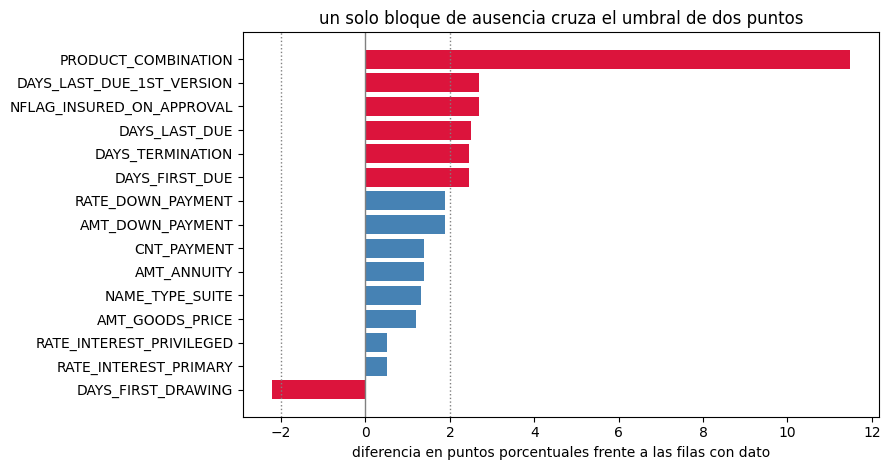

In [39]:
# fuera la de una sola fila sin dato: su delta no es interpretable y aplasta la escala
delta = pd.Series({e["feature"]: e["efecto"] for e in ev_fila.fb_flags
                   if e["n_pos"] > 100}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(delta.index, delta.values,
        color=[COLOR_DEF if abs(v) > 2 else COLOR_NODEF for v in delta])
ax.axvline(0, color="gray", lw=1)
for x in (-2, 2):
    ax.axvline(x, color="gray", ls=":", lw=1)
ax.set(xlabel="diferencia en puntos porcentuales frente a las filas con dato", ylabel="",
       title="un solo bloque de ausencia cruza el umbral de dos puntos")
plt.tight_layout()
plt.show()

In [40]:
# ¿qué explica cada ausencia?
BLOQUES = {"ciclo de vida": "DAYS_FIRST_DUE", "entrada": "AMT_DOWN_PAYMENT", "cuota": "AMT_ANNUITY",
           "cuotas pactadas": "CNT_PAYMENT", "precio del bien": "AMT_GOODS_PRICE",
           "acompañante": "NAME_TYPE_SUITE", "tasas de interés": "RATE_INTEREST_PRIMARY"}
EXPL = ["NAME_CONTRACT_STATUS", "NAME_PORTFOLIO", "NAME_CONTRACT_TYPE"]

filas = []
for nombre, col in BLOQUES.items():
    m = falta[col]
    fila = {"bloque": nombre, "% sin dato": round(m.mean() * 100, 2)}
    for e in EXPL:
        vc = pt.loc[m, e].value_counts(normalize=True) * 100
        fila[e] = f"{vc.index[0]} ({vc.iloc[0]:.2f}%)"
    filas.append(fila)
display(pd.DataFrame(filas).set_index("bloque"))

print(f"cuota sin dato en cartera sin producto: "
      f"{pt.loc[falta['AMT_ANNUITY'], 'NAME_PORTFOLIO'].eq('XNA').mean() * 100:.2f}%")
print(f"precio sin dato en cartera sin producto o tarjeta: "
      f"{pt.loc[falta['AMT_GOODS_PRICE'], 'NAME_PORTFOLIO'].isin(['XNA', 'Cards']).mean() * 100:.2f}%")
print(f"entrada sin dato fuera del crédito al consumo: "
      f"{(~pt.loc[falta['AMT_DOWN_PAYMENT'], 'NAME_CONTRACT_TYPE'].eq('Consumer loans')).mean() * 100:.2f}%")
print(f"ciclo de vida sin dato en operaciones no aprobadas: "
      f"{(~pt.loc[falta['DAYS_FIRST_DUE'], 'NAME_CONTRACT_STATUS'].eq('Approved')).mean() * 100:.2f}% "
      f"| aprobadas que aun así lo pierden: {(falta['DAYS_FIRST_DUE'] & pt['NAME_CONTRACT_STATUS'].eq('Approved')).sum():,}")

,% sin dato,NAME_CONTRACT_STATUS,NAME_PORTFOLIO,NAME_CONTRACT_TYPE
bloque,,,,
ciclo de vida,42.09,Canceled (43.60%),XNA (51.63%),Cash loans (64.03%)
entrada,53.02,Approved (42.41%),Cash (46.84%),Cash loans (78.13%)
cuota,21.73,Canceled (81.60%),XNA (100.00%),Cash loans (76.53%)
cuotas pactadas,21.73,Canceled (81.60%),XNA (100.00%),Cash loans (76.53%)
precio del bien,22.60,Canceled (78.39%),XNA (85.82%),Cash loans (73.03%)
acompañante,49.14,Approved (46.27%),XNA (42.93%),Cash loans (50.80%)
tasas de interés,99.66,Approved (62.55%),POS (41.71%),Cash loans (44.49%)


cuota sin dato en cartera sin producto: 100.00%
precio sin dato en cartera sin producto o tarjeta: 100.00%
entrada sin dato fuera del crédito al consumo: 99.42%
ciclo de vida sin dato en operaciones no aprobadas: 88.66% | aprobadas que aun así lo pierden: 67,466


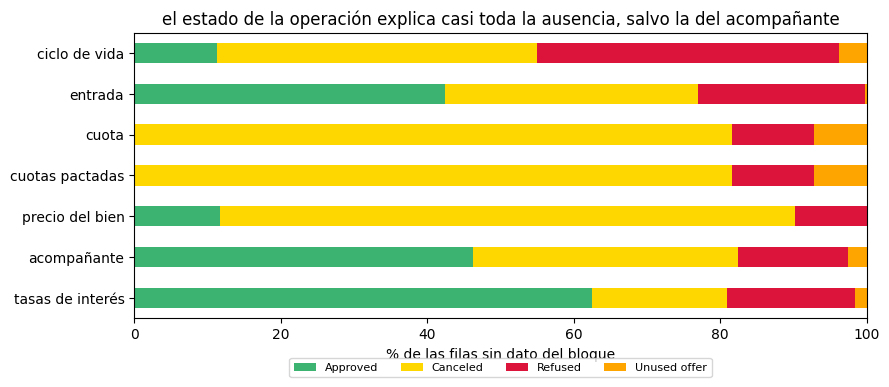

In [41]:
ESTADOS = ["Approved", "Canceled", "Refused", "Unused offer"]
reparto = pd.DataFrame({n: pt.loc[falta[c], "NAME_CONTRACT_STATUS"].value_counts(normalize=True) * 100
                        for n, c in BLOQUES.items()}).T[ESTADOS]

fig, ax = plt.subplots(figsize=(9, 4)) 
reparto.iloc[::-1].plot.barh(stacked=True, ax=ax,
                             color=["mediumseagreen", "gold", COLOR_DEF, "orange"])
ax.set(xlabel="% de las filas sin dato del bloque", ylabel="", xlim=(0, 100),
       title="el estado de la operación explica casi toda la ausencia, salvo la del acompañante")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

In [42]:
# ¿la ausencia discrimina dentro de un mismo estado o solo entre estados?
tasa_estado = pt.groupby("NAME_CONTRACT_STATUS", observed=True)["TARGET"].agg(["size", "mean"])
print("control, tasa por estado: " + " | ".join(
    f"{k} {v * 100:.2f}% (n={int(s):,})" for k, s, v in
    zip(tasa_estado.index, tasa_estado["size"], tasa_estado["mean"])))

def delta_z(a, b):
    """delta en pp y p-valor del z-test de proporciones"""
    n1, n0 = len(a), len(b)
    p1, p0 = a.mean(), b.mean()
    pc = (a.sum() + b.sum()) / (n1 + n0)
    z = (p1 - p0) / ((pc * (1 - pc) * (1 / n1 + 1 / n0)) ** 0.5)
    return (p1 - p0) * 100, 2 * norm.sf(abs(z))

filas, marcadas = [], []
for nombre, col in BLOQUES.items():
    m = falta[col]
    d, p = delta_z(pt.loc[m, "TARGET"], pt.loc[~m, "TARGET"])
    emitidos += 1
    fila, fila_m = {"bloque": nombre, "global": round(d, 2)}, {"bloque": nombre, "global": f"{d:+.2f}"}
    for e in ESTADOS:
        s = pt["NAME_CONTRACT_STATUS"].eq(e)
        a, b = pt.loc[s & m, "TARGET"], pt.loc[s & ~m, "TARGET"]
        if min(len(a), len(b)) > 200:
            d, p = delta_z(a, b)
            emitidos += 1
            fila[e] = round(d, 2)
            fila_m[e] = f"{d:+.2f}" + ("" if p < alfa else " (ns)")
        else:
            fila[e], fila_m[e] = None, ""
    filas.append(fila)
    marcadas.append(fila_m)
condicionado = pd.DataFrame(filas).set_index("bloque")  # numérico, lo usa la figura
print(f"marcado (ns) lo que no supera el alfa de Bonferroni de {alfa:.2e}")
display(pd.DataFrame(marcadas).set_index("bloque"))

control, tasa por estado: Approved 7.59% (n=886,099) | Canceled 9.17% (n=259,441) | Refused 12.00% (n=245,390) | Unused offer 8.25% (n=22,771)


marcado (ns) lo que no supera el alfa de Bonferroni de 6.33e-04


,global,Approved,Canceled,Refused,Unused offer
bloque,,,,,
ciclo de vida,+2.44,-0.50,,,
entrada,+1.90,+0.74,-2.77 (ns),+3.00,-0.78 (ns)
cuota,+1.39,,+0.95 (ns),+3.10,-2.30 (ns)
cuotas pactadas,+1.39,,+0.95 (ns),+3.10,-2.30 (ns)
precio del bien,+1.20,-0.01 (ns),+0.85 (ns),+3.42,
acompañante,+1.31,+0.80,+1.12,+2.59,+1.25 (ns)
tasas de interés,+0.52,-0.55 (ns),,,


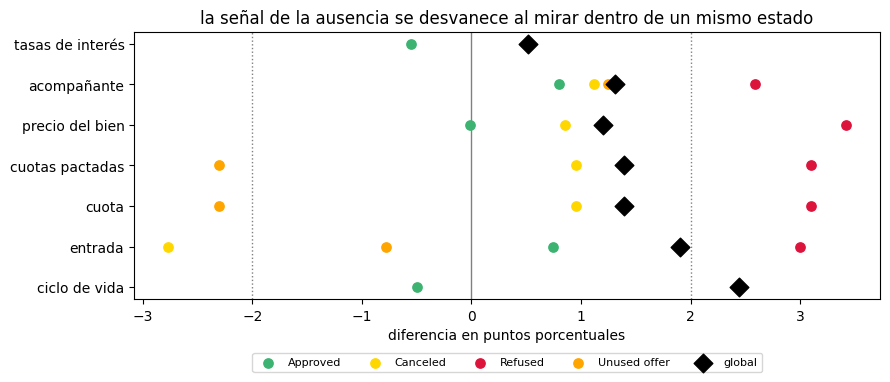

In [43]:
fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(condicionado))
for e, color in zip(ESTADOS, ["mediumseagreen", "gold", COLOR_DEF, "orange"]):
    ax.scatter(condicionado[e], y, s=45, color=color, label=e, zorder=3)
ax.scatter(condicionado["global"], y, s=90, color="black", marker="D", label="global", zorder=4)
ax.set_yticks(list(y))
ax.set_yticklabels(condicionado.index)
ax.axvline(0, color="gray", lw=1)
for x in (-2, 2):
    ax.axvline(x, color="gray", ls=":", lw=1)
ax.set(xlabel="diferencia en puntos porcentuales", ylabel="",
       title="la señal de la ausencia se desvanece al mirar dentro de un mismo estado")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()

Cruzar por primera vez esta tabla con el objetivo obliga a dos cautelas previas. La primera es que el
objetivo es heredado del cliente y cada uno aporta 4,86 solicitudes que comparten etiqueta, así que
con 1.413.701 filas cualquier diferencia sale significativa por volumen y decido por tamaño del
efecto, no por p-valor. La segunda es que el hueco no es toda la ausencia: contando el centinela de
las fechas se pasa de 6,59 a 7,50 columnas ausentes por fila, y sumando los códigos de no aplica se
llega a 11,87 de 37. Medir sobre el hueco solo habría dejado fuera un tercio de lo que falta.

Con la ausencia bien contada cruzan el umbral de dos puntos cuatro de las cinco fechas del ciclo de
vida más la bandera de seguro, con delta de +2,44pp a +2,69pp, y la quinta lo cruza en sentido
contrario: la primera disposición da -2,21pp. Hay además una columna diminuta con +11,48pp que merece
mirarse aparte.

Que dentro de un mismo bloque una columna vaya al revés obliga a volver sobre las máscaras, y lo que
sale es que el bloque ya no existe. Como hueco, las seis coinciden al 100%, que es como las clasifiqué
al mirar los tipos. Al sumar el centinela la primera disposición baja al 45,60% de coincidencia con la
primera cuota, 769.048 filas de diferencia, y la terminación y el último vencimiento se quedan en el
88,10% y el 89,61%. El centinela rompe el bloque, y de paso explica el signo: la ausencia real de la
primera disposición llega al 96,22% frente al 42,09% de la primera cuota porque está dominada por un
centinela que en esa columna no significa que falte el dato.

Mi hipótesis era que ese bloque de fechas sería
ausencia informativa, del tipo que en la tabla principal justificaba crear una bandera, porque no
saber cuándo empezó a pagarse un préstamo suena a información sobre cómo fue ese préstamo.

La verificación cruzada la refuta de forma bastante rotunda. La cuota y las cuotas pactadas faltan en
el 100% de las operaciones sin producto asignado, el precio del bien en el 100% de las que no tienen
producto o son tarjeta, la entrada en el 99,42% de las que no son crédito al consumo, y el ciclo de
vida en el 88,66% de las que no llegaron a aprobarse. No es que el dato se haya perdido: es que la
operación no llegó al punto de generarlo. Todo el bloque es ausencia por diseño del proceso,
explicada por variables que ya tengo delante.

Y como el estado discrimina por sí solo, de 7,59% en las aprobadas a 12,00% en las rechazadas, la
pregunta que decide qué hacer con estas columnas no es cuánto valen sino si valen algo una vez fijado
el estado. La respuesta es que casi nada. El ciclo de vida pasa de +2,44pp a -0,50pp dentro de las aprobadas, y
el precio del bien de +1,20pp a -0,01pp, que ya no se distingue de cero. El -0,50pp sigue saliendo
significativo, pero con 67.466 solicitudes lo raro sería lo contrario y media décima de punto no
cambia ninguna decisión: es significancia sin relevancia, y encima con el signo cambiado respecto a lo
que esperaba. Es el mismo patrón de señal prestada que me hizo descartar la flag de cierre con retraso
en el buró, solo que aquí afecta a un bloque entero. La entrada se comporta distinto y tampoco a
favor: +0,74pp en aprobadas y +3,00pp en rechazadas, los dos firmes, frente a un -2,77pp en canceladas
que no supera la corrección por comparaciones múltiples y que por tanto no sostengo. Aun descontando
ese, el contraste entre aprobadas y rechazadas ya dice que interactúa con el estado en lugar de tener
efecto propio, y una sola bandera la codificaría mal.

La excepción es el acompañante, que mantiene delta positivo en los cuatro estados (+0,80, +1,12,
+2,59 y +1,25pp), los tres primeros firmes tras la corrección y el cuarto solo por falta de muestra,
y es también el único bloque cuya ausencia no explican ni el estado ni el producto.
Lo miro aparte.

In [44]:
# ¿falta el dato o es que el evento todavía no ha ocurrido?
filas = []
for c in GRUPOS["temporal"][1:]:
    cen = pt[c].eq(CENTINELA)
    real = pt[c].notna() & ~cen
    filas.append({"fecha": c, "% centinela": round(cen.mean() * 100, 2),
                  "decisión mediana con centinela": pt.loc[cen, "DAYS_DECISION"].median(),
                  "decisión mediana con dato": pt.loc[real, "DAYS_DECISION"].median(),
                  "delta": round((pt.loc[cen, "TARGET"].mean() - pt.loc[real, "TARGET"].mean()) * 100, 2)})
display(pd.DataFrame(filas).set_index("fecha"))

real_disp = pt["DAYS_FIRST_DRAWING"].notna() & ~pt["DAYS_FIRST_DRAWING"].eq(CENTINELA)
print(f"primera disposición con dato real: "
      f"{pt.loc[real_disp, 'NAME_CONTRACT_TYPE'].eq('Revolving loans').mean() * 100:.2f}% son revolving")
print(f"terminación con centinela: {pt['DAYS_TERMINATION'].eq(CENTINELA).sum():,} filas, "
      f"y su operación es {-pt.loc[pt['DAYS_TERMINATION'].eq(CENTINELA), 'DAYS_DECISION'].median() / 365.25:.1f} "
      f"años más reciente que la mediana con dato")

,% centinela,decisión mediana con centinela,decisión mediana con dato,delta
fecha,,,,
DAYS_FIRST_DRAWING,56.52,-883.0,-692.0,-3.41
DAYS_FIRST_DUE,2.40,-274.0,-903.0,-0.94
DAYS_LAST_DUE_1ST_VERSION,5.60,-552.0,-905.0,1.62
DAYS_LAST_DUE,12.79,-306.0,-1102.0,1.13
DAYS_TERMINATION,13.72,-325.0,-1092.0,1.07


primera disposición con dato real: 99.99% son revolving
terminación con centinela: 194,000 filas, y su operación es 0.9 años más reciente que la mediana con dato


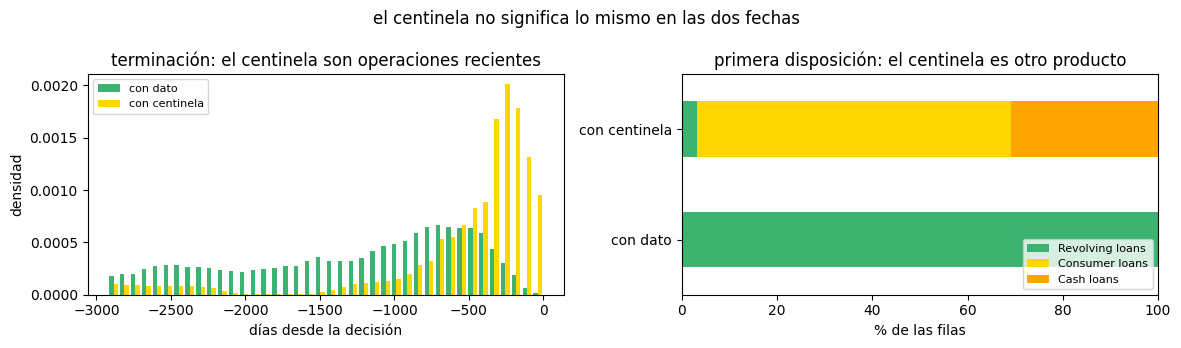

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
cen = pt["DAYS_TERMINATION"].eq(CENTINELA)
real = pt["DAYS_TERMINATION"].notna() & ~cen
ax[0].hist([pt.loc[real, "DAYS_DECISION"], pt.loc[cen, "DAYS_DECISION"]], bins=40,
           density=True, color=["mediumseagreen", "gold"], label=["con dato", "con centinela"])
ax[0].set(xlabel="días desde la decisión", ylabel="densidad",
          title="terminación: el centinela son operaciones recientes")
ax[0].legend(fontsize=8)

cen2 = pt["DAYS_FIRST_DRAWING"].eq(CENTINELA)
real2 = pt["DAYS_FIRST_DRAWING"].notna() & ~cen2
mix = pd.DataFrame({"con dato": pt.loc[real2, "NAME_CONTRACT_TYPE"].value_counts(normalize=True) * 100,
                    "con centinela": pt.loc[cen2, "NAME_CONTRACT_TYPE"].value_counts(normalize=True) * 100})
mix.loc[["Revolving loans", "Consumer loans", "Cash loans"]].T.plot.barh(
    stacked=True, ax=ax[1], color=["mediumseagreen", "gold", "orange"])
ax[1].set(xlabel="% de las filas", xlim=(0, 100),
          title="primera disposición: el centinela es otro producto")
ax[1].legend(fontsize=8, loc="lower right")
fig.suptitle("el centinela no significa lo mismo en las dos fechas")
plt.tight_layout()
plt.show()

In [46]:
# el acompañante es el único bloque que no explican ni el estado ni el producto
sin_acomp = falta["NAME_TYPE_SUITE"]
antiguedad = pd.cut(-pt["DAYS_DECISION"] / 365.25, [0, 1, 2, 3, 5, 8],
                    labels=["menos de 1 año", "1 a 2", "2 a 3", "3 a 5", "5 a 8"])
epoca = pd.DataFrame({"solicitudes": sin_acomp.groupby(antiguedad, observed=True).size(),
                      "% sin dato": (sin_acomp.groupby(antiguedad, observed=True).mean() * 100).round(2)})
display(epoca)
canal = (sin_acomp.groupby(pt["CHANNEL_TYPE"], observed=True).mean() * 100).round(2).sort_values()
print("% sin dato por canal: " + " | ".join(f"{k} {v}%" for k, v in canal.items()))

# si la señal aguanta con estado y canal fijos, es propia
for canal_fijo in ["Credit and cash offices", "Country-wide"]:
    s = pt["NAME_CONTRACT_STATUS"].eq("Approved") & pt["CHANNEL_TYPE"].eq(canal_fijo)
    d = (pt.loc[s & sin_acomp, "TARGET"].mean() - pt.loc[s & ~sin_acomp, "TARGET"].mean()) * 100
    print(f"aprobadas por {canal_fijo}: n={int(s.sum()):,}, delta {d:+.2f}pp")

tasa_acomp = (pt.groupby(pt["NAME_TYPE_SUITE"].astype("string").fillna("sin dato"), observed=True)["TARGET"]
              .agg(solicitudes="size", tasa="mean"))
tasa_acomp["% default"] = (tasa_acomp.pop("tasa") * 100).round(2)
display(tasa_acomp.sort_values("% default"))

,solicitudes,% sin dato
DAYS_DECISION,,
menos de 1 año,500812,60.39
1 a 2,309105,78.91
2 a 3,179071,21.94
3 a 5,198920,23.10
5 a 8,225793,27.93


% sin dato por canal: Channel of corporate sales 26.54% | Regional / Local 28.65% | Stone 32.55% | Country-wide 43.26% | AP+ (Cash loan) 46.4% | Credit and cash offices 60.62% | Contact center 62.32% | Car dealer 93.6%
aprobadas por Credit and cash offices: n=244,475, delta +0.93pp
aprobadas por Country-wide: n=344,456, delta +0.91pp


,solicitudes,% default
NAME_TYPE_SUITE,,
Children,27106,6.36
Family,181880,7.47
"Spouse, partner",57586,8.22
Unaccompanied,427635,8.28
Other_B,15073,8.49
Other_A,7820,8.71
Group of people,1929,8.86
sin dato,694672,9.32


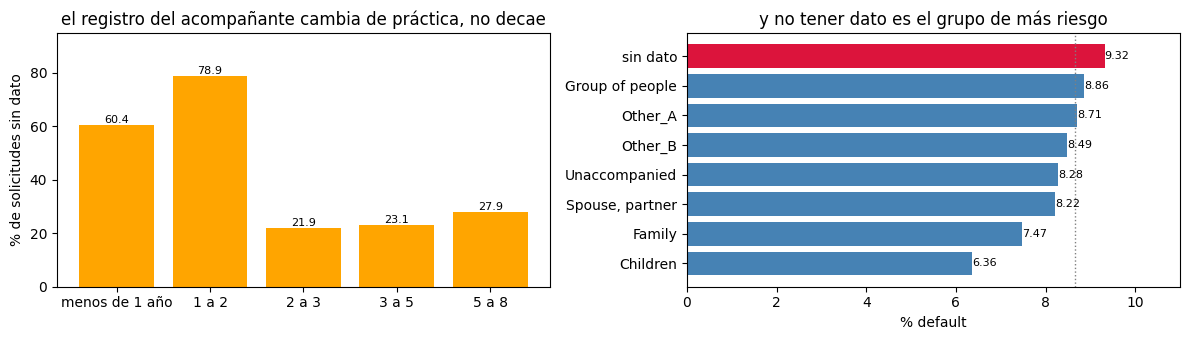

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(epoca.index.astype(str), epoca["% sin dato"], color="orange")
ax[0].bar_label(ax[0].containers[0], fmt="%.1f", fontsize=8)
ax[0].set(ylabel="% de solicitudes sin dato", ylim=(0, 95),
          title="el registro del acompañante cambia de práctica, no decae")
t = tasa_acomp.sort_values("% default")
ax[1].barh(t.index, t["% default"],
           color=[COLOR_DEF if i == "sin dato" else COLOR_NODEF for i in t.index])
ax[1].bar_label(ax[1].containers[0], fmt="%.2f", fontsize=8)
ax[1].axvline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[1].set(xlabel="% default", xlim=(0, 11), title="y no tener dato es el grupo de más riesgo")
plt.tight_layout()
plt.show()

In [48]:
# el acompañante también se registra en la solicitud actual: ¿aporta algo la versión de las previas?
suite_hoy = train.set_index("SK_ID_CURR")["NAME_TYPE_SUITE"]
print(f"sin acompañante: {suite_hoy.isna().mean() * 100:.2f}% en la solicitud actual frente al "
      f"{sin_acomp.mean() * 100:.2f}% en las previas")

por_cliente = sin_acomp.groupby(pt["SK_ID_CURR"]).mean()
todas_sin = por_cliente.index[por_cliente.eq(1)]
print(f"clientes sin acompañante en ninguna de sus previas: {len(todas_sin):,}, y de ellos "
      f"{int(suite_hoy.reindex(todas_sin).isna().sum())} tampoco lo tienen hoy")

ultima = pt.loc[pt.groupby("SK_ID_CURR")["DAYS_DECISION"].idxmax()]
par = pd.DataFrame({"previa": ultima.set_index("SK_ID_CURR")["NAME_TYPE_SUITE"].astype("string")})
par["actual"] = suite_hoy.reindex(par.index).astype("string")
par = par.dropna()
print(f"cuando existe en las dos, la última previa coincide con la actual en el "
      f"{par['previa'].eq(par['actual']).mean() * 100:.2f}% de los {len(par):,} pares comparables")

sin acompañante: 0.42% en la solicitud actual frente al 49.14% en las previas
clientes sin acompañante en ninguna de sus previas: 45,467, y de ellos 154 tampoco lo tienen hoy


cuando existe en las dos, la última previa coincide con la actual en el 58.14% de los 122,056 pares comparables


In [49]:
# la ausencia más pequeña de la tabla es la de mayor delta
sin_combi = falta["PRODUCT_COMBINATION"]
print(f"filas sin combinación de producto: {sin_combi.sum()} ({pt.loc[sin_combi, 'SK_ID_CURR'].nunique()} clientes) | "
      f"tasa {pt.loc[sin_combi, 'TARGET'].mean() * 100:.2f}% frente a {pt.loc[~sin_combi, 'TARGET'].mean() * 100:.2f}%")
print(f"coinciden con el tipo de contrato sin informar: "
      f"{(sin_combi == pt['NAME_CONTRACT_TYPE'].eq('XNA')).mean() * 100:.2f}% de las filas")
for c in ["NAME_CONTRACT_STATUS", "NAME_PORTFOLIO", "CHANNEL_TYPE", "NAME_CLIENT_TYPE"]:
    vc = (pt.loc[sin_combi, c].value_counts(normalize=True) * 100).round(2)
    print(f"  {c:22s} " + " | ".join(f"{k}: {v}%" for k, v in vc.head(2).items()))

# ¿es señal propia o la hereda de estar canceladas?
canc = pt["NAME_CONTRACT_STATUS"].eq("Canceled")
print(f"dentro de las canceladas: {pt.loc[canc & sin_combi, 'TARGET'].mean() * 100:.2f}% "
      f"(n={int((canc & sin_combi).sum())}) frente a {pt.loc[canc & ~sin_combi, 'TARGET'].mean() * 100:.2f}%")

# el otro extremo de la tabla maestra es un artefacto de tamaño
print(f"\nimporte de crédito sin dato: {int(falta['AMT_CREDIT'].sum())} fila, "
      "su delta no es interpretable y se elimina")

filas sin combinación de producto: 313 (284 clientes) | tasa 20.13% frente a 8.65%
coinciden con el tipo de contrato sin informar: 100.00% de las filas
  NAME_CONTRACT_STATUS   Canceled: 90.73% | Refused: 9.27%
  NAME_PORTFOLIO         XNA: 100.0% | Cards: 0.0%
  CHANNEL_TYPE           Country-wide: 98.72% | Credit and cash offices: 0.96%
  NAME_CLIENT_TYPE       Repeater: 86.26% | Refreshed: 7.03%
dentro de las canceladas: 19.72% (n=284) frente a 9.16%

importe de crédito sin dato: 1 fila, su delta no es interpretable y se elimina


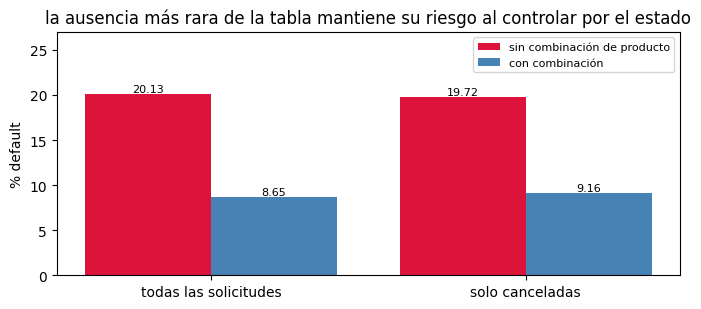

In [50]:
fig, ax = plt.subplots(figsize=(7, 3.2))
grupos = ["todas las solicitudes", "solo canceladas"]
sin = [pt.loc[sin_combi, "TARGET"].mean() * 100, pt.loc[canc & sin_combi, "TARGET"].mean() * 100]
con = [pt.loc[~sin_combi, "TARGET"].mean() * 100, pt.loc[canc & ~sin_combi, "TARGET"].mean() * 100]
x = range(len(grupos))
ax.bar([i - 0.2 for i in x], sin, 0.4, color=COLOR_DEF, label="sin combinación de producto")
ax.bar([i + 0.2 for i in x], con, 0.4, color=COLOR_NODEF, label="con combinación")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(grupos)
ax.set(ylabel="% default", ylim=(0, 27),
       title="la ausencia más rara de la tabla mantiene su riesgo al controlar por el estado")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

El centinela merecía mirarse de cerca porque hasta ahora lo había tratado como ausencia sin
preguntarme qué ausencia era, y resulta que no significa lo mismo en las dos fechas donde pesa. En la
terminación y en el último vencimiento, las operaciones marcadas con centinela se decidieron con
mediana de -325 y -306 días frente a -1.092 y -1.102 de las que sí tienen fecha: son 0,9 años más
recientes. No falta el dato de cuándo terminó el contrato, es que el contrato todavía no ha
terminado. Es censura por la derecha, la misma familia de problema que la ventana de observación del
histórico mensual del buró, y el tratamiento correcto no es imputar sino marcar la operación como
viva. En la primera disposición el mecanismo es otro: el 99,99% de las filas con fecha real son
revolving, así que el centinela significa que ese producto no tiene disposición inicial que
registrar, y su -2,21pp no es la ausencia sino la tarjeta.

El acompañante es el único bloque que no explican ni el estado ni el producto, y su ausencia tiene
dos causas ajenas al cliente. Una es la práctica de registro, que no decae con la antigüedad sino que
cambia de golpe: 60,39% sin dato en las solicitudes de menos de un año, 78,91% en las de uno a dos, y
luego 21,94% en las de dos a tres, sin recuperar el nivel después. Un dato que se pierde por olvido
decaería de forma monótona; esto es un cambio de criterio en un momento concreto. La otra es el
canal, del 26,54% en ventas corporativas al 60,62% en oficinas y el 93,60% en concesionario. Aun así
la señal sobrevive al doble control: fijando estado aprobado y canal, la ausencia sigue valiendo
+0,93pp por oficinas y +0,91pp por red nacional. Y hay una lectura de codificación que cierra el
asunto: la tasa de quien no tiene dato es 9,32%, la más alta de toda la variable, por encima del
8,28% de quien acude sin acompañante. El sin dato no se imputa con la moda porque no es la moda, es
la categoría de más riesgo, exactamente la decisión que tomé con esta misma variable en la tabla
principal.

Hay una comprobación más que cierra el asunto y que obliga a mirar fuera de esta tabla, porque el
acompañante también se registra en la solicitud que se está evaluando. Allí falta en el 0,42% de los
casos frente al 49,14% de aquí: la misma variable sobre la misma persona con ciento diecisiete veces
más ausencia, que confirma que lo que falla es la práctica de registro histórica y no el cliente. La
ausencia tampoco se hereda: de los 45.467 clientes que no tienen acompañante en ninguna de sus
solicitudes previas, solo 154 tampoco lo tienen hoy. Y cuando el dato existe en las dos, la última
solicitud previa coincide con la actual apenas en el 58,14% de los 122.056 pares comparables, así que
ni siquiera es un atributo estable de la persona. La consecuencia práctica es que de las solicitudes
previas interesa la ausencia y no el valor: el valor ya está, mejor registrado, en la solicitud que se
evalúa.

Queda la columna que salía disparada de la tabla maestra, y es el hallazgo que menos esperaba. Las
313 filas sin combinación de producto dan 20,13% frente al 8,65% del resto, y no es señal prestada
del estado: dentro de las canceladas, que son el 90,73% de ellas, siguen dando 19,72% frente a 9,16%.
Al mirar qué son resulta que coinciden al 100% con las 313 filas cuyo tipo de contrato tampoco está
informado, el residuo que al analizar las distribuciones mandé al mismo saco que las categorías
minoritarias por ser demasiado pequeño para sostener una categoría propia. Me equivocaba en la
consecuencia: son operaciones que no llegaron a definirse ni en su tipo ni en su producto, con
importes a cero, el 98,72% por red nacional y el 86,26% de clientes recurrentes, y son el grupo de
más riesgo de toda la tabla a nivel de solicitud. Reclasifico: no son residuo, son un registro
fantasma con señal propia. Cubren 284 clientes, el 0,098%, así que es severidad extrema con impacto
de cartera mínimo, el mismo perfil que el sobregiro de límite del buró.

In [51]:
# los códigos, medidos como ausencia: global y dentro de cada estado
filas = []
for col, valores in CODIGOS.items():
    for v in valores:
        m = pt[col].eq(v)
        d, p = delta_z(pt.loc[m, "TARGET"], pt.loc[~m, "TARGET"])
        emitidos += 1
        fila = {"columna": f"{col} = {v}", "% filas": round(m.mean() * 100, 2), "orden": d,
                "global": f"{d:+.2f}"}
        for e in ESTADOS[:3]:
            s = pt["NAME_CONTRACT_STATUS"].eq(e)
            a, b = pt.loc[s & m, "TARGET"], pt.loc[s & ~m, "TARGET"]
            if min(len(a), len(b)) > 200:
                d, p = delta_z(a, b)
                emitidos += 1
                fila[e] = f"{d:+.2f}" + ("" if p < alfa else " (ns)")
            else:
                fila[e] = ""
        filas.append(fila)
display(pd.DataFrame(filas).sort_values("orden").drop(columns="orden").set_index("columna"))
assert emitidos == familia, f"la familia declarada son {familia} y se han emitido {emitidos}"
print(f"contrastes emitidos en la sección: {emitidos}, que es la familia declarada")

,% filas,global,Approved,Canceled,Refused
columna,,,,,
CODE_REJECT_REASON = XAP,81.03,-3.73,,,
NAME_CASH_LOAN_PURPOSE = XAP,55.67,-0.85,+0.05 (ns),+2.22,-1.36
NAME_PRODUCT_TYPE = XNA,63.67,-0.83,-0.52,+0.99 (ns),-0.26 (ns)
NAME_CASH_LOAN_PURPOSE = XNA,40.13,+0.10,-0.53,-2.21,+0.00 (ns)
NAME_CLIENT_TYPE = XNA,0.11,+1.26,-0.46 (ns),+0.97 (ns),+1.58 (ns)
NAME_PORTFOLIO = XNA,21.73,+1.39,,+0.95 (ns),+3.10
NAME_SELLER_INDUSTRY = XNA,50.60,+1.42,+0.33,-5.53,+1.68
CODE_REJECT_REASON = XNA,0.31,+1.45,,,-1.92
NAME_PAYMENT_TYPE = XNA,36.99,+1.53,+0.93,+0.59 (ns),+2.61


contrastes emitidos en la sección: 79, que es la familia declarada


In [52]:
# ¿los bloques de ausencia son ejes independientes o grados del mismo hecho?
nombres = list(BLOQUES)
pares = []
for i, a in enumerate(nombres):
    for b in nombres[i + 1:]:
        ct = pd.crosstab(falta[BLOQUES[a]], falta[BLOQUES[b]])
        if ct.shape == (2, 2):
            v = (chi2_contingency(ct)[0] / len(pt)) ** 0.5
            pares.append({"bloque": a, "con": b, "V de Cramér": round(v, 4)})
tabla_v = pd.DataFrame(pares).sort_values("V de Cramér", ascending=False)
display(tabla_v.style.hide(axis="index"))  # los veintiuno: recortar a la cabeza engaña sobre el rango
sin_tasas = tabla_v[~tabla_v[["bloque", "con"]].isin(["tasas de interés"]).any(axis=1)]
print(f"{len(tabla_v)} pares, de {tabla_v['V de Cramér'].min():.4f} a {tabla_v['V de Cramér'].max():.4f} | "
      f"sin las tasas de interés, que se eliminan por cobertura: {len(sin_tasas)} pares, de "
      f"{sin_tasas['V de Cramér'].min():.4f} a {sin_tasas['V de Cramér'].max():.4f}")
NUCLEO = ["ciclo de vida", "cuota", "cuotas pactadas", "precio del bien"]
dentro = tabla_v[tabla_v["bloque"].isin(NUCLEO) & tabla_v["con"].isin(NUCLEO)]
fuera = sin_tasas[~(sin_tasas["bloque"].isin(NUCLEO) & sin_tasas["con"].isin(NUCLEO))]
print(f"los cuatro que el estado explica, entre sí: de {dentro['V de Cramér'].min():.4f} a "
      f"{dentro['V de Cramér'].max():.4f} | la entrada y el acompañante con el resto: de "
      f"{fuera['V de Cramér'].min():.4f} a {fuera['V de Cramér'].max():.4f}")

bloque,con,V de Cramér
cuota,cuotas pactadas,1.000000
cuotas pactadas,precio del bien,0.839800
cuota,precio del bien,0.839800
ciclo de vida,cuotas pactadas,0.618000
ciclo de vida,cuota,0.618000
precio del bien,acompañante,0.549700
ciclo de vida,precio del bien,0.537100
entrada,precio del bien,0.508700
cuota,acompañante,0.505200
cuotas pactadas,acompañante,0.505200


21 pares, de 0.0307 a 1.0000 | sin las tasas de interés, que se eliminan por cobertura: 15 pares, de 0.2523 a 1.0000
los cuatro que el estado explica, entre sí: de 0.5371 a 1.0000 | la entrada y el acompañante con el resto: de 0.2523 a 0.5497


In [53]:
# completitud de la fila contra el objetivo, en global y dentro de las aprobadas
tramos = pd.cut(falta.sum(axis=1), [0, 3, 6, 9, 12, 40],
                labels=["1 a 3", "4 a 6", "7 a 9", "10 a 12", "13 o más"])
aprobada = pt["NAME_CONTRACT_STATUS"].eq("Approved")
comp = pd.DataFrame({
    "solicitudes": pt.groupby(tramos, observed=True)["TARGET"].size(),
    "% default": (pt.groupby(tramos, observed=True)["TARGET"].mean() * 100).round(2),
    "solicitudes aprobadas": pt[aprobada].groupby(tramos[aprobada], observed=True)["TARGET"].size(),
    "% default aprobadas": (pt[aprobada].groupby(tramos[aprobada], observed=True)["TARGET"].mean() * 100).round(2),
})
display(comp)

# ¿la ausencia es del cliente o de la operación? de eso depende cómo se agrega
for nombre, col in [("ciclo de vida", "DAYS_FIRST_DUE"), ("acompañante", "NAME_TYPE_SUITE")]:
    g = (~falta[col]).groupby(pt["SK_ID_CURR"]).mean()
    print(f"{nombre}: {g.eq(1).mean() * 100:.2f}% de clientes con todas sus solicitudes informadas, "
          f"{g.eq(0).mean() * 100:.2f}% con ninguna y {((g > 0) & (g < 1)).mean() * 100:.2f}% con mezcla")

,solicitudes,% default,solicitudes aprobadas,% default aprobadas
1 a 3,335501,6.91,335501,6.91
4 a 6,378174,7.91,378174,7.91
7 a 9,205490,8.95,138234,8.53
10 a 12,219849,10.87,34187,6.88
13 o más,274687,9.82,3,33.33


ciclo de vida: 37.73% de clientes con todas sus solicitudes informadas, 0.63% con ninguna y 61.64% con mezcla
acompañante: 19.50% de clientes con todas sus solicitudes informadas, 15.62% con ninguna y 64.88% con mezcla


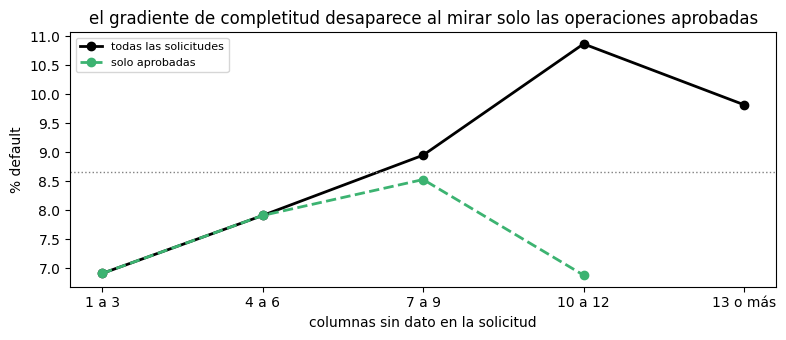

el último tramo no se dibuja para las aprobadas: solo tiene 3 solicitudes


In [54]:
fig, ax = plt.subplots(figsize=(8, 3.5))
tramo = comp.index.astype(str)
aprobadas = comp["% default aprobadas"].where(comp["solicitudes aprobadas"] >= 1000)
ax.plot(tramo, comp["% default"], "o-", color="black", lw=2, label="todas las solicitudes")
ax.plot(tramo, aprobadas, "o--", color="mediumseagreen", lw=2, label="solo aprobadas")
ax.axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax.set(xlabel="columnas sin dato en la solicitud", ylabel="% default",
       title="el gradiente de completitud desaparece al mirar solo las operaciones aprobadas")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("el último tramo no se dibuja para las aprobadas: solo tiene "
      f"{int(comp['solicitudes aprobadas'].iloc[-1])} solicitudes")

In [55]:
# tres comprobaciones que condicionan cómo se agrega esto, antes de dar la sección por cerrada
print(f"validez temporal: la decisión más reciente es de hace {-pt['DAYS_DECISION'].max()} día, "
      "así que todo lo que hay aquí es anterior a la solicitud que se evalúa")
for c in GRUPOS["temporal"][1:]:
    real = pt[c].where(pt[c].ne(CENTINELA))
    print(f"  {c:26s} fechas posteriores a la solicitud: {int(real.gt(0).sum()):,}")

# ¿la completitud agregada sería una variable nueva o una copia de la tasa de aprobación?
cli = pd.DataFrame({
    "PCT_CON_CICLO": (~falta["DAYS_FIRST_DUE"]).groupby(pt["SK_ID_CURR"]).mean(),
    "PCT_APROBADAS": pt["NAME_CONTRACT_STATUS"].eq("Approved").groupby(pt["SK_ID_CURR"]).mean(),
    "CONTRATOS_VIVOS": pt["DAYS_TERMINATION"].eq(CENTINELA).groupby(pt["SK_ID_CURR"]).sum(),
})
cli["TARGET"] = train.set_index("SK_ID_CURR")["TARGET"].reindex(cli.index).values
print(f"\nPearson entre completitud y proporción de aprobadas por cliente: "
      f"{cli['PCT_CON_CICLO'].corr(cli['PCT_APROBADAS']):.4f}")

# instancia aparte: son comprobaciones de redundancia, no el ranking de features
ev_aux = EvaluadorSenal(cli, cli["TARGET"])
ev_aux.evaluar_continuas([("PCT_CON_CICLO", False, None, "con previas"),
                          ("PCT_APROBADAS", False, None, "con previas"),
                          ("CONTRATOS_VIVOS", False, None, "con previas")])

# el centinela resultó ser contrato vivo: ¿es el equivalente al conteo de créditos activos del buró?
tramos = pd.cut(cli["CONTRATOS_VIVOS"], [-1, 0, 1, 2, 3, 100], labels=["0", "1", "2", "3", "4 o más"])
vivos = cli.groupby(tramos, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
vivos["% default"] = (vivos.pop("tasa") * 100).round(2)
display(vivos)
print(f"clientes con algún contrato previo vivo: {cli['CONTRATOS_VIVOS'].gt(0).mean() * 100:.2f}%")

validez temporal: la decisión más reciente es de hace 1 día, así que todo lo que hay aquí es anterior a la solicitud que se evalúa
  DAYS_FIRST_DRAWING         fechas posteriores a la solicitud: 0
  DAYS_FIRST_DUE             fechas posteriores a la solicitud: 0
  DAYS_LAST_DUE_1ST_VERSION  fechas posteriores a la solicitud: 194,538
  DAYS_LAST_DUE              fechas posteriores a la solicitud: 0
  DAYS_TERMINATION           fechas posteriores a la solicitud: 0



Pearson entre completitud y proporción de aprobadas por cliente: 0.9205


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PCT_CON_CICLO,con previas,291057,0.1085,2.5321546421160037e-180,0.7,0.7
PCT_APROBADAS,con previas,291057,0.1179,1.455027048713269e-218,0.8,0.7
CONTRATOS_VIVOS,con previas,291057,0.0118,0.0009364466931055103,1.0,1.0


,clientes,% default
CONTRATOS_VIVOS,,
0,141123,8.05
1,110693,8.26
2,34778,8.41
3,4104,9.26
4 o más,359,13.65


clientes con algún contrato previo vivo: 51.51%


In [56]:
# el estado explica casi toda la ausencia, así que antes de cerrar compruebo si el estado es estable
semestre = (-pt["DAYS_DECISION"] // 183).astype(int)
mezcla = (pt.assign(s=semestre).groupby("s", observed=True)["NAME_CONTRACT_STATUS"]
          .value_counts(normalize=True).unstack() * 100).round(2)
mezcla.index = [f"{i * 6} a {(i + 1) * 6} meses" for i in mezcla.index]
display(mezcla[ESTADOS].head(8))

# si el estado deriva, la proporción por cliente hereda esa deriva
por_cli = pd.DataFrame({
    "PCT_CANCELADAS": pt["NAME_CONTRACT_STATUS"].eq("Canceled").groupby(pt["SK_ID_CURR"]).mean(),
    "PCT_APROBADAS": pt["NAME_CONTRACT_STATUS"].eq("Approved").groupby(pt["SK_ID_CURR"]).mean(),
    "RECENCIA": pt.groupby("SK_ID_CURR")["DAYS_DECISION"].max(),
})
por_cli["TARGET"] = train.set_index("SK_ID_CURR")["TARGET"].reindex(por_cli.index).values
print(f"Pearson con la recencia de la última solicitud: canceladas "
      f"{por_cli['PCT_CANCELADAS'].corr(por_cli['RECENCIA']):.4f} | "
      f"aprobadas {por_cli['PCT_APROBADAS'].corr(por_cli['RECENCIA']):.4f}")

tramo_rec = pd.cut(-por_cli["RECENCIA"] / 365.25, [0, 0.5, 1, 2, 3, 8],
                   labels=["menos de 6 meses", "6 meses a 1 año", "1 a 2 años", "2 a 3", "3 a 8"])
res = por_cli.groupby(tramo_rec, observed=True).agg(
    clientes=("TARGET", "size"), canceladas=("PCT_CANCELADAS", "mean"),
    aprobadas=("PCT_APROBADAS", "mean"), tasa=("TARGET", "mean"))
for c in ["canceladas", "aprobadas", "tasa"]:
    res[c] = (res[c] * 100).round(2)
display(res)

NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
0 a 6 meses,28.78,51.74,18.07,1.41
6 a 12 meses,36.88,40.86,21.28,0.98
12 a 18 meses,60.35,17.74,20.43,1.48
18 a 24 meses,80.60,0.61,16.85,1.94
24 a 30 meses,84.16,0.05,13.82,1.97
30 a 36 meses,83.86,0.04,13.87,2.23
36 a 42 meses,81.65,0.04,15.42,2.89
42 a 48 meses,82.86,0.02,13.66,3.46


Pearson con la recencia de la última solicitud: canceladas 0.3937 | aprobadas -0.3574


,clientes,canceladas,aprobadas,tasa
RECENCIA,,,,
menos de 6 meses,91335,23.84,61.35,8.89
6 meses a 1 año,77650,16.25,69.77,8.49
1 a 2 años,67804,2.96,86.07,7.57
2 a 3,25116,0.03,90.79,7.26
3 a 8,29152,0.04,91.20,7.47


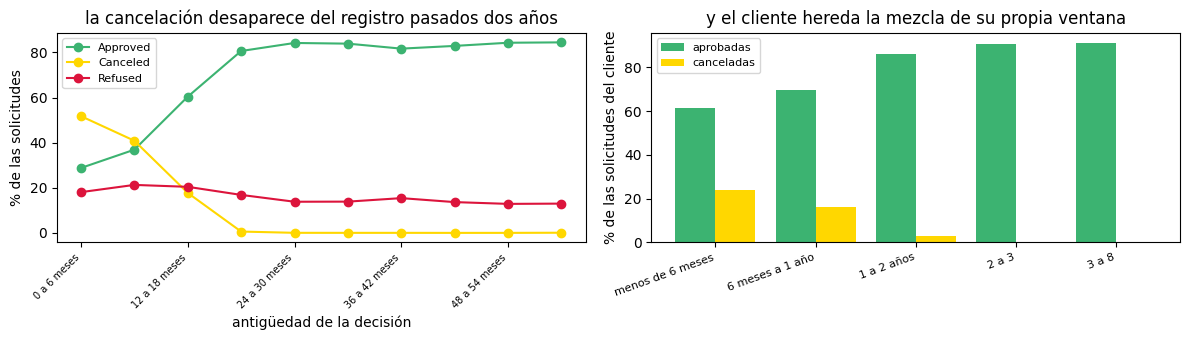

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
mezcla[ESTADOS[:3]].head(10).plot(ax=ax[0], marker="o",
                                  color=["mediumseagreen", "gold", COLOR_DEF])
ax[0].set(xlabel="antigüedad de la decisión", ylabel="% de las solicitudes",
          title="la cancelación desaparece del registro pasados dos años")
plt.setp(ax[0].get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax[0].legend(fontsize=8)

x = range(len(res))
ax[1].bar([i - 0.2 for i in x], res["aprobadas"], 0.4, color="mediumseagreen", label="aprobadas")
ax[1].bar([i + 0.2 for i in x], res["canceladas"], 0.4, color="gold", label="canceladas")
ax[1].set_xticks(list(x))
ax[1].set_xticklabels(res.index, rotation=20, ha="right", fontsize=8)
ax[1].set(ylabel="% de las solicitudes del cliente",
          title="y el cliente hereda la mezcla de su propia ventana")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Medidos como ausencia, los códigos de no aplica repiten el patrón del bloque de fechas. El único que
aguanta dentro de los tres estados con muestra es el tramo de interés sin informar, con +1,59, +1,22
y +2,17pp, aunque en banda débil. La industria del vendedor es el caso más claro de por qué no basta
el delta global: da +1,42pp en conjunto y -5,53pp dentro de las canceladas, o sea que no solo pierde
la señal al condicionar sino que la invierte. Y el motivo de rechazo sin aplicar da -3,73pp que no
son suyos: ese código es literalmente "la operación no se rechazó", así que está midiendo el estado
con otro nombre.

Los bloques de ausencia tampoco son ejes independientes, pero la V de Cramér lo dice con bastante
menos uniformidad de la que sugiere mirar la cabeza de la tabla. Los veintiún pares recorren de
0,0307 a 1,0000, y las tasas de interés no se parecen a ningún otro bloque, con un máximo de 0,0619,
lo que era esperable en una columna informada en el 0,36% de las filas. Quitándolas quedan quince
pares entre 0,2523 y 1,0000. Ese 1,0000 es redondeo y no
identidad, y conviene pararse en él porque es justo el par que ya había separado al comparar
máscaras: difieren en 5 filas de 1.670.214, así que comparten porcentaje sin fallar en las mismas
filas. Con cuatro decimales la V los devuelve al mismo saco, de modo que para decidir si dos columnas
son un bloque manda la comparación de máscaras y no un estadístico de asociación redondeado. Lo que
la V sí decide es lo otro, que estos bloques son grados del mismo hecho y no fenómenos distintos, y
eso invierte lo que decidí en el buró, donde los tres bloques daban V por debajo de 0,10 y
justificaban tres banderas separadas. Aquí hay dos grupos y no uno. Los cuatro que el estado explica
de forma casi determinista, el ciclo de vida, la cuota, las cuotas pactadas y el precio del bien, son
un núcleo apretado que no baja de 0,5371 entre ellos, y para esos cuatro banderas serían cuatro
copias de la misma y lo que corresponde es una sola. La entrada y el acompañante se quedan fuera de
ese núcleo: ninguna pasa de 0,5497 con él y entre ellas dan 0,2523, la V más baja de las quince. Y no
es casualidad que sean justo las dos que no acabo despachando como señal prestada, porque la de la
entrada interactúa con el estado en vez de tener efecto propio y la del acompañante mantiene delta
positivo en los cuatro estados y entra como categoría de riesgo por derecho propio. Recortar la tabla
a los pares de arriba habría dado por homogéneo lo que no lo es.

La completitud de la fila lo confirma desde el lado del objetivo. En conjunto traza un gradiente casi
monótono, del 6,91% con hasta tres columnas ausentes al 10,87% con diez a doce, y dentro de las
aprobadas se rompe: 6,91%, 7,91%, 8,53% y 6,88%, sin tramo final utilizable porque solo quedan tres
solicitudes. La completitud no mide al cliente, mide hasta dónde llegó la operación.

Falta una comprobación que condiciona cómo se agrega todo esto, y es si la ausencia es propiedad del
cliente o de la operación. Es de la operación, y de forma abrumadora: el 61,64% de los clientes tiene
algunas solicitudes con ciclo de vida y otras sin él, y con el acompañante son el 64,88%. Es el caso
contrario al histórico mensual del buró, donde el 99,78% de los clientes tenía cobertura completa y
por eso una bandera agregada era interpretable. Aquí una bandera de presencia diría que este cliente
tiene alguna solicitud sin dato y eso lo cumple casi todo el mundo, así que lo que hay que llevar al
nivel de cliente son proporciones, no presencias.

Antes de cerrar quedan tres comprobaciones que no cambian el diagnóstico pero sí condicionan cómo se
lleva todo esto al nivel de cliente. La primera es la validez temporal, que en una tabla de historial
conviene dejar dicha y no darla por supuesta: la decisión más reciente registrada es de hace un día,
así que todo lo que hay aquí es anterior a la solicitud que se evalúa, y ninguna fecha de hecho
consumado apunta al futuro. La única excepción son las 194.538 filas con vencimiento previsto
posterior a la solicitud, y no es fuga porque ese vencimiento se conoce al firmar: es un plan, no un
resultado.

La segunda es la que más me preocupaba, porque de todo lo anterior sale de forma natural la idea de
llevar la completitud al nivel de cliente, y esa variable sería una copia. La proporción de
solicitudes con ciclo de vida correlaciona 0,9205 con la proporción de aprobadas del mismo cliente y
rinde menos que ella, 0,1085 frente a 0,1179: no es información nueva, es la tasa de aprobación
medida por el reverso y con peor resolución. Descarto construirla, y lo que hay que llevar al nivel
de cliente es la aprobación directamente.

La tercera refuta una expectativa. Al identificar el centinela como contrato todavía vivo di por
hecho que contar contratos vivos por cliente sería aquí lo que el conteo de créditos activos es en el
buró, que era el conteo con más señal de aquella tabla. No lo es: rinde 0,0118 y su gradiente es casi
plano, del 8,05% sin ninguno al 8,41% con dos. Solo el extremo marca, con 13,65% a partir de cuatro,
y son 359 clientes. Tiene sentido que sea así, porque la exposición viva con el propio prestamista ya
pasó por su filtro de riesgo, mientras que la del buró es exposición que el prestamista no vio. Si
esa variable entra más adelante será como bandera de cola y no como conteo, igual que pasó con el
número de créditos con histórico mensual.

Un último control antes de cerrar, y es el que más consecuencias tiene para lo que venga. Si el estado
de la operación explica casi toda la ausencia, hay que preguntarse si ese estado es estable en el
tiempo, porque si no lo es la ausencia hereda su deriva. No lo es, y no por poco: la cancelación pasa
del 51,74% de las solicitudes de los últimos seis meses al 17,74% entre los doce y los dieciocho
meses, y a partir de los dos años desaparece del registro, con un 0,05% que ya no se mueve. No es que
los clientes dejaran de cancelar hace dos años, es que la operación cancelada no sobrevive en el
histórico pasado ese tiempo. El rechazo se comporta al revés y se mantiene entre el 13,66% y el
21,28% en toda la ventana, así que la deriva afecta a un estado y no a los cuatro.

La consecuencia recae justo sobre lo que más promete de esta tabla. La proporción de canceladas de un
cliente correlaciona 0,3937 con la recencia de su última solicitud y la de aprobadas -0,3574: quien
pidió hace más de dos años tiene el 91,20% de aprobadas y prácticamente ninguna cancelada, frente al
61,35% y el 23,84% de quien pidió hace menos de seis meses. La proporción de canceladas no mide
comportamiento sino cuándo solicitó, así que no la construyo. La de aprobadas o rechazos sí mide algo
real, pero llega contaminada por la ventana de cada cliente y habrá que medirla controlando por
recencia en vez de en crudo. Y como el estado gobierna la ausencia, la deriva se propaga a ella: otra
razón, además de la redundancia que ya vi, para no llevar la completitud al nivel de cliente.

Una nota sobre el alfa con el que marco lo que no se sostiene. La familia cuenta cada contraste que
emito y no cada columna, que es el mismo criterio con el que corrijo al mirar correlaciones, tiempo y
valores extremos: setenta y nueve en total, dieciséis por columna con ausencia, veintiséis por bloque
y treinta y siete de los códigos, y el propio código comprueba que la cuenta declarada coincide con
la emitida. Contando columnas habrían salido veintisiete y un alfa tres veces más laxo, y la
diferencia no es cosmética: con el recuento estricto el importe de crédito deja de aparecer entre lo
que cruza a la vez los dos puntos y la significancia, que es lo correcto, porque su delta de +91,34pp
sale de una única fila sin dato. Lo que decide sigue siendo el tamaño del efecto y no el p-valor.

El balance de las 16 columnas con hueco: 11 son ausencia determinista por proceso o por producto y su
señal es prestada del estado; 2 son las tasas de interés, sin señal medible (+0,52pp con p de 0,20) y
ya candidatas a eliminación por informarse en el 0,36% de las filas; 2 tienen señal propia, el
acompañante como categoría de riesgo y la combinación de producto como registro fantasma; y 1 es un
artefacto de una sola fila. Ninguna genera bandera de ausencia por sí sola salvo esas dos, y el
centinela sale de aquí convertido en otra cosa: no en dato que falta, sino en contrato todavía
vivo.

### 6. Análisis Correlaciones

In [58]:
# ¿el importe habla del riesgo, o lo que hablaba era el estado de la operación?
# el cero es estado y no cantidad, así que mido cada magnitud en tres poblaciones
aprobada = pt["NAME_CONTRACT_STATUS"].eq("Approved")


def senal(s, mask=None):
    """n, Pearson, Spearman y rank-biserial de una continua contra el objetivo heredado."""
    v = (s if mask is None else s.where(mask)).dropna()
    y = pt["TARGET"].loc[v.index]
    x0, x1 = v[y == 0], v[y == 1]
    u, p = mannwhitneyu(x0, x1)
    return {"n": len(v), "Pearson": pearsonr(v, y)[0], "Spearman": spearmanr(v, y)[0],
            "r_rb": abs(2 * u / (len(x0) * len(x1)) - 1), "p": p}


filas = []
for c in MAGNITUDES:
    limpia = pt[c].where(pt[c].ne(0)) if c in CEROS else pt[c]
    crudo, real, apr = senal(pt[c]), senal(limpia), senal(limpia, aprobada)
    filas.append({"magnitud": c, "n con dato real": real["n"],
                  "r_rb crudo": round(crudo["r_rb"], 4),
                  "r_rb dato real": round(real["r_rb"], 4),
                  "r_rb aprobadas": round(apr["r_rb"], 4),
                  "Pearson dato real": round(real["Pearson"], 4),
                  "Spearman dato real": round(real["Spearman"], 4)})
magnitudes = pd.DataFrame(filas).set_index("magnitud").sort_values("r_rb dato real", ascending=False)
display(magnitudes)

print(f"cada cliente aporta {len(pt) / pt['SK_ID_CURR'].nunique():.2f} solicitudes que comparten "
      "etiqueta, así que decido por tamaño del efecto y no por p-valor")

,n con dato real,r_rb crudo,r_rb dato real,r_rb aprobadas,Pearson dato real,Spearman dato real
magnitud,,,,,,
CNT_PAYMENT,984503,0.0428,0.0891,0.0526,0.0459,0.0428
AMT_DOWN_PAYMENT,664161,0.0612,0.0612,0.0568,-0.0169,-0.0298
RATE_DOWN_PAYMENT,664161,0.0555,0.0555,0.0481,-0.0260,-0.0270
RATE_INTEREST_PRIVILEGED,4791,0.0505,0.0505,0.0505,0.0286,0.0244
RATE_INTEREST_PRIMARY,4791,0.0283,0.0283,0.0283,-0.0015,0.0135
AMT_ANNUITY,1105243,0.0272,0.0268,0.0566,-0.0148,-0.0128
AMT_CREDIT,1137123,0.0221,0.0110,0.0270,0.0046,0.0053
AMT_APPLICATION,1088399,0.0275,0.0014,0.0415,0.0003,-0.0007
AMT_GOODS_PRICE,1088416,0.0018,0.0013,0.0415,0.0004,-0.0006


cada cliente aporta 4.86 solicitudes que comparten etiqueta, así que decido por tamaño del efecto y no por p-valor


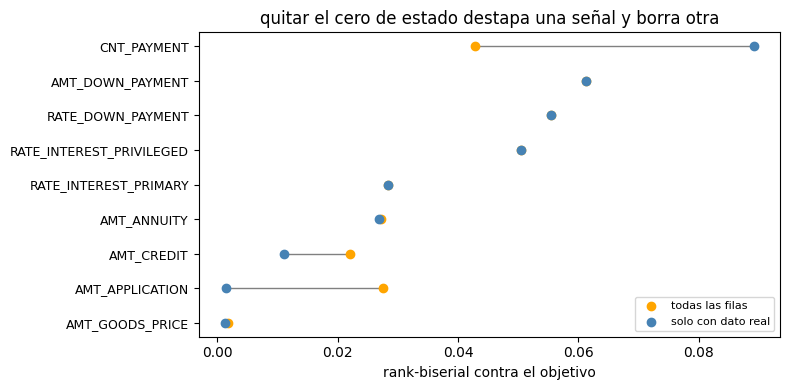

In [59]:
# limpiar el cero mueve la señal en las dos direcciones, así que las comparo pareadas
orden = magnitudes.sort_values("r_rb dato real")
fig, ax = plt.subplots(figsize=(8, 4))
for i, (crudo, limpio) in enumerate(zip(orden["r_rb crudo"], orden["r_rb dato real"])):
    ax.plot([crudo, limpio], [i, i], color="gray", lw=1, zorder=1)
ax.scatter(orden["r_rb crudo"], range(len(orden)), color="orange", zorder=2, label="todas las filas")
ax.scatter(orden["r_rb dato real"], range(len(orden)), color=COLOR_NODEF, zorder=2,
           label="solo con dato real")
ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden.index, fontsize=9)
ax.set(xlabel="rank-biserial contra el objetivo", ylabel="",
       title="quitar el cero de estado destapa una señal y borra otra")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [60]:
# ¿cuántas de las magnitudes de tamaño son en realidad la misma variable?
limpias = pd.DataFrame({c: pt[c].where(pt[c].ne(0)) if c in CEROS else pt[c]
                        for c in MAGNITUDES if not c.startswith("RATE_INTEREST")})
corr = limpias.corr()
pares = [{"par": f"{a} y {b}", "Pearson": round(corr.loc[a, b], 4)}
         for a, b in combinations(corr.columns, 2) if abs(corr.loc[a, b]) > 0.70]
display(pd.DataFrame(pares).sort_values("Pearson", key=abs, ascending=False).style.hide(axis="index"))

ambas = pt["AMT_APPLICATION"].gt(0) & pt["AMT_GOODS_PRICE"].notna()
iguales = pt.loc[ambas, "AMT_APPLICATION"].eq(pt.loc[ambas, "AMT_GOODS_PRICE"])
print(f"el precio del bien coincide con lo solicitado en el {iguales.mean() * 100:.4f}% de las "
      f"{int(ambas.sum()):,} filas con las dos cifras, y solo difiere en {int((~iguales).sum())}")
print(f"cobertura distinta: precio sin dato {pt['AMT_GOODS_PRICE'].isna().mean() * 100:.2f}% | "
      f"solicitado a cero {pt['AMT_APPLICATION'].eq(0).mean() * 100:.2f}% | "
      f"filas con solicitado a cero y precio informado {int((pt['AMT_APPLICATION'].eq(0) & pt['AMT_GOODS_PRICE'].notna()).sum()):,}")

par,Pearson
AMT_APPLICATION y AMT_GOODS_PRICE,0.999900
AMT_APPLICATION y AMT_CREDIT,0.993600
AMT_CREDIT y AMT_GOODS_PRICE,0.993600
AMT_ANNUITY y AMT_GOODS_PRICE,0.822100
AMT_ANNUITY y AMT_APPLICATION,0.822000
AMT_ANNUITY y AMT_CREDIT,0.817900
AMT_CREDIT y CNT_PAYMENT,0.741700
AMT_APPLICATION y CNT_PAYMENT,0.716500
AMT_GOODS_PRICE y CNT_PAYMENT,0.716500


el precio del bien coincide con lo solicitado en el 99.9827% de las 1,088,399 filas con las dos cifras, y solo difiere en 188
cobertura distinta: precio sin dato 22.60% | solicitado a cero 23.01% | filas con solicitado a cero y precio informado 5,777


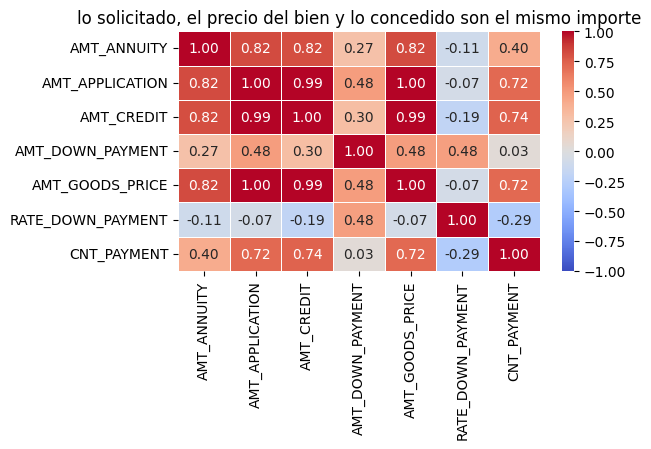

In [61]:
fig, ax = plt.subplots(figsize=(6.5, 4.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("lo solicitado, el precio del bien y lo concedido son el mismo importe")
plt.tight_layout()
plt.show()

In [62]:
# lo concedido frente a lo solicitado: la proporción es información que ninguna de las dos tiene sola
ambos = pt["AMT_APPLICATION"].gt(0) & pt["AMT_CREDIT"].gt(0)
ratio = (pt["AMT_CREDIT"] / pt["AMT_APPLICATION"]).where(ambos)
ETIQ = ["menos de lo pedido", "lo justo", "de 1 a 1,1", "de 1,1 a 1,3", "más de 1,3"]
tramo = pd.cut(ratio, [0, 0.999, 1.001, 1.1, 1.3, 100], labels=ETIQ)

r = senal(ratio)
print(f"concedido frente a solicitado: n={r['n']:,} ({ambos.mean() * 100:.2f}% de las solicitudes) | "
      f"rank-biserial {r['r_rb']:.4f} | Spearman {r['Spearman']:.4f} | p={r['p']:.1e}")
print(f"no es tamaño disfrazado: Pearson {ratio.corr(pt['AMT_CREDIT']):.4f} con el importe concedido")

grad = pt.groupby(tramo, observed=True)["TARGET"].agg(solicitudes="size", tasa="mean")
grad["% default"] = (grad.pop("tasa") * 100).round(2)
display(grad)

# el tramo justo rompe la monotonía: ¿es comportamiento o es mezcla de producto y de estado?
display((pd.crosstab(tramo, pt["NAME_CONTRACT_TYPE"], normalize="index") * 100).round(1))
display((pd.crosstab(tramo, pt["NAME_CONTRACT_STATUS"], normalize="index") * 100).round(1))

concedido frente a solicitado: n=1,088,398 (76.99% de las solicitudes) | rank-biserial 0.0959 | Spearman 0.0464 | p=0.0e+00
no es tamaño disfrazado: Pearson 0.2529 con el importe concedido


,solicitudes,% default
menos de lo pedido,305857,6.87
lo justo,271040,8.80
"de 1 a 1,1",223796,7.10
"de 1,1 a 1,3",263070,10.25
"más de 1,3",24635,14.12


NAME_CONTRACT_TYPE,Cash loans,Consumer loans,Revolving loans
row_0,,,
menos de lo pedido,0.0,99.4,0.6
lo justo,26.7,47.7,25.6
"de 1 a 1,1",53.0,47.0,0.0
"de 1,1 a 1,3",68.2,31.8,0.0
"más de 1,3",88.7,8.5,2.8


NAME_CONTRACT_STATUS,Approved,Canceled,Refused,Unused offer
row_0,,,,
menos de lo pedido,90.6,0.0,9.4,0.0
lo justo,61.8,1.6,28.4,8.2
"de 1 a 1,1",86.4,0.6,13.0,0.0
"de 1,1 a 1,3",73.7,1.2,25.1,0.0
"más de 1,3",60.4,0.8,38.8,0.0


In [63]:
# con el estado y el producto fijos, ¿sigue rompiendo?
grad_prod = {}
for tipo in ["Consumer loans", "Cash loans", "Revolving loans"]:
    s = aprobada & pt["NAME_CONTRACT_TYPE"].eq(tipo)
    g = pt[s].groupby(tramo[s], observed=True)["TARGET"].agg(n="size", tasa="mean")
    grad_prod[tipo] = (g["tasa"] * 100).where(g["n"] > 1000)  # sin muestra no hay punto
    print(f"{tipo}: rank-biserial {senal(ratio, s)['r_rb']:.4f} | " +
          " | ".join(f"{k} {v * 100:.2f}% (n={int(n):,})" for k, n, v in zip(g.index, g["n"], g["tasa"])))
grad_prod = pd.DataFrame(grad_prod).reindex(ETIQ)
print("tramos con menos de 1.000 solicitudes, que no se dibujan: " +
      ", ".join(f"{t} en {k}" for t in grad_prod for k in ETIQ if pd.isna(grad_prod.loc[k, t])))
print(f"\ndentro de las aprobadas: rank-biserial {senal(ratio, aprobada)['r_rb']:.4f} "
      f"(n={senal(ratio, aprobada)['n']:,})")

Consumer loans: rank-biserial 0.0895 | menos de lo pedido 6.72% (n=276,301) | lo justo 6.87% (n=85,517) | de 1 a 1,1 7.71% (n=97,947) | de 1,1 a 1,3 9.82% (n=75,828) | más de 1,3 13.22% (n=1,717)
Cash loans: rank-biserial 0.1250 | lo justo 6.99% (n=39,820) | de 1 a 1,1 5.76% (n=95,286) | de 1,1 a 1,3 8.70% (n=118,144) | más de 1,3 11.95% (n=13,131)
Revolving loans: rank-biserial 0.0065 | menos de lo pedido 6.51% (n=768) | lo justo 10.35% (n=42,052) | de 1 a 1,1 9.80% (n=51) | de 1,1 a 1,3 6.67% (n=30) | más de 1,3 4.35% (n=23)
tramos con menos de 1.000 solicitudes, que no se dibujan: Cash loans en menos de lo pedido, Revolving loans en menos de lo pedido, Revolving loans en de 1 a 1,1, Revolving loans en de 1,1 a 1,3, Revolving loans en más de 1,3



dentro de las aprobadas: rank-biserial 0.0779 (n=846,615)


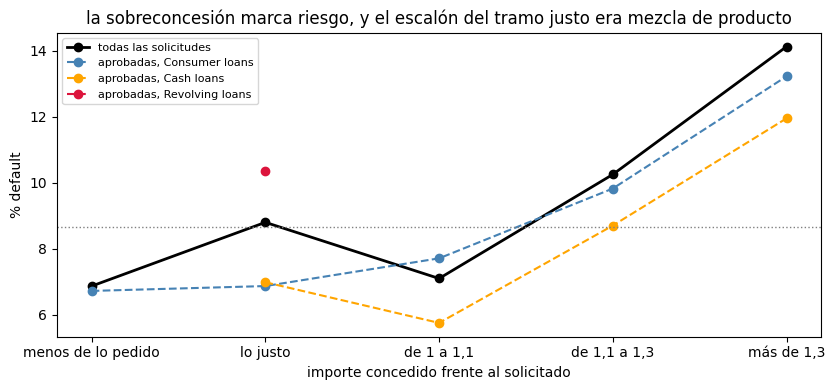

In [64]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(ETIQ, grad.loc[ETIQ, "% default"], color="black", marker="o", lw=2, label="todas las solicitudes")
for tipo, color in [("Consumer loans", COLOR_NODEF), ("Cash loans", "orange"),
                    ("Revolving loans", COLOR_DEF)]:
    ax.plot(ETIQ, grad_prod[tipo], marker="o", color=color, ls="--", label=f"aprobadas, {tipo}")
ax.axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax.set(xlabel="importe concedido frente al solicitado", ylabel="% default",
       title="la sobreconcesión marca riesgo, y el escalón del tramo justo era mezcla de producto")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [65]:
# lo que se devuelve frente a lo que se recibe: el coste implícito que el registro no publica
valida = aprobada & pt["AMT_ANNUITY"].gt(0) & pt["CNT_PAYMENT"].gt(0) & pt["AMT_CREDIT"].gt(0)
coste = (pt["AMT_ANNUITY"] * pt["CNT_PAYMENT"] / pt["AMT_CREDIT"]).where(valida)

# antes de cruzarlo con el objetivo compruebo que mide lo que creo, contra el tramo ya declarado
tipo_declarado = (pt.assign(coste=coste).groupby("NAME_YIELD_GROUP", observed=True)["coste"]
                  .agg(solicitudes="count", mediana="median").round(3))
display(tipo_declarado)

c = senal(coste)
print(f"coste implícito: n={c['n']:,} ({valida.sum() / aprobada.sum() * 100:.2f}% de las aprobadas) | "
      f"mediana {coste.median():.3f} | rank-biserial {c['r_rb']:.4f} | p={c['p']:.1e}")

tramo_coste = pd.cut(coste, [0, 1.05, 1.15, 1.25, 1.4, 100],
                     labels=["hasta 1,05", "de 1,05 a 1,15", "de 1,15 a 1,25", "de 1,25 a 1,4", "más de 1,4"])
grad_coste = pt.groupby(tramo_coste, observed=True)["TARGET"].agg(solicitudes="size", tasa="mean")
grad_coste["% default"] = (grad_coste.pop("tasa") * 100).round(2)
display(grad_coste)

,solicitudes,mediana
NAME_YIELD_GROUP,,
XNA,0,NaN
high,258993,1.348
low_action,60630,1.087
low_normal,210731,1.142
middle,273330,1.230


coste implícito: n=803,684 (90.70% de las aprobadas) | mediana 1.234 | rank-biserial 0.1111 | p=0.0e+00


,solicitudes,% default
"hasta 1,05",3506,4.93
"de 1,05 a 1,15",219470,6.10
"de 1,15 a 1,25",203335,6.91
"de 1,25 a 1,4",171388,7.36
"más de 1,4",205985,9.51


In [66]:
# el coste correlaciona 0,74 con el plazo, así que uno de los dos está prestando su señal al otro
print("coste dentro de estratos de plazo:")
plazo = pd.cut(pt["CNT_PAYMENT"].where(valida), [0, 6, 12, 24, 60, 100],
               labels=["hasta 6 cuotas", "de 7 a 12", "de 13 a 24", "de 25 a 60", "más de 60"])
for k in plazo.cat.categories:
    s = valida & plazo.eq(k)
    print(f"  {k:15s} rank-biserial {senal(coste, s)['r_rb']:.4f} (n={int(s.sum()):,})")

print("plazo dentro de estratos de coste:")
for k in tramo_coste.cat.categories:
    s = valida & tramo_coste.eq(k)
    print(f"  {k:15s} rank-biserial {senal(pt['CNT_PAYMENT'].where(valida), s)['r_rb']:.4f} (n={int(s.sum()):,})")

print("y sobre el tramo ya declarado, que es su versión gruesa:")
for k in ["low_action", "low_normal", "middle", "high"]:
    s = valida & pt["NAME_YIELD_GROUP"].eq(k)
    print(f"  {k:12s} rank-biserial {senal(coste, s)['r_rb']:.4f} (n={int(s.sum()):,})")

print(f"\nen la misma población: coste {senal(coste)['r_rb']:.4f} | "
      f"cuota {senal(pt['AMT_ANNUITY'].where(valida))['r_rb']:.4f} | "
      f"plazo {senal(pt['CNT_PAYMENT'].where(valida))['r_rb']:.4f} | "
      f"importe {senal(pt['AMT_CREDIT'].where(valida))['r_rb']:.4f}")
print(f"redundancia: Pearson {coste.corr(pt['CNT_PAYMENT']):.4f} con el plazo y "
      f"{coste.corr(ratio):.4f} con lo concedido frente a lo solicitado")

coste dentro de estratos de plazo:
  hasta 6 cuotas  rank-biserial 0.0875 (n=174,037)


  de 7 a 12       rank-biserial 0.0996 (n=379,666)
  de 13 a 24      rank-biserial 0.1193 (n=156,698)
  de 25 a 60      rank-biserial 0.1964 (n=93,223)
  más de 60       rank-biserial 0.3793 (n=60)
plazo dentro de estratos de coste:
  hasta 1,05      rank-biserial 0.0710 (n=3,506)
  de 1,05 a 1,15  rank-biserial 0.0086 (n=219,470)


  de 1,15 a 1,25  rank-biserial 0.0373 (n=203,335)
  de 1,25 a 1,4   rank-biserial 0.0586 (n=171,388)
  más de 1,4      rank-biserial 0.0021 (n=205,985)
y sobre el tramo ya declarado, que es su versión gruesa:
  low_action   rank-biserial 0.0282 (n=60,630)
  low_normal   rank-biserial 0.0542 (n=210,731)


  middle       rank-biserial 0.0868 (n=273,330)
  high         rank-biserial 0.1137 (n=258,993)



en la misma población: coste 0.1111 | cuota 0.0532 | plazo 0.0526 | importe 0.0287
redundancia: Pearson 0.7425 con el plazo y 0.3795 con lo concedido frente a lo solicitado


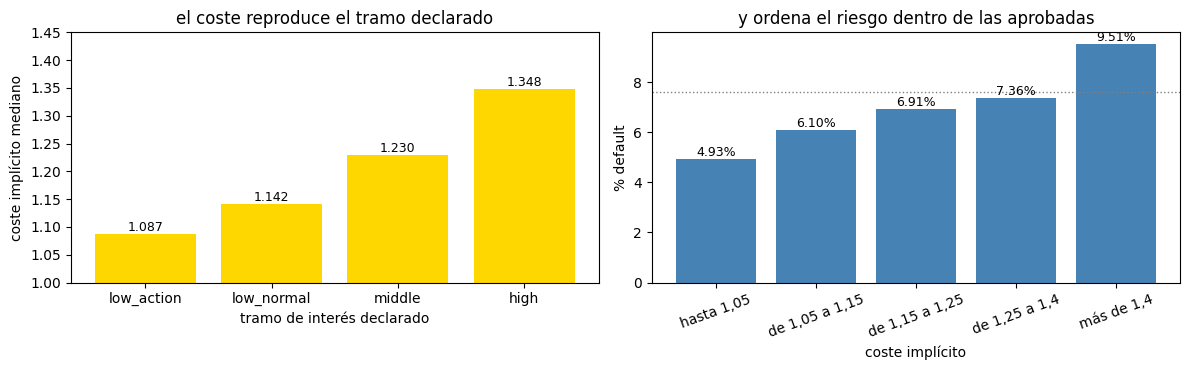

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
orden_tipo = ["low_action", "low_normal", "middle", "high"]
axes[0].bar(orden_tipo, tipo_declarado.loc[orden_tipo, "mediana"], color="gold")
axes[0].bar_label(axes[0].containers[0], fmt="%.3f", fontsize=9)
axes[0].set(ylim=(1, 1.45), ylabel="coste implícito mediano", xlabel="tramo de interés declarado",
            title="el coste reproduce el tramo declarado")
axes[1].bar(grad_coste.index.astype(str), grad_coste["% default"], color=COLOR_NODEF)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", fontsize=9)
axes[1].axhline(pt.loc[aprobada, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
axes[1].set(ylabel="% default", xlabel="coste implícito", title="y ordena el riesgo dentro de las aprobadas")
axes[1].tick_params(axis="x", labelrotation=20)
plt.tight_layout()
plt.show()

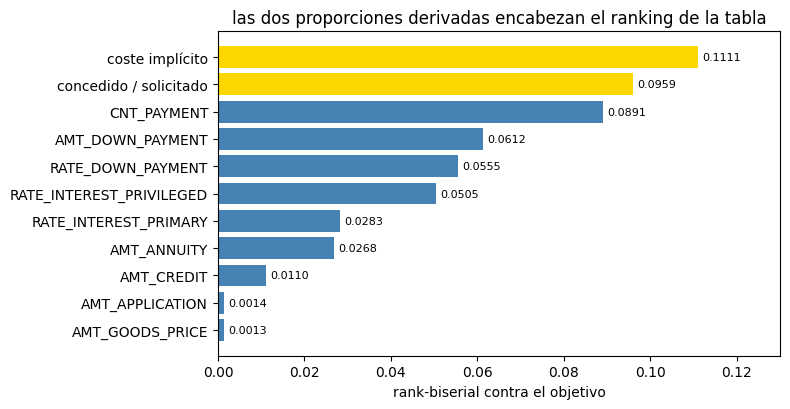

In [68]:
# las dos proporciones frente a las columnas de las que salen, en la misma escala
ranking = magnitudes["r_rb dato real"].to_dict()
ranking["coste implícito"] = senal(coste)["r_rb"]
ranking["concedido / solicitado"] = senal(ratio)["r_rb"]
ranking = pd.Series(ranking).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
colores = ["gold" if k in ("coste implícito", "concedido / solicitado") else COLOR_NODEF
           for k in ranking.index]
ax.barh(ranking.index, ranking.values, color=colores)
for i, v in enumerate(ranking.values):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax.set(xlabel="rank-biserial contra el objetivo", xlim=(0, 0.13),
       title="las dos proporciones derivadas encabezan el ranking de la tabla")
plt.tight_layout()
plt.show()

In [69]:
# las categóricas contra el objetivo, y el test de siempre: ¿aguantan con el estado fijo?
def cramer(a, b):
    """V de Cramér entre dos categóricas."""
    ct = pd.crosstab(a, b)
    return (chi2_contingency(ct)[0] / (len(a) * (min(ct.shape) - 1))) ** 0.5


filas = []
for c in CATS:
    s = pt[c].astype("string").fillna("sin dato")
    chi2, p = chi2_contingency(pd.crosstab(s, pt["TARGET"]))[:2]
    v = cramer(s, pt["TARGET"])
    v_ap = cramer(s[aprobada], pt.loc[aprobada, "TARGET"]) if s[aprobada].nunique() > 1 else None
    filas.append({"categórica": c, "categorías": s.nunique(), "Chi2": round(chi2), "p-valor": f"{p:.1e}",
                  "V de Cramér": round(v, 4), "V en aprobadas": None if v_ap is None else round(v_ap, 4),
                  "retiene": None if v_ap is None else round(v_ap / v, 2)})
categoricas = pd.DataFrame(filas).set_index("categórica").sort_values("V de Cramér", ascending=False)
display(categoricas)

estado = pt.groupby("NAME_CONTRACT_STATUS", observed=True)["TARGET"].agg(solicitudes="size", tasa="mean")
estado["% default"] = (estado.pop("tasa") * 100).round(2)
display(estado)

,categorías,Chi2,p-valor,V de Cramér,V en aprobadas,retiene
categórica,,,,,,
CODE_REJECT_REASON,9,5566,0.0e+00,0.0627,0.0002,0.00
NAME_CONTRACT_STATUS,4,4833,0.0e+00,0.0585,NaN,NaN
PRODUCT_COMBINATION,18,4704,0.0e+00,0.0577,0.0509,0.88
NAME_PRODUCT_TYPE,3,2619,0.0e+00,0.0430,0.0346,0.80
NAME_YIELD_GROUP,5,2542,0.0e+00,0.0424,0.0427,1.01
CHANNEL_TYPE,8,2022,0.0e+00,0.0378,0.0216,0.57
NAME_GOODS_CATEGORY,27,1950,0.0e+00,0.0371,0.0298,0.80
NAME_SELLER_INDUSTRY,11,1890,0.0e+00,0.0366,0.0305,0.84
NAME_CASH_LOAN_PURPOSE,25,1739,0.0e+00,0.0351,0.0254,0.72


,solicitudes,% default
NAME_CONTRACT_STATUS,,
Approved,886099,7.59
Canceled,259441,9.17
Refused,245390,12.00
Unused offer,22771,8.25


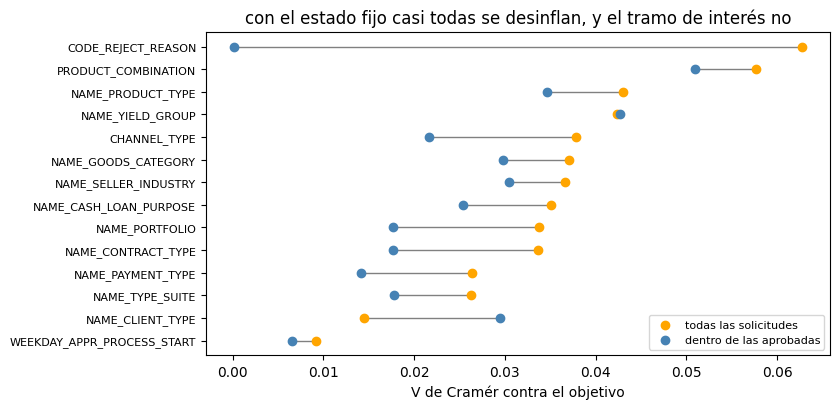

In [70]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
comp = categoricas.dropna(subset=["V en aprobadas"]).sort_values("V de Cramér")
for i, (g, a) in enumerate(zip(comp["V de Cramér"], comp["V en aprobadas"])):
    ax.plot([g, a], [i, i], color="gray", lw=1, zorder=1)
ax.scatter(comp["V de Cramér"], range(len(comp)), color="orange", zorder=2, label="todas las solicitudes")
ax.scatter(comp["V en aprobadas"], range(len(comp)), color=COLOR_NODEF, zorder=2,
           label="dentro de las aprobadas")
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp.index, fontsize=8)
ax.set(xlabel="V de Cramér contra el objetivo", ylabel="",
       title="con el estado fijo casi todas se desinflan, y el tramo de interés no")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

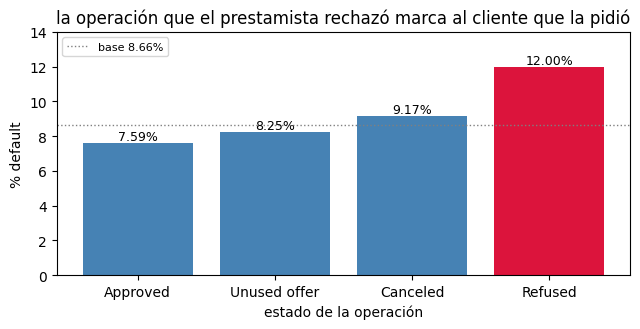

In [71]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
orden_estado = estado.sort_values("% default")
ax.bar(orden_estado.index, orden_estado["% default"],
       color=[COLOR_DEF if v > 10 else COLOR_NODEF for v in orden_estado["% default"]])
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=9)
ax.axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1,
           label=f"base {pt['TARGET'].mean() * 100:.2f}%")
ax.set(ylabel="% default", xlabel="estado de la operación", ylim=(0, 14),
       title="la operación que el prestamista rechazó marca al cliente que la pidió")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [72]:
# el motivo de rechazo pierde toda su asociación al fijar el estado, pero la pregunta útil
# es otra: entre las rechazadas, ¿discrimina el motivo?
rechazada = pt["NAME_CONTRACT_STATUS"].eq("Refused")
motivo = pt[rechazada].groupby("CODE_REJECT_REASON", observed=True)["TARGET"].agg(
    solicitudes="size", tasa="mean").sort_values("tasa")
motivo = motivo[motivo["solicitudes"] > 200]
motivo["% default"] = (motivo.pop("tasa") * 100).round(2)
display(motivo)
print(f"V de Cramér del motivo dentro de las rechazadas: "
      f"{cramer(pt.loc[rechazada, 'CODE_REJECT_REASON'].astype('string'), pt.loc[rechazada, 'TARGET']):.4f}")

interes = pt.groupby(["NAME_YIELD_GROUP"], observed=True)["TARGET"].agg(solicitudes="size", tasa="mean")
interes["% default"] = (interes.pop("tasa") * 100).round(2)
interes["% default en aprobadas"] = (pt[aprobada].groupby("NAME_YIELD_GROUP", observed=True)["TARGET"]
                                     .mean() * 100).round(2)
display(interes)

cliente = pd.DataFrame({
    "% default": pt.groupby("NAME_CLIENT_TYPE", observed=True)["TARGET"].mean() * 100,
    "% default en aprobadas": pt[aprobada].groupby("NAME_CLIENT_TYPE", observed=True)["TARGET"].mean() * 100,
    "solicitudes aprobadas": pt[aprobada].groupby("NAME_CLIENT_TYPE", observed=True)["TARGET"].size(),
}).round(2)
display(cliente)

,solicitudes,% default
CODE_REJECT_REASON,,
SYSTEM,672,6.25
VERIF,3079,9.26
SCO,32636,10.00
XNA,4370,10.11
HC,145984,11.73
LIMIT,47773,12.56
SCOFR,10875,20.93


V de Cramér del motivo dentro de las rechazadas: 0.0647


,solicitudes,% default,% default en aprobadas
NAME_YIELD_GROUP,,,
XNA,429198,9.86,9.03
high,306061,9.55,8.88
low_action,78587,6.45,5.96
low_normal,274884,7.13,6.32
middle,324971,8.04,7.27


,% default,% default en aprobadas,solicitudes aprobadas
NAME_CLIENT_TYPE,,,
New,8.99,8.82,242395
Refreshed,7.34,6.52,82891
Repeater,8.71,7.21,560378
XNA,9.92,7.13,435


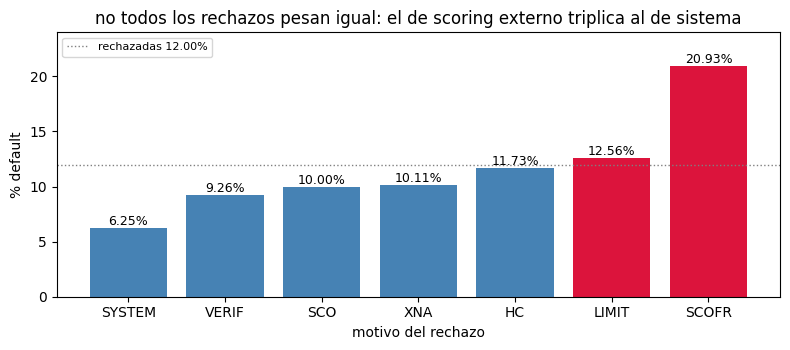

In [73]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(motivo.index, motivo["% default"], color=[COLOR_DEF if v > 12 else COLOR_NODEF
                                                 for v in motivo["% default"]])
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=9)
ax.axhline(pt.loc[rechazada, "TARGET"].mean() * 100, color="gray", ls=":", lw=1,
           label=f"rechazadas {pt.loc[rechazada, 'TARGET'].mean() * 100:.2f}%")
ax.set(ylabel="% default", xlabel="motivo del rechazo", ylim=(0, 24),
       title="no todos los rechazos pesan igual: el de scoring externo triplica al de sistema")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

par,V de Cramér
NAME_CONTRACT_TYPE y PRODUCT_COMBINATION,1.000000
NAME_PRODUCT_TYPE y PRODUCT_COMBINATION,0.887600
NAME_CONTRACT_STATUS y CODE_REJECT_REASON,0.816500
NAME_PORTFOLIO y PRODUCT_COMBINATION,0.806000
NAME_YIELD_GROUP y PRODUCT_COMBINATION,0.762500
NAME_CONTRACT_TYPE y NAME_PORTFOLIO,0.742500
NAME_GOODS_CATEGORY y NAME_SELLER_INDUSTRY,0.723500
NAME_PORTFOLIO y NAME_PRODUCT_TYPE,0.713000
NAME_PORTFOLIO y CHANNEL_TYPE,0.654500
NAME_CONTRACT_TYPE y NAME_CASH_LOAN_PURPOSE,0.577400


pares por encima de 0,50: 18 de 105


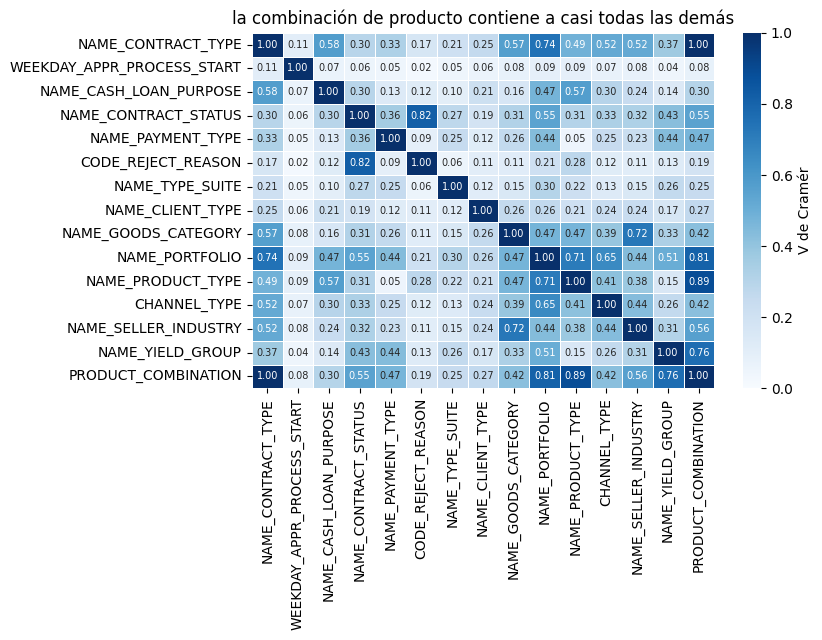

In [74]:
# ¿son quince categóricas o son unas pocas escritas de varias maneras?
V = pd.DataFrame(1.0, index=CATS, columns=CATS)
for a, b in combinations(CATS, 2):
    V.loc[a, b] = V.loc[b, a] = cramer(pt[a].astype("string").fillna("sin dato"),
                                       pt[b].astype("string").fillna("sin dato"))
pares = pd.DataFrame([{"par": f"{a} y {b}", "V de Cramér": round(V.loc[a, b], 4)}
                      for a, b in combinations(CATS, 2)]).sort_values("V de Cramér", ascending=False)
display(pares[pares["V de Cramér"] > 0.50].head(12).style.hide(axis="index"))
print(f"pares por encima de 0,50: {int((pares['V de Cramér'] > 0.5).sum())} de {len(pares)}")

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(V, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"label": "V de Cramér"}, ax=ax)
ax.set_title("la combinación de producto contiene a casi todas las demás")
plt.tight_layout()
plt.show()

In [75]:
# la V de Cramér resume la asociación global y aplana lo que pasa dentro de cada categórica,
# que es justo donde vive la señal rara: miro los extremos de las de más cardinalidad
CARDINALES = ["NAME_CASH_LOAN_PURPOSE", "NAME_GOODS_CATEGORY", "NAME_SELLER_INDUSTRY",
              "CHANNEL_TYPE", "PRODUCT_COMBINATION"]
base = pt["TARGET"].mean() * 100
filas = []
for c in CARDINALES:
    g = pt.groupby(c, observed=True)["TARGET"].agg(solicitudes="size", tasa="mean")
    g = g[g["solicitudes"] >= 100].sort_values("tasa", ascending=False)
    for extremo, k in [("la de más riesgo", g.index[0]), ("la de menos riesgo", g.index[-1])]:
        filas.append({"categórica": c, "extremo": extremo, "categoría": k,
                      "solicitudes": int(g.loc[k, "solicitudes"]),
                      "% default": round(g.loc[k, "tasa"] * 100, 2),
                      "veces la base": round(g.loc[k, "tasa"] * 100 / base, 2)})
display(pd.DataFrame(filas).set_index(["categórica", "extremo"]))

# la finalidad es la que más recorrido interno tiene, y su V de Cramér de 0,0351 no deja verlo
finalidad = pt.groupby("NAME_CASH_LOAN_PURPOSE", observed=True)["TARGET"].agg(
    solicitudes="size", tasa="mean")
finalidad = finalidad[finalidad["solicitudes"] >= 100].sort_values("tasa", ascending=False)
finalidad["% default"] = (finalidad.pop("tasa") * 100).round(2)
display(finalidad.head(8))
URGENTE = ["Refusal to name the goal", "Car repairs", "Gasification / water supply",
           "Money for a third person", "Payments on other loans", "Urgent needs",
           "Building a house or an annex"]
informada = (pt["NAME_CASH_LOAN_PURPOSE"].astype("string").notna()
             & ~pt["NAME_CASH_LOAN_PURPOSE"].isin(["XNA", "XAP"]))
base_informada = pt.loc[informada, "TARGET"].mean() * 100
print(f"base de la tabla {base:.2f}% | base de las finalidades informadas {base_informada:.2f}%")

categoría  \
categórica             extremo                                             
NAME_CASH_LOAN_PURPOSE la de más riesgo                      Car repairs   
                       la de menos riesgo                Buying a garage   
NAME_GOODS_CATEGORY    la de más riesgo                         Vehicles   
                       la de menos riesgo                        Fitness   
NAME_SELLER_INDUSTRY   la de más riesgo                  Auto technology   
                       la de menos riesgo                        Tourism   
CHANNEL_TYPE           la de más riesgo                  AP+ (Cash loan)   
                       la de menos riesgo                     Car dealer   
PRODUCT_COMBINATION    la de más riesgo              Cash Street: middle   
                       la de menos riesgo  POS industry without interest   

                                           solicitudes  % default  \
categórica             extremo                                      
NAME_CASH_LOAN_PURPOSE la de más riesgo            691      18.38   
                       la de menos riesgo          116       6.03   
NAME_GOODS_CATEGORY    la de más riesgo           2854      10.06   
                       la de menos riesgo          166       4.22   
NAME_SELLER_INDUSTRY   la de más riesgo           4080      10.37   
                       la de menos riesgo          374       4.28   
CHANNEL_TYPE           la de más riesgo          49624      12.83   
                       la de menos riesgo          406       5.17   
PRODUCT_COMBINATION    la de más riesgo          29934      11.62   
                       la de menos riesgo        10621       4.64   

                                           veces la base  
categórica             extremo                            
NAME_CASH_LOAN_PURPOSE la de más riesgo             2.12  
                       la de menos riesgo           0.70  
NAME_GOODS_CATEGORY    la de más riesgo             1.16  
                       la de menos riesgo           0.49  
NAME_SELLER_INDUSTRY   la de más riesgo             1.20  
                       la de menos riesgo           0.49  
CHANNEL_TYPE           la de más riesgo             1.48  
                       la de menos riesgo           0.60  
PRODUCT_COMBINATION    la de más riesgo             1.34  
                       la de menos riesgo           0.54

,solicitudes,% default
NAME_CASH_LOAN_PURPOSE,,
Car repairs,691,18.38
Gasification / water supply,251,17.93
Payments on other loans,1573,16.02
Urgent needs,7236,14.95
Building a house or an annex,2344,13.82
Medicine,1871,13.42
Repairs,20117,13.00
Buying a used car,2469,12.88


base de la tabla 8.66% | base de las finalidades informadas 13.03%


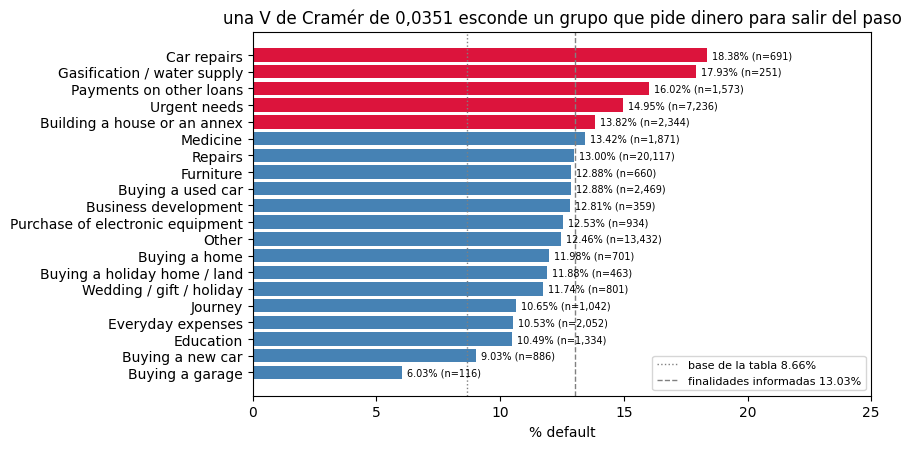

In [76]:
fig, ax = plt.subplots(figsize=(9, 4.6))
dibujo = finalidad.drop(index=[i for i in ("XNA", "XAP") if i in finalidad.index]).sort_values("% default")
ax.barh(dibujo.index, dibujo["% default"],
        color=[COLOR_DEF if k in URGENTE else COLOR_NODEF for k in dibujo.index])
for i, (v, n) in enumerate(zip(dibujo["% default"], dibujo["solicitudes"])):
    ax.text(v + 0.2, i, f"{v:.2f}% (n={n:,})", va="center", fontsize=7)
ax.axvline(base, color="gray", ls=":", lw=1, label=f"base de la tabla {base:.2f}%")
ax.axvline(base_informada, color="gray", ls="--", lw=1,
           label=f"finalidades informadas {base_informada:.2f}%")
ax.set(xlabel="% default", ylabel="", xlim=(0, 25),
       title="una V de Cramér de 0,0351 esconde un grupo que pide dinero para salir del paso")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [77]:
# las de más riesgo dicen lo mismo con otras palabras: necesito liquidez ya
finalidad_col = pt["NAME_CASH_LOAN_PURPOSE"].astype("string")
urgente = finalidad_col.isin(URGENTE)
informada = finalidad_col.notna() & ~finalidad_col.isin(["XNA", "XAP"])
print(f"solicitudes de liquidez urgente: {int(urgente.sum()):,} ({urgente.mean() * 100:.2f}% de la tabla), "
      f"y el {pt.loc[urgente, 'NAME_CONTRACT_TYPE'].eq('Cash loans').mean() * 100:.2f}% son préstamos en efectivo")
for etiqueta, s in [("frente al resto de finalidades informadas", informada),
                    ("y con el estado fijo, dentro de las aprobadas", informada & aprobada)]:
    d, p = delta_z(pt.loc[s & urgente, "TARGET"], pt.loc[s & ~urgente, "TARGET"])
    print(f"  {etiqueta}: {pt.loc[s & urgente, 'TARGET'].mean() * 100:.2f}% (n={int((s & urgente).sum()):,}) "
          f"frente a {pt.loc[s & ~urgente, 'TARGET'].mean() * 100:.2f}% | {d:+.2f}pp (p={p:.1e})")

# dentro de la combinación de producto hay un eje que no es el producto sino cómo se captó al cliente
combinacion = pt["PRODUCT_COMBINATION"].astype("string")
captacion = pd.Series(pd.NA, index=pt.index, dtype="string")
captacion[combinacion.str.contains("Street", na=False)] = "Street"
captacion[combinacion.str.contains("X-Sell", na=False)] = "X-Sell"
capta = pd.DataFrame({
    "solicitudes": pt.groupby(captacion, observed=True)["TARGET"].size(),
    "% default": (pt.groupby(captacion, observed=True)["TARGET"].mean() * 100).round(2)})
display(capta)
por_producto = {}
for tipo in ["Cash loans", "Revolving loans"]:
    s = aprobada & pt["NAME_CONTRACT_TYPE"].eq(tipo) & captacion.notna()
    g = pt[s].groupby(captacion[s], observed=True)["TARGET"].agg(n="size", tasa="mean")
    por_producto[tipo] = g["tasa"] * 100
    d, p = delta_z(pt.loc[s & captacion.eq("Street"), "TARGET"], pt.loc[s & captacion.eq("X-Sell"), "TARGET"])
    print(f"{tipo} aprobados: Street {g.loc['Street', 'tasa'] * 100:.2f}% (n={int(g.loc['Street', 'n']):,}) "
          f"frente a X-Sell {g.loc['X-Sell', 'tasa'] * 100:.2f}% (n={int(g.loc['X-Sell', 'n']):,}) | "
          f"{d:+.2f}pp (p={p:.1e})")
por_producto = pd.DataFrame(por_producto)

solicitudes de liquidez urgente: 12,131 (0.86% de la tabla), y el 100.00% son préstamos en efectivo
  frente al resto de finalidades informadas: 15.14% (n=12,131) frente a 12.48% | +2.66pp (p=8.1e-15)
  y con el estado fijo, dentro de las aprobadas: 13.63% (n=4,366) frente a 10.63% | +3.00pp (p=1.6e-08)


,solicitudes,% default
Street,204820,11.19
X-Sell,348211,8.25


Cash loans aprobados: Street 9.12% (n=57,046) frente a X-Sell 7.12% (n=209,332) | +2.00pp (p=9.7e-58)
Revolving loans aprobados: Street 9.77% (n=33,356) frente a X-Sell 8.54% (n=49,052) | +1.23pp (p=1.4e-09)


In [78]:
# la entrada es la tercera del ranking y no le he mirado el gradiente: ¿más entrada, menos riesgo?
cobertura = pt.groupby("NAME_CONTRACT_TYPE", observed=True)["RATE_DOWN_PAYMENT"].apply(
    lambda s: s.notna().mean() * 100).round(2)
print("entrada informada por tipo de contrato: " + " | ".join(f"{k} {v}%" for k, v in cobertura.items()))

consumo = aprobada & pt["NAME_CONTRACT_TYPE"].eq("Consumer loans")
ENTRADA = ["sin entrada", "hasta el 5%", "del 5 al 10%", "del 10 al 20%", "más del 20%"]
tramo_entrada = pd.cut(pt["RATE_DOWN_PAYMENT"], [-1, 0.0001, 0.05, 0.1, 0.2, 1.1], labels=ENTRADA)
entrada = pt[consumo].groupby(tramo_entrada[consumo], observed=True)["TARGET"].agg(
    solicitudes="size", tasa="mean")
entrada["% default"] = (entrada.pop("tasa") * 100).round(2)
display(entrada)

d, p = delta_z(pt.loc[consumo & tramo_entrada.eq("más del 20%"), "TARGET"],
               pt.loc[consumo & tramo_entrada.eq("hasta el 5%"), "TARGET"])
print(f"entrada por encima del 20% frente a entrada simbólica: {d:+.2f}pp (p={p:.1e})")
d, p = delta_z(pt.loc[consumo & tramo_entrada.eq("sin entrada"), "TARGET"],
               pt.loc[consumo & tramo_entrada.eq("hasta el 5%"), "TARGET"])
print(f"sin entrada frente a entrada simbólica: {d:+.2f}pp (p={p:.1e}), así que el cero no es "
      "el extremo del gradiente sino un producto distinto")


entrada informada por tipo de contrato: Cash loans 6.57% | Consumer loans 99.3% | Revolving loans 1.31% | XNA 0.0%


,solicitudes,% default
RATE_DOWN_PAYMENT,,
sin entrada,226483,7.94
hasta el 5%,4935,9.38
del 5 al 10%,45519,8.54
del 10 al 20%,183691,6.97
más del 20%,76646,5.94


entrada por encima del 20% frente a entrada simbólica: -3.44pp (p=1.9e-22)
sin entrada frente a entrada simbólica: -1.44pp (p=2.1e-04), así que el cero no es el extremo del gradiente sino un producto distinto


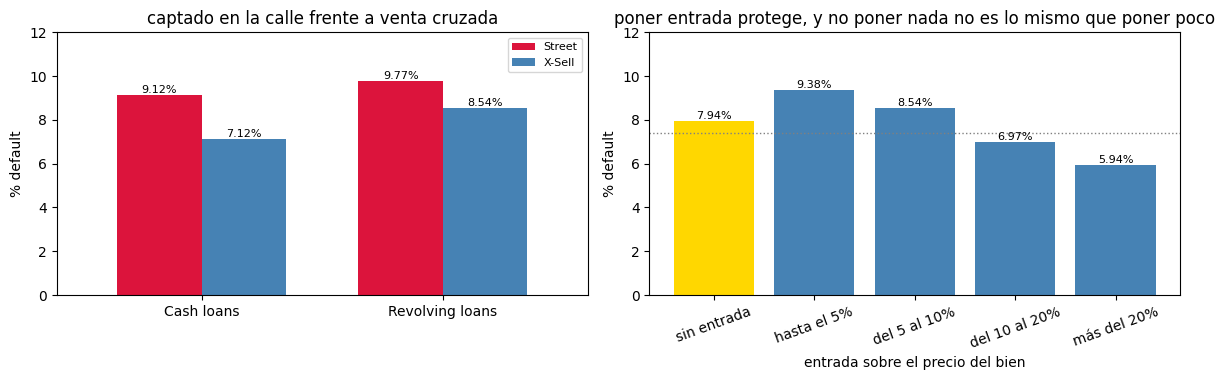

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
por_producto.T.plot.bar(ax=axes[0], color={"Street": COLOR_DEF, "X-Sell": COLOR_NODEF}, rot=0, width=0.7)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.2f%%", fontsize=8)
axes[0].set(ylabel="% default", xlabel="", ylim=(0, 12), title="captado en la calle frente a venta cruzada")
axes[0].legend(fontsize=8)

colores = ["gold"] + [COLOR_NODEF] * 4  # el cero es estado, no el extremo del gradiente
axes[1].bar(entrada.index.astype(str), entrada["% default"], color=colores)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", fontsize=8)
axes[1].axhline(pt.loc[consumo, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
axes[1].set(ylabel="% default", xlabel="entrada sobre el precio del bien", ylim=(0, 12),
            title="poner entrada protege, y no poner nada no es lo mismo que poner poco")
axes[1].tick_params(axis="x", labelrotation=20)
plt.tight_layout()
plt.show()

In [80]:
# las banderas y las dos numéricas que aparté por no medir cantidad
seguro = pt["NFLAG_INSURED_ON_APPROVAL"].map({1: "con seguro", 0: "sin seguro"}).fillna("sin dato")
niveles = pd.DataFrame({
    "solicitudes": pt.groupby(seguro, observed=True)["TARGET"].size(),
    "% default": (pt.groupby(seguro, observed=True)["TARGET"].mean() * 100).round(2),
    "% default en aprobadas": (pt[aprobada].groupby(seguro[aprobada], observed=True)["TARGET"]
                               .mean() * 100).round(2),
})
display(niveles)
con, sin = pt.loc[aprobada & pt["NFLAG_INSURED_ON_APPROVAL"].eq(1), "TARGET"], pt.loc[aprobada & pt["NFLAG_INSURED_ON_APPROVAL"].eq(0), "TARGET"]
d, p = delta_z(con, sin)
print(f"con seguro frente a sin seguro dentro de las aprobadas: {d:+.2f}pp (p={p:.3f})")

for col, valor in [("FLAG_LAST_APPL_PER_CONTRACT", "N"), ("NFLAG_LAST_APPL_IN_DAY", 0)]:
    m = pt[col].eq(valor)
    d, p = delta_z(pt.loc[m, "TARGET"], pt.loc[~m, "TARGET"])
    dom = (pt.loc[m, "NAME_CONTRACT_STATUS"].value_counts(normalize=True) * 100).round(2)
    print(f"{col} = {valor}: {d:+.2f}pp (n={int(m.sum()):,}, p={p:.1e}) | "
          f"{dom.index[0]} en el {dom.iloc[0]:.2f}%")
d, p = delta_z(pt.loc[rechazada & pt["FLAG_LAST_APPL_PER_CONTRACT"].eq("N"), "TARGET"],
               pt.loc[rechazada & pt["FLAG_LAST_APPL_PER_CONTRACT"].eq("Y"), "TARGET"])
print(f"  y dentro de las rechazadas: {d:+.2f}pp (p={p:.1e})")

zona = pt["SELLERPLACE_AREA"].eq(-1)
d, p = delta_z(pt.loc[zona, "TARGET"], pt.loc[~zona, "TARGET"])
da, pa = delta_z(pt.loc[aprobada & zona, "TARGET"], pt.loc[aprobada & ~zona, "TARGET"])
print(f"código de zona a -1: {d:+.2f}pp global (p={p:.1e}) y {da:+.2f}pp dentro de las aprobadas (p={pa:.3f})")

,solicitudes,% default,% default en aprobadas
NFLAG_INSURED_ON_APPROVAL,,,
con seguro,281844,7.61,7.61
sin dato,561106,10.28,7.58
sin seguro,570751,7.58,7.58


con seguro frente a sin seguro dentro de las aprobadas: +0.04pp (p=0.547)
FLAG_LAST_APPL_PER_CONTRACT = N: +2.17pp (n=7,314, p=4.5e-11) | Refused en el 99.97%
NFLAG_LAST_APPL_IN_DAY = 0: +1.36pp (n=5,044, p=6.0e-04) | Refused en el 87.09%
  y dentro de las rechazadas: -1.23pp (p=1.4e-03)
código de zona a -1: +0.97pp global (p=9.4e-93) y +0.09pp dentro de las aprobadas (p=0.126)


In [81]:
# la hora la aparté por cíclica, pero el reparto la deja casi ordinal: ¿tiene gradiente propio?
franja = pd.cut(pt["HOUR_APPR_PROCESS_START"], [-1, 8, 11, 14, 17, 24],
                labels=["hasta las 8", "de 9 a 11", "de 12 a 14", "de 15 a 17", "desde las 18"])
horas = {}
for etiqueta, m in [("todas", pt["TARGET"].notna()), ("aprobadas", aprobada),
                    ("aprobadas por oficinas", aprobada & pt["CHANNEL_TYPE"].eq("Credit and cash offices")),
                    ("aprobadas de consumo", aprobada & pt["NAME_CONTRACT_TYPE"].eq("Consumer loans"))]:
    horas[etiqueta] = pt[m].groupby(franja[m], observed=True)["TARGET"].mean() * 100
horas = pd.DataFrame(horas).round(2)
horas.insert(0, "solicitudes", pt.groupby(franja, observed=True)["TARGET"].size())
display(horas)
print(f"el {pt['HOUR_APPR_PROCESS_START'].between(9, 17).mean() * 100:.2f}% de las solicitudes se "
      f"decide entre las 9 y las 17 | Spearman de la hora con el objetivo "
      f"{pt['HOUR_APPR_PROCESS_START'].corr(pt['TARGET'], method='spearman'):.4f}")

# familia de la sección, contando cada contraste emitido (conservadora)
familia = 3 * len(MAGNITUDES) + 5 + 14 + 2 * len(CATS) + 8 + 9
print(f"familia de {familia} contrastes en la sección, alfa de Bonferroni {0.05 / familia:.2e}")

,solicitudes,todas,aprobadas,aprobadas por oficinas,aprobadas de consumo
HOUR_APPR_PROCESS_START,,,,,
hasta las 8,149129,10.74,9.22,9.09,9.04
de 9 a 11,424760,8.86,7.84,7.44,7.84
de 12 a 14,436987,8.52,7.47,7.34,7.31
de 15 a 17,303688,7.99,7.10,7.21,6.87
desde las 18,99137,7.28,6.43,6.56,6.23


el 82.44% de las solicitudes se decide entre las 9 y las 17 | Spearman de la hora con el objetivo -0.0268
familia de 93 contrastes en la sección, alfa de Bonferroni 5.38e-04


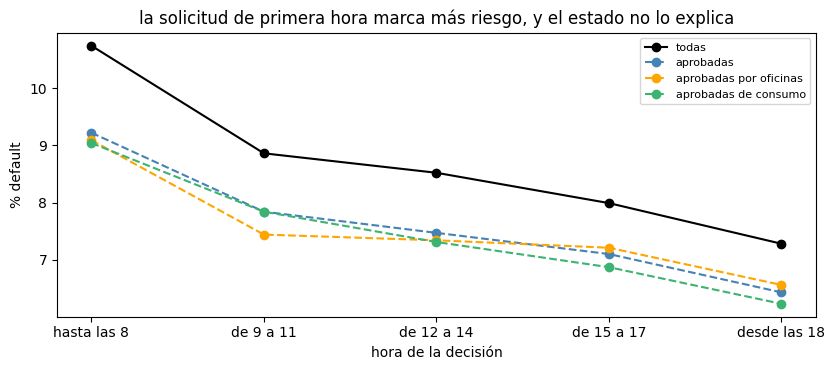

In [82]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for etiqueta, color, estilo in [("todas", "black", "-"), ("aprobadas", COLOR_NODEF, "--"),
                                ("aprobadas por oficinas", "orange", "--"),
                                ("aprobadas de consumo", "mediumseagreen", "--")]:
    ax.plot(horas.index.astype(str), horas[etiqueta], marker="o", color=color, ls=estilo, label=etiqueta)
ax.set(xlabel="hora de la decisión", ylabel="% default",
       title="la solicitud de primera hora marca más riesgo, y el estado no lo explica")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [83]:
# qué se lleva cada categórica a la construcción de variables: cardinalidad, recorrido de riesgo,
# lo que retiene con el estado fijo y con quién solapa
recorrido = {}
for c in CATS:
    g = pt.groupby(c, observed=True)["TARGET"].agg(n="size", tasa="mean")
    g = g[g["n"] >= 100]
    recorrido[c] = (g["tasa"].max() - g["tasa"].min()) * 100

DECISION = {
    "NAME_CONTRACT_STATUS": "proporciones por estado, la variable que gobierna la tabla",
    "CODE_REJECT_REASON": "solo dentro de las rechazadas, separando el scoring externo",
    "NAME_YIELD_GROUP": "ordinal, y su versión continua es el coste implícito",
    "PRODUCT_COMBINATION": "no entra entera: de ella salen el canal de captación y el tramo de interés",
    "NAME_CLIENT_TYPE": "ordinal de antigüedad de relación, medida con el estado fijo",
    "NAME_CASH_LOAN_PURPOSE": "agrupar por tasa de riesgo, no por frecuencia, y separar los dos códigos",
    "NAME_GOODS_CATEGORY": "agrupar por riesgo antes de codificar, 27 niveles con 10 residuales",
    "NAME_SELLER_INDUSTRY": "agrupar por riesgo; solapa 0,72 con la categoría del bien",
    "CHANNEL_TYPE": "codificar por riesgo; retiene poco con el estado fijo",
    "NAME_CONTRACT_TYPE": "tres niveles, entra como producto de la operación",
    "NAME_PORTFOLIO": "redundante con el tipo de contrato y el canal, se cae",
    "NAME_PRODUCT_TYPE": "contenida en la combinación de producto, se cae",
    "NAME_PAYMENT_TYPE": "recorrido corto y solapa con el producto, evaluar con IV",
    "NAME_TYPE_SUITE": "interesa la ausencia, no el valor, que ya está mejor registrado hoy",
    "WEEKDAY_APPR_PROCESS_START": "se cae, no discrimina",
}
receta = pd.DataFrame({
    "niveles": categoricas["categorías"],
    "V de Cramér": categoricas["V de Cramér"],
    "retiene": categoricas["retiene"],
    "recorrido (pp)": pd.Series(recorrido).round(2),
    "solapa más con": pd.Series({c: V.loc[c].drop(c).idxmax() for c in CATS}),
    "V con esa": pd.Series({c: round(V.loc[c].drop(c).max(), 2) for c in CATS}),
    "decisión": pd.Series(DECISION),
}).loc[categoricas.index]
assert receta.loc["CODE_REJECT_REASON", "V con esa"] > 0.8, "columnas desalineadas"
display(receta)

,niveles,V de Cramér,retiene,recorrido (pp),solapa más con,V con esa,decisión
categórica,,,,,,,
CODE_REJECT_REASON,9,0.0627,0.00,14.68,NAME_CONTRACT_STATUS,0.82,"solo dentro de las rechazadas, separando el sc..."
NAME_CONTRACT_STATUS,4,0.0585,NaN,4.41,CODE_REJECT_REASON,0.82,"proporciones por estado, la variable que gobie..."
PRODUCT_COMBINATION,18,0.0577,0.88,6.97,NAME_CONTRACT_TYPE,1.00,no entra entera: de ella salen el canal de cap...
NAME_PRODUCT_TYPE,3,0.0430,0.80,4.38,PRODUCT_COMBINATION,0.89,"contenida en la combinación de producto, se cae"
NAME_YIELD_GROUP,5,0.0424,1.01,3.41,PRODUCT_COMBINATION,0.76,"ordinal, y su versión continua es el coste imp..."
CHANNEL_TYPE,8,0.0378,0.57,7.65,NAME_PORTFOLIO,0.65,codificar por riesgo; retiene poco con el esta...
NAME_GOODS_CATEGORY,27,0.0371,0.80,5.84,NAME_SELLER_INDUSTRY,0.72,"agrupar por riesgo antes de codificar, 27 nive..."
NAME_SELLER_INDUSTRY,11,0.0366,0.84,6.09,NAME_GOODS_CATEGORY,0.72,"agrupar por riesgo; solapa 0,72 con la categor..."
NAME_CASH_LOAN_PURPOSE,25,0.0351,0.72,12.34,NAME_CONTRACT_TYPE,0.58,"agrupar por tasa de riesgo, no por frecuencia,..."


In [84]:
# las dos tasas de interés quedaron como candidatas a eliminar por cobertura: lo confirmo contra
# el objetivo antes de tirarlas
for c in ["RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"]:
    r = senal(pt[c])
    print(f"{c}: {r['n']:,} filas ({r['n'] / len(pt) * 100:.3f}%) de "
          f"{pt.loc[pt[c].notna(), 'SK_ID_CURR'].nunique():,} clientes | rank-biserial {r['r_rb']:.4f} "
          f"| p={r['p']:.3f}")

# ¿el coste alto y la sobreconcesión se refuerzan, o cada uno suma por su cuenta?
nivel_coste = pd.cut(coste, [0, 1.25, 100], labels=["coste hasta 1,25", "coste por encima de 1,25"])
nivel_ratio = pd.cut(ratio.where(valida), [0, 1.001, 100],
                     labels=["hasta lo pedido", "sobreconcedido"])
inter = pt.groupby([nivel_coste, nivel_ratio], observed=True)["TARGET"].agg(
    solicitudes="size", tasa="mean")
inter["% default"] = (inter.pop("tasa") * 100).round(2)
display(inter)

# ¿podría calcularse el coste implícito en la solicitud que se evalúa? no: allí no hay plazo pactado
plazo_actual = train["AMT_CREDIT"] / train["AMT_ANNUITY"]
x0, x1 = plazo_actual[train["TARGET"] == 0].dropna(), plazo_actual[train["TARGET"] == 1].dropna()
u, _ = mannwhitneyu(x0, x1)
print(f"\nen la solicitud actual solo existe crédito entre cuota, que mezcla plazo y coste: "
      f"rank-biserial {abs(2 * u / (len(x0) * len(x1)) - 1):.4f}")
tramo_actual = pd.cut(plazo_actual, [0, 10, 15, 20, 25, 100],
                      labels=["hasta 10", "de 10 a 15", "de 15 a 20", "de 20 a 25", "más de 25"])
actual = train.groupby(tramo_actual, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
actual["% default"] = (actual.pop("tasa") * 100).round(2)
display(actual)

RATE_INTEREST_PRIMARY: 4,791 filas (0.339%) de 4,609 clientes | rank-biserial 0.0283 | p=0.348
RATE_INTEREST_PRIVILEGED: 4,791 filas (0.339%) de 4,609 clientes | rank-biserial 0.0505 | p=0.091


solicitudes  % default
coste hasta 1,25         hasta lo pedido       263194       6.15
                         sobreconcedido        163117       7.00
coste por encima de 1,25 hasta lo pedido       138440       7.98
                         sobreconcedido        238933       8.85


en la solicitud actual solo existe crédito entre cuota, que mezcla plazo y coste: rank-biserial 0.0641


,clientes,% default
hasta 10,19667,6.18
de 10 a 15,50801,10.11
de 15 a 20,86643,7.81
de 20 a 25,51856,10.10
más de 25,98532,6.56


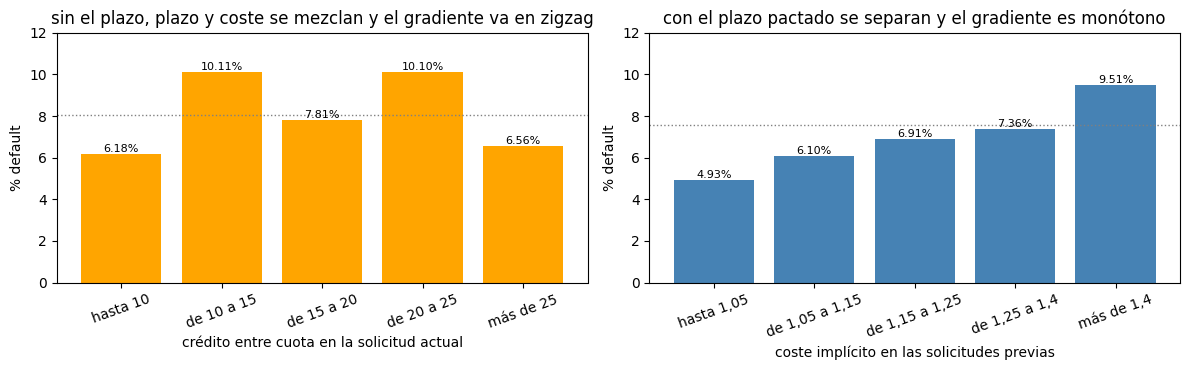

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(actual.index.astype(str), actual["% default"], color="orange")
axes[0].bar_label(axes[0].containers[0], fmt="%.2f%%", fontsize=8)
axes[0].axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
axes[0].set(ylabel="% default", xlabel="crédito entre cuota en la solicitud actual", ylim=(0, 12),
            title="sin el plazo, plazo y coste se mezclan y el gradiente va en zigzag")
axes[0].tick_params(axis="x", labelrotation=20)
axes[1].bar(grad_coste.index.astype(str), grad_coste["% default"], color=COLOR_NODEF)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", fontsize=8)
axes[1].axhline(pt.loc[aprobada, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
axes[1].set(ylabel="% default", xlabel="coste implícito en las solicitudes previas", ylim=(0, 12),
            title="con el plazo pactado se separan y el gradiente es monótono")
axes[1].tick_params(axis="x", labelrotation=20)
plt.tight_layout()
plt.show()

Cruzar las magnitudes de esta tabla con el objetivo obliga a repetir la cautela de siempre, y es que cada cliente aporta 4,86 solicitudes que comparten etiqueta, así que los p-valores salen anticonservadores y decido por tamaño del efecto.

Antes de mirar ninguna correlación había que decidir sobre qué filas se mide, porque aquí el cero de los importes es el estado de la operación y no una cantidad. Esperaba que limpiarlo fuese un tecnicismo sin consecuencias, y mueve la señal en dos direcciones opuestas. `CNT_PAYMENT` pasa de 0,0428 a 0,0891 de rank-biserial al medirla solo donde hay plazo pactado, porque sus ceros son tarjetas sin cuadro de amortización y operaciones que no llegaron a formalizarse, y estaban tapando la variable. `AMT_APPLICATION` hace lo contrario y cae de 0,0275 a 0,0014: lo que parecía señal del importe solicitado era el cero, es decir el estado otra vez. Con las nueve magnitudes medidas sobre dato real ninguna alcanza 0,09 y las tres de tamaño se quedan por debajo de 0,03, así que a nivel de solicitud el importe apenas habla del riesgo. Es el mismo diagnóstico que en `bureau`, donde ninguna variable financiera superaba 0,011 de correlación y el valor apareció al agregar por cliente.

La multicolinealidad da un resultado más fuerte del que esperaba. Contaba con encontrar el par de lo solicitado frente a lo concedido, equivalente al del importe y el precio del bien en la solicitud que se evalúa (0,99), y lo que hay es una identidad: `AMT_GOODS_PRICE` coincide exactamente con `AMT_APPLICATION` en el 99,98% de las 1.088.399 filas que tienen las dos cifras, con 188 excepciones. No es correlación alta, es la misma columna escrita dos veces, y solo se diferencian en cobertura, porque el precio no tiene dato en el 22,60% de las filas y lo solicitado está a cero en el 23,01%, con 5.777 filas donde el precio existe y lo solicitado no. Con lo concedido a 0,9936 y la cuota a 0,8220, nueve pares superan el umbral de 0,70. De las tres formas de escribir el tamaño de la operación me quedo con una, y lo que las diferencia entra por proporciones.

La primera proporción es lo concedido frente a lo solicitado, que había identificado como candidata al ver las distribuciones sin contrastarla. Rinde 0,0959 de rank-biserial sobre 1.088.398 solicitudes, con Spearman de 0,0464 y correlación de 0,2529 con el importe concedido, así que no es el tamaño disfrazado. El gradiente confirma que la sobreconcesión marca riesgo: 6,87% cuando se concede menos de lo pedido, 8,80% cuando coincide, 7,10% con un exceso de hasta el 10%, 10,25% entre el 10 y el 30% y 14,12% por encima. Quedaba pendiente entender por qué el tramo que coincide rompe la monotonía, y no es comportamiento sino mezcla de dos poblaciones: reúne el 25,6% de revolving, donde las dos cifras coinciden por construcción, y el 28,4% de rechazos. Fijando estado y producto el gradiente sale limpio en crédito al consumo, con 6,72%, 6,87%, 7,71%, 9,82% y 13,22%, y el efectivo es donde más rinde (0,1250), mientras que el revolving vive casi entero dentro de ese único tramo, con 42.052 operaciones aprobadas al 10,35%.

La segunda proporción no estaba propuesta y es la señal más fuerte de la tabla. Si la cuota, el plazo y el importe concedido correlacionan entre 0,72 y 0,82, la información nueva no está en ninguno de los tres sino en cómo se relacionan, o sea en lo que se devuelve en total frente a lo que se recibe. Antes de cruzarlo con el objetivo comprobé que mide lo que creo, y reproduce el tramo de interés que la propia operación declara, con mediana de 1,09 en low_action, 1,14 en low_normal, 1,23 en middle y 1,35 en high. Contra el objetivo rinde 0,1111 sobre 803.684 operaciones, el 90,70% de las aprobadas, con gradiente monótono del 4,93% al 9,51%. Correlaciona 0,7425 con el plazo, por encima del umbral, así que uno de los dos presta su señal al otro, y los estratos cruzados lo resuelven sin ambigüedad: el coste aguanta dentro de los cuatro tramos de plazo con muestra, de 0,0875 a 0,1964 y creciendo con la duración, mientras que el quinto se queda en 60 operaciones y no da para leerlo, mientras que el plazo se desinfla dentro de los tramos de coste, entre 0,0021 y 0,0710. Tampoco es el tramo declarado con otro nombre, porque aporta dentro de cada uno de ellos, de 0,0282 en low_action a 0,1137 en high. Es el mismo mecanismo que en `bureau` convirtió dos importes sin señal individual en la variable más fuerte de aquella tabla al ponerlos en proporción.

Las quince categóricas cuentan una historia distinta a la de los importes. Ninguna llega a 0,063 de V de Cramér pese a Chi2 de hasta 5.566, la combinación de Chi2 grande con efecto pequeño que ya vi en el buró y que tiene el mismo origen, con la masa pegada a la base y el contraste viviendo en grupos minoritarios. El estado de la operación ordena el riesgo como esperaba, con 7,59% en las aprobadas, 8,25% en las ofertas no usadas, 9,17% en las canceladas y 12,00% en las rechazadas, y al fijarlo casi todas las demás se desinflan. El motivo del rechazo cae de 0,0627 a 0,0002, que es la confirmación numérica de que ese código es el estado con otro nombre; el canal conserva el 57% de su asociación, y la cartera y el tipo de contrato el 52%. Solo dos aguantan. El tramo de interés declarado retiene el 101%, con 0,0424 y 0,0427, coherente con que su versión continua sea la variable más fuerte que he encontrado. Y el tipo de cliente dobla su asociación al fijar el estado, de 0,0145 a 0,0295, con el cliente recurrente en 7,21% y el que vuelve tras un paréntesis en 6,52% frente al 8,82% del nuevo, que es la misma protección de la relación larga que ya vi al medir el historial recortado.

El motivo del rechazo merecía además una pregunta distinta de la que responde su V de Cramér. No separa operaciones porque lo que marca es el rechazo, pero dentro de las rechazadas sí separa, del 6,25% cuando lo rechaza el sistema al 20,93% cuando lo rechaza el scoring externo, pasando por el 11,73% del rechazo por criterio de riesgo y el 12,56% del rechazo por límite, con V de Cramér de 0,0647, mayor que la global. No todos los rechazos pesan igual, y contar rechazos sin mirar el motivo mezclaría un rechazo administrativo con el peor marcador de la tabla.

Entre las categóricas hay más solape del que el número de columnas sugiere, con 18 de los 105 pares por encima de 0,50 de V de Cramér. `PRODUCT_COMBINATION` contiene al tipo de contrato (1,0000), al tipo de producto (0,8876), a la cartera (0,8060) y al tramo de interés (0,7625), así que es la concatenación de las otras y no una variable nueva: o entra ella o entran sus componentes.

Todo lo anterior mide asociación global, y eso aplana justo lo que más importa cuando el default es minoritario. Mirando dentro de las categóricas de más cardinalidad aparece lo que la V de Cramér escondía. La finalidad del préstamo tiene 0,0351, que invita a descartarla, y dentro lleva reparar el coche al 18,38% con 691 solicitudes, gasificación o suministro de agua al 17,93% con 251, pagar otros préstamos al 16,02% con 1.573, necesidades urgentes al 14,95% con 7.236 y construir vivienda al 13,82% con 2.344, frente al 8,66% de base y al 6,03% de comprar un garaje. Las de arriba dicen lo mismo con otras palabras, que es necesitar liquidez ya, y agrupadas son 12.131 solicitudes con el 15,14% de default frente al 12,48% del resto de finalidades informadas, que ya de por sí parten del 13,03% porque todas son préstamos en efectivo. Y no es el estado disfrazado, porque dentro de las aprobadas siguen en 13,63% frente a 10,63%, una diferencia de 3,00pp. Esto cierra lo que dejé abierto al ver las distribuciones, cuando decidí que las categorías residuales había que agruparlas por tasa de riesgo parecida y no por frecuencia sin haber medido todavía esas tasas. Y encaja con el perfil de búsqueda activa de financiación con un matiz que el buró no puede dar, y es que aquí el cliente declara para qué quiere el dinero, y pedir para pagar otros préstamos es refinanciar deuda con deuda.

Dentro de la combinación de producto hay otro eje que tampoco es el producto. Separando lo captado en la calle de lo vendido de forma cruzada a quien ya era cliente salen 11,19% y 8,25%, con el punto de venta en 7,71%. Con producto y estado fijos aguanta, con 9,12% frente a 7,12% en el efectivo aprobado, una diferencia de 2,00pp, y 9,77% frente a 8,54% en el revolving aprobado. Mismo producto, misma decisión de aprobación y dos perfiles de riesgo distintos según cómo llegó el cliente, lo que explica que la combinación de producto sea la categórica que más asociación retiene al fijar el estado.

La entrada era la tercera del ranking de magnitudes y no le había mirado el gradiente. Solo existe donde tiene sentido, informada en el 99,30% del crédito al consumo y en el 6,57% del efectivo, así que la mido dentro del consumo aprobado. De menos a más entrada sale 7,94% sin entrada, 9,38% con una entrada simbólica de hasta el 5%, 8,54% entre el 5 y el 10%, 6,97% entre el 10 y el 20% y 5,94% por encima del 20%. Poner más de un quinto del precio baja el riesgo 3,44pp frente a poner una cantidad simbólica, casi la mitad. Y el no poner nada no es el extremo del gradiente sino un producto distinto, 1,44pp por debajo de la entrada simbólica, que es la misma estructura de tres niveles que ya obligó a no binarizar la cuota y la mora del buró, donde el cero reportado también era mejor que el valor pequeño.

Quedaban tres variables por decidir y las tres se caen por el mismo motivo. La bandera de seguro parecía llevar señal, con 10,28% sin dato frente a 7,61% y 7,58%, pero entre las aprobadas los dos niveles informados son indistinguibles, con 0,04pp de diferencia y p = 0,547, así que lo que marcaba era la ausencia, que es el estado. La bandera de último registro por contrato da 2,17pp, y el 99,97% de sus casos son rechazos; dentro de ellos invierte el signo y da -1,23pp. El código de zona a -1 cae de 0,97pp a 0,09pp con el estado fijo, con p = 0,126. Ninguna aporta nada propio. En cambio la hora de la decisión, que había dejado fuera del análisis de magnitudes por ser cíclica, sí aporta: el gradiente va del 10,74% antes de las 8 al 7,28% desde las 18, y aguanta el doble control, con 9,09% frente a 6,56% en las aprobadas por oficinas y 9,04% frente a 6,23% en las aprobadas de consumo. El 82,44% de las decisiones se toma entre las 9 y las 17, así que la franja temprana es minoritaria y aun así es la de más riesgo. El día de la semana, en cambio, no dice nada, con 0,0092.

De aquí salen dos variables construidas que no existen como columna, el coste implícito del crédito y lo concedido frente a lo solicitado, y la primera es la señal continua más fuerte medida hasta ahora en esta tabla. Se conservan además el plazo pactado medido donde existe, la entrada en tres niveles, la finalidad agrupada por riesgo, la forma de captación, el motivo del rechazo medido dentro de las rechazadas, el tramo de interés, el tipo de cliente y la hora. Se descartan el precio del bien por ser copia de lo solicitado, la bandera de seguro, la bandera de reintento, el código de zona y el día de la semana. Todo está medido a nivel de solicitud sobre el objetivo heredado, así que cada una tiene que revalidarse al agregar por cliente, donde además habrá que controlar por la recencia de cada historial; y como las tasas se calculan sobre el conjunto de entrenamiento completo, los descartes por señal son provisionales, mientras que el del precio del bien, que es redundancia estructural, no depende del objetivo y queda firme. Las variables de fecha no entran en este cruce: la antigüedad de la decisión y las fechas del ciclo de vida se miden al mirar el eje temporal, que es donde el gradiente por tramos y los contrastes de recencia tienen sentido.

Con la asociación, el recorrido interno y el solape ya medidos, cada categórica tiene decidida su forma de entrar. Se caen cuatro: el día de la semana por no discriminar, con 0,84pp entre sus extremos; la cartera y el tipo de producto por estar contenidas en la combinación de producto; y el código de zona del punto de venta, que además de no tener señal propia con el estado fijo tiene 2.097 valores distintos y un 45,66% de casos sin dato real. La combinación de producto tampoco entra entera sino descompuesta en lo que aporta de nuevo, que es el canal de captación y el tramo de interés. Las de cardinalidad alta y recorrido largo, con la finalidad a la cabeza (12,34pp entre extremos), la industria del vendedor (6,09pp) y la categoría del bien (5,84pp), se agrupan por tasa de riesgo antes de codificar y nunca por frecuencia, con la tasa calculada solo sobre entrenamiento. El tramo de interés y el tipo de cliente entran como ordinales, y el motivo del rechazo solo dentro de las rechazadas. Un aviso de lectura sobre esa tabla: el recorrido de 12,42pp del tipo de contrato no viene de sus tres productos reales sino del residuo sin tipo, que es el registro fantasma ya identificado.

Las dos tasas de interés quedaban como candidatas a eliminar por cobertura y la decisión está ahora confirmada contra el objetivo: con 4.791 filas informadas, el 0,34%, de 4.609 clientes, ninguna alcanza significancia ni con el criterio más laxo, con p de 0,348 y de 0,091. Se eliminan. La hora, en cambio, entra por tramos y no como variable cíclica, porque su efecto es monótono en el rango donde está la masa y codificarla con seno y coseno destruiría justo la forma que tiene.

Antes de proponer interacciones comprobé la más evidente, que es si el coste alto y la sobreconcesión se refuerzan. No lo hacen, se suman: 6,15% cuando no aparece ninguna de las dos, 7,00% con sobreconcesión sola, 7,98% con coste alto solo y 8,85% con las dos, que es casi exactamente la suma de los efectos por separado. No hay término de interacción que crear.

Y hay un argumento que justifica por sí solo el esfuerzo de mirar estas solicitudes, y es que el coste implícito no se puede calcular en la solicitud que se evalúa. Allí hay cuota e importe pero no plazo pactado, así que lo único disponible es crédito entre cuota, que mezcla plazo y coste en una sola cifra y dibuja un zigzag: 6,18% hasta 10, 10,11% entre 10 y 15, 7,81% entre 15 y 20, 10,10% entre 20 y 25 y 6,56% por encima de 25, porque dentro de cada tramo se están mezclando productos con plazos y costes distintos. El histórico sí trae el plazo, y con él los dos se separan. Para situar la escala, el 0,1111 del coste implícito y el 0,0959 de la sobreconcesión son del mismo orden que el mejor ratio de la solicitud actual, que es el importe sobre el precio del bien con 0,1384, y quedan muy por encima de la carga de la cuota sobre los ingresos, con 0,0391.

Una última consecuencia, esta para el modelado. Al menos tres de las relaciones de esta tabla no son monótonas: la sobreconcesión cambia de forma según el producto, la entrada deja el cero fuera de su gradiente y el conteo por cliente dibuja una U. Un modelo lineal necesita que entren troceadas o transformadas para no perderlas, mientras que uno de árboles las recoge tal cual.

### 7. Análisis Temporal

In [86]:
# el centinela es contrato vivo y no dato ausente, así que las seis fechas se miden sobre dato real
FECHAS = GRUPOS["temporal"]
fecha_real = pt[FECHAS].where(pt[FECHAS].notna() & pt[FECHAS].ne(CENTINELA))
anios = -fecha_real / 365.25  # años hacia atrás: lo que aún no ha vencido sale negativo

perfil = pd.DataFrame({
    "% con dato real": (fecha_real.notna().mean() * 100).round(2),
    "% centinela": (pt[FECHAS].eq(CENTINELA).mean() * 100).round(2),
    "mediana (años)": anios.median().round(2),
    "p95 (años)": anios.quantile(0.95).round(2),
    "máximo (años)": anios.max().round(2),
    "% aún por vencer": (fecha_real.gt(0).sum() / len(pt) * 100).round(2),
})
display(perfil)
print(f"la fecha más antigua está a {anios.max().max():.2f} años y el vencimiento previsto llega "
      f"hasta {-anios.min().min():.2f} años por delante de la solicitud que se evalúa")

,% con dato real,% centinela,mediana (años),p95 (años),máximo (años),% aún por vencer
DAYS_DECISION,100.00,0.00,1.59,7.00,8.00,0.00
DAYS_FIRST_DRAWING,3.78,56.52,1.72,7.59,8.00,0.00
DAYS_FIRST_DUE,57.91,2.40,2.38,7.15,7.92,0.00
DAYS_LAST_DUE_1ST_VERSION,54.71,5.60,1.31,6.43,7.67,13.76
DAYS_LAST_DUE,47.52,12.79,2.19,6.58,7.91,0.00
DAYS_TERMINATION,46.59,13.72,2.14,6.55,7.87,0.00


la fecha más antigua está a 8.00 años y el vencimiento previsto llega hasta 6.54 años por delante de la solicitud que se evalúa


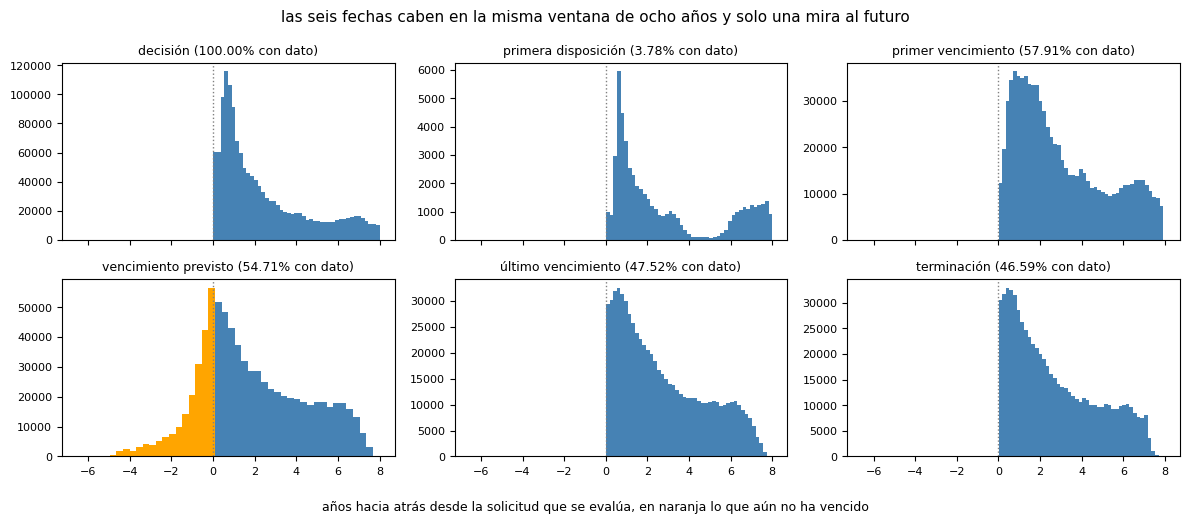

In [87]:
# la ventana es la misma para las seis y solo el vencimiento previsto mira hacia delante
TITULOS = {"DAYS_DECISION": "decisión", "DAYS_FIRST_DRAWING": "primera disposición",
           "DAYS_FIRST_DUE": "primer vencimiento", "DAYS_LAST_DUE_1ST_VERSION": "vencimiento previsto",
           "DAYS_LAST_DUE": "último vencimiento", "DAYS_TERMINATION": "terminación"}

fig, axes = plt.subplots(2, 3, figsize=(12, 5.2), sharex=True)
for ax, c in zip(axes.flatten(), FECHAS):
    _, bordes, parches = ax.hist(anios[c].dropna(), bins=45, color=COLOR_NODEF)
    for b, p in zip(bordes, parches):
        if b < 0:
            p.set_facecolor("orange")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(f"{TITULOS[c]} ({anios[c].notna().mean() * 100:.2f}% con dato)", fontsize=9)
    ax.tick_params(labelsize=8)
fig.supxlabel("años hacia atrás desde la solicitud que se evalúa, en naranja lo que aún no ha vencido",
              fontsize=9)
fig.suptitle("las seis fechas caben en la misma ventana de ocho años y solo una mira al futuro",
             fontsize=11)
plt.tight_layout()
plt.show()

In [88]:
# ¿seis fechas distintas o la misma escrita seis veces?
cor_fechas = fecha_real.corr()
pares = [(a, b, cor_fechas.loc[a, b]) for i, a in enumerate(FECHAS) for b in FECHAS[i + 1:]]
print(f"pares por encima de 0,70: {sum(abs(r) > 0.70 for _, _, r in pares)} de {len(pares)}")
for a, b, r in sorted(pares, key=lambda x: -abs(x[2]))[:4]:
    print(f"  {a} y {b}: {r:.4f}")
print("los dos que se salvan son los de la primera disposición, que solo cubre el 3,78%:")
for a, b, r in sorted(pares, key=lambda x: abs(x[2]))[:2]:
    print(f"  {a} y {b}: {r:.4f}")

pares por encima de 0,70: 13 de 15
  DAYS_FIRST_DRAWING y DAYS_FIRST_DUE: 0.9997
  DAYS_DECISION y DAYS_FIRST_DUE: 0.9994
  DAYS_DECISION y DAYS_FIRST_DRAWING: 0.9947
  DAYS_LAST_DUE y DAYS_TERMINATION: 0.9924
los dos que se salvan son los de la primera disposición, que solo cubre el 3,78%:
  DAYS_FIRST_DRAWING y DAYS_LAST_DUE_1ST_VERSION: 0.2392
  DAYS_FIRST_DRAWING y DAYS_TERMINATION: 0.4933


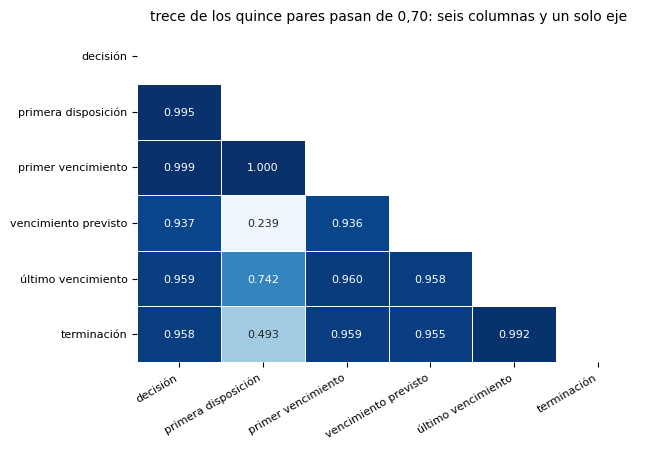

In [89]:
# el triángulo de abajo basta: la matriz es simétrica. la máscara va como frame alineado,
# porque con una lista seaborn la indexa por posición y acaba tapándolo todo
arriba = pd.DataFrame([[j >= i for j in range(len(FECHAS))] for i in range(len(FECHAS))],
                      index=cor_fechas.index, columns=cor_fechas.columns)

fig, ax = plt.subplots(figsize=(6.6, 4.6))
sns.heatmap(cor_fechas, mask=arriba, annot=True, fmt=".3f", cmap="Blues", vmin=0.2, vmax=1,
            cbar=False, linewidths=0.5, annot_kws={"size": 8},
            xticklabels=[TITULOS[c] for c in FECHAS], yticklabels=[TITULOS[c] for c in FECHAS], ax=ax)
ax.set_title("trece de los quince pares pasan de 0,70: seis columnas y un solo eje", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [90]:
# señal individual de cada fecha, medida donde tiene dato real
filas = []
for c in FECHAS:
    s = senal(anios[c])
    filas.append({"fecha": c, "n": s["n"], "cobertura %": round(s["n"] / len(pt) * 100, 2),
                  "Pearson": round(s["Pearson"], 4), "Spearman": round(s["Spearman"], 4),
                  "rank-biserial": round(s["r_rb"], 4)})
temporales = pd.DataFrame(filas).set_index("fecha").sort_values("rank-biserial", ascending=False)
display(temporales)

print("Pearson y Spearman coinciden en las seis, así que la relación es monótona y sin "
      "curvatura que obligue a transformar el valor antes de usarlo")
print(f"la que encabeza cubre el {temporales['cobertura %'].iloc[0]:.2f}% de las filas, "
      "así que antes de creérsela hay que ver de dónde le viene la señal")

,n,cobertura %,Pearson,Spearman,rank-biserial
fecha,,,,,
DAYS_FIRST_DRAWING,53501,3.78,-0.0957,-0.1013,0.1885
DAYS_DECISION,1413701,100.00,-0.0399,-0.0382,0.0784
DAYS_LAST_DUE_1ST_VERSION,773496,54.71,-0.0294,-0.0294,0.0647
DAYS_FIRST_DUE,818633,57.91,-0.0290,-0.0294,0.0639
DAYS_LAST_DUE,671803,47.52,-0.0225,-0.0216,0.0479
DAYS_TERMINATION,658595,46.59,-0.0221,-0.0210,0.0465


Pearson y Spearman coinciden en las seis, así que la relación es monótona y sin curvatura que obligue a transformar el valor antes de usarlo
la que encabeza cubre el 3.78% de las filas, así que antes de creérsela hay que ver de dónde le viene la señal


In [91]:
# la primera disposición encabeza el ranking: ¿señal propia o la decisión con otro nombre?
disp = anios["DAYS_FIRST_DRAWING"].notna()
print(f"producto: {pt.loc[disp, 'NAME_CONTRACT_TYPE'].value_counts(normalize=True).mul(100).round(2).head(2).to_dict()}")
print(f"días entre la decisión y la disposición: mediana "
      f"{(fecha_real['DAYS_FIRST_DRAWING'] - pt['DAYS_DECISION']).median():.0f}, "
      f"Pearson entre ambas {cor_fechas.loc['DAYS_DECISION', 'DAYS_FIRST_DRAWING']:.4f}")
print(f"en la población de la disposición: ella rinde {senal(anios['DAYS_FIRST_DRAWING'])['r_rb']:.4f} "
      f"y la decisión {senal(anios['DAYS_DECISION'], disp)['r_rb']:.4f}")

tramo_dec = pd.cut(anios["DAYS_DECISION"], [0, 1, 2, 3, 8],
                   labels=["menos de 1 año", "de 1 a 2", "de 2 a 3", "de 3 a 8"])
filas = []
for k in tramo_dec.cat.categories:
    m = disp & tramo_dec.eq(k)
    filas.append({"estrato": k, "n": int(m.sum()),
                  "primera disposición": senal(anios["DAYS_FIRST_DRAWING"], m)["r_rb"],
                  "decisión": senal(anios["DAYS_DECISION"], m)["r_rb"]})
residual = pd.DataFrame(filas).set_index("estrato")
display(residual.round(4))

producto: {'Revolving loans': 99.99, 'Cash loans': 0.01}
días entre la decisión y la disposición: mediana 5, Pearson entre ambas 0.9947
en la población de la disposición: ella rinde 0.1885 y la decisión 0.1979


,n,primera disposición,decisión
estrato,,,
menos de 1 año,15477,0.0010,0.0306
de 1 a 2,12326,0.0063,0.0246
de 2 a 3,6563,0.0036,0.0147
de 3 a 8,19135,0.0721,0.0777


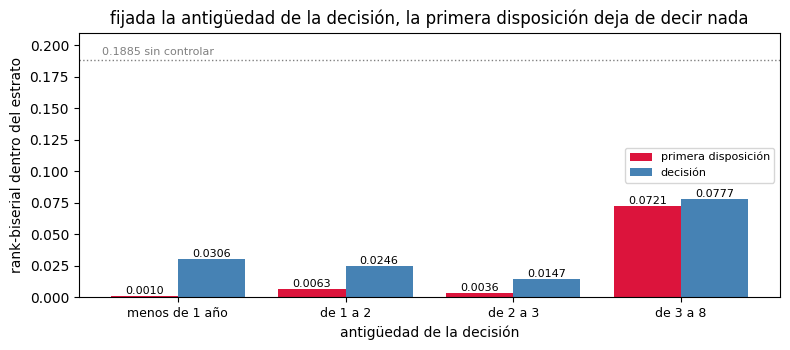

In [92]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(residual))
ax.bar([i - 0.2 for i in x], residual["primera disposición"], 0.4, color=COLOR_DEF,
       label="primera disposición")
ax.bar([i + 0.2 for i in x], residual["decisión"], 0.4, color=COLOR_NODEF, label="decisión")
for c in ax.containers:
    ax.bar_label(c, fmt="%.4f", fontsize=8)
ax.axhline(temporales.loc["DAYS_FIRST_DRAWING", "rank-biserial"], color="gray", ls=":", lw=1)
ax.text(-0.45, 0.192, "0.1885 sin controlar", fontsize=8, color="gray")
ax.set_xticks(list(x))
ax.set_xticklabels(residual.index, fontsize=9)
ax.set(xlabel="antigüedad de la decisión", ylabel="rank-biserial dentro del estrato", ylim=(0, 0.21),
       title="fijada la antigüedad de la decisión, la primera disposición deja de decir nada")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [93]:
# el gradiente de recencia en crudo, y los dos controles que hacen falta para leerlo
TRAMOS = [0, 0.5, 1, 2, 3, 5, 8]
ETIQ_T = ["menos de 6 meses", "de 6 meses a 1 año", "de 1 a 2 años", "de 2 a 3", "de 3 a 5", "de 5 a 8"]
tramo = pd.cut(anios["DAYS_DECISION"], TRAMOS, labels=ETIQ_T)
viva = pt["DAYS_TERMINATION"].eq(CENTINELA)
POBLACIONES = {"todas": pt["TARGET"].notna(), "aprobadas": aprobada,
               "aprobadas ya terminadas": aprobada & ~viva}

grad = pd.DataFrame({"solicitudes": pt.groupby(tramo, observed=True).size()})
for k, m in POBLACIONES.items():
    grad[k] = (pt[m].groupby(tramo[m], observed=True)["TARGET"].mean() * 100).round(2)
grad["% aprobadas"] = (pt.groupby(tramo, observed=True)["NAME_CONTRACT_STATUS"]
                       .apply(lambda s: s.eq("Approved").mean()) * 100).round(2)
grad["% de ellas aún vivas"] = (pt[aprobada].groupby(tramo[aprobada], observed=True)
                                .apply(lambda g: viva.loc[g.index].mean()) * 100).round(2)
display(grad)

for k, m in POBLACIONES.items():
    print(f"recencia de la decisión en {k}: rank-biserial {senal(anios['DAYS_DECISION'], m)['r_rb']:.4f}")
d, p = delta_z(pt.loc[aprobada & ~viva & tramo.eq("de 1 a 2 años"), "TARGET"],
               pt.loc[aprobada & ~viva & tramo.eq("menos de 6 meses"), "TARGET"])
print(f"el pico frente a la cabeza, ya sin estado ni contrato vivo: {d:+.2f}pp (p={p:.1e})")

,solicitudes,todas,aprobadas,aprobadas ya terminadas,% aprobadas,% de ellas aún vivas
DAYS_DECISION,,,,,,
menos de 6 meses,196966,9.48,8.00,6.94,28.78,77.77
de 6 meses a 1 año,303846,9.85,8.52,7.81,36.88,58.30
de 1 a 2 años,309105,9.36,8.27,8.24,68.68,23.24
de 2 a 3,179071,8.38,7.72,7.70,84.04,10.27
de 3 a 5,198920,7.34,7.02,6.97,83.12,4.25
de 5 a 8,225793,6.74,6.54,6.53,83.81,6.75


recencia de la decisión en todas: rank-biserial 0.0784


recencia de la decisión en aprobadas: rank-biserial 0.0567


recencia de la decisión en aprobadas ya terminadas: rank-biserial 0.0493
el pico frente a la cabeza, ya sin estado ni contrato vivo: +1.31pp (p=2.3e-07)


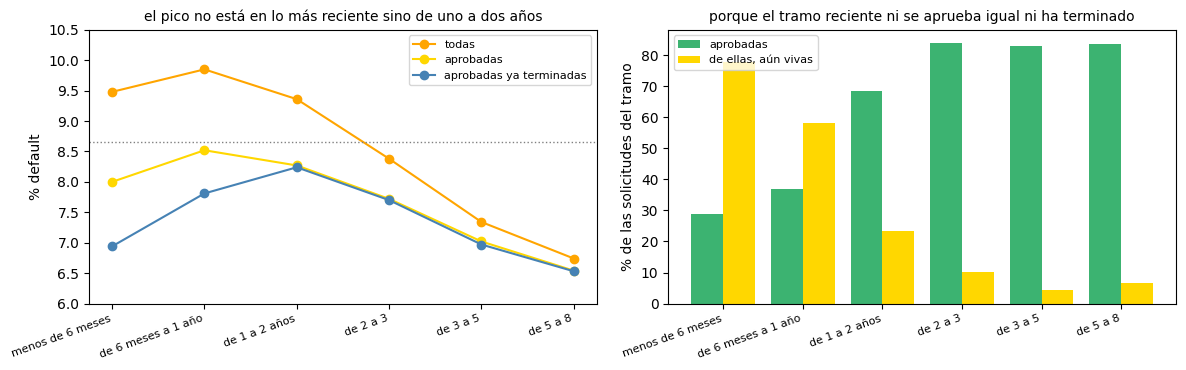

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for k, color in zip(POBLACIONES, ["orange", "gold", COLOR_NODEF]):
    ax[0].plot(range(len(grad)), grad[k], marker="o", color=color, label=k)
ax[0].axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].set_xticks(range(len(grad)))
ax[0].set_xticklabels(grad.index, rotation=20, ha="right", fontsize=8)
ax[0].set(ylabel="% default", ylim=(6, 10.5))
ax[0].set_title("el pico no está en lo más reciente sino de uno a dos años", fontsize=10)
ax[0].legend(fontsize=8)

x = range(len(grad))
ax[1].bar([i - 0.2 for i in x], grad["% aprobadas"], 0.4, color="mediumseagreen", label="aprobadas")
ax[1].bar([i + 0.2 for i in x], grad["% de ellas aún vivas"], 0.4, color="gold",
          label="de ellas, aún vivas")
ax[1].set_xticks(list(x))
ax[1].set_xticklabels(grad.index, rotation=20, ha="right", fontsize=8)
ax[1].set(ylabel="% de las solicitudes del tramo")
ax[1].set_title("porque el tramo reciente ni se aprueba igual ni ha terminado", fontsize=10)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Las seis fechas de esta tabla describen el mismo recorrido de una operación, así que antes de creerme ninguna quería saber cuánto se solapan. Todas se miden sobre dato real, quitando el hueco y el centinela, porque ya había concluido que el centinela no es dato ausente sino contrato todavía vivo.

La cobertura es muy desigual. La decisión está en el 100% de las filas, el primer vencimiento en el 57,91%, el vencimiento previsto en el 54,71%, el último vencimiento en el 47,52%, la terminación en el 46,59% y la primera disposición en apenas el 3,78%, porque en esa columna el centinela se lleva el 56,52%. Las seis caben en la misma ventana de ocho años y solo una mira hacia delante: `DAYS_LAST_DUE_1ST_VERSION` tiene el 13,76% de sus filas apuntando hasta 6,54 años por delante de la solicitud que se evalúa, coherente con que sea el vencimiento previsto al firmar y no un hecho consumado.

Esperaba encontrar un par redundante, del estilo del que ya me había salido entre lo solicitado y el precio del bien, y lo que hay es un eje único. Trece de los quince pares superan 0,70, con la decisión y el primer vencimiento en 0,9994, el último vencimiento y la terminación en 0,9924 y la decisión y la primera disposición en 0,9947. Los dos únicos pares que se salvan, 0,2392 y 0,4933, son de la primera disposición, que es la que casi no tiene cobertura. La consecuencia es la misma que con los importes: no hay seis variables temporales, hay una sola fecha de referencia y lo que puede aportar información nueva son las diferencias entre ellas.

La señal individual coloca en cabeza a `DAYS_FIRST_DRAWING`, con 0,1885 de rank-biserial, muy por delante de la decisión (0,0784), el vencimiento previsto (0,0647), el primer vencimiento (0,0639), el último vencimiento (0,0479) y la terminación (0,0465). Pearson y Spearman coinciden en las seis, así que la relación es monótona y no tiene curvatura que obligue a transformar el valor. Pero la que encabeza cubre el 3,78% de las filas, y ese es justo el perfil de una señal que hay que verificar antes de celebrarla.

Y en efecto es prestada. La primera disposición es revolving en el 99,99% de los casos, va cinco días por detrás de la decisión y correlaciona 0,9947 con ella, o sea que es la fecha de la decisión escrita otra vez sobre las tarjetas. Dentro de su propia población la decisión rinde más (0,1979 frente a 0,1885), y fijando la antigüedad de la decisión la disposición se queda en 0,0010, 0,0063 y 0,0036 en los tres primeros estratos y en 0,0721 en el más antiguo, frente a 0,0306, 0,0246, 0,0147 y 0,0777 de la decisión, que aguanta en todos. Es el mismo test que en el buró rescató a la marca de registro actualizado del descarte, y aquí da el resultado contrario: `DAYS_FIRST_DRAWING` se cae. Con esto la columna queda descartada por partida doble, porque ya al analizar la ausencia de dato su hueco resultó ser el efecto de la tarjeta y no información sobre el cliente.

Queda entonces la antigüedad de la decisión, y su gradiente no se puede leer en crudo. En bruto sale 9,48%, 9,85%, 9,36%, 8,38%, 7,34% y 6,74% desde el tramo más reciente al más antiguo, con la cabeza rota. El primer control es el de siempre en esta tabla, el estado de la operación: en el tramo de menos de seis meses solo el 28,78% está aprobado frente al 84,04% del tramo de dos a tres años, que es la desaparición de la cancelación del registro vista ahora desde el eje del tiempo. Dentro de las aprobadas el gradiente mejora pero sigue roto (8,00%, 8,52%, 8,27%, 7,72%, 7,02% y 6,54%), y el segundo control lo explica: el 77,77% de las operaciones aprobadas de menos de seis meses sigue viva, así que ni siquiera ha tenido tiempo de comportarse. Quitando las dos cosas queda una U invertida limpia, con 6,94%, 7,81%, 8,24%, 7,70%, 6,97% y 6,53%, y el pico en el tramo de uno a dos años, 1,31pp por encima de la cabeza (p = 2,3e-07). La señal de la recencia va bajando conforme limpio, de 0,0784 a 0,0567 y a 0,0493.

Eso es exactamente lo contrario de lo que encontré en el buró, donde la antigüedad del crédito era monótona decreciente y la variable más fuerte de toda la tabla, con 0,1427 y un recorrido del 10,8% al 5,8%. La explicación encaja con la inversión de signo que ya me había dado la ausencia de solicitudes previas: una operación reciente con el propio prestamista no es una señal de alarma, porque acaba de pasar su filtro de riesgo, mientras que una consulta reciente en el buró es exposición que el prestamista no vio. El riesgo aquí está en la operación que lleva ya un año o dos de vida, tiempo suficiente para haberse deteriorado.

In [95]:
# el contrato trae dos fechas de fin, la prevista al firmar y la efectiva: la diferencia es
# información que ninguna de las dos tiene sola
adelanto = fecha_real["DAYS_LAST_DUE_1ST_VERSION"] - fecha_real["DAYS_LAST_DUE"]
con_ambas = adelanto.notna()
print(f"operaciones con las dos fechas: {int(con_ambas.sum()):,}")
print(f"termina antes de lo previsto {adelanto.gt(0).sum() / con_ambas.sum() * 100:.2f}% | "
      f"en la fecha prevista {adelanto.eq(0).sum() / con_ambas.sum() * 100:.2f}% | "
      f"más tarde {adelanto.lt(0).sum() / con_ambas.sum() * 100:.2f}% "
      f"({int(adelanto.lt(0).sum()):,} operaciones)")

TRAMOS_A = [-4000, -0.5, 0.5, 30, 365, 4000]
ETIQ_A = ["termina más tarde", "en la fecha prevista", "hasta un mes antes",
          "de uno a doce meses antes", "más de un año antes"]
tramo_a = pd.cut(adelanto, TRAMOS_A, labels=ETIQ_A)
liquidacion = pt.groupby(tramo_a, observed=True)["TARGET"].agg(operaciones="size", tasa="mean")
liquidacion["% default"] = (liquidacion.pop("tasa") * 100).round(2)
display(liquidacion)

# el que liquida muy pronto es el de plazo largo, así que hay que fijar el plazo antes de creérselo
pronto = adelanto.gt(365)
d, p = delta_z(pt.loc[pronto, "TARGET"], pt.loc[con_ambas & ~pronto, "TARGET"])
print(f"\nliquidar con más de un año de adelanto: {d:+.2f}pp (p={p:.1e})")
print(f"producto: {pt.loc[pronto, 'NAME_CONTRACT_TYPE'].value_counts(normalize=True).mul(100).round(2).head(2).to_dict()}"
      f" | plazo mediano {pt.loc[pronto, 'CNT_PAYMENT'].median():.0f} frente a "
      f"{pt.loc[con_ambas & ~pronto, 'CNT_PAYMENT'].median():.0f}")
plazo = pd.cut(pt["CNT_PAYMENT"], [0, 12, 24, 60, 100],
               labels=["hasta 12", "de 13 a 24", "de 25 a 60", "más de 60"])
for k in plazo.cat.categories:
    m = con_ambas & plazo.eq(k)
    if (m & pronto).sum() > 200:
        d, p = delta_z(pt.loc[m & pronto, "TARGET"], pt.loc[m & ~pronto, "TARGET"])
        print(f"  dentro del plazo {k}: {d:+.2f}pp (n={int((m & pronto).sum()):,}, p={p:.1e})")

previsto = fecha_real["DAYS_LAST_DUE_1ST_VERSION"] - fecha_real["DAYS_FIRST_DUE"]
print(f"\nadelanto en días {senal(adelanto)['r_rb']:.4f} frente a adelanto sobre el plazo previsto "
      f"{senal(adelanto / previsto.where(previsto > 30))['r_rb']:.4f}: entra la versión absoluta")

operaciones con las dos fechas: 651,088
termina antes de lo previsto 48.24% | en la fecha prevista 51.64% | más tarde 0.12% (791 operaciones)


,operaciones,% default
termina más tarde,791,8.60
en la fecha prevista,336225,7.03
hasta un mes antes,66835,6.52
de uno a doce meses antes,182997,7.25
más de un año antes,64240,10.14



liquidar con más de un año de adelanto: +3.10pp (p=3.8e-180)
producto: {'Cash loans': 86.1, 'Consumer loans': 13.9} | plazo mediano 36 frente a 12
  dentro del plazo de 13 a 24: +2.14pp (n=25,341, p=1.0e-28)
  dentro del plazo de 25 a 60: +3.81pp (n=38,878, p=3.4e-24)



adelanto en días 0.0480 frente a adelanto sobre el plazo previsto 0.0420: entra la versión absoluta


In [96]:
# liquidar mucho antes de tiempo, ¿es buen comportamiento o es refinanciar? lo delata que haya
# otra solicitud pegada al cierre
cierres = (pt.loc[con_ambas, ["SK_ID_PREV", "SK_ID_CURR"]]
           .assign(cierre=fecha_real.loc[con_ambas, "DAYS_LAST_DUE"]))
cruce = cierres.merge(pt[["SK_ID_PREV", "SK_ID_CURR", "DAYS_DECISION"]], on="SK_ID_CURR",
                      suffixes=("", "_otra"))
cruce = cruce[cruce["SK_ID_PREV"] != cruce["SK_ID_PREV_otra"]]  # fuera la propia operación
pegada = (cruce.assign(cerca=(cruce["DAYS_DECISION"] - cruce["cierre"]).abs().le(90))
          .groupby("SK_ID_PREV")["cerca"].any()
          .reindex(pt.loc[con_ambas, "SK_ID_PREV"], fill_value=False).values)

print(f"otra solicitud en los 90 días alrededor del cierre: "
      f"{pegada[pronto[con_ambas]].mean() * 100:.2f}% de las que liquidan con más de un año de "
      f"adelanto frente al {pegada[~pronto[con_ambas]].mean() * 100:.2f}% del resto")
d, p = delta_z(pt.loc[con_ambas, "TARGET"][pegada], pt.loc[con_ambas, "TARGET"][~pegada])
print(f"la solicitud pegada al cierre, por sí sola: {d:+.2f}pp (p={p:.1e}), o sea que lo que marca "
      "es liquidar pronto y no encadenar operaciones")

otra solicitud en los 90 días alrededor del cierre: 55.80% de las que liquidan con más de un año de adelanto frente al 38.91% del resto
la solicitud pegada al cierre, por sí sola: +0.85pp (p=6.0e-38), o sea que lo que marca es liquidar pronto y no encadenar operaciones


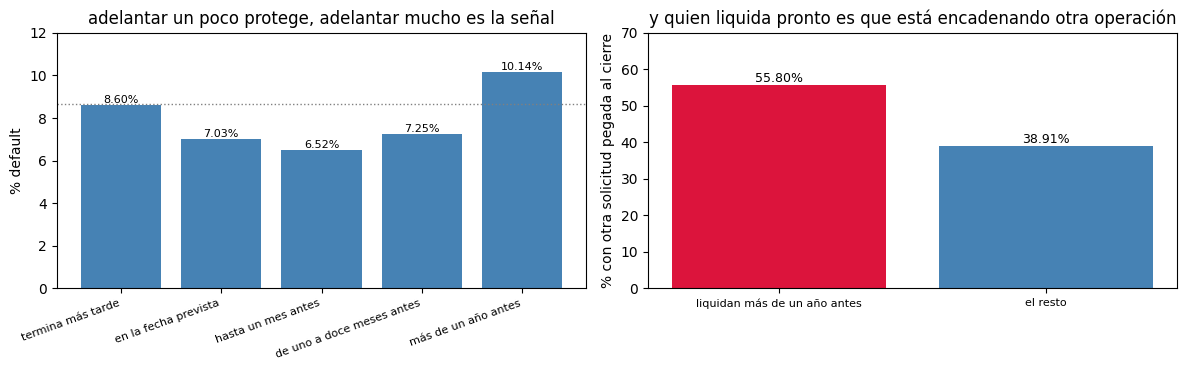

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(liquidacion.index.astype(str), liquidacion["% default"], color=COLOR_NODEF)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f%%", fontsize=8)
ax[0].axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].set(ylabel="% default", ylim=(0, 12),
          title="adelantar un poco protege, adelantar mucho es la señal")
plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)

reparto = pd.Series({"liquidan más de un año antes": pegada[pronto[con_ambas]].mean() * 100,
                     "el resto": pegada[~pronto[con_ambas]].mean() * 100})
ax[1].bar(reparto.index, reparto.values, color=[COLOR_DEF, COLOR_NODEF])
ax[1].bar_label(ax[1].containers[0], fmt="%.2f%%", fontsize=9)
ax[1].set(ylabel="% con otra solicitud pegada al cierre", ylim=(0, 70),
          title="y quien liquida pronto es que está encadenando otra operación")
plt.setp(ax[1].get_xticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

In [98]:
# el orden de las fechas es una comprobación barata que dice si la tabla está bien construida
ORDEN = [("DAYS_DECISION", "DAYS_FIRST_DRAWING"), ("DAYS_DECISION", "DAYS_FIRST_DUE"),
         ("DAYS_FIRST_DUE", "DAYS_LAST_DUE"), ("DAYS_LAST_DUE", "DAYS_TERMINATION")]
filas = []
for a, b in ORDEN:
    x, y = fecha_real[a], fecha_real[b]
    m = x.notna() & y.notna()
    filas.append({"orden esperado": f"{TITULOS[a]} antes que {TITULOS[b]}", "operaciones": int(m.sum()),
                  "lo incumplen": int((x[m] > y[m]).sum()), "%": round((x[m] > y[m]).mean() * 100, 3)})
display(pd.DataFrame(filas).set_index("orden esperado"))

desfase = fecha_real["DAYS_TERMINATION"] - fecha_real["DAYS_LAST_DUE"]
print(f"de la última cuota al cierre del contrato: mediana {desfase.median():.0f} días, p95 "
      f"{desfase.quantile(0.95):.0f}, y solo el {desfase.gt(30).mean() * 100:.2f}% pasa del mes")
duracion = (fecha_real["DAYS_LAST_DUE"] - fecha_real["DAYS_FIRST_DUE"]) / 30.44
m = duracion.notna() & pt["CNT_PAYMENT"].gt(1)
print(f"duración real entre plazo pactado: mediana "
      f"{(duracion[m] / (pt['CNT_PAYMENT'][m] - 1)).median():.3f}, el contrato dura lo que se firmó")

,operaciones,lo incumplen,%
orden esperado,,,
decisión antes que primera disposición,53501,6,0.011
decisión antes que primer vencimiento,818633,0,0.000
primer vencimiento antes que último vencimiento,671803,0,0.000
último vencimiento antes que terminación,654477,273,0.042


de la última cuota al cierre del contrato: mediana 6 días, p95 19, y solo el 1.39% pasa del mes
duración real entre plazo pactado: mediana 0.986, el contrato dura lo que se firmó


In [99]:
# la única fecha que mira al futuro es deuda con el propio prestamista que sigue viva el día
# de la solicitud que se evalúa
futuro = fecha_real["DAYS_LAST_DUE_1ST_VERSION"]
por_vencer = futuro.gt(0)
d, p = delta_z(pt.loc[por_vencer, "TARGET"], pt.loc[futuro.le(0), "TARGET"])
print(f"operaciones con cuotas aún por vencer: {int(por_vencer.sum()):,} "
      f"({por_vencer.mean() * 100:.2f}%), delta frente a las ya vencidas {d:+.2f}pp (p={p:.1e})")

tramo_f = pd.cut(futuro / 365.25, [0, 0.5, 1, 2, 7],
                 labels=["menos de 6 meses", "de 6 meses a 1 año", "de 1 a 2 años", "más de 2 años"])
comprometida = pt.groupby(tramo_f, observed=True)["TARGET"].agg(operaciones="size", tasa="mean")
comprometida["% default"] = (comprometida.pop("tasa") * 100).round(2)
comprometida["% aprobadas"] = (pt.groupby(tramo_f, observed=True)["NAME_CONTRACT_STATUS"]
                               .apply(lambda s: s.eq("Approved").mean()) * 100).round(2)
display(comprometida)
print(f"lo que queda por vencer, como continua: {senal(futuro.where(por_vencer))['r_rb']:.4f} | "
      f"dentro de aprobadas {senal(futuro.where(por_vencer), aprobada)['r_rb']:.4f}, y son la misma "
      "cifra porque el plan solo existe donde la operación se formalizó")

operaciones con cuotas aún por vencer: 194,538 (13.76%), delta frente a las ya vencidas +1.42pp (p=2.6e-95)


,operaciones,% default,% aprobadas
DAYS_LAST_DUE_1ST_VERSION,,,
menos de 6 meses,77253,7.37,100.0
de 6 meses a 1 año,46882,8.41,100.0
de 1 a 2 años,38785,9.63,100.0
más de 2 años,31618,10.05,100.0


lo que queda por vencer, como continua: 0.0810 | dentro de aprobadas 0.0810, y son la misma cifra porque el plan solo existe donde la operación se formalizó


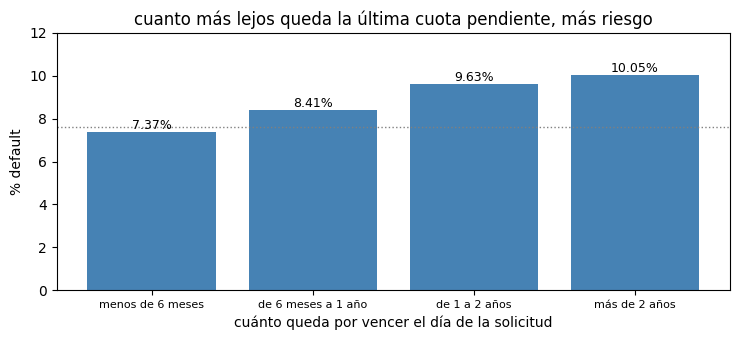

In [100]:
fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.bar(comprometida.index.astype(str), comprometida["% default"], color=COLOR_NODEF)
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=9)
ax.axhline(pt.loc[aprobada, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax.set(ylabel="% default", xlabel="cuánto queda por vencer el día de la solicitud", ylim=(0, 12),
       title="cuanto más lejos queda la última cuota pendiente, más riesgo")
plt.setp(ax.get_xticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

In [101]:
# lo que el eje temporal deja a nivel cliente: cuánto lleva de relación, a qué ritmo pide y
# cuánto ha pedido hace poco
con_prev = tiene_prev.values  # nombre propio: el de la sección de la variable marco se reutilizó luego
por_cliente = prev_t.groupby("SK_ID_CURR")["DAYS_DECISION"]
train["PREV_DAYS_DECISION_MIN"] = por_cliente.min().reindex(train["SK_ID_CURR"]).values
train["PREV_DAYS_DECISION_MAX"] = por_cliente.max().reindex(train["SK_ID_CURR"]).values
train["PREV_RELACION_ANIOS"] = -train["PREV_DAYS_DECISION_MIN"] / 365.25
train["PREV_COUNT_12M"] = (prev_t[prev_t["DAYS_DECISION"] > -365].groupby("SK_ID_CURR").size()
                           .reindex(train["SK_ID_CURR"], fill_value=0).values)

# el ritmo de solicitudes ya está construido y medido, así que solo lo traigo para
# compararlo con las otras dos. las tres primeras no existen sin previas, así que el notna() ya las condiciona; la cuarta sí
# tiene un cero con sentido para todos, y ahí el grupo sin previas es el de menos riesgo
ev_cli.evaluar_continuas(["PREV_DAYS_DECISION_MIN", "PREV_DAYS_DECISION_MAX", "PREV_APPLICATIONS_PER_YEAR",
                          ("PREV_COUNT_12M", True, None, "global (relleno 0)"),
                          ("PREV_COUNT_12M", False, con_prev, "con previas")])

for col, cortes, etiq in [
        ("PREV_RELACION_ANIOS", [0, 1, 2, 4, 6, 8],
         ["menos de 1 año", "de 1 a 2", "de 2 a 4", "de 4 a 6", "de 6 a 8"]),
        ("PREV_COUNT_12M", [-1, 0, 1, 2, 3, 100], ["0", "1", "2", "3", "4 o más"])]:
    g = train.groupby(pd.cut(train[col], cortes, labels=etiq), observed=True)["TARGET"].agg(
        clientes="size", tasa="mean")
    g["% default"] = (g.pop("tasa") * 100).round(2)
    display(g)

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_DAYS_DECISION_MIN,no nulos (auto-cond.),291057,0.1129,4.76004798469751e-184,-1523.0,-1201.0
PREV_DAYS_DECISION_MAX,no nulos (auto-cond.),291057,0.0489,5.1598564441459114e-36,-302.0,-272.0
PREV_APPLICATIONS_PER_YEAR,no nulos (auto-cond.),291057,0.1149,1.3959601637940034e-190,1.0,1.2
PREV_COUNT_12M,global (relleno 0),307511,0.0689,1.1889270028057379e-80,1.0,1.0
PREV_COUNT_12M,con previas,291057,0.0639,9.81667754440462e-66,1.0,1.0


,clientes,% default
PREV_RELACION_ANIOS,,
menos de 1 año,22667,10.47
de 1 a 2,50911,10.23
de 2 a 4,68194,8.61
de 4 a 6,57412,7.50
de 6 a 8,91873,6.63


,clientes,% default
PREV_COUNT_12M,,
0,138825,7.30
1,61480,7.85
2,38318,8.25
3,23117,8.74
4 o más,45771,10.22


In [102]:
# tres controles antes de dar por buenas las de arriba
ev_aux = EvaluadorSenal(train, train["TARGET"])  # controles, no ranking

# su construcción ya lleva un suelo de medio año en el denominador: compruebo que la señal no
# depende de ese suelo midiéndola solo en relaciones de un año o más
largo = con_prev & (train["PREV_RELACION_ANIOS"] >= 1).values
print(f"clientes con menos de un año de relación: {int((con_prev & ~largo).sum()):,}")
ev_aux.evaluar_continuas([("PREV_APPLICATIONS_PER_YEAR", False, largo, "relación de un año o más")])

# la longitud de relación está censurada justo en los de historial recortado: ¿dice algo allí?
ev_aux.evaluar_continuas([("PREV_DAYS_DECISION_MIN", False, con_prev & ~recortado, "historial completo"),
                          ("PREV_DAYS_DECISION_MIN", False, con_prev & recortado, "historial recortado")])

# y el ritmo, ¿es la longitud de relación con otro nombre?
lb = pd.cut(train["PREV_RELACION_ANIOS"], [0, 1, 2, 4, 6, 8],
            labels=["menos de 1 año", "de 1 a 2", "de 2 a 4", "de 4 a 6", "de 6 a 8"])
ev_aux.evaluar_continuas([("PREV_APPLICATIONS_PER_YEAR", False, (lb == k).values, str(k))
                          for k in lb.cat.categories])
# el helper hace upsert por nombre, así que guardo aparte lo que la figura necesita
senal_ritmo = {}
for k in lb.cat.categories:
    v = train.loc[(lb == k).values, "PREV_APPLICATIONS_PER_YEAR"].dropna()
    y = train["TARGET"].loc[v.index]
    u, _ = mannwhitneyu(v[y == 0], v[y == 1])
    senal_ritmo[str(k)] = abs(2 * u / ((y == 0).sum() * (y == 1).sum()) - 1)

print("redundancia entre las candidatas, a nivel cliente:")
sub = train[con_prev]
for a, b in [("PREV_COUNT_12M", "PREV_APPLICATION_COUNT"), ("PREV_COUNT_12M", "PREV_APPLICATIONS_PER_YEAR"),
             ("PREV_APPLICATIONS_PER_YEAR", "PREV_APPLICATION_COUNT"),
             ("PREV_APPLICATIONS_PER_YEAR", "PREV_DAYS_DECISION_MIN"),
             ("PREV_DAYS_DECISION_MIN", "PREV_DAYS_DECISION_MAX")]:
    print(f"  {a} y {b}: {sub[a].corr(sub[b]):.4f}")

clientes con menos de un año de relación: 22,667


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATIONS_PER_YEAR,relación de un año o más,268390,0.1055,1.3497344176470378e-145,0.9,1.1


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_DAYS_DECISION_MIN,historial completo,237123,0.1053,4.8186189163715655e-139,-1343.0,-1070.0
PREV_DAYS_DECISION_MIN,historial recortado,53934,0.0032,0.7687450987363796,-2456.0,-2473.5


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATIONS_PER_YEAR,menos de 1 año,22667,0.0852,9.987533416740564e-12,2.0,2.2
PREV_APPLICATIONS_PER_YEAR,de 1 a 2,50911,0.1338,1.5690486228943197e-56,1.5,1.9
PREV_APPLICATIONS_PER_YEAR,de 2 a 4,68194,0.0824,1.3695499383784849e-25,1.2,1.3
PREV_APPLICATIONS_PER_YEAR,de 4 a 6,57412,0.0601,5.169859129110389e-11,0.9,1.0
PREV_APPLICATIONS_PER_YEAR,de 6 a 8,91873,0.0352,4.3020618058311605e-06,0.8,0.8


redundancia entre las candidatas, a nivel cliente:


  PREV_COUNT_12M y PREV_APPLICATION_COUNT: 0.7207
  PREV_COUNT_12M y PREV_APPLICATIONS_PER_YEAR: 0.6702
  PREV_APPLICATIONS_PER_YEAR y PREV_APPLICATION_COUNT: 0.5253
  PREV_APPLICATIONS_PER_YEAR y PREV_DAYS_DECISION_MIN: 0.3814
  PREV_DAYS_DECISION_MIN y PREV_DAYS_DECISION_MAX: 0.2518


In [103]:
# la actividad reciente se propone como bandera, así que mido el corte igual que hice con la cola
ev_corte.evaluar_flags([(f"corte en {k}", (train["PREV_COUNT_12M"] >= k).astype(int).values,
                         con_prev, "con previas") for k in (2, 3, 4, 5)])
print("cobertura sobre los que tienen previas: " + " | ".join(
    f"{k} o más {((train['PREV_COUNT_12M'] >= k) & con_prev).sum() / con_prev.sum() * 100:.2f}%"
    for k in (2, 3, 4, 5)))
ev_cli.evaluar_flags([("PREV_ACTIVIDAD_12M_COLA", (train["PREV_COUNT_12M"] >= 4).astype(int).values,
                       con_prev, "con previas")])

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
corte en 2,con previas,9.2% (n=107206),7.61% (n=183851),+1.59 pp,15.1,1.1927309753399777e-51
corte en 3,con previas,9.72% (n=68888),7.72% (n=222169),+2.01 pp,16.8,3.3816531782853344e-63
corte en 4,con previas,10.22% (n=45771),7.81% (n=245286),+2.41 pp,17.3,1.1017434021480685e-66
corte en 5,con previas,10.71% (n=30983),7.89% (n=260074),+2.82 pp,17.1,1.8640028478494587e-65


cobertura sobre los que tienen previas: 2 o más 36.83% | 3 o más 23.67% | 4 o más 15.73% | 5 o más 10.64%


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_ACTIVIDAD_12M_COLA,con previas,10.22% (n=45771),7.81% (n=245286),+2.41 pp,17.3,1.1017434021480685e-66


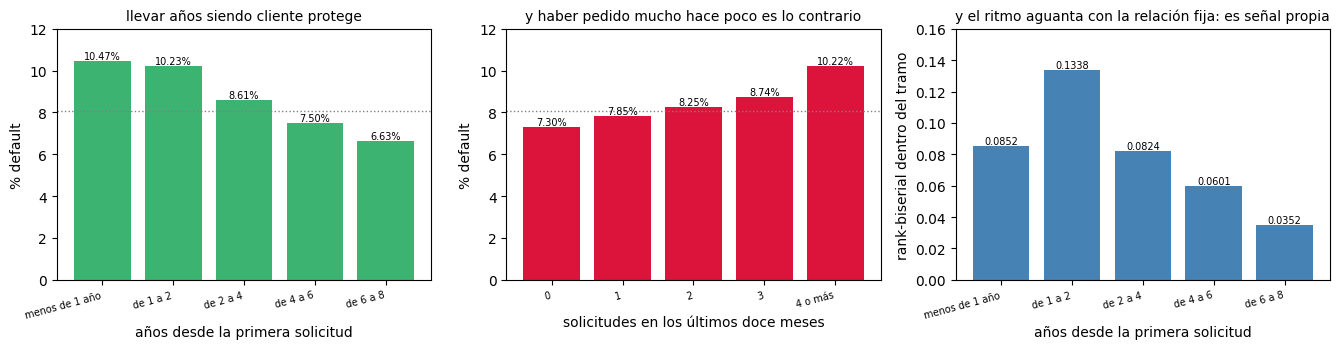

In [104]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
for i, (col, cortes, etiq, xlabel, color, titulo) in enumerate([
        ("PREV_RELACION_ANIOS", [0, 1, 2, 4, 6, 8],
         ["menos de 1 año", "de 1 a 2", "de 2 a 4", "de 4 a 6", "de 6 a 8"],
         "años desde la primera solicitud", "mediumseagreen", "llevar años siendo cliente protege"),
        ("PREV_COUNT_12M", [-1, 0, 1, 2, 3, 100], ["0", "1", "2", "3", "4 o más"],
         "solicitudes en los últimos doce meses", COLOR_DEF,
         "y haber pedido mucho hace poco es lo contrario")]):
    g = (train.groupby(pd.cut(train[col], cortes, labels=etiq), observed=True)["TARGET"].mean() * 100)
    ax[i].bar(g.index.astype(str), g.values, color=color)
    ax[i].bar_label(ax[i].containers[0], fmt="%.2f%%", fontsize=7)
    ax[i].axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
    ax[i].set(ylabel="% default", xlabel=xlabel, ylim=(0, 12))
    ax[i].set_title(titulo, fontsize=10)
    plt.setp(ax[i].get_xticklabels(), rotation=15, ha="right", fontsize=7)

ritmo = pd.Series(senal_ritmo)
ax[2].bar(ritmo.index, ritmo.values, color=COLOR_NODEF)
ax[2].bar_label(ax[2].containers[0], fmt="%.4f", fontsize=7)
ax[2].set(ylabel="rank-biserial dentro del tramo", xlabel="años desde la primera solicitud",
          ylim=(0, 0.16))
ax[2].set_title("y el ritmo aguanta con la relación fija: es señal propia", fontsize=10)
plt.setp(ax[2].get_xticklabels(), rotation=15, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

In [105]:
# las dos variables que salen del eje temporal están medidas por operación, así que las llevo al
# cliente antes de darlas por buenas
adelanto_cli = pt.loc[con_ambas].assign(p=adelanto[con_ambas].gt(365)).groupby("SK_ID_CURR")["p"]
formalizado = train["SK_ID_CURR"].isin(pt.loc[con_ambas, "SK_ID_CURR"]).values
train["PREV_EARLY_SETTLED_COUNT"] = adelanto_cli.sum().reindex(train["SK_ID_CURR"]).values
train["PREV_EARLY_SETTLED_RATIO"] = adelanto_cli.mean().reindex(train["SK_ID_CURR"]).values
print(f"clientes con alguna operación formalizada y ya terminada: {formalizado.sum():,} | "
      f"los otros {(~formalizado).sum():,} dan {train['TARGET'][~formalizado].mean() * 100:.2f}% "
      f"frente al {train['TARGET'][formalizado].mean() * 100:.2f}%, así que contaminan hacia arriba")

train["PREV_EARLY_SETTLED_FLAG"] = train["PREV_EARLY_SETTLED_COUNT"].fillna(0).gt(0).astype(int)
temprana = train["PREV_EARLY_SETTLED_FLAG"].values
ev_cli.evaluar_flags([("PREV_EARLY_SETTLED_FLAG", temprana, None, "global (relleno 0)"),
                      ("PREV_EARLY_SETTLED_FLAG", temprana, formalizado, "con operación terminada")])
ev_cli.evaluar_continuas([("PREV_EARLY_SETTLED_COUNT", False, None, "con operación terminada"),
                          ("PREV_EARLY_SETTLED_RATIO", False, None, "con operación terminada")])
temprana_grad = train.groupby(pd.cut(train["PREV_EARLY_SETTLED_COUNT"], [-1, 0, 1, 2, 50],
                                     labels=["0", "1", "2", "3 o más"]),
                              observed=True)["TARGET"].agg(clientes="size", tasa="mean")
temprana_grad["% default"] = (temprana_grad.pop("tasa") * 100).round(2)
display(temprana_grad)

clientes con alguna operación formalizada y ya terminada: 267,623 | los otros 39,888 dan 8.54% frente al 8.00%, así que contaminan hacia arriba


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_EARLY_SETTLED_FLAG,global (relleno 0),9.8% (n=47682),7.76% (n=259829),+2.05 pp,15.1,1.6087684523959246e-51
PREV_EARLY_SETTLED_FLAG,con operación terminada,9.8% (n=47682),7.61% (n=219941),+2.19 pp,16.0,1.6336200366043435e-57


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_EARLY_SETTLED_COUNT,con operación terminada,267623,0.0446,7.174685609620245e-60,0.0,0.0
PREV_EARLY_SETTLED_RATIO,con operación terminada,267623,0.0477,8.076911374598189e-68,0.0,0.0


,clientes,% default
PREV_EARLY_SETTLED_COUNT,,
0,219941,7.61
1,36020,9.50
2,8343,10.26
3 o más,3319,11.93


In [106]:
# la carga comprometida admite tres codificaciones y hay que ver cuál discrimina antes de elegir
train["PREV_FUTURE_DUE_COUNT"] = (pt.assign(f=por_vencer).groupby("SK_ID_CURR")["f"].sum()
                                  .reindex(train["SK_ID_CURR"]).values)
train["PREV_FUTURE_DUE_MAX"] = (pt.assign(f=futuro.where(por_vencer)).groupby("SK_ID_CURR")["f"]
                                .max().reindex(train["SK_ID_CURR"]).values)
tiene_futuro = train["PREV_FUTURE_DUE_COUNT"].fillna(0).gt(0)
print(f"tienen alguna operación con cuotas por vencer: "
      f"{(tiene_futuro & con_prev).sum() / con_prev.sum() * 100:.2f}% de los que tienen previas, "
      "o sea que como presencia reparte a casi todo el mundo")

ev_aux.evaluar_flags([("PREV_FUTURE_DUE_FLAG", tiene_futuro.astype(int).values, con_prev,
                       "con previas")])
ev_aux.evaluar_continuas([("PREV_FUTURE_DUE_COUNT", False, con_prev, "con previas")])
ev_cli.evaluar_continuas(["PREV_FUTURE_DUE_MAX"])
futuro_grad = train.groupby(pd.cut(train["PREV_FUTURE_DUE_MAX"] / 365.25, [0, 0.5, 1, 2, 7],
                                   labels=["menos de 6 meses", "de 6 meses a 1 año", "de 1 a 2 años",
                                           "más de 2 años"]),
                            observed=True)["TARGET"].agg(clientes="size", tasa="mean")
futuro_grad["% default"] = (futuro_grad.pop("tasa") * 100).round(2)
display(futuro_grad)
tasa_flag = [train["TARGET"][con_prev & ~tiene_futuro].mean() * 100,
             train["TARGET"][con_prev & tiene_futuro].mean() * 100]

tienen alguna operación con cuotas por vencer: 50.83% de los que tienen previas, o sea que como presencia reparte a casi todo el mundo


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_FUTURE_DUE_FLAG,con previas,8.3% (n=147954),8.08% (n=143103),+0.22 pp,2.2,0.028722466385198053


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_FUTURE_DUE_COUNT,con previas,291057,0.0126,0.00036729677477881367,1.0,1.0


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_FUTURE_DUE_MAX,no nulos (auto-cond.),147954,0.0842,4.6664211511356283e-54,275.0,334.0


,clientes,% default
PREV_FUTURE_DUE_MAX,,
menos de 6 meses,53581,7.11
de 6 meses a 1 año,35273,8.07
de 1 a 2 años,30596,9.13
más de 2 años,28504,9.95


In [107]:
# ¿el cliente va a peor con el tiempo? es la trayectoria que en el histórico mensual del buró sí
# aportaba, y el rechazo es el único estado comparable a lo largo de toda la ventana
medio = (pt.groupby("SK_ID_CURR")["DAYS_DECISION"].transform("min")
         + pt.groupby("SK_ID_CURR")["DAYS_DECISION"].transform("max")) / 2
mitades = pt.assign(r=rechazada, reciente=pt["DAYS_DECISION"] > medio)
rec = mitades[mitades["reciente"]].groupby("SK_ID_CURR")["r"].mean()
ant = mitades[~mitades["reciente"]].groupby("SK_ID_CURR")["r"].mean()
dos_mitades = train["SK_ID_CURR"].isin(rec.index.intersection(ant.index)).values
train["PREV_REFUSAL_TREND"] = (rec.reindex(train["SK_ID_CURR"]).values
                               - ant.reindex(train["SK_ID_CURR"]).values)
train["PREV_REFUSED_RATIO"] = (mitades.groupby("SK_ID_CURR")["r"].mean()
                               .reindex(train["SK_ID_CURR"]).values)
print(f"clientes con solicitudes en las dos mitades de su propia ventana: {dos_mitades.sum():,} "
      f"({dos_mitades.sum() / con_prev.sum() * 100:.2f}% de los que tienen previas)")

tray = pd.cut(train["PREV_REFUSAL_TREND"], [-1.01, -0.001, 0.001, 1.01],
              labels=["mejora", "estable", "empeora"])
tray_grad = train.groupby(tray, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
tray_grad["% default"] = (tray_grad.pop("tasa") * 100).round(2)
display(tray_grad)

# el contraste que decide: ¿aporta sobre el nivel de rechazo o es ese nivel con otro nombre?
ev_aux.evaluar_continuas([("PREV_REFUSAL_TREND", False, dos_mitades, "con las dos mitades"),
                          ("PREV_REFUSED_RATIO", False, dos_mitades, "con las dos mitades")])
print(f"Pearson entre el deterioro y el nivel de rechazo: "
      f"{train.loc[dos_mitades, 'PREV_REFUSAL_TREND'].corr(train.loc[dos_mitades, 'PREV_REFUSED_RATIO']):.4f}")
NIVELES = ["sin rechazos", "hasta el 25%", "del 25 al 50%", "más del 50%"]
nivel = pd.cut(train["PREV_REFUSED_RATIO"], [-0.01, 0.001, 0.25, 0.5, 1.01], labels=NIVELES)
residual_tray = {}
for k in NIVELES:
    m = dos_mitades & nivel.eq(k).values
    peor = m & tray.eq("empeora").values
    if peor.sum() > 200:
        d, p = delta_z(train["TARGET"][peor], train["TARGET"][m & ~tray.eq("empeora").values])
        residual_tray[k] = (train["TARGET"][peor].mean() * 100,
                            train["TARGET"][m & ~tray.eq("empeora").values].mean() * 100)
        print(f"  empeorar dentro de {k}: {d:+.2f}pp (n={peor.sum():,}, p={p:.1e})")

clientes con solicitudes en las dos mitades de su propia ventana: 233,016 (80.06% de los que tienen previas)


,clientes,% default
PREV_REFUSAL_TREND,,
mejora,34405,9.18
estable,136850,6.60
empeora,61761,10.83


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_REFUSAL_TREND,con las dos mitades,233016,0.0777,1.0176408420042737e-87,0.0,0.0
PREV_REFUSED_RATIO,con las dos mitades,233016,0.1604,0.0,0.0,0.1


Pearson entre el deterioro y el nivel de rechazo: 0.2943
  empeorar dentro de hasta el 25%: +0.91pp (n=29,724, p=4.6e-04)
  empeorar dentro de del 25 al 50%: +1.13pp (n=24,531, p=5.2e-04)
  empeorar dentro de más del 50%: +2.89pp (n=7,506, p=2.5e-04)


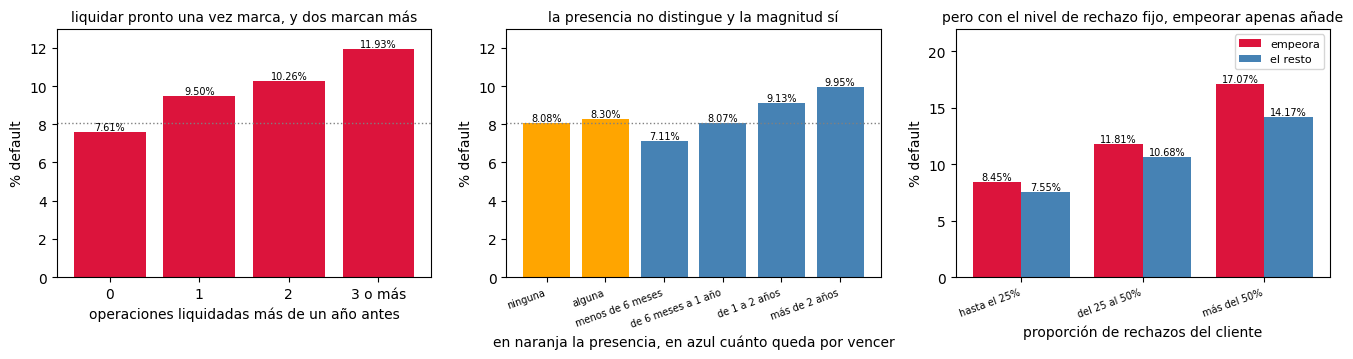

In [108]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
ax[0].bar(temprana_grad.index.astype(str), temprana_grad["% default"], color=COLOR_DEF)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f%%", fontsize=7)
ax[0].axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].set(ylabel="% default", xlabel="operaciones liquidadas más de un año antes", ylim=(0, 13))
ax[0].set_title("liquidar pronto una vez marca, y dos marcan más", fontsize=10)

etiquetas = ["ninguna", "alguna"] + list(futuro_grad.index.astype(str))
valores = tasa_flag + list(futuro_grad["% default"])
ax[1].bar(etiquetas, valores, color=["orange", "orange"] + [COLOR_NODEF] * len(futuro_grad))
ax[1].bar_label(ax[1].containers[0], fmt="%.2f%%", fontsize=7)
ax[1].axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[1].set(ylabel="% default", xlabel="en naranja la presencia, en azul cuánto queda por vencer",
          ylim=(0, 13))
ax[1].set_title("la presencia no distingue y la magnitud sí", fontsize=10)
plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right", fontsize=7)

x = range(len(residual_tray))
ax[2].bar([i - 0.2 for i in x], [v[0] for v in residual_tray.values()], 0.4, color=COLOR_DEF,
          label="empeora")
ax[2].bar([i + 0.2 for i in x], [v[1] for v in residual_tray.values()], 0.4, color=COLOR_NODEF,
          label="el resto")
for c in ax[2].containers:
    ax[2].bar_label(c, fmt="%.2f%%", fontsize=7)
ax[2].set_xticks(list(x))
ax[2].set_xticklabels(list(residual_tray), rotation=20, ha="right", fontsize=7)
ax[2].set(ylabel="% default", xlabel="proporción de rechazos del cliente", ylim=(0, 22))
ax[2].set_title("pero con el nivel de rechazo fijo, empeorar apenas añade", fontsize=10)
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [109]:
# la variable más fuerte de la tabla solo existe por operación: la llevo al cliente y compruebo
# con qué agregación, porque aquí no está claro que el máximo sea la buena
train["PREV_IMPLIED_COST_MEAN"] = coste.groupby(pt["SK_ID_CURR"]).mean().reindex(train["SK_ID_CURR"]).values
train["PREV_IMPLIED_COST_MAX"] = coste.groupby(pt["SK_ID_CURR"]).max().reindex(train["SK_ID_CURR"]).values
ev_cli.evaluar_continuas(["PREV_IMPLIED_COST_MEAN", "PREV_IMPLIED_COST_MAX"])
print(f"cobertura: {train['PREV_IMPLIED_COST_MEAN'].notna().mean() * 100:.2f}% de la cartera, "
      "así que no es una señal de nicho")

coste_grad = train.groupby(pd.cut(train["PREV_IMPLIED_COST_MEAN"], [0, 1.05, 1.15, 1.25, 1.4, 100],
                                  labels=["hasta 1,05", "de 1,05 a 1,15", "de 1,15 a 1,25",
                                          "de 1,25 a 1,4", "más de 1,4"]),
                          observed=True)["TARGET"].agg(clientes="size", tasa="mean")
coste_grad["% default"] = (coste_grad.pop("tasa") * 100).round(2)
display(coste_grad)

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_IMPLIED_COST_MEAN,no nulos (auto-cond.),287433,0.1334,8.906185208696516e-252,1.2999999523162842,1.2999999523162842
PREV_IMPLIED_COST_MAX,no nulos (auto-cond.),287433,0.0852,4.615247591912307e-104,1.2999999523162842,1.399999976158142


cobertura: 93.47% de la cartera, así que no es una señal de nicho


,clientes,% default
PREV_IMPLIED_COST_MEAN,,
"hasta 1,05",668,4.64
"de 1,05 a 1,15",54728,6.62
"de 1,15 a 1,25",86218,6.94
"de 1,25 a 1,4",84129,7.95
"más de 1,4",61690,11.53


In [110]:
# lo que esta tabla aporta por encima de lo que ya hay: los tres scores de la solicitud actual y
# las variables que ya conservo del buró
bureau_cli = load_table("bureau", usecols=["SK_ID_CURR", "CREDIT_ACTIVE", "DAYS_CREDIT",
                                           "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT"],
                        reduce_memory=False)
bureau_cli = bureau_cli[bureau_cli["SK_ID_CURR"].isin(train["SK_ID_CURR"])]
deuda = bureau_cli.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"].sum()
credito = bureau_cli.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"].sum()
YA_HAY = {
    "EXT_SOURCE_1": train["EXT_SOURCE_1"], "EXT_SOURCE_2": train["EXT_SOURCE_2"],
    "EXT_SOURCE_3": train["EXT_SOURCE_3"],
    "BUREAU_ACTIVE_COUNT": pd.Series(bureau_cli[bureau_cli["CREDIT_ACTIVE"].eq("Active")]
                                     .groupby("SK_ID_CURR").size().reindex(train["SK_ID_CURR"]).values),
    "BUREAU_DAYS_CREDIT_MIN": pd.Series(bureau_cli.groupby("SK_ID_CURR")["DAYS_CREDIT"].min()
                                        .reindex(train["SK_ID_CURR"]).values),
    "BUREAU_DEBT_CREDIT_RATIO": pd.Series((deuda / credito.replace(0, pd.NA))
                                          .reindex(train["SK_ID_CURR"]).values),
}
CANDIDATAS = ["PREV_IMPLIED_COST_MEAN", "PREV_DAYS_DECISION_MIN", "PREV_DAYS_DECISION_MAX",
              "PREV_APPLICATIONS_PER_YEAR", "PREV_COUNT_12M", "PREV_EARLY_SETTLED_FLAG",
              "PREV_FUTURE_DUE_MAX"]
solape = pd.DataFrame({k: {c: round(train.loc[con_prev, c].reset_index(drop=True)
                                    .corr(v[con_prev].reset_index(drop=True)), 4)
                           for c in CANDIDATAS} for k, v in YA_HAY.items()})
solape["|máximo|"] = solape.abs().max(axis=1)
display(solape.sort_values("|máximo|", ascending=False))
print(f"el solape más alto de toda la tabla es {solape['|máximo|'].max():.4f}, muy por debajo del "
      "umbral de 0,70 y del 0,391 que la rama del buró llegaba a tener con el score externo")

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_ACTIVE_COUNT,BUREAU_DAYS_CREDIT_MIN,BUREAU_DEBT_CREDIT_RATIO,|máximo|
PREV_DAYS_DECISION_MIN,-0.1077,-0.0547,-0.1098,-0.0740,0.2652,0.0748,0.2652
PREV_APPLICATIONS_PER_YEAR,-0.0519,-0.0510,-0.1831,0.0481,0.1121,0.0491,0.1831
PREV_COUNT_12M,-0.0056,-0.0265,-0.1389,0.0660,0.0120,0.0084,0.1389
PREV_DAYS_DECISION_MAX,-0.0409,-0.0320,-0.1114,0.0195,0.0688,0.0134,0.1114
PREV_FUTURE_DUE_MAX,0.1062,0.0182,0.0083,0.0392,-0.0754,-0.0065,0.1062
PREV_EARLY_SETTLED_FLAG,0.0426,0.0106,-0.0507,0.0980,-0.0583,0.0342,0.0980
PREV_IMPLIED_COST_MEAN,-0.0143,-0.0386,-0.0816,0.0822,-0.0215,0.0650,0.0822


el solape más alto de toda la tabla es 0.2652, muy por debajo del umbral de 0,70 y del 0,391 que la rama del buró llegaba a tener con el score externo


In [111]:
# la relación larga y la actividad reciente apuntan en direcciones contrarias: ¿se suman o se
# refuerzan? es la interacción que el buró dejó propuesta y aquí se puede medir
larga = (train["PREV_RELACION_ANIOS"] >= 4).values
activo = (train["PREV_COUNT_12M"] >= 4).values
inter = {}
for l, etiqueta_l in [(True, "relación de 4 años o más"), (False, "relación corta")]:
    for a, etiqueta_a in [(False, "menos de 4 en el año"), (True, "4 o más en el año")]:
        sel = con_prev & (larga == l) & (activo == a)
        inter[(etiqueta_l, etiqueta_a)] = (int(sel.sum()), train["TARGET"][sel].mean() * 100)
for k, (n, t) in inter.items():
    print(f"  {k[0]:26s} + {k[1]:22s} n={n:>7,}  {t:.2f}%")
esperado = (inter[("relación corta", "menos de 4 en el año")][1]
            + inter[("relación de 4 años o más", "4 o más en el año")][1]
            - inter[("relación de 4 años o más", "menos de 4 en el año")][1])
observado = inter[("relación corta", "4 o más en el año")][1]
print(f"si solo se sumaran, la esquina de riesgo daría {esperado:.2f}% y da {observado:.2f}%: "
      f"se refuerzan en {observado - esperado:+.2f}pp")

# la familia de la sección, contando cada contraste emitido
familia = 6 + 10 + 4 + 6 + 3 + 18 + 12 + 3  # fechas, disposición, recencia, liquidación,
print(f"familia de {familia} contrastes en la sección, "  # comprometida, cliente, cierre y este
      f"alfa de Bonferroni {0.05 / familia:.2e}")

  relación de 4 años o más   + menos de 4 en el año   n=125,505  6.69%
  relación de 4 años o más   + 4 o más en el año      n= 23,858  8.35%
  relación corta             + menos de 4 en el año   n=119,781  8.99%
  relación corta             + 4 o más en el año      n= 21,913  12.26%
si solo se sumaran, la esquina de riesgo daría 10.65% y da 12.26%: se refuerzan en +1.61pp
familia de 62 contrastes en la sección, alfa de Bonferroni 8.06e-04


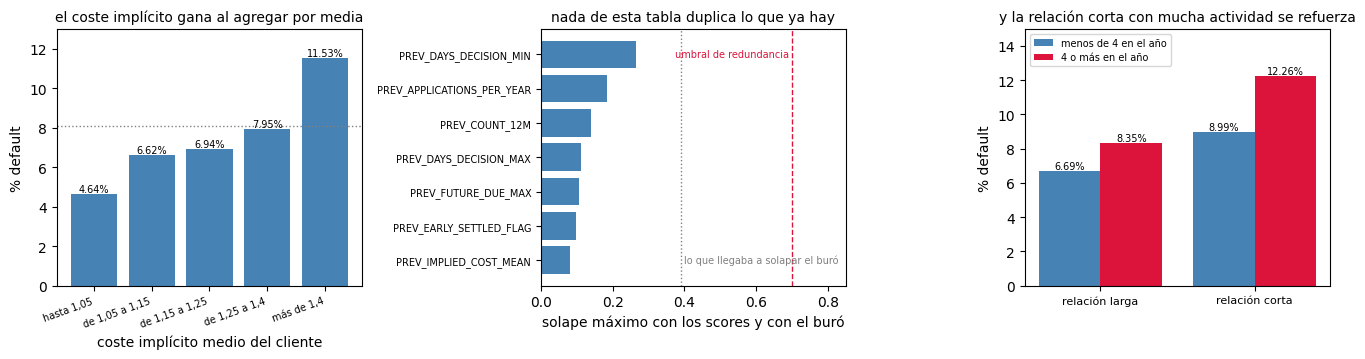

In [112]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
ax[0].bar(coste_grad.index.astype(str), coste_grad["% default"], color=COLOR_NODEF)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f%%", fontsize=7)
ax[0].axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].set(ylabel="% default", xlabel="coste implícito medio del cliente", ylim=(0, 13))
ax[0].set_title("el coste implícito gana al agregar por media", fontsize=10)
plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=7)

orden = solape["|máximo|"].sort_values()
ax[1].barh(range(len(orden)), orden.values, color=COLOR_NODEF)
ax[1].axvline(0.70, color=COLOR_DEF, ls="--", lw=1)
ax[1].text(0.69, len(orden) - 1, "umbral de redundancia", fontsize=7, color=COLOR_DEF,
           ha="right", va="center")
ax[1].axvline(0.391, color="gray", ls=":", lw=1)
ax[1].text(0.40, 0, "lo que llegaba a solapar el buró", fontsize=7, color="gray",
           va="center")
ax[1].set_yticks(range(len(orden)))
ax[1].set_yticklabels(orden.index, fontsize=7)
ax[1].set(xlabel="solape máximo con los scores y con el buró", xlim=(0, 0.85))
ax[1].set_title("nada de esta tabla duplica lo que ya hay", fontsize=10)

x = range(2)
for i, a in enumerate(["menos de 4 en el año", "4 o más en el año"]):
    ax[2].bar([j + (i - 0.5) * 0.4 for j in x],
              [inter[(l, a)][1] for l in ["relación de 4 años o más", "relación corta"]], 0.4,
              color=[COLOR_NODEF, COLOR_DEF][i], label=a)
for c_ in ax[2].containers:
    ax[2].bar_label(c_, fmt="%.2f%%", fontsize=7)
ax[2].set_xticks(list(x))
ax[2].set_xticklabels(["relación larga", "relación corta"], fontsize=8)
ax[2].set(ylabel="% default", ylim=(0, 15))
ax[2].set_title("y la relación corta con mucha actividad se refuerza", fontsize=10)
ax[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

El contrato trae dos fechas de fin, la prevista al firmar y la efectiva, y comparar una con otra es lo único que estas columnas saben que no sabe ninguna por separado. Sobre 651.088 operaciones con las dos, el 51,64% termina exactamente cuando estaba previsto, el 48,24% antes y 791 operaciones, el 0,12%, más tarde. Contaba con reproducir aquí lo que vi en el buró, donde el 23% de los créditos cerrados se liquidó pasada su fecha de vencimiento, y ese fenómeno sencillamente no existe con el propio prestamista.

Lo que hay es lo contrario, y otra vez con tres niveles en lugar de dos. Adelantar un poco protege, con 6,52% hasta un mes antes y 7,25% entre uno y doce meses, frente al 7,03% de las que cuadran con el plan. Adelantar mucho es la señal: liquidar con más de un año de antelación da 10,14%, es decir 3,10pp por encima del resto (p = 3,8e-180). Antes de darlo por bueno había que fijar el plazo, porque quien liquida muy pronto es el de préstamo largo (el 86,10% son préstamos en efectivo, con plazo mediano de 36 cuotas frente a 12), y aguanta dentro de cada tramo, con 2,14pp entre 13 y 24 cuotas y 3,81pp entre 25 y 60. La versión relativa al plazo previsto rinde menos que la absoluta (0,0420 frente a 0,0480), así que la que entra es la de días.

El mecanismo se puede comprobar y no es el que sugiere la intuición. El 55,80% de las operaciones que se liquidan con más de un año de adelanto tiene otra solicitud del mismo cliente en los noventa días alrededor del cierre, frente al 38,91% del resto: no es que el cliente pague antes porque le sobre el dinero, es que cancela la operación refinanciándola con otra. Y la coincidencia por sí sola casi no vale nada (0,85pp), así que lo que marca es liquidar pronto y no encadenar operaciones. Es la versión medida del perfil que ya había aparecido cuando el cliente declara que pide para pagar otros préstamos, con su 16,02% de default.

Las comprobaciones de coherencia salen limpias, que era lo esperable pero había que verlo. Ninguna operación tiene el primer vencimiento antes de la decisión ni el último antes del primero; 273 filas (0,042%) cierran antes de su última cuota y 6 disponen antes de la decisión. Del último vencimiento al cierre del contrato median 6 días, con p95 de 19 y solo el 1,39% pasando del mes, o sea que la terminación es el trámite administrativo del último pago: correlaciona 0,9924 con él y no es una fecha distinta, así que conservo una de las dos. Y la duración real dividida entre el plazo pactado da 0,986, lo que confirma que el contrato dura lo que se firmó y cierra la validez de esta parte del dato.

De lo que mira al futuro sale una variable con sentido de negocio directo. 194.538 operaciones (el 13,76%) siguen teniendo cuotas por vencer el día de la solicitud que se evalúa, y las cuatro son aprobadas al 100%, así que aquí no hay estado que controlar. Cuanto más lejos queda la última cuota pendiente, más riesgo: 7,37% a menos de seis meses, 8,41% hasta el año, 9,63% entre uno y dos años y 10,05% por encima, con 0,0810 como continua. Como bandera simple se queda en 1,42pp y no cruza el umbral, pero el extremo vale 2,68pp sobre el tramo corto, y conceptualmente es lo mismo que en el buró marcaban los vencimientos a medio plazo, con la diferencia de que esta deuda es con el propio prestamista y ya está contada en su exposición.

Llevado al cliente, el eje del tiempo invierte la jerarquía que traía del buró. Lo más fuerte es cuánto lleva de relación (0,1129) y a qué ritmo pide (0,1149), después cuánto ha pedido en el último año (0,0639), y lo más débil con diferencia es cuándo pidió por última vez (0,0489), que en el buró era la temporal principal con 0,1606. Encaja con la U invertida: si la solicitud reciente no marca a nivel de operación, tampoco va a marcar agregada. El recorrido de la longitud de relación va del 10,47% en quien lleva menos de un año al 6,63% en quien lleva de seis a ocho, y el de la actividad reciente va del 7,30% sin ninguna solicitud al 10,22% con cuatro o más.

Los tres controles cambian cómo hay que usarlas. La longitud de relación no dice nada dentro de los clientes de historial recortado (0,0032 con p = 0,77, frente a 0,1053 en los de historial completo), porque justo ahí está censurada contra el corte de ocho años y todos valen lo mismo: la longitud y la marca de recorte tienen que ir juntas o la primera engaña. El ritmo ya llevaba un suelo de medio año en su denominador, y su señal no depende de ese suelo: restringido a relaciones de un año o más se queda en 0,1055, y aguanta en los cinco tramos de longitud (0,0852, 0,1338, 0,0824, 0,0601 y 0,0352), así que es señal propia y no la longitud con otro nombre. Y la actividad del último año correlaciona 0,7207 con el total de solicitudes, por encima del umbral, de modo que entra una sola: me quedo con la reciente, que rinde el triple (0,0639 frente a 0,0210), no la censura la ventana de ocho años y responde a la pregunta de negocio que interesa. Con la salvedad de que al cruzar todas las candidatas entre sí la reciente pierde a su vez contra el ritmo, que la absorbe en estratos cruzados y la deja como fuente de su propia bandera. Su corte lo mido en vez de heredarlo, y sale el mismo canje de siempre entre efecto y cobertura: 1,59pp con dos o más, 2,01pp con tres, 2,41pp con cuatro y 2,82pp con cinco, cubriendo del 36,83% al 10,64%. Me quedo con cuatro o más, que es el primero que cruza dos puntos con cobertura razonable.

Las dos variables que salen de aquí estaban medidas por operación, y llevarlas al cliente cambia una de las dos. La liquidación anticipada aguanta: tener alguna operación cerrada con más de un año de adelanto da 2,19pp condicionado a haber terminado alguna, con un gradiente que sigue subiendo por conteo, del 7,61% sin ninguna al 9,50% con una, 10,26% con dos y 11,93% con tres o más. La carga comprometida, en cambio, hay que codificarla al revés de como la habría escrito. La presencia no sirve, porque la tiene el 50,83% de los clientes con previas y su diferencia es de 0,22pp, y el conteo tampoco (0,0126). Lo que discrimina es la magnitud, o sea cuánto queda por vencer, con 0,0842 y un recorrido del 7,11% al 9,95%. Es el mismo error que ya cometí con la mora del buró, donde la presencia tampoco valía y la señal vivía en el valor, y aquí lo habría repetido si me hubiese quedado en el nivel de operación.

Quedaba una hipótesis que la otra tabla de historial invita a probar, y aquí no se cumple. Si el cliente va a peor con el tiempo debería verse comparando la mitad reciente de su ventana con la anterior, y el rechazo es el único estado que se puede comparar a lo largo de los ocho años. Sobre los 233.016 clientes con solicitudes en las dos mitades, el 80,06% de los que tienen previas, quien empeora da 10,83% y quien mejora 9,18% frente al 6,60% de los estables, que a primera vista parece una trayectoria clara. Pero el deterioro rinde 0,0777 y la simple proporción de rechazos en esa misma población rinde 0,1604, más del doble, y con el nivel de rechazo fijo empeorar solo añade 0,91pp, 1,13pp y 2,89pp según el tramo. Lo que marca es cuántos rechazos acumula el cliente, no si se concentran al final, así que descarto la trayectoria: en el histórico mensual del buró la persistencia sí aportaba sobre la recencia, y aquí el análogo no se sostiene.

La variable más fuerte de la tabla no había llegado nunca al cliente, y hacerlo obliga a elegir agregación. El coste implícito por media rinde 0,1334 sobre el 93,47% de la cartera, con un gradiente que va del 4,64% al 11,53%, mientras que por máximo se queda en 0,0852. Es lo contrario de lo que suelo hacer con la señal rara, donde el máximo conserva el evento grave que la media diluye: aquí el coste no es un evento sino una característica del perfil de contratación del cliente, y promediarlo es justamente lo que lo estima mejor. La regla de agregar por máximo vale para lo que ocurre una vez y marca, no para lo que describe cómo suele financiarse alguien.

Queda la pregunta que decide si esta tabla merece el trabajo: qué aporta por encima de lo que ya tengo. El solape más alto de todas sus variables con los tres scores externos y con lo que conservo del historial del buró es de 0,2652, entre la longitud de relación y la antigüedad del historial del buró, que miden cosas parecidas; después no hay nada por encima de 0,19. El coste implícito, que es la señal más fuerte, se queda en 0,0822. Para comparar, la rama del buró llegaba a 0,391 con el score externo, hasta el punto de que allí las temporales quedaron condicionadas a demostrar aportación por encima de él. Aquí no hace falta esa condición y el motivo es de negocio: los scores externos son scores de buró y el buró no ve lo que pasa dentro de esta casa, ni la decisión de conceder, ni el precio al que se concedió, ni si el contrato se liquidó antes de tiempo para refinanciarlo. Esta tabla no compite con lo que ya hay, se suma.

Y hay una interacción que sí merece construirse, al revés que la del coste con la sobreconcesión, que resultó aditiva. La relación larga protege y la actividad reciente penaliza, y puestas juntas no se limitan a sumarse: relación larga con poca actividad da 6,69%, relación larga con cuatro o más solicitudes en el año 8,35%, relación corta con poca actividad 8,99% y relación corta con mucha actividad 12,26%, cuando la suma de los efectos predeciría 10,65%. Se refuerzan 1,61pp, así que el cliente nuevo que además está pidiendo mucho ahora mismo es peor que la suma de sus dos etiquetas. Es la misma interacción que el historial del buró dejó apuntada entre profundidad y recencia, y aquí está medida.

De todo el eje temporal se conservan siete cosas: la antigüedad de la decisión en tramos y no como valor continuo, por la U invertida; la liquidación anticipada en tres niveles con el corte en un año, ya validada también por cliente; cuánto queda por vencer, como magnitud y nunca como presencia; la longitud de relación acompañada de la marca de recorte; el ritmo de solicitudes con denominador mínimo; la actividad del último año como bandera de cuatro o más, cruzada con la longitud de relación porque las dos se refuerzan; y el coste implícito agregado por media, que es la señal más fuerte de la tabla y la que menos solapa con lo que ya hay. Se caen la primera disposición por ser la decisión con otro nombre, la terminación por ser el último vencimiento más una semana de trámite, y la trayectoria de rechazo por ser el nivel de rechazo con otro nombre. La recencia de la última solicitud a nivel cliente no se descarta pero tampoco entra por derecho propio: con 0,0489 se queda en la banda débil y le corresponde decidirse por su capacidad predictiva. Los dos primeros descartes son de redundancia estructural y no dependen del objetivo, así que quedan firmes; el de la trayectoria es por señal, y como todas las tasas están calculadas sobre el conjunto de entrenamiento completo, hay que reconfirmarlo sobre el partido. Con 62 contrastes en juego, el alfa de Bonferroni queda en 8,06e-04 y todo lo que he dado por bueno lo supera. Queda dicho además qué significa el hueco en cada una de estas variables, porque no es lo mismo en ninguna y ninguna se imputa: no tener longitud de relación ni ritmo es no haber pedido nunca aquí, que es el grupo más protector de todos con 5,96%; no tener nada por vencer es no deber nada hoy con esta casa; y no tener coste implícito es no haber llegado nunca a formalizar. Los tres son hechos, no desconocimiento, así que entran como tramo propio y rellenarlos con una mediana inventaría una relación que no existió. Y como cada cliente aporta 4,86 solicitudes que comparten etiqueta, lo medido a nivel de operación vuelve a revalidarse al agregar, esta vez con el control por recencia que la propia tabla ya ha demostrado que hace falta.

### 8. Análisis de Outliers

In [113]:
# el alcance: las magnitudes con cola, sin las dos tasas de interés que ya quedaron fuera por
# informarse en el 0,36% de las filas, más las dos proporciones derivadas, que son las que se agregan
EXTREMOS = {c: pt[c] for c in MAGNITUDES if not c.startswith("RATE_INTEREST")}
EXTREMOS["concedido entre solicitado"] = ratio
EXTREMOS["coste implícito"] = coste

# el cero es estado del contrato y no cantidad, así que el percentil se mide sobre dato real
real = {k: (v.where(v.ne(0)) if k in CEROS else v) for k, v in EXTREMOS.items()}

perc = pd.DataFrame([{"variable": k, "n con dato real": int(r.notna().sum()),
                      "p99": r.quantile(0.99), "máximo": r.max(),
                      "Máx/p99 con el cero dentro": float(EXTREMOS[k].max())
                      / float(EXTREMOS[k].quantile(0.99)),
                      "Máx/p99 sobre dato real": float(r.max()) / float(r.quantile(0.99))}
                     for k, r in real.items()]).set_index("variable").round(2)
perc["severo"] = perc["Máx/p99 sobre dato real"].gt(3).map({True: "sí", False: "no"})
display(perc)
print(f"severas con el criterio de máximo por encima de tres veces el percentil 99: "
      f"{int(perc['severo'].eq('sí').sum())} de {len(perc)}, y la más extrema llega a "
      f"{perc['Máx/p99 sobre dato real'].max():.2f} veces")

,n con dato real,p99,máximo,Máx/p99 con el cero dentro,Máx/p99 sobre dato real,severo
variable,,,,,,
AMT_ANNUITY,1105243,6.938284e+04,4.180582e+05,6.03,6.03,sí
AMT_APPLICATION,1088399,1.395000e+06,5.850000e+06,4.33,4.19,sí
AMT_CREDIT,1137123,1.546020e+06,4.509688e+06,2.98,2.92,no
AMT_DOWN_PAYMENT,664161,6.422220e+04,3.060045e+06,47.65,47.65,sí
AMT_GOODS_PRICE,1088416,1.395000e+06,5.850000e+06,4.19,4.19,sí
RATE_DOWN_PAYMENT,664161,5.200000e-01,1.000000e+00,1.92,1.92,no
CNT_PAYMENT,984503,6.000000e+01,8.400000e+01,1.40,1.40,no
concedido entre solicitado,1088398,1.380000e+00,1.700000e+01,12.36,12.36,sí
coste implícito,803684,2.250000e+00,3.000000e+00,1.33,1.33,no


severas con el criterio de máximo por encima de tres veces el percentil 99: 5 de 9, y la más extrema llega a 47.65 veces


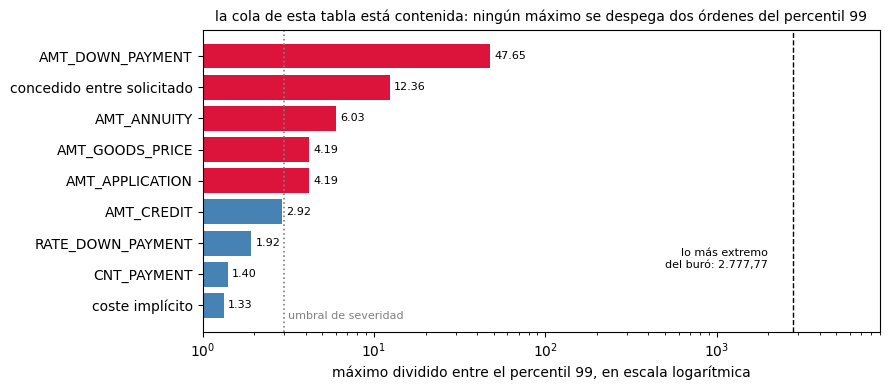

In [114]:
# la escala del buró al lado es lo que deja ver que aquí la cola está contenida
orden = perc["Máx/p99 sobre dato real"].sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(orden.index, orden, color=[COLOR_DEF if v > 3 else COLOR_NODEF for v in orden])
ax.bar_label(ax.containers[0], fmt="%.2f", fontsize=8, padding=3)
ax.axvline(3, color="gray", ls=":", lw=1.2)
ax.text(3.15, -0.45, "umbral de severidad", fontsize=8, color="gray")
ax.axvline(2777.77, color="black", ls="--", lw=1)
ax.text(2000, 1.2, "lo más extremo\ndel buró: 2.777,77", fontsize=8, ha="right")
ax.set(xscale="log", xlim=(1, 9000), ylabel="",
       xlabel="máximo dividido entre el percentil 99, en escala logarítmica")
ax.set_title("la cola de esta tabla está contenida: ningún máximo se despega dos órdenes del percentil 99",
             fontsize=10)
plt.tight_layout()
plt.show()

In [115]:
# los normales se restringen a dato real para no mezclar la cola con la ausencia ni con el cero de
# estado, y cada variable se mide además dentro de las aprobadas, que es el control de esta tabla
alfa = 0.05 / (2 * len(EXTREMOS))


def cola(v, pob):
    """tasa por encima del percentil 99 frente al resto, dentro de una población"""
    q = v[pob].quantile(0.99)
    fuera, dentro = pob & v.gt(q), pob & v.le(q)
    t1, t0 = pt["TARGET"][fuera], pt["TARGET"][dentro]
    tabla = [[len(t0) - t0.sum(), t0.sum()], [len(t1) - t1.sum(), t1.sum()]]
    minimo = min(min(f) for f in tabla)
    return {"umbral": q, "n": len(t1), "tasa": t1.mean() * 100, "resto": t0.mean() * 100,
            "delta": (t1.mean() - t0.mean()) * 100, "test": "Fisher" if minimo < 5 else "Chi2",
            "p": fisher_exact(tabla)[1] if minimo < 5 else chi2_contingency(tabla)[1], "fuera": fuera}


filas = []
for k, v in real.items():
    g, a = cola(v, v.notna()), cola(v, v.notna() & aprobada)
    filas.append({"variable": k, "umbral p99": round(g["umbral"], 2), "n cola": g["n"],
                  "delta global": round(g["delta"], 2), "n cola aprobadas": a["n"],
                  "tasa cola aprobadas": round(a["tasa"], 2),
                  "tasa resto aprobadas": round(a["resto"], 2),
                  "delta aprobadas": round(a["delta"], 2), "test": a["test"], "p aprobadas": a["p"],
                  "cola aprobada": pt["TARGET"][g["fuera"] & aprobada].mean() * 100,
                  "cola no aprobada": pt["TARGET"][g["fuera"] & ~aprobada].mean() * 100})
evidencia = pd.DataFrame(filas).set_index("variable").sort_values("delta aprobadas")
evidencia["supera Bonferroni"] = (evidencia["p aprobadas"] < alfa).map({True: "sí", False: "no"})
display(evidencia.drop(columns=["cola aprobada", "cola no aprobada"]))
print(f"familia de {2 * len(EXTREMOS)} contrastes en el bloque, alfa de Bonferroni {alfa:.2e}")
print(f"tasa de las aprobadas {pt['TARGET'][aprobada].mean() * 100:.2f}% y de las no aprobadas "
      f"{pt['TARGET'][~aprobada].mean() * 100:.2f}%")

,umbral p99,n cola,delta global,n cola aprobadas,tasa cola aprobadas,tasa resto aprobadas,delta aprobadas,test,p aprobadas,supera Bonferroni
variable,,,,,,,,,,
CNT_PAYMENT,60.00,178,10.41,60,3.33,7.44,-4.11,Fisher,3.235490e-01,no
AMT_ANNUITY,69382.84,11040,-3.39,8850,4.21,7.62,-3.40,Chi2,3.154770e-33,sí
AMT_DOWN_PAYMENT,64222.20,6642,-2.48,5593,4.63,7.35,-2.72,Chi2,9.565325e-15,sí
AMT_APPLICATION,1395000.00,10827,-0.50,8445,5.29,7.61,-2.31,Chi2,1.568543e-15,sí
AMT_GOODS_PRICE,1395000.00,10827,-0.50,8445,5.29,7.61,-2.31,Chi2,1.568543e-15,sí
AMT_CREDIT,1546020.00,11001,-0.30,8790,5.44,7.60,-2.17,Chi2,2.658134e-14,sí
RATE_DOWN_PAYMENT,0.52,6642,-2.22,5682,5.42,7.34,-1.92,Chi2,3.575253e-08,sí
concedido entre solicitado,1.38,10862,7.59,8467,13.06,7.53,5.53,Chi2,1.823020e-81,sí
coste implícito,2.25,8036,8.93,8036,16.28,7.35,8.93,Chi2,7.328892e-202,sí


familia de 18 contrastes en el bloque, alfa de Bonferroni 2.78e-03
tasa de las aprobadas 7.59% y de las no aprobadas 10.45%


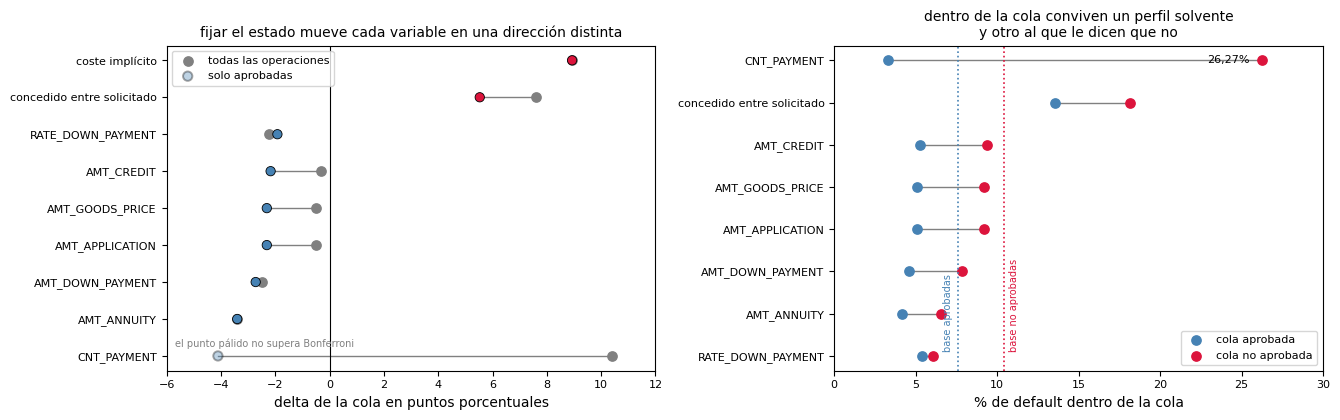

In [116]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.3))
y = range(len(evidencia))
for i, (g, a) in enumerate(zip(evidencia["delta global"], evidencia["delta aprobadas"])):
    ax[0].plot([g, a], [i, i], color="gray", lw=1, zorder=1)
ax[0].scatter(evidencia["delta global"], y, color="gray", s=45, zorder=2,
              label="todas las operaciones")
sig = evidencia["supera Bonferroni"].eq("sí")
ax[0].scatter(evidencia["delta aprobadas"], y, s=45, zorder=3, label="solo aprobadas",
              color=[COLOR_DEF if v > 0 else COLOR_NODEF for v in evidencia["delta aprobadas"]],
              edgecolors="black", linewidths=[0.6 if s else 1.4 for s in sig],
              alpha=[1.0 if s else 0.35 for s in sig])
ax[0].axvline(0, color="black", lw=0.8)
ax[0].set(yticks=list(y), yticklabels=evidencia.index, xlim=(-6, 12),
          xlabel="delta de la cola en puntos porcentuales")
ax[0].set_title("fijar el estado mueve cada variable en una dirección distinta", fontsize=10)
ax[0].legend(fontsize=8, loc="upper left")
ax[0].tick_params(labelsize=8)
ax[0].text(-5.7, 0.25, "el punto pálido no supera Bonferroni", fontsize=7, color="gray")

# el mecanismo: dentro de la cola conviven dos poblaciones con riesgo opuesto
m = evidencia.drop(index="coste implícito").sort_values("cola no aprobada")
p = range(len(m))
for i, (a, b) in enumerate(zip(m["cola aprobada"], m["cola no aprobada"])):
    ax[1].plot([a, b], [i, i], color="gray", lw=1, zorder=0)
ax[1].scatter(m["cola aprobada"], p, color=COLOR_NODEF, s=45, label="cola aprobada")
ax[1].scatter(m["cola no aprobada"], p, color=COLOR_DEF, s=45, label="cola no aprobada")
ax[1].axvline(pt["TARGET"][aprobada].mean() * 100, color=COLOR_NODEF, ls=":", lw=1.2)
ax[1].axvline(pt["TARGET"][~aprobada].mean() * 100, color=COLOR_DEF, ls=":", lw=1.2)
ax[1].annotate("26,27%", (26.27, len(m) - 1), fontsize=8, xytext=(-40, -2), textcoords="offset points")
ax[1].text(pt["TARGET"][aprobada].mean() * 100 - 0.3, 0.15, "base aprobadas", fontsize=7,
           color=COLOR_NODEF, rotation=90, ha="right")
ax[1].text(pt["TARGET"][~aprobada].mean() * 100 + 0.3, 0.15, "base no aprobadas", fontsize=7,
           color=COLOR_DEF, rotation=90)
ax[1].set(yticks=list(p), yticklabels=m.index, xlim=(0, 30), xlabel="% de default dentro de la cola")
ax[1].set_title("dentro de la cola conviven un perfil solvente\ny otro al que le dicen que no",
                fontsize=10)
ax[1].legend(fontsize=8, loc="lower right")
ax[1].tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [117]:
# el único delta positivo de las columnas crudas no se desvanece al fijar el estado, cambia de bando:
# hay que mirarlo dentro de las que no se aprobaron
plazo = pt["CNT_PAYMENT"].where(pt["CNT_PAYMENT"].ne(0))
larga, no_apr = plazo.notna() & plazo.gt(60), plazo.notna() & ~aprobada
d, p = delta_z(pt["TARGET"][larga & no_apr], pt["TARGET"][no_apr & ~larga])
print(f"pedir más de 60 cuotas y no obtenerlas: {pt['TARGET'][larga & no_apr].mean() * 100:.2f}% "
      f"frente a {pt['TARGET'][no_apr & ~larga].mean() * 100:.2f}%, o sea {d:+.2f}pp "
      f"(n={int((larga & no_apr).sum())}, p={p:.1e})")
print(f"estado: {pt.loc[larga & no_apr, 'NAME_CONTRACT_STATUS'].value_counts().head(2).to_dict()} | "
      f"producto: {pt.loc[larga & no_apr, 'NAME_CONTRACT_TYPE'].value_counts().head(2).to_dict()}")
print(f"motivo: {pt.loc[larga & no_apr, 'CODE_REJECT_REASON'].value_counts().head(3).to_dict()}")

tr_plazo = pd.cut(plazo, [0, 12, 24, 36, 60, 100],
                  labels=["hasta 12", "de 13 a 24", "de 25 a 36", "de 37 a 60", "más de 60"])
for nombre, pob in [("aprobadas", plazo.notna() & aprobada), ("no aprobadas", no_apr)]:
    g = pt[pob].groupby(tr_plazo[pob], observed=True)["TARGET"].agg(operaciones="size", tasa="mean")
    g["% default"] = (g.pop("tasa") * 100).round(2)
    print(f"\nplazo pactado dentro de las {nombre}")
    display(g)

pedir más de 60 cuotas y no obtenerlas: 26.27% frente a 11.18%, o sea +15.09pp (n=118, p=2.0e-07)
estado: {'Refused': 86, 'Canceled': 32} | producto: {'Cash loans': 88, 'Consumer loans': 30}
motivo: {'VERIF': 40, 'HC': 39, 'XAP': 32}

plazo pactado dentro de las aprobadas


,operaciones,% default
CNT_PAYMENT,,
hasta 12,553706,7.03
de 13 a 24,156699,7.76
de 25 a 36,49877,8.97
de 37 a 60,43346,9.75
más de 60,60,3.33



plazo pactado dentro de las no aprobadas


,operaciones,% default
CNT_PAYMENT,,
hasta 12,63751,9.55
de 13 a 24,40179,11.26
de 25 a 36,25609,12.72
de 37 a 60,51158,12.37
más de 60,118,26.27


Esperaba encontrar aquí el mismo descontrol que en el historial del buró, donde el máximo de la mora llegaba a 2.777,77 veces su percentil 99 y convivían importes de 396 millones que solo podían ser error de captura. No es el caso. Con el criterio de máximo por encima de tres veces el percentil 99 salen cinco variables de nueve, pero los márgenes van de 4,19 a 47,65 veces, y ninguno de los máximos es implausible para el negocio: 5.850.000 solicitados, 4.509.688 concedidos, una cuota de 418.058 y un plazo tope de 84 cuotas. La cola de esta tabla está contenida, así que lo que hay que averiguar no es cuánto se estira sino a quién marca. Y conviene no confundir los dos criterios, porque aquí apuntan a sitios distintos: de las cinco severas, cuatro tienen cola protectora y solo una lleva riesgo, mientras que la señal más fuerte de las nueve, el coste implícito, ni siquiera es severa, con 1,33. El cociente entre el máximo y el percentil 99 describe la forma de la distribución, no dónde está el riesgo, así que sirve para decidir a qué mirar y no para decidir qué se conserva.

Y eso lo decide el estado de la operación, igual que ocurría con la ausencia de dato y con las categóricas. Medida sobre todas las operaciones, la cola de lo solicitado y la de lo concedido no dicen nada, -0,50pp y -0,30pp. Dentro de las aprobadas pasan a -2,31pp y -2,17pp, o sea que fijar el estado no diluye la señal, la destapa. El mecanismo está en la composición: en la cola de lo solicitado solo se aprueba el 32,44% frente al 78,24% del resto, de modo que dentro del mismo grupo conviven un perfil solvente que consigue el importe grande, con un 5,10% de default, y otro que pide de más y recibe un no, con un 9,23%, y las dos mitades se cancelan al mezclarlas. La cuota y la entrada no necesitan ese control porque su cola ya está dominada por operaciones aprobadas, y marcan -3,40pp y -2,72pp. Las siete columnas crudas apuntan todas en la misma dirección, la protectora, que es el perfil solvente que ya aparecía en el importe del préstamo de la solicitud que se evalúa y en el crédito reportado al buró.

La excepción merece pararse. El plazo pactado es la única columna cruda con delta positivo, +10,41pp, y esperaba que se desvaneciera al fijar el estado como se desvanecieron la bandera de seguro y el código de zona. No se desvanece: cambia de bando. Dentro de las aprobadas queda en -4,11pp sobre 60 operaciones y sin superar Bonferroni, mientras que entre las que no se aprobaron pedir más de 60 cuotas da 26,27% frente a 11,18%, o sea +15,09pp con 118 operaciones y p de 2,0e-07. Son 86 rechazos y 32 canceladas, 88 préstamos en efectivo, y los motivos que constan son verificación e historial. La lectura de negocio es limpia: un plazo muy largo solo se concede a quien lo sostiene, y pedirlo sin obtenerlo es el marcador más severo que he medido en esta tabla, por encima del registro que no llegó a definirse. No es efecto propio del plazo, es interacción con la decisión, la misma firma que tenía la entrada cuando cambiaba de signo según el estado. Me lo llevo como candidata rara y severa para la agregación, con el aviso de que 118 operaciones son impacto de cartera mínimo.

In [118]:
# validez de dominio: es un eje aparte del de la señal, y aquí sale casi vacío
LIM = {"AMT_ANNUITY": 1_000_000, "AMT_APPLICATION": 10_000_000, "AMT_CREDIT": 10_000_000,
       "AMT_DOWN_PAYMENT": 10_000_000, "AMT_GOODS_PRICE": 10_000_000}
for c, lim in LIM.items():
    print(f"{c}: máximo {pt[c].max():,.0f}, por encima de {lim:,} hay {int(pt[c].gt(lim).sum())}")
print(f"el máximo de 6.905.160 anotado al mirar las distribuciones está fuera de los clientes "
      f"enlazables: {int(prev['AMT_CREDIT'].eq(6905160).sum())} fila en la tabla entera y "
      f"{int(pt['AMT_CREDIT'].eq(6905160).sum())} aquí")

neg_i, neg_t = pt["AMT_DOWN_PAYMENT"].lt(0), pt["RATE_DOWN_PAYMENT"].lt(0)
print(f"\nentrada negativa: {int(neg_i.sum())} filas con valores "
      f"{[round(float(v), 2) for v in sorted(pt.loc[neg_i, 'AMT_DOWN_PAYMENT'])]}, y son las mismas "
      f"que dejan la tasa por debajo de cero: {bool((neg_i == neg_t).all())}")
print(f"tasa de entrada fuera del intervalo de cero a uno: "
      f"{int((pt['RATE_DOWN_PAYMENT'].lt(0) | pt['RATE_DOWN_PAYMENT'].gt(1)).sum())} filas")
print(f"plazo máximo {pt['CNT_PAYMENT'].max():.0f} cuotas, y por encima de 60 solo hay "
      f"{pt['CNT_PAYMENT'][pt['CNT_PAYMENT'].gt(60)].value_counts().sort_index().to_dict()}")

z = pt["SELLERPLACE_AREA"]
print(f"\ncódigo de zona: máximo {z.max():,} con percentil 99 en {z.quantile(0.99):,.0f} y "
      f"{int(z.gt(100000).sum())} filas por encima de cien mil, pero es un código y el cociente "
      "no significa nada")
fr = pt[FECHAS].where(pt[FECHAS].notna() & pt[FECHAS].ne(CENTINELA))
print(f"fechas: de {fr.min().min():,.0f} a {fr.max().max():,.0f} días, y ninguna por debajo de "
      f"treinta años atrás ({int((fr < -30 * 365.25).sum().sum())})")
print("divisa: esta tabla no tiene columna de moneda, así que sumar importes por cliente no mezcla "
      "unidades como pasaba en el buró")

AMT_ANNUITY: máximo 418,058, por encima de 1,000,000 hay 0
AMT_APPLICATION: máximo 5,850,000, por encima de 10,000,000 hay 0
AMT_CREDIT: máximo 4,509,688, por encima de 10,000,000 hay 0
AMT_DOWN_PAYMENT: máximo 3,060,045, por encima de 10,000,000 hay 0
AMT_GOODS_PRICE: máximo 5,850,000, por encima de 10,000,000 hay 0
el máximo de 6.905.160 anotado al mirar las distribuciones está fuera de los clientes enlazables: 1 fila en la tabla entera y 0 aquí

entrada negativa: 2 filas con valores [-0.9, -0.45], y son las mismas que dejan la tasa por debajo de cero: True
tasa de entrada fuera del intervalo de cero a uno: 2 filas
plazo máximo 84 cuotas, y por encima de 60 solo hay {66.0: 10, 72.0: 123, 84.0: 45}



código de zona: máximo 4,000,000 con percentil 99 en 3,570 y 16 filas por encima de cien mil, pero es un código y el cociente no significa nada
fechas: de -2,922 a 2,389 días, y ninguna por debajo de treinta años atrás (0)
divisa: esta tabla no tiene columna de moneda, así que sumar importes por cliente no mezcla unidades como pasaba en el buró


In [119]:
# lo concedido no puede desbordar a lo solicitado sin explicación: antes de leer la cola del ratio
# como sobreconcesión hay que ver si es dato real o es otra cosa
BANDAS = [("exceso leve, de 1 a 1,5", ratio.gt(1.001) & ratio.le(1.5)),
          ("exceso moderado, de 1,5 a 3", ratio.gt(1.5) & ratio.le(3)),
          ("exceso grosero, más de 3", ratio.gt(3))]
banda = pd.DataFrame([{"banda": k, "operaciones": int(m.sum()),
                       "% default": pt["TARGET"][m].mean() * 100,
                       "% revolving": pt.loc[m, "NAME_CONTRACT_TYPE"].eq("Revolving loans").mean() * 100,
                       "% rechazadas": pt.loc[m, "NAME_CONTRACT_STATUS"].eq("Refused").mean() * 100,
                       "aprobadas": int((m & aprobada).sum()),
                       "% default aprobadas": pt["TARGET"][m & aprobada].mean() * 100}
                      for k, m in BANDAS]).set_index("banda").round(2)
display(banda)
gr = ratio.gt(3)
print(f"solicitado mediana {pt.loc[gr, 'AMT_APPLICATION'].median():,.0f} frente a concedido "
      f"{pt.loc[gr, 'AMT_CREDIT'].median():,.0f} en el exceso grosero")

print(f"\nentrada por encima del precio del bien: "
      f"{int(pt['AMT_DOWN_PAYMENT'].gt(pt['AMT_GOODS_PRICE']).sum())} operaciones")
cons = aprobada & pt["NAME_CONTRACT_TYPE"].eq("Consumer loans") & pt["AMT_GOODS_PRICE"].gt(0) \
    & pt["AMT_DOWN_PAYMENT"].notna()
exceso = ((pt["AMT_CREDIT"] + pt["AMT_DOWN_PAYMENT"] - pt["AMT_GOODS_PRICE"])
          / pt["AMT_GOODS_PRICE"]).where(cons)
print(f"lo concedido más la entrada frente al precio del bien, en el consumo aprobado "
      f"(n={int(exceso.notna().sum()):,}): mediana {exceso.median() * 100:+.2f}%, "
      f"p5 {exceso.quantile(0.05) * 100:+.2f}% y p95 {exceso.quantile(0.95) * 100:+.2f}%")

,operaciones,% default,% revolving,% rechazadas,aprobadas,% default aprobadas
banda,,,,,,
"exceso leve, de 1 a 1,5",508863,9.01,0.06,20.27,401167,8.08
"exceso moderado, de 1,5 a 3",2417,18.29,15.68,58.17,988,15.38
"exceso grosero, más de 3",221,19.91,100.00,99.10,2,0.00


solicitado mediana 135,000 frente a concedido 720,000 en el exceso grosero

entrada por encima del precio del bien: 0 operaciones


lo concedido más la entrada frente al precio del bien, en el consumo aprobado (n=537,274): mediana +5.28%, p5 +0.00% y p95 +19.76%


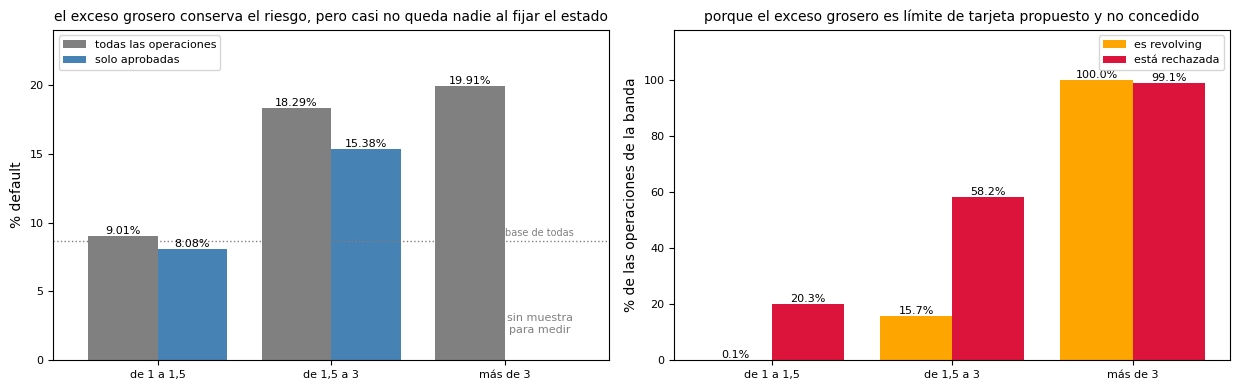

In [120]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
x = range(len(banda))
etiq = [k.split(", ")[1] for k in banda.index]
ax[0].bar([i - 0.2 for i in x], banda["% default"], 0.4, color="gray", label="todas las operaciones")
# con dos operaciones no se dibuja una tasa: se dice que no hay muestra
ax[0].bar([i + 0.2 for i in x], banda["% default aprobadas"].where(banda["aprobadas"].ge(100)), 0.4,
          color=COLOR_NODEF, label="solo aprobadas")
for c in ax[0].containers:
    ax[0].bar_label(c, fmt="%.2f%%", fontsize=8)
ax[0].axhline(pt["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].text(2.2, 2, "sin muestra\npara medir", fontsize=8, ha="center", color="gray")
ax[0].text(2.2, pt["TARGET"].mean() * 100 + 0.4, "base de todas", fontsize=7, color="gray",
           ha="center")
ax[0].set(xticks=list(x), xticklabels=etiq, ylim=(0, 24), xlim=(-0.6, 2.6), ylabel="% default",
          xlabel="")
ax[0].set_title("el exceso grosero conserva el riesgo, pero casi no queda nadie al fijar el estado",
                fontsize=10)
ax[0].legend(fontsize=8)
ax[0].tick_params(labelsize=8)

ax[1].bar([i - 0.2 for i in x], banda["% revolving"], 0.4, color="orange", label="es revolving")
ax[1].bar([i + 0.2 for i in x], banda["% rechazadas"], 0.4, color=COLOR_DEF, label="está rechazada")
for c in ax[1].containers:
    ax[1].bar_label(c, fmt="%.1f%%", fontsize=8)
ax[1].set(xticks=list(x), xticklabels=etiq, ylim=(0, 118),
          ylabel="% de las operaciones de la banda")
ax[1].set_title("porque el exceso grosero es límite de tarjeta propuesto y no concedido", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [121]:
# la variable más fuerte de la tabla: devolver menos de lo recibido sería imposible, así que
# compruebo el dominio antes de mirar su cola
print(f"coste implícito: mínimo {coste.min():.4f}, máximo {coste.max():.4f} y "
      f"{int(coste.lt(1).sum())} operación por debajo de uno de {int(coste.notna().sum()):,}")

TR_C = [0, 1.05, 1.15, 1.25, 1.4, 2.25, 10]
ET_C = ["hasta 1,05", "de 1,05 a 1,15", "de 1,15 a 1,25", "de 1,25 a 1,4", "de 1,4 a 2,25",
        "más de 2,25"]
grad_c = pt.groupby(pd.cut(coste, TR_C, labels=ET_C), observed=True)["TARGET"].agg(
    operaciones="size", tasa="mean")
grad_c["% default"] = (grad_c.pop("tasa") * 100).round(2)
display(grad_c)
d, p = delta_z(pt["TARGET"][coste.gt(2.25)], pt["TARGET"][coste.le(2.25)])
print(f"la cola por encima del percentil 99 frente al resto de las aprobadas con coste: "
      f"{d:+.2f}pp (p={p:.1e})")

coste implícito: mínimo 0.9686, máximo 3.0002 y 1 operación por debajo de uno de 803,684


,operaciones,% default
"hasta 1,05",3506,4.93
"de 1,05 a 1,15",219470,6.10
"de 1,15 a 1,25",203335,6.91
"de 1,25 a 1,4",171388,7.36
"de 1,4 a 2,25",197782,9.23
"más de 2,25",8203,16.25


la cola por encima del percentil 99 frente al resto de las aprobadas con coste: +8.90pp (p=4.1e-205)


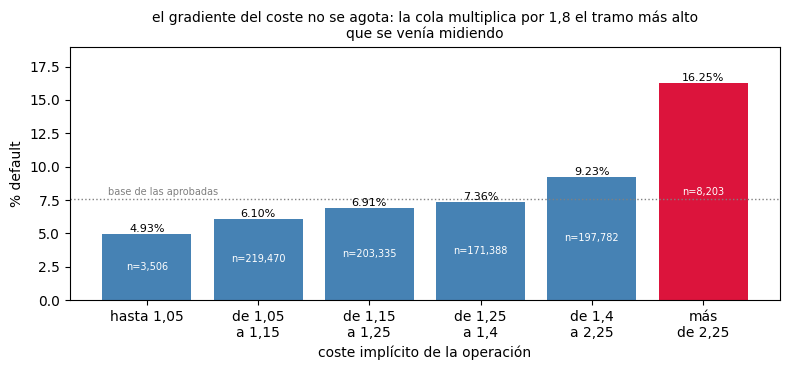

In [122]:
fig, ax = plt.subplots(figsize=(8, 3.8))
etiq_c = [e.replace(" a ", "\na ").replace("más de", "más\nde") for e in grad_c.index]
ax.bar(etiq_c, grad_c["% default"], color=[COLOR_NODEF] * 5 + [COLOR_DEF])
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=8)
ax.bar_label(ax.containers[0], labels=[f"n={v:,}" for v in grad_c["operaciones"]], fontsize=7,
             label_type="center", color="white")
ax.axhline(pt["TARGET"][aprobada].mean() * 100, color="gray", ls=":", lw=1)
ax.text(-0.35, pt["TARGET"][aprobada].mean() * 100 + 0.3, "base de las aprobadas", fontsize=7,
        color="gray")
ax.set(ylabel="% default", xlabel="coste implícito de la operación", ylim=(0, 19))
ax.set_title("el gradiente del coste no se agota: la cola multiplica por 1,8 el tramo más alto\n"
             "que se venía midiendo", fontsize=10)
plt.tight_layout()
plt.show()

In [123]:
# un ratio con denominador pequeño fabrica extremos que son ruido y no riesgo, así que antes de leer
# la cola de las dos proporciones como comportamiento compruebo que no la produce el divisor
for nombre, prop, divisor in [("concedido entre solicitado", ratio, pt["AMT_APPLICATION"]),
                              ("coste implícito", coste, pt["AMT_CREDIT"])]:
    d = divisor.where(prop.notna())
    peq = prop.notna() & divisor.lt(10000)
    print(f"{nombre}: divisor mínimo {d.min():,.0f} y percentil 1 en {d.quantile(0.01):,.0f} | "
          f"{int(peq.sum())} filas con divisor por debajo de diez mil, y su valor máximo llega a "
          f"{prop[peq].max():.4f} frente al percentil 99 de {prop.quantile(0.99):.4f}")

# de qué está hecha la cola del coste, que es la señal más fuerte de esta parte
alta = coste.gt(2.25)
tramo_dec = pt.loc[alta, "NAME_YIELD_GROUP"].value_counts(normalize=True).mul(100).round(1)
producto = pt.loc[alta, "NAME_CONTRACT_TYPE"].value_counts(normalize=True).mul(100).round(1)
print(f"\nla cola del coste son {int(alta.sum()):,} operaciones: tramo de interés declarado "
      f"{tramo_dec[tramo_dec.gt(0)].to_dict()} | producto {producto[producto.gt(0)].to_dict()}")
print(f"plazo mediano {pt['CNT_PAYMENT'][alta].median():.0f} cuotas frente a "
      f"{pt['CNT_PAYMENT'][coste.notna() & ~alta].median():.0f} del resto de las que tienen coste")

concedido entre solicitado: divisor mínimo 3,456 y percentil 1 en 16,605 | 238 filas con divisor por debajo de diez mil, y su valor máximo llega a 1.2809 frente al percentil 99 de 1.3759


coste implícito: divisor mínimo 5,139 y percentil 1 en 15,147 | 235 filas con divisor por debajo de diez mil, y su valor máximo llega a 1.6752 frente al percentil 99 de 2.2533

la cola del coste son 8,203 operaciones: tramo de interés declarado {'high': 71.1, 'middle': 28.9} | producto {'Cash loans': 99.2, 'Consumer loans': 0.8}
plazo mediano 48 cuotas frente a 12 del resto de las que tienen coste


In [124]:
# la entrada dejó abierto un cabo: hay entradas positivas por debajo de una unidad monetaria, y
# caen justo en el tramo simbólico, que era el de más riesgo de los cinco
simb = pt["AMT_DOWN_PAYMENT"].gt(0) & pt["AMT_DOWN_PAYMENT"].lt(1)
simb_todas = prev["AMT_DOWN_PAYMENT"].gt(0) & prev["AMT_DOWN_PAYMENT"].lt(1)
print(f"entradas positivas por debajo de una unidad: {int(simb.sum()):,} operaciones entre las que "
      f"se enlazan con un cliente y {int(simb_todas.sum()):,} en la tabla completa, con tasa "
      f"mediana {pt.loc[simb, 'RATE_DOWN_PAYMENT'].median():.7f}")

consumo = aprobada & pt["NAME_CONTRACT_TYPE"].eq("Consumer loans") & pt["RATE_DOWN_PAYMENT"].notna()
tramo_ent = pd.cut(pt["RATE_DOWN_PAYMENT"], [-0.001, 0.0000001, 0.05, 0.10, 0.20, 1.01],
                   labels=["sin entrada", "hasta el 5%", "del 5 al 10%", "del 10 al 20%",
                           "más del 20%"])
GRUPOS_ENT = [("sin entrada", consumo & tramo_ent.eq("sin entrada")),
              ("menos de una unidad", consumo & tramo_ent.eq("hasta el 5%") & simb),
              ("resto de hasta el 5%", consumo & tramo_ent.eq("hasta el 5%") & ~simb),
              ("del 5 al 10%", consumo & tramo_ent.eq("del 5 al 10%")),
              ("del 10 al 20%", consumo & tramo_ent.eq("del 10 al 20%")),
              ("más del 20%", consumo & tramo_ent.eq("más del 20%"))]
entrada = pd.DataFrame([{"tramo": k, "operaciones": int(m.sum()),
                         "% default": pt["TARGET"][m].mean() * 100}
                        for k, m in GRUPOS_ENT]).set_index("tramo").round(2)
display(entrada)
baja = consumo & tramo_ent.eq("hasta el 5%")
d, p = delta_z(pt["TARGET"][baja & simb], pt["TARGET"][baja & ~simb])
print(f"dentro del tramo simbólico, las de menos de una unidad frente al resto: {d:+.2f}pp "
      f"(p={p:.2f}), así que no son ellas las que lo empujan")

entradas positivas por debajo de una unidad: 1,881 operaciones entre las que se enlazan con un cliente y 2,165 en la tabla completa, con tasa mediana 0.0000083


,operaciones,% default
tramo,,
sin entrada,219157,7.95
menos de una unidad,1691,8.10
resto de hasta el 5%,10570,8.41
del 5 al 10%,45519,8.54
del 10 al 20%,183691,6.97
más del 20%,76646,5.94


dentro del tramo simbólico, las de menos de una unidad frente al resto: -0.31pp (p=0.67), así que no son ellas las que lo empujan


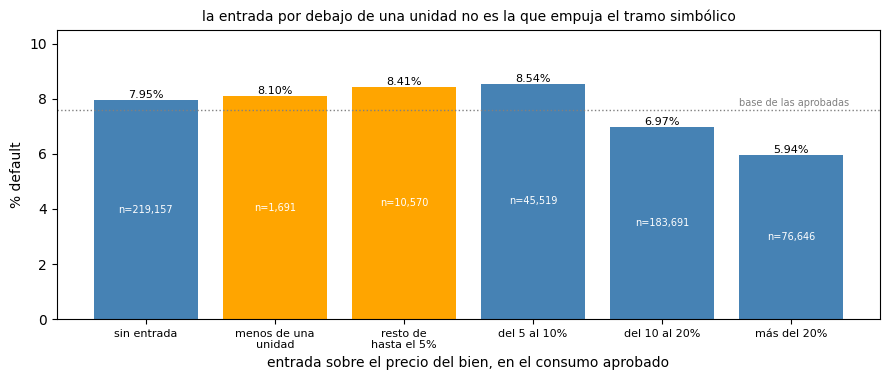

In [125]:
fig, ax = plt.subplots(figsize=(9, 3.9))
etiq_e = [t.replace("menos de una unidad", "menos de una\nunidad")
          .replace("resto de hasta el 5%", "resto de\nhasta el 5%") for t in entrada.index]
ax.bar(etiq_e, entrada["% default"],
       color=[COLOR_NODEF, "orange", "orange", COLOR_NODEF, COLOR_NODEF, COLOR_NODEF])
ax.bar_label(ax.containers[0], fmt="%.2f%%", fontsize=8)
ax.bar_label(ax.containers[0], labels=[f"n={v:,}" for v in entrada["operaciones"]], fontsize=7,
             label_type="center", color="white")
ax.axhline(pt["TARGET"][aprobada].mean() * 100, color="gray", ls=":", lw=1)
ax.text(5.45, pt["TARGET"][aprobada].mean() * 100 + 0.15, "base de las aprobadas", fontsize=7,
        color="gray", ha="right")
ax.set(ylabel="% default", ylim=(0, 10.5),
       xlabel="entrada sobre el precio del bien, en el consumo aprobado")
ax.set_title("la entrada por debajo de una unidad no es la que empuja el tramo simbólico", fontsize=10)
plt.setp(ax.get_xticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

In [126]:
# la familia de la sección, contando cada contraste emitido
familia = 2 * len(EXTREMOS) + 1 + 1 + 1  # cola por variable, plazo rechazado, coste y entrada
print(f"familia de {familia} contrastes en la sección, alfa de Bonferroni {0.05 / familia:.2e}")
print(f"cada cliente aporta {len(pt) / pt['SK_ID_CURR'].nunique():.2f} solicitudes que comparten "
      "etiqueta, así que decido por tamaño del efecto y no por p-valor")

familia de 21 contrastes en la sección, alfa de Bonferroni 2.38e-03
cada cliente aporta 4.86 solicitudes que comparten etiqueta, así que decido por tamaño del efecto y no por p-valor


La validez de dominio es un eje distinto del de la señal, y aquí sale casi vacío. Ningún importe se acerca a lo implausible: la cuota máxima es 418.058, lo concedido llega a 4.509.688 y lo solicitado a 5.850.000, todo dentro de lo que un catálogo de crédito al consumo puede producir, y el máximo de 6.905.160 que me había quedado anotado al mirar las distribuciones pertenece a un cliente que no está entre los enlazables, así que ni siquiera entra en la medición. El plazo tope de 84 cuotas es plausible y lo tienen 45 operaciones. Las fechas van de -2.922 a 2.389 días, sin ninguna por debajo de treinta años atrás, de modo que su dominio ya lo acota la ventana de ocho años. Y esta tabla no tiene columna de moneda, así que sumar importes por cliente no mezcla unidades, que era la precaución que sí había que tomar con el buró.

Lo único que revierto por validez son dos filas: las entradas de -0,9 y -0,45, que resultan ser exactamente las mismas que dejan la tasa de entrada por debajo de cero. Es ruido de redondeo sobre un importe que no puede ser negativo, y se lleva a cero. El código de zona queda fuera de este análisis pese a su máximo de 4.000.000 con el percentil 99 en 3.570, porque es un código y el cociente entre su máximo y su percentil no significa nada.

La coherencia entre importes es donde esperaba encontrar el equivalente de la deuda que supera al crédito en el buró, y el resultado es el contrario. Allí el exceso grosero perdía señal y quedaba claro que era dato roto. Aquí la banda que supera tres veces lo solicitado conserva el riesgo, un 19,91% que queda muy por encima del 10,45% de las operaciones que no llegan a aprobarse, pero no es sobreconcesión: son 221 operaciones, el 100% revolving y el 99,10% rechazadas, con una mediana de 135.000 solicitados frente a 720.000 propuestos. Es un límite de tarjeta que la entidad plantea y que no llega a concederse, o sea que las dos cifras no están en la misma escala. Al fijar el estado quedan 2 operaciones y no hay muestra para medir. La consecuencia es que la proporción entre lo concedido y lo solicitado no se capa, se controla por producto y por estado, que es como ya la había medido. Las otras dos coherencias salen limpias: la entrada no supera nunca el precio del bien, y lo concedido más la entrada queda una mediana del 5,28% por encima de ese precio, con el percentil 95 en el 19,76%, que es financiación de extras y no incoherencia, el mismo hecho visto por el otro lado de que casi la mitad de las operaciones se cierren por encima de lo pedido.

El coste implícito, que es la variable más fuerte de esta tabla, sale limpio también. Devolver menos de lo que se recibe sería imposible, y de 803.684 operaciones con coste calculable solo hay una por debajo de uno, con un mínimo de 0,9686 y un máximo de 3,0002, así que no hay nada que revertir. La cola está además hecha de lo que cabía esperar: el 71,1% son operaciones con el tramo de interés alto ya declarado, el 99,2% préstamos en efectivo, y su plazo mediano es de 48 cuotas frente a 12 del resto, o sea crédito caro y largo y no un fallo de cálculo. Lo que sí aparece es que el tramo alto que venía midiendo se quedaba corto: por encima del percentil 99, situado en 2,25, el riesgo es del 16,25% sobre 8.203 operaciones, frente al 9,23% del tramo inmediatamente anterior, y el gradiente es monótono del 4,93% al 16,25% en seis tramos. La cola frente al resto vale +8,90pp. Conviene por tanto un corte más fino en la parte alta, porque agrupar todo lo que pasa de 1,4 mete en el mismo saco a un 9% y a un 16%.

Antes de dar por buena la cola de las dos proporciones había que descartar que la fabricara el divisor, porque un ratio con denominador pequeño produce extremos que son ruido y no riesgo. No lo hace en ninguna de las dos. El solicitado más bajo entre las filas con ratio es 3.456 y su percentil 1 está en 16.605, y las 238 filas con solicitado por debajo de diez mil llegan como mucho a 1,2809, de modo que no aportan ni una operación a la cola, que empieza en 1,3759. En el coste, las 235 filas con concedido por debajo de diez mil se quedan en 1,6752 frente a un percentil 99 de 2,2533. La cola de las dos es dato real y no aritmética.

Queda cerrado además un cabo suelto de la entrada. Hay 1.881 operaciones con entrada positiva por debajo de una unidad monetaria entre las que se enlazan con un cliente, que son las 2.165 de la tabla completa menos las de clientes que no entran en esta medición, con una tasa mediana de 0,0000083, y caen justo en el tramo de entrada simbólica, que era el de más riesgo de los cinco. La hipótesis natural es que ese tramo deba su riesgo a esas filas, y no se sostiene: dan 8,10% frente al 8,41% del resto del tramo dentro del consumo aprobado, o sea -0,31pp con p de 0,67. La codificación en tres niveles se mantiene tal como estaba y esas filas no se retiran.

De las nueve variables miradas, ninguna se capa por señal y solo dos filas se revierten por validez; el código de zona y las fechas quedan fuera porque no son magnitudes con cola que tratar. La cola protectora de los importes y la cola de riesgo de las dos proporciones apuntan al mismo sitio: aquí el tamaño de la operación describe al cliente solvente, y lo que marca riesgo es la relación entre las cifras, no las cifras.

| variable | efecto de la cola | decisión |
|---|---|---|
| `AMT_ANNUITY` | -3,40pp en aprobadas | conservar sin capar, la cola es perfil solvente |
| `AMT_APPLICATION` y `AMT_GOODS_PRICE` | -2,31pp en aprobadas | conservar una sola de las dos, son la misma columna |
| `AMT_CREDIT` | -2,17pp en aprobadas | conservar sin capar |
| `AMT_DOWN_PAYMENT` | -2,72pp en aprobadas | conservar sin capar, y llevar a cero los 2 negativos |
| `RATE_DOWN_PAYMENT` | -1,92pp en aprobadas | conservar en tres niveles, y llevar a cero los 2 negativos |
| `CNT_PAYMENT` | -4,11pp en aprobadas, sin significancia | sin cola que tratar, pero marcar el plazo largo rechazado |
| concedido entre solicitado | +5,53pp en aprobadas | no capar, controlar por producto y estado |
| coste implícito | +8,93pp | no capar, y afinar el corte por encima de 1,4 |
| `SELLERPLACE_AREA` y las fechas | no aplica | fuera del análisis, no son magnitudes |

Con 4,86 operaciones por cliente compartiendo etiqueta los p-valores son anticonservadores, así que decido por tamaño del efecto y no por significancia. Y todos los cruces con el objetivo están hechos sobre la muestra de entrenamiento completa, de modo que las decisiones que dependen de la asociación con el impago se reconfirman al ajustar sobre el corte de entrenamiento.

### 9. Estrategia de agregación (nivel cliente)

El objetivo vive a nivel cliente y aquí cada fila es una solicitud, así que agrego por `SK_ID_CURR`,
que viene en la propia tabla y no hay que ir a buscarlo a ninguna otra. El join es por la izquierda
contra los clientes de train, para conservar a los 16.454 que nunca han pedido nada al prestamista,
porque ese grupo no es un hueco sino un dato: da 5,96% de default frente al 8,19% de quien sí tiene
solicitudes, y es el más seguro de la cartera. Eso invierte la distorsión a la que me tienen
acostumbrado las tablas del buró. Al rellenar con cero, esos clientes se sientan en el extremo bajo
de cualquier variable que penalice y le regalan pendiente, así que inflan la señal en lugar de
enmascararla, y toda medición va condicionada a tener alguna solicitud.

Cuatro condiciones gobiernan cómo se construye todo lo que sigue. La primera es que el estado del
contrato no es estable en el tiempo: la cancelación desaparece del registro pasados dos años, del
51,74% de las solicitudes de los últimos seis meses al 0,05% a partir de los veinticuatro, mientras
que el rechazo sí es comparable en toda la ventana. Cualquier proporción por estado hereda entonces
la ventana de cada cliente, así que se mide controlando por la recencia de su última solicitud y
nunca en crudo. La segunda es que la ausencia de dato es propiedad de la operación y no del cliente:
el 61,64% tiene unas solicitudes con ciclo de vida y otras sin él, y con el acompañante el 64,88%,
de modo que una bandera de presencia la activaría casi todo el mundo y la agregación tiene que ir
por proporciones.

La tercera es que los conteos absolutos están censurados por la izquierda. El registro no baja de
ocho años y el 18,53% de los clientes ya constaba como recurrente en su solicitud más antigua, que
son justo los de relación más larga, así que el conteo bruto castiga a quien menos historial oculto
tiene. Se normaliza por la ventana observada, y toda variable de longitud viaja con la marca de
recorte al lado, porque donde el historial está cortado la longitud no dice nada, con 0,0032 frente
al 0,1053 de los completos. La cuarta es que presencia, conteo y magnitud son tres codificaciones
distintas y la que funciona por operación no tiene por qué ser la que funciona agregada: la carga
comprometida da un gradiente limpio del 7,37% al 10,05% por operación, y al subir de nivel la
presencia se cae con 0,22pp, el conteo es ruido con 0,0126 y solo aguanta la magnitud con 0,0842. Se
miden las tres antes de elegir.

Quince variables de cliente ya están construidas y medidas, porque cada una salió de una pregunta
que no podía quedarse sin contrastar:

| Feature | Cómo se calcula | Por qué |
|---|---|---|
| `HAS_PREV_APPLICATION` | cliente con alguna solicitud | control de composición, y protectora por su signo |
| `PREV_HISTORIAL_RECORTADO` | ya constaba como recurrente en su solicitud más antigua | -3,06pp; llevar años siendo cliente protege, y controla la censura |
| `PREV_APPLICATION_COUNT` | número de solicitudes | denominador de proporciones, no variable por derecho propio |
| `PREV_COUNT_COLA` | quince solicitudes o más | la señal vive en el extremo y no en el orden, +2,97pp |
| `PREV_APPLICATIONS_PER_YEAR` | conteo entre años de ventana observada, con suelo de medio año | normalizar por el tiempo observado multiplica la señal por cinco, 0,1149 |
| `PREV_DAYS_DECISION_MIN` | solicitud más antigua | longitud de relación, 0,1129 |
| `PREV_DAYS_DECISION_MAX` | solicitud más reciente | recencia, 0,0489; aquí no manda, al contrario que en el buró |
| `PREV_COUNT_12M` | solicitudes de los últimos doce meses | 0,0639, el triple que el conteo bruto, con el que solapa 0,7207 |
| `PREV_ACTIVIDAD_12M_COLA` | cuatro solicitudes o más en doce meses | +2,41pp, corte medido y no heredado; al cruzar candidatas acaba entrando solo como término de la interacción con la longitud |
| `PREV_EARLY_SETTLED_FLAG` | alguna operación liquidada más de un año antes de lo previsto | +2,19pp; es refinanciación encadenada, no buen comportamiento |
| `PREV_EARLY_SETTLED_COUNT` y `PREV_EARLY_SETTLED_RATIO` | conteo y proporción de esas operaciones | 0,0446 y 0,0477: la codificación que entra es la bandera o los tramos de conteo |
| `PREV_FUTURE_DUE_MAX` | vencimiento pendiente más lejano el día de la solicitud | 0,0842, la única de las tres codificaciones que discrimina |
| `PREV_IMPLIED_COST_MEAN` | media de cuota por plazo entre concedido, solo en aprobadas | 0,1334 sobre el 93,47% de la cartera, la señal más fuerte |
| `PREV_IMPLIED_COST_MAX` | máximo del mismo cociente | 0,0852; se computa para descartarla con evidencia, porque el coste es un rasgo y no un suceso |

Y trece salen de lo medido por operación y hay que llevarlas al cliente:

| Feature | Cómo se calcula | Por qué |
|---|---|---|
| `PREV_REFUSED_RATIO` | rechazadas entre solicitudes | el rechazo es lo que más separa por operación, 12,00% frente al 7,59% de las aprobadas, y por cliente da 0,1604 entre los que tienen las dos mitades; falta medirlo sobre todos |
| `PREV_REFUSED_COUNT` | conteo de rechazadas | la otra codificación del mismo eje, y lo que marca es cuántos acumula |
| `PREV_REFUSED_SCOFR_FLAG` | algún rechazo con motivo de scoring externo | dentro de las rechazadas van del 6,25% al 20,93%, así que contar sin distinguir motivo mezcla el rechazo administrativo con el peor marcador |
| `PREV_CREDIT_APPLICATION_RATIO` | media de concedido entre solicitado, con las dos cifras positivas | 0,0959 por operación, y no es tamaño disfrazado |
| `PREV_OVERGRANTED_RATIO` | proporción de operaciones que reciben un exceso sobre lo pedido, con el corte todavía por barrer | el gradiente no es monótono y el riesgo vive en el tramo alto, con 14,12% |
| `PREV_CNT_PAYMENT_MEAN` | media del plazo pactado, solo donde es positivo | 0,0891 al quitar el cero, que es tarjeta sin cuadro de amortización y no plazo cero |
| `PREV_URGENT_PURPOSE_RATIO` | solicitudes de finalidad de liquidez urgente, sobre las de finalidad informada | +3,00pp con el estado fijo; aquí el cliente declara para qué, y el buró no puede dar eso |
| `PREV_STREET_RATIO` | proporción captada en la calle | +2,00pp en efectivo aprobado; un eje binario escondido en una categórica de dieciocho niveles |
| `PREV_DOWN_PAYMENT_RATE_MEAN` | media de la tasa de entrada, solo en consumo | -3,44pp del tramo alto frente al simbólico, y el cero es un producto distinto |
| `PREV_EARLY_HOUR_RATIO` | proporción decidida antes de las ocho | 9,04% frente al 6,23% de la tarde en consumo aprobado, y aguanta el doble control |
| `PREV_NO_SUITE_RATIO` | proporción sin acompañante registrado | única ausencia que ni el estado ni el producto explican, y el sin dato es su nivel de más riesgo |
| `PREV_PHANTOM_FLAG` | alguna operación sin tipo ni producto definidos | 284 clientes con +11,48pp; rara y severa, entra como bandera y no como conteo |
| `PREV_REFUSED_LONG_TERM_FLAG` | alguna petición de más de 60 cuotas que no se aprueba | 118 operaciones con +15,09pp, el delta condicionado más alto de la tabla |

Cinco reglas más deciden cómo se calcula cada una de esas celdas. El máximo es para los sucesos y la
media para los rasgos, y ante la duda se computan los dos, que es lo que dejó claro el coste
implícito con 0,1334 por media frente a 0,0852 por máximo. El denominador de cada proporción es la
población donde la variable tiene sentido y no todas las solicitudes del cliente, así que la entrada
se mide solo en consumo, el motivo de rechazo solo dentro de las rechazadas y el coste solo en las
aprobadas, con un mínimo exigido para que un denominador de uno no fabrique extremos. Ese mínimo no es una
precaución teórica y muerde justo en la candidata más fuerte que queda por medir: la única cifra
que tengo del ratio de rechazo, 0,1604, está calculada sobre los 233.016 clientes con solicitudes
en las dos mitades de su ventana, el 80,06% de los que tienen previas, y esa población excluye por
construcción a quien tiene una sola solicitud, que es exactamente donde el ratio solo puede valer
0% o 100%. Parto entonces de una medición hecha sobre el subconjunto donde el ratio está mejor
definido, así que al extenderla a todos puede moverse en cualquier dirección, y es el mismo
problema que ya dio la proporción de meses en mora del histórico mensual del buró. Las magnitudes
se agregan sobre dato real, porque el cero es la operación cancelada o la tarjeta sin cuadro de
amortización y promediarlo mezcla un estado con una cantidad. De las tres magnitudes de tamaño entra
una sola, ya que el precio del bien y lo solicitado coinciden exactamente en el 99,98% de las filas.
Y los ausentes no se imputan: no tener longitud de relación es no haber pedido nunca aquí, no tener
nada por vencer es no deber nada hoy a esta casa y no tener coste implícito es no haber llegado a
formalizar, así que los tres son hechos y entran como tramo propio.

Hay cuatro variables que no construyo, y conviene dejar dicho por qué para no volver a proponerlas.
La proporción de canceladas no mide comportamiento sino recencia, con 0,3937 contra la última
solicitud, porque la operación cancelada no sobrevive en el registro. La completitud agregada es la
tasa de aprobación por el reverso, con 0,9205 entre ambas, y además rinde menos, 0,1085 frente a
0,1179. El conteo de contratos vivos parecía el equivalente del conteo de créditos activos del buró
y se queda en 0,0118 con gradiente plano, porque la exposición con el propio prestamista ya pasó por
su filtro de riesgo. Y el deterioro del rechazo es el nivel de rechazo con otro nombre, 0,0777
frente a 0,1604. La fecha de terminación tampoco entra, por redundancia estructural con el último
vencimiento, con el que correlaciona 0,9924.

Falta además cruzar las candidatas entre sí y no solo cada una contra el objetivo. De todos los
pares solo hay cinco medidos y uno ya cruza el umbral: el conteo de solicitudes con la actividad
del último año da 0,7207, con el ritmo 0,5253, el ritmo con la longitud de relación 0,3814 y la
longitud con la recencia 0,2518. Los solapes que quedan a la vista son las dos agregaciones del
coste, el conteo y la proporción de liquidación anticipada, y el ratio de rechazo con su conteo y
con el de scoring externo, y se resuelven con V de Cramér sobre las banderas y Pearson sobre las
magnitudes antes de que ninguna llegue al ranking.

Queda un corte por afinar. El coste implícito agrupa hoy todo lo que pasa de 1,4 en un solo tramo, y
ahí conviven un 9,23% con el 16,25% que aparece por encima de 2,25, así que la parte alta hay que
partirla más fino.

Esta agregación es exploratoria: computa las variables candidatas para medir su señal a nivel
cliente y fijar la receta, sin persistir ninguna tabla de modelado. Todas las funciones que uso son
independientes del objetivo, y los cruces con la tasa de default son descriptivos sobre el train
completo, así que los cortes medidos, las quince solicitudes, las cuatro en doce meses, el año de
adelanto y las 60 cuotas, se refijan sobre el conjunto de entrenamiento antes de viajar a ninguna
parte. El corte del 30% de exceso es el único que no está medido: sale del tramo del binning donde
el riesgo salta al 14,12%, así que hay que barrerlo como se barrieron los otros en vez de
heredarlo.

### 10. Validación por bloques (`TARGET` real)

In [127]:
# la receta hecha tabla: cada columna se agrega sobre la población donde la variable tiene
# sentido, no sobre todas las solicitudes del cliente
def por_cliente(serie, como="mean", donde=None):
    """agrega una serie de nivel solicitud a nivel cliente, sobre su propio denominador"""
    s = serie.astype(float)
    g = (s if donde is None else s.where(donde)).groupby(pt["SK_ID_CURR"]).agg(como)
    return pd.Series(g.reindex(train["SK_ID_CURR"]).values, index=train.index)


train["PREV_REFUSED_COUNT"] = por_cliente(rechazada, "sum")
train["PREV_REFUSED_SCOFR_COUNT"] = por_cliente(rechazada & pt["CODE_REJECT_REASON"].eq("SCOFR"), "sum")
# el conteo está a cero en casi todos y los empates aplastan el rank-biserial, así que la
# codificación que se mide y que viaja al ranking es la bandera y no el conteo
train["PREV_REFUSED_SCOFR_FLAG"] = train["PREV_REFUSED_SCOFR_COUNT"].fillna(0).gt(0).astype(int)

dos_cifras = pt["AMT_APPLICATION"].gt(0) & pt["AMT_CREDIT"].gt(0)
ratio_conc = (pt["AMT_CREDIT"] / pt["AMT_APPLICATION"]).where(dos_cifras)
train["PREV_CREDIT_APPLICATION_RATIO"] = por_cliente(ratio_conc)
train["PREV_CNT_PAYMENT_MEAN"] = por_cliente(pt["CNT_PAYMENT"].where(pt["CNT_PAYMENT"].gt(0)))

combinacion = pt["PRODUCT_COMBINATION"].astype("string")
definida = combinacion.notna()  # las 313 sin definir son el registro fantasma, van aparte
train["PREV_STREET_RATIO"] = por_cliente(combinacion.str.contains("Street", na=False), donde=definida)
train["PREV_EARLY_HOUR_RATIO"] = por_cliente(pt["HOUR_APPR_PROCESS_START"].le(8))
train["PREV_NO_SUITE_RATIO"] = por_cliente(pt["NAME_TYPE_SUITE"].isna())

finalidad_cli = pt["NAME_CASH_LOAN_PURPOSE"].astype("string")
urgente_cli = finalidad_cli.isin(URGENTE)
fin_informada = finalidad_cli.notna() & ~finalidad_cli.isin(["XNA", "XAP"])
train["PREV_URGENT_PURPOSE_COUNT"] = por_cliente(urgente_cli, "sum")
# la finalidad solo existe donde el cliente la declara, así que ese es el denominador honesto
train["PREV_URGENT_PURPOSE_RATIO"] = por_cliente(urgente_cli, donde=fin_informada)
consumo_op = pt["NAME_CONTRACT_TYPE"].eq("Consumer loans")
train["PREV_DOWN_PAYMENT_RATE_MEAN"] = por_cliente(pt["RATE_DOWN_PAYMENT"], donde=consumo_op)
train["PREV_PHANTOM_FLAG"] = por_cliente(~definida, "sum").fillna(0).gt(0).astype(int)
train["PREV_REFUSED_LONG_TERM_FLAG"] = (por_cliente(pt["CNT_PAYMENT"].gt(60) & ~aprobada, "sum")
                                        .fillna(0).gt(0).astype(int))

# las tres banderas que ya estaban medidas no existían como columna, y hacen falta para cruzarlas
train["PREV_HISTORIAL_RECORTADO"] = recortado.astype(int)
train["PREV_COUNT_COLA"] = train["PREV_APPLICATION_COUNT"].ge(15).astype(int)
train["PREV_ACTIVIDAD_12M_COLA"] = train["PREV_COUNT_12M"].ge(4).astype(int)

NUEVAS = ["PREV_REFUSED_RATIO", "PREV_REFUSED_COUNT", "PREV_REFUSED_SCOFR_FLAG",
          "PREV_CREDIT_APPLICATION_RATIO", "PREV_OVERGRANTED_RATIO", "PREV_CNT_PAYMENT_MEAN",
          "PREV_STREET_RATIO", "PREV_EARLY_HOUR_RATIO", "PREV_NO_SUITE_RATIO",
          "PREV_URGENT_PURPOSE_RATIO", "PREV_DOWN_PAYMENT_RATE_MEAN", "PREV_PHANTOM_FLAG",
          "PREV_REFUSED_LONG_TERM_FLAG"]
construidas = [c for c in NUEVAS if c in train.columns]
DENOMINADOR = {"PREV_CREDIT_APPLICATION_RATIO": "las dos cifras positivas",
               "PREV_OVERGRANTED_RATIO": "las dos cifras positivas",
               "PREV_CNT_PAYMENT_MEAN": "plazo positivo",
               "PREV_STREET_RATIO": "combinación de producto definida",
               "PREV_DOWN_PAYMENT_RATE_MEAN": "solo consumo",
               "PREV_URGENT_PURPOSE_RATIO": "finalidad declarada"}
cobertura = pd.DataFrame({
    "denominador": [DENOMINADOR.get(c, "todas las solicitudes") for c in construidas],
    "clientes con dato": [int(train.loc[con_prev, c].notna().sum()) for c in construidas],
    "% de los que tienen previas": [round(train.loc[con_prev, c].notna().mean() * 100, 2)
                                    for c in construidas]}, index=construidas)
display(cobertura)

familia_base = len(ev_cli.fb_comparisons)  # lo ya emitido antes de esta sección
assert con_prev.sum() == 291_057 and (~con_prev).sum() == 16_454, "la cobertura no cuadra"
assert len(NUEVAS) == 13 and len(set(NUEVAS)) == 13, "la receta no son trece nombres distintos"
print("doce columnas construidas; la sobreconcesión espera a que se barra su corte")

,denominador,clientes con dato,% de los que tienen previas
PREV_REFUSED_RATIO,todas las solicitudes,291057,100.00
PREV_REFUSED_COUNT,todas las solicitudes,291057,100.00
PREV_REFUSED_SCOFR_FLAG,todas las solicitudes,291057,100.00
PREV_CREDIT_APPLICATION_RATIO,las dos cifras positivas,290042,99.65
PREV_CNT_PAYMENT_MEAN,plazo positivo,288566,99.14
PREV_STREET_RATIO,combinación de producto definida,291057,100.00
PREV_EARLY_HOUR_RATIO,todas las solicitudes,291057,100.00
PREV_NO_SUITE_RATIO,todas las solicitudes,291057,100.00
PREV_URGENT_PURPOSE_RATIO,finalidad declarada,35917,12.34
PREV_DOWN_PAYMENT_RATE_MEAN,solo consumo,268895,92.39


doce columnas construidas; la sobreconcesión espera a que se barra su corte


In [128]:
# el rechazo es la candidata más fuerte que queda y llega medida sobre la población equivocada,
# así que la mido sobre los 291.057 y comparo las tres codificaciones del mismo eje
ev_ctrl = EvaluadorSenal(train, train["TARGET"])  # barridos y controles, no ranking

hay_rechazo = train["PREV_REFUSED_COUNT"].fillna(0).gt(0).astype(int).values
ev_ctrl.evaluar_flags([("PREV_HAS_REFUSAL", hay_rechazo, con_prev, "con previas")])
ev_cli.evaluar_continuas([
    ("PREV_REFUSED_RATIO", True, None, "global (relleno 0)"),
    ("PREV_REFUSED_RATIO", False, con_prev, "con previas"),
    ("PREV_REFUSED_COUNT", True, None, "global (relleno 0)"),
    ("PREV_REFUSED_COUNT", False, con_prev, "con previas")])

# el conteo del motivo se queda en los controles, porque sirve para explicar por qué no entra y no
# para decidir; al ranking va la bandera, medida donde se decide: dentro de quien acumula rechazos
scofr = con_prev & (hay_rechazo == 1)
ev_ctrl.evaluar_continuas([("PREV_REFUSED_SCOFR_COUNT", False, con_prev, "con previas"),
                           ("PREV_REFUSED_SCOFR_COUNT", False, scofr, "con algún rechazo")])
ev_cli.evaluar_flags([("PREV_REFUSED_SCOFR_FLAG", train["PREV_REFUSED_SCOFR_FLAG"].values, None,
                       "global (relleno 0)"),
                      ("PREV_REFUSED_SCOFR_FLAG", train["PREV_REFUSED_SCOFR_FLAG"].values, scofr,
                       "con algún rechazo")])

CORTES_REC = [-0.001, 0.001, 0.25, 0.5, 0.75, 1.001]
ETIQ_REC = ["sin rechazos", "hasta el 25%", "del 25 al 50%", "del 50 al 75%", "más del 75%"]
tramo_rechazo = pd.cut(train["PREV_REFUSED_RATIO"], CORTES_REC, labels=ETIQ_REC)
grad_rechazo = train[con_prev].groupby(tramo_rechazo[con_prev], observed=True)["TARGET"].agg(
    clientes="size", tasa="mean")
grad_rechazo["% default"] = (grad_rechazo.pop("tasa") * 100).round(2)
display(grad_rechazo)

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_HAS_REFUSAL,con previas,10.32% (n=100294),7.07% (n=190763),+3.25 pp,30.4,1.4205307814822223e-202


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_REFUSED_RATIO,global (relleno 0),307511,0.1196,8.663830962507205e-309,0.0,0.0
PREV_REFUSED_RATIO,con previas,291057,0.1204,3.3235696991276593e-290,0.0,0.0
PREV_REFUSED_COUNT,global (relleno 0),307511,0.1121,2.689962169233738e-273,0.0,0.0
PREV_REFUSED_COUNT,con previas,291057,0.1122,6.867448950547203e-254,0.0,0.0


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_REFUSED_SCOFR_COUNT,con previas,291057,0.0351,2.1478518148849695e-259,0.0,0.0
PREV_REFUSED_SCOFR_COUNT,con algún rechazo,100294,0.0675,1.4209833258207085e-147,0.0,0.0


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_REFUSED_SCOFR_FLAG,global (relleno 0),19.49% (n=6788),7.82% (n=300723),+11.68 pp,34.9,3.969932730446083e-267
PREV_REFUSED_SCOFR_FLAG,con algún rechazo,19.49% (n=6788),9.66% (n=93506),+9.83 pp,25.7,8.09367551080988e-146


,clientes,% default
PREV_REFUSED_RATIO,,
sin rechazos,190763,7.07
hasta el 25%,47397,8.11
del 25 al 50%,41739,11.33
del 50 al 75%,9393,15.58
más del 75%,1765,17.79


In [129]:
# tres controles antes de darla por buena: el mínimo de denominador, la recencia que la
# sección anterior dejó como obligatoria, y el par ratio frente a conteo
print("mínimo de denominador (el ratio de quien tiene una sola solicitud solo vale 0% o 100%):")
barrido_den = []
for minimo in [1, 2, 3, 5]:
    pob = con_prev & (train["PREV_APPLICATION_COUNT"] >= minimo).values
    v = train.loc[pob, "PREV_REFUSED_RATIO"]
    t = train.loc[pob, "TARGET"]
    u, _ = mannwhitneyu(v[t == 0], v[t == 1])
    r = abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1)
    barrido_den.append({"mínimo": minimo, "r_rb": round(r, 4), "clientes": int(pob.sum()),
                        "% de los que tienen previas": round(pob.sum() / con_prev.sum() * 100, 2)})
display(pd.DataFrame(barrido_den).set_index("mínimo"))
ev_ctrl.evaluar_continuas([("PREV_REFUSED_RATIO", False, dos_mitades, "las dos mitades (la vieja)")])

print("\ncontrol por recencia de la última solicitud:")
ETIQ_VENTANA = ["más de 2 años", "de 1 a 2 años", "de 6 a 12 meses", "menos de 6 meses"]
ventana_cli = pd.cut(train["PREV_DAYS_DECISION_MAX"], [-3000, -730, -365, -180, 0],
                     labels=ETIQ_VENTANA)
senal_ventana = {}
for k in ETIQ_VENTANA:
    pob = con_prev & ventana_cli.eq(k).values
    v, t = train.loc[pob, "PREV_REFUSED_RATIO"], train.loc[pob, "TARGET"]
    u, p = mannwhitneyu(v[t == 0], v[t == 1])
    senal_ventana[k] = abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1)
    print(f"  {k:17s} r_rb {senal_ventana[k]:.4f} (n={int(pob.sum()):,}) p={p:.1e}")

print("\nel conteo es un conteo, así que lleva el control del recorte de historial:")
for etiqueta, pob in [("historial completo", con_prev & ~recortado),
                      ("historial recortado", con_prev & recortado), ("el conjunto", con_prev)]:
    v, t = train.loc[pob, "PREV_REFUSED_COUNT"], train.loc[pob, "TARGET"]
    u, _ = mannwhitneyu(v[t == 0], v[t == 1])
    print(f"  {etiqueta:20s} r_rb {abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1):.4f} "
          f"(n={int(pob.sum()):,})")

par = train.loc[con_prev, "PREV_REFUSED_RATIO"].corr(train.loc[con_prev, "PREV_REFUSED_COUNT"])
print(f"\nratio y conteo dan {par:.4f} de Pearson: estratos cruzados en las dos direcciones")
for nombre, estrato, otra in [("el conteo dentro de cada nivel de ratio", tramo_rechazo,
                               "PREV_REFUSED_COUNT"),
                              ("el ratio dentro de cada tramo de conteo",
                               pd.cut(train["PREV_REFUSED_COUNT"], [-0.5, 0.5, 1.5, 3.5, 200],
                                      labels=["0", "1", "de 2 a 3", "4 o más"]),
                               "PREV_REFUSED_RATIO")]:
    print(f"  {nombre}:")
    for k in estrato.cat.categories:
        pob = con_prev & estrato.eq(k).values
        v, t = train.loc[pob, otra], train.loc[pob, "TARGET"]
        if v.nunique() < 2:
            print(f"    {k:16s} sin recorrido (todos valen lo mismo)")
            continue
        u, p = mannwhitneyu(v[t == 0], v[t == 1])
        print(f"    {k:16s} r_rb {abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1):.4f} "
              f"(n={int(pob.sum()):,}) p={p:.1e}")

mínimo de denominador (el ratio de quien tiene una sola solicitud solo vale 0% o 100%):


,r_rb,clientes,% de los que tienen previas
mínimo,,,
1,0.1204,291057,100.00
2,0.1558,238524,81.95
3,0.1765,192725,66.22
5,0.1993,119789,41.16


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_REFUSED_RATIO,las dos mitades (la vieja),233016,0.1604,0.0,0.0,0.1



control por recencia de la última solicitud:
  más de 2 años     r_rb 0.0466 (n=54,406) p=2.8e-13
  de 1 a 2 años     r_rb 0.0855 (n=67,965) p=2.1e-39
  de 6 a 12 meses   r_rb 0.1386 (n=79,104) p=9.2e-101
  menos de 6 meses  r_rb 0.1552 (n=89,582) p=5.6e-138

el conteo es un conteo, así que lleva el control del recorte de historial:
  historial completo   r_rb 0.1147 (n=237,123)
  historial recortado  r_rb 0.1289 (n=53,934)
  el conjunto          r_rb 0.1122 (n=291,057)

ratio y conteo dan 0.7447 de Pearson: estratos cruzados en las dos direcciones
  el conteo dentro de cada nivel de ratio:
    sin rechazos     sin recorrido (todos valen lo mismo)
    hasta el 25%     r_rb 0.0150 (n=47,397) p=4.9e-02
    del 25 al 50%    r_rb 0.0142 (n=41,739) p=1.0e-01
    del 50 al 75%    r_rb 0.0082 (n=9,393) p=6.1e-01
    más del 75%      r_rb 0.1666 (n=1,765) p=3.0e-06
  el ratio dentro de cada tramo de conteo:
    0                sin recorrido (todos valen lo mismo)
    1                r_rb 0.

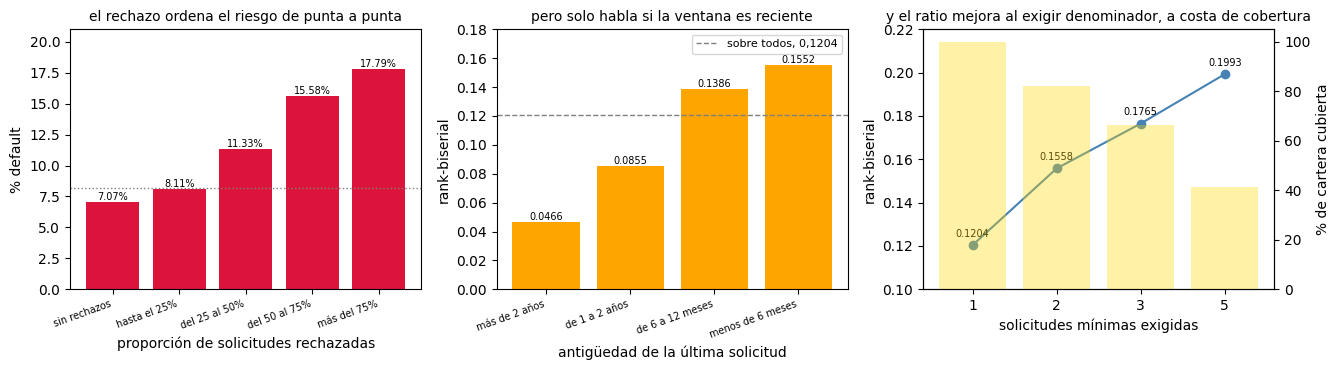

In [130]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
ax[0].bar(grad_rechazo.index.astype(str), grad_rechazo["% default"], color=COLOR_DEF)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f%%", fontsize=7)
ax[0].axhline(train.loc[con_prev, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax[0].set(ylabel="% default", xlabel="proporción de solicitudes rechazadas", ylim=(0, 21))
ax[0].set_title("el rechazo ordena el riesgo de punta a punta", fontsize=10)
plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=7)

ax[1].bar(list(senal_ventana), list(senal_ventana.values()), color="orange")
ax[1].bar_label(ax[1].containers[0], fmt="%.4f", fontsize=7)
sobre_todos = pd.DataFrame(barrido_den).set_index("mínimo").loc[1, "r_rb"]
ax[1].axhline(sobre_todos, color="gray", ls="--", lw=1,
              label=f"sobre todos, {sobre_todos:.4f}".replace(".", ","))
ax[1].set(ylabel="rank-biserial", xlabel="antigüedad de la última solicitud", ylim=(0, 0.18))
ax[1].set_title("pero solo habla si la ventana es reciente", fontsize=10)
ax[1].legend(fontsize=8)
plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right", fontsize=7)

den = pd.DataFrame(barrido_den).set_index("mínimo")
ax[2].plot(den.index.astype(str), den["r_rb"], "o-", color=COLOR_NODEF, label="rank-biserial")
for x, v in zip(range(len(den)), den["r_rb"]):
    ax[2].annotate(f"{v:.4f}", (x, v), textcoords="offset points", xytext=(0, 6), fontsize=7,
                   ha="center")
ax[2].set(ylabel="rank-biserial", xlabel="solicitudes mínimas exigidas", ylim=(0.10, 0.22))
gemelo = ax[2].twinx()
gemelo.bar(den.index.astype(str), den["% de los que tienen previas"], color="gold", alpha=0.35)
gemelo.set_ylabel("% de cartera cubierta")
ax[2].set_title("y el ratio mejora al exigir denominador, a costa de cobertura", fontsize=10)
plt.tight_layout()
plt.show()

In [131]:
# dos preguntas del rechazo que la receta daba por resueltas y no lo estaban
una_sola = con_prev & train["PREV_APPLICATION_COUNT"].eq(1).values
solo_uno = una_sola & train["PREV_REFUSED_RATIO"].eq(1).values
d_una, p_una = delta_z(train["TARGET"][solo_uno],
                       train["TARGET"][una_sola & train["PREV_REFUSED_RATIO"].eq(0).values])
print(f"\nlos {int(una_sola.sum()):,} clientes de una sola solicitud son el "
      f"{una_sola.sum() / con_prev.sum() * 100:.2f}% de los que tienen previas y su ratio solo "
      f"vale 0 o 1: quien la tiene rechazada da {train['TARGET'][solo_uno].mean() * 100:.2f}% "
      f"(n={int(solo_uno.sum()):,}) frente al "
      f"{train['TARGET'][una_sola & train['PREV_REFUSED_RATIO'].eq(0).values].mean() * 100:.2f}%, "
      f"o sea {d_una:+.2f}pp con p={p_una:.2f}")
den = pd.DataFrame(barrido_den).set_index("mínimo")["r_rb"]
print(f"con esa quinta parte de la cartera aportando ruido se entiende que el ratio suba de "
      f"{den.loc[1]:.4f} a {den.loc[2]:.4f} al exigir dos solicitudes")

# ¿distinguir el motivo del rechazo paga, o el conteo ya lo dice todo?
print("\nun rechazo por scoring externo dentro de cada tramo de conteo de rechazos:")
tramos_ref = pd.cut(train["PREV_REFUSED_COUNT"], [-0.5, 0.5, 1.5, 3.5, 200],
                    labels=["0", "1", "de 2 a 3", "4 o más"])
motivo_cli = {}
for k in ["1", "de 2 a 3", "4 o más"]:
    pob = con_prev & tramos_ref.eq(k).values
    con_s = pob & train["PREV_REFUSED_SCOFR_COUNT"].gt(0).values
    sin_s = pob & train["PREV_REFUSED_SCOFR_COUNT"].eq(0).values
    d, p = delta_z(train["TARGET"][con_s], train["TARGET"][sin_s])
    motivo_cli[k] = (train["TARGET"][con_s].mean() * 100, train["TARGET"][sin_s].mean() * 100,
                     int(con_s.sum()), d)
    print(f"  con {k:9s} rechazos: {motivo_cli[k][0]:5.2f}% (n={con_s.sum():,}) frente a "
          f"{motivo_cli[k][1]:.2f}% | {d:+.2f}pp (p={p:.1e})")
v, t = train.loc[con_prev, "PREV_REFUSED_SCOFR_COUNT"], train.loc[con_prev, "TARGET"]
u, _ = mannwhitneyu(v[t == 0], v[t == 1])
print(f"el conteo crudo rinde {abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1):.4f} porque está "
      f"a cero en el {v.eq(0).mean() * 100:.2f}% y el rank-biserial se aplasta con los empates: la "
      "codificación que entra es la bandera, no el conteo")


los 52,533 clientes de una sola solicitud son el 18.05% de los que tienen previas y su ratio solo vale 0 o 1: quien la tiene rechazada da 10.00% (n=250) frente al 8.37%, o sea +1.63pp con p=0.35
con esa quinta parte de la cartera aportando ruido se entiende que el ratio suba de 0.1204 a 0.1558 al exigir dos solicitudes

un rechazo por scoring externo dentro de cada tramo de conteo de rechazos:
  con 1         rechazos: 15.13% (n=1,666) frente a 8.60% | +6.53pp (p=3.1e-20)
  con de 2 a 3  rechazos: 17.91% (n=2,579) frente a 10.06% | +7.85pp (p=1.7e-35)
  con 4 o más   rechazos: 23.95% (n=2,543) frente a 11.72% | +12.23pp (p=5.7e-64)
el conteo crudo rinde 0.0351 porque está a cero en el 97.67% y el rank-biserial se aplasta con los empates: la codificación que entra es la bandera, no el conteo


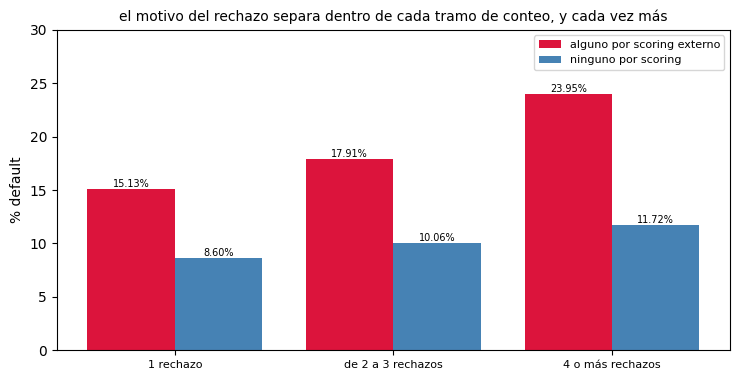

In [132]:
fig, ax = plt.subplots(figsize=(7.5, 3.9))
x = range(len(motivo_cli))
ax.bar([i - 0.2 for i in x], [v[0] for v in motivo_cli.values()], 0.4, color=COLOR_DEF,
       label="alguno por scoring externo")
ax.bar([i + 0.2 for i in x], [v[1] for v in motivo_cli.values()], 0.4, color=COLOR_NODEF,
       label="ninguno por scoring")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{k} rechazo" + ("" if k == "1" else "s") for k in motivo_cli], fontsize=8)
ax.set(ylabel="% default", ylim=(0, 30))
ax.set_title("el motivo del rechazo separa dentro de cada tramo de conteo, y cada vez más",
             fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

`PREV_REFUSED_RATIO` (r_rb 0,1204): la proporción de solicitudes rechazadas ordena el riesgo de
punta a punta, del 7,07% de quien nunca ha recibido un no (n=190.763) al 17,79% de quien acumula
más de tres cuartas partes de rechazos (n=1.765), con 8,11%, 11,33% y 15,58% en medio. Venía
trabajando con un 0,1604 que estaba medido solo sobre los 233.016 clientes con solicitudes en las
dos mitades de su ventana, y al abrirlo a los 291.057 baja a 0,1204. No es que la variable rinda
menos de lo que parecía: aquella población excluía por construcción a quien tiene una sola
solicitud, que es justo donde el ratio solo puede valer 0% o 100%. Esos 52.533 clientes son el
18,05% de los que han pedido alguna vez aquí y ahí el ratio no discrimina, con un 10,00% cuando la
única solicitud fue rechazada (n=250) frente al 8,37% del resto, +1,63pp con p = 0,35. Exigir dos
solicitudes sube el efecto a 0,1558 cubriendo el 81,95% de la cartera, tres a 0,1765 y cinco a
0,1993 cubriendo ya solo el 41,16%. Prefiero conservarla sobre todos y llevar el conteo de
solicitudes al lado, que es lo que dice si el ratio es interpretable, en lugar de recortar cobertura
por decreto.

El control por la antigüedad de la última solicitud era obligatorio, porque la cancelación no
sobrevive igual en el registro según la ventana, y confirma lo que sospechaba: el ratio rinde 0,0466
en quien no pide desde hace más de dos años y 0,1552 en quien pidió hace menos de seis meses, con
0,0855 y 0,1386 en los tramos intermedios. Aguanta en los cuatro, así que la señal es propia y no la
ventana con otro nombre, pero su fuerza depende de cuándo fue la última vez y las dos variables
tienen que viajar juntas.

`PREV_REFUSED_COUNT` (0,1122): correlaciona 0,7447 con el ratio, así que hay que elegir una. Los
estratos cruzados no dejan duda: el conteo dentro de cada nivel de ratio da 0,0150, 0,0142 y 0,0082
sin significancia y solo repunta a 0,1666 en el tramo de más del 75%, mientras que el ratio dentro
de cada tramo de conteo aguanta con 0,1113, 0,1213 y 0,1468. Entra el ratio y el conteo queda
degradado a denominador, igual que le pasó al conteo de solicitudes.

`PREV_REFUSED_SCOFR_FLAG` (+9,83pp): es el hallazgo que no esperaba de este bloque, y obliga a
elegir la codificación antes de medir en lugar de después. Contar los rechazos por scoring invita a
tirarlos, con 0,0351 sobre todos los que tienen previas y 0,0675 dentro de quien acumula algún
rechazo, pero el motivo de esas cifras es mecánico y no de negocio: el conteo está a cero en el
97,67% de los clientes y los empates aplastan el rank-biserial, el mismo efecto que ya me encontré
con la mora máxima del buró. Como bandera y medida donde se decide, que es dentro de quien acumula
algún rechazo, vale +9,83pp sobre 6.788 clientes. La severidad crece además con el volumen: dentro
de cada tramo de conteo de rechazos, tener alguno rechazado por scoring externo suma +6,53pp con un
solo rechazo (15,13% frente a 8,60%), +7,85pp con dos o tres, y +12,23pp con cuatro o más (23,95%
frente a 11,72%, n=2.543). No es el volumen disfrazado: un no del scoring pesa distinto que un no
administrativo. Al ranking va la bandera y el conteo se queda entre los controles, que es donde
explica por qué no sirve.

In [133]:
# la familia de la relación entre cifras: lo concedido frente a lo pedido, el plazo y el exceso,
# que compiten con el coste implícito ya registrado
ev_cli.evaluar_continuas([
    ("PREV_CREDIT_APPLICATION_RATIO", True, None, "global (relleno 0)"),
    ("PREV_CREDIT_APPLICATION_RATIO", False, con_prev, "con previas"),
    ("PREV_CNT_PAYMENT_MEAN", True, None, "global (relleno 0)"),
    ("PREV_CNT_PAYMENT_MEAN", False, con_prev, "con previas")])

ETIQ_CONC = ["menos de lo pedido", "lo justo", "hasta un 10% más", "del 10 al 30%", "más del 30%"]
tramo_conc = pd.cut(train["PREV_CREDIT_APPLICATION_RATIO"], [0, 0.999, 1.001, 1.1, 1.3, 30],
                    labels=ETIQ_CONC)
grad_conc = train[con_prev].groupby(tramo_conc[con_prev], observed=True)["TARGET"].agg(
    clientes="size", tasa="mean")
grad_conc["% default"] = (grad_conc.pop("tasa") * 100).round(2)
display(grad_conc)

# por operación el gradiente no era monótono y lo explicaba la mezcla de producto: compruebo
# si la forma se mantiene fijando producto y estado
conc_consumo = por_cliente(ratio_conc, "mean", dos_cifras & aprobada & consumo_op)
grad_consumo = (train[con_prev].assign(v=conc_consumo[con_prev])
                .groupby(pd.cut(conc_consumo[con_prev], [0, 0.999, 1.001, 1.1, 1.3, 30],
                                labels=ETIQ_CONC), observed=True)["TARGET"]
                .agg(clientes="size", tasa="mean"))
grad_consumo["% default"] = (grad_consumo.pop("tasa") * 100).round(2)
display(grad_consumo)
print("dentro del consumo aprobado el gradiente también es monótono, así que la ruptura de nivel "
      "solicitud era mezcla de producto y no comportamiento")

# el corte del 30% venía heredado del binning de nivel solicitud: lo barro
print("barrido del corte de sobreconcesión (la proporción, no la bandera):")
barrido_corte = []
for corte in [1.05, 1.1, 1.2, 1.3, 1.4, 1.5]:
    prop = por_cliente(ratio_conc.gt(corte), donde=dos_cifras)
    v, t = prop[con_prev].dropna(), train.loc[con_prev, "TARGET"]
    t = t.loc[v.index]
    u, _ = mannwhitneyu(v[t == 0], v[t == 1])
    marcado = con_prev & prop.gt(0).fillna(False).values
    resto = con_prev & prop.eq(0).fillna(False).values
    d, p = delta_z(train["TARGET"][marcado], train["TARGET"][resto])
    barrido_corte.append({"corte": corte,
                          "r_rb de la proporción": round(abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1), 4),
                          "delta como bandera": round(d, 2),
                          "% marcados": round(marcado.sum() / con_prev.sum() * 100, 2)})
barrido_corte = pd.DataFrame(barrido_corte).set_index("corte")
display(barrido_corte)
CORTE_EXCESO = float(barrido_corte["r_rb de la proporción"].idxmax())
train["PREV_OVERGRANTED_RATIO"] = por_cliente(ratio_conc.gt(CORTE_EXCESO), donde=dos_cifras)
print(f"corte elegido por tamaño del efecto: {CORTE_EXCESO}, no el 1,3 heredado del binning")
ev_cli.evaluar_continuas([("PREV_OVERGRANTED_RATIO", True, None, "global (relleno 0)"),
                          ("PREV_OVERGRANTED_RATIO", False, con_prev, "con previas")])

# el tramo alto del coste juntaba un 9% con un 16%: lo parto por el percentil 99 de nivel solicitud
ETIQ_COSTE = ["hasta 1,05", "de 1,05 a 1,15", "de 1,15 a 1,25", "de 1,25 a 1,4", "de 1,4 a 2,25",
              "más de 2,25"]
tramo_coste_cli = pd.cut(train["PREV_IMPLIED_COST_MEAN"], [0, 1.05, 1.15, 1.25, 1.4, 2.25, 100],
                         labels=ETIQ_COSTE)
grad_coste_cli = train.groupby(tramo_coste_cli, observed=True)["TARGET"].agg(
    clientes="size", tasa="mean")
grad_coste_cli["% default"] = (grad_coste_cli.pop("tasa") * 100).round(2)
display(grad_coste_cli)

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_CREDIT_APPLICATION_RATIO,global (relleno 0),307511,0.148,0.0,1.0,1.0
PREV_CREDIT_APPLICATION_RATIO,con previas,290042,0.1458,7.811500906323928e-305,1.0,1.0
PREV_CNT_PAYMENT_MEAN,global (relleno 0),307511,0.085,6.745484503555995e-110,12.0,13.4
PREV_CNT_PAYMENT_MEAN,con previas,288566,0.081,5.119797758007739e-95,12.5,14.0


,clientes,% default
PREV_CREDIT_APPLICATION_RATIO,,
menos de lo pedido,101860,6.45
lo justo,22000,7.61
hasta un 10% más,117609,8.30
del 10 al 30%,47404,11.83
más del 30%,1169,16.00


,clientes,% default
menos de lo pedido,145395,7.05
lo justo,25941,7.74
hasta un 10% más,65831,8.49
del 10 al 30%,28749,12.12
más del 30%,507,16.57


dentro del consumo aprobado el gradiente también es monótono, así que la ruptura de nivel solicitud era mezcla de producto y no comportamiento
barrido del corte de sobreconcesión (la proporción, no la bandera):


,r_rb de la proporción,delta como bandera,% marcados
corte,,,
1.05,0.0832,1.60,67.50
1.10,0.1194,2.61,50.84
1.20,0.0809,3.60,20.32
1.30,0.0455,5.49,6.64
1.40,0.0230,8.02,2.20
1.50,0.0094,9.17,0.77


corte elegido por tamaño del efecto: 1.1, no el 1,3 heredado del binning


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_OVERGRANTED_RATIO,global (relleno 0),307511,0.1208,4.006250551783937e-255,0.0,0.2
PREV_OVERGRANTED_RATIO,con previas,290042,0.1194,1.3417838213751907e-232,0.1,0.2


,clientes,% default
PREV_IMPLIED_COST_MEAN,,
"hasta 1,05",668,4.64
"de 1,05 a 1,15",54728,6.62
"de 1,15 a 1,25",86218,6.94
"de 1,25 a 1,4",84129,7.95
"de 1,4 a 2,25",60783,11.43
"más de 2,25",907,18.19


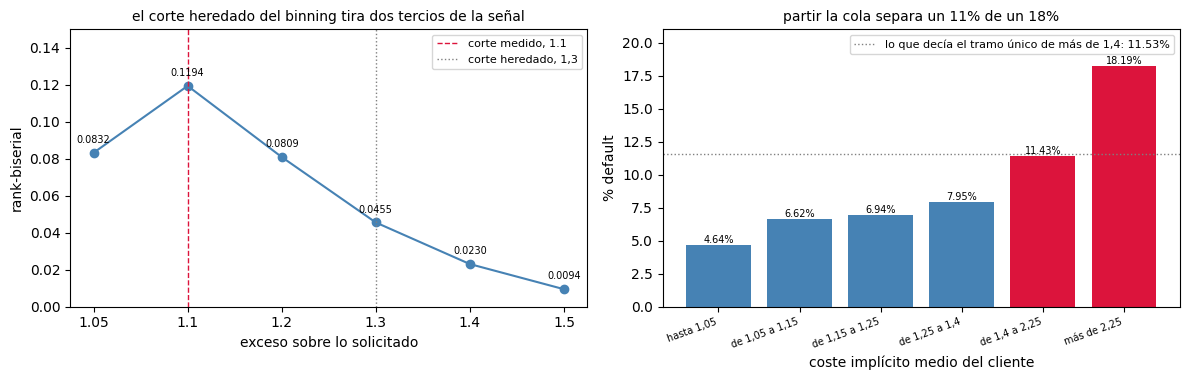

In [134]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
ax[0].plot(barrido_corte.index.astype(str), barrido_corte["r_rb de la proporción"], "o-",
           color=COLOR_NODEF)
for x, v in zip(range(len(barrido_corte)), barrido_corte["r_rb de la proporción"]):
    ax[0].annotate(f"{v:.4f}", (x, v), textcoords="offset points", xytext=(0, 7), fontsize=7,
                   ha="center")
ax[0].axvline(list(barrido_corte.index.astype(str)).index(str(CORTE_EXCESO)), color=COLOR_DEF,
              ls="--", lw=1, label=f"corte medido, {CORTE_EXCESO}")
ax[0].axvline(list(barrido_corte.index.astype(str)).index("1.3"), color="gray", ls=":", lw=1,
              label="corte heredado, 1,3")
ax[0].set(ylabel="rank-biserial", xlabel="exceso sobre lo solicitado", ylim=(0, 0.15))
ax[0].set_title("el corte heredado del binning tira dos tercios de la señal", fontsize=10)
ax[0].legend(fontsize=8)

colores = [COLOR_NODEF] * 4 + [COLOR_DEF, COLOR_DEF]
ax[1].bar(grad_coste_cli.index.astype(str), grad_coste_cli["% default"], color=colores)
ax[1].bar_label(ax[1].containers[0], fmt="%.2f%%", fontsize=7)
cola_vieja = train.loc[train["PREV_IMPLIED_COST_MEAN"].gt(1.4), "TARGET"].mean() * 100
ax[1].axhline(cola_vieja, color="gray", ls=":", lw=1,
              label=f"lo que decía el tramo único de más de 1,4: {cola_vieja:.2f}%")
ax[1].set(ylabel="% default", xlabel="coste implícito medio del cliente", ylim=(0, 21))
ax[1].set_title("partir la cola separa un 11% de un 18%", fontsize=10)
ax[1].legend(fontsize=8)
plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

In [135]:
# y dos de los términos del contrato, que deciden cómo se agrega y si hay interacción
train["PREV_CREDIT_APPLICATION_RATIO_MAX"] = por_cliente(ratio_conc, "max")
ev_ctrl.evaluar_continuas([("PREV_CREDIT_APPLICATION_RATIO", False, con_prev, "media, con previas"),
                           ("PREV_CREDIT_APPLICATION_RATIO_MAX", False, con_prev,
                            "máximo, con previas")])
print(f"media y máximo del ratio de concesión correlacionan "
      f"{train.loc[con_prev, 'PREV_CREDIT_APPLICATION_RATIO'].corr(train.loc[con_prev, 'PREV_CREDIT_APPLICATION_RATIO_MAX']):.4f}, "
      "así que entra una sola, y la media gana igual que en el coste implícito")


# ¿coste alto y sobreconcesión se refuerzan como la longitud con la actividad reciente?
alto_coste = train["PREV_IMPLIED_COST_MEAN"].gt(1.4)
alto_exceso = train["PREV_OVERGRANTED_RATIO"].gt(0.5)
base_2x2 = con_prev & train["PREV_IMPLIED_COST_MEAN"].notna().values & train["PREV_OVERGRANTED_RATIO"].notna().values
particion = {}
for a in [False, True]:
    for b in [False, True]:
        m = base_2x2 & alto_coste.eq(a).values & alto_exceso.eq(b).values
        particion[(a, b)] = (train["TARGET"][m].mean() * 100, int(m.sum()))
aditivo = (particion[(False, False)][0] + (particion[(True, False)][0] - particion[(False, False)][0])
           + (particion[(False, True)][0] - particion[(False, False)][0]))
print(f"\npartición de coste alto por sobreconcesión alta: "
      + " | ".join(f"{'coste' if a else 'sin coste'} y {'exceso' if b else 'sin exceso'} "
                   f"{v:.2f}% (n={n:,})" for (a, b), (v, n) in particion.items()))
print(f"lo aditivo predice {aditivo:.2f}% y se observa {particion[(True, True)][0]:.2f}%, o sea "
      f"{particion[(True, True)][0] - aditivo:+.2f}pp: se solapan en vez de reforzarse, al revés "
      "que la relación corta con mucha actividad reciente, así que aquí no hay término de interacción")

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_CREDIT_APPLICATION_RATIO,"media, con previas",290042,0.1458,7.811500906323928e-305,1.0,1.0
PREV_CREDIT_APPLICATION_RATIO_MAX,"máximo, con previas",290042,0.1161,1.0702659979750907e-194,1.1,1.1


media y máximo del ratio de concesión correlacionan 0.7370, así que entra una sola, y la media gana igual que en el coste implícito

partición de coste alto por sobreconcesión alta: sin coste y sin exceso 6.86% (n=203,148) | sin coste y exceso 10.60% (n=22,595) | coste y sin exceso 10.95% (n=43,248) | coste y exceso 12.88% (n=18,442)
lo aditivo predice 14.70% y se observa 12.88%, o sea -1.82pp: se solapan en vez de reforzarse, al revés que la relación corta con mucha actividad reciente, así que aquí no hay término de interacción


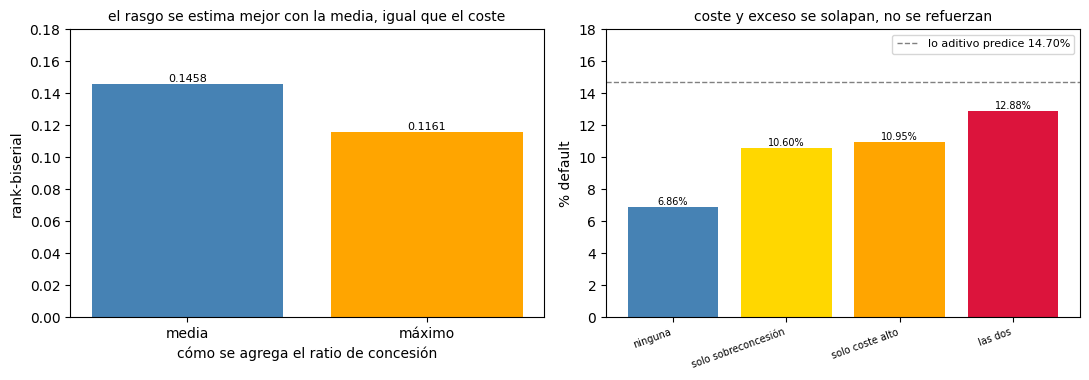

In [136]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
agregaciones = {}
for etiqueta, serie in [("media", train["PREV_CREDIT_APPLICATION_RATIO"]),
                        ("máximo", train["PREV_CREDIT_APPLICATION_RATIO_MAX"])]:
    v, t = serie[con_prev].dropna(), train.loc[con_prev, "TARGET"]
    t = t.loc[v.index]
    u, _ = mannwhitneyu(v[t == 0], v[t == 1])
    agregaciones[etiqueta] = abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1)
ax[0].bar(list(agregaciones), list(agregaciones.values()), color=[COLOR_NODEF, "orange"])
ax[0].bar_label(ax[0].containers[0], fmt="%.4f", fontsize=8)
ax[0].set(ylabel="rank-biserial", xlabel="cómo se agrega el ratio de concesión", ylim=(0, 0.18))
ax[0].set_title("el rasgo se estima mejor con la media, igual que el coste", fontsize=10)

etiquetas = ["ninguna", "solo sobreconcesión", "solo coste alto", "las dos"]
valores = [particion[(False, False)][0], particion[(False, True)][0], particion[(True, False)][0],
           particion[(True, True)][0]]
ax[1].bar(etiquetas, valores, color=[COLOR_NODEF, "gold", "orange", COLOR_DEF])
ax[1].bar_label(ax[1].containers[0], fmt="%.2f%%", fontsize=7)
ax[1].axhline(aditivo, color="gray", ls="--", lw=1, label=f"lo aditivo predice {aditivo:.2f}%")
ax[1].set(ylabel="% default", ylim=(0, 18))
ax[1].set_title("coste y exceso se solapan, no se refuerzan", fontsize=10)
ax[1].legend(fontsize=8)
plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

`PREV_CREDIT_APPLICATION_RATIO` (0,1458): pasa a ser la continua más fuerte de esta tabla, por
encima del 0,1334 del coste implícito medio. Va del 6,45% de quien de media recibe menos de lo que
pide (n=101.860) al 16,00% de quien recibe más de un 30% de más (n=1.169), con 7,61%, 8,30% y 11,83%
en medio. Hay una diferencia con lo que veía por operación que conviene no pasar por alto: allí el
gradiente no era monótono, porque recibir la cifra justa salía peor que recibir de menos y el exceso
pequeño volvía a proteger. Al promediar por cliente esa forma desaparece y queda un gradiente
limpio, también dentro del consumo aprobado, con 7,05%, 7,74%, 8,49%, 12,12% y 16,57%. El escalón
era mezcla de producto, con el revolving concentrado en el uno exacto, y promediar lo disuelve. La
agregación la cierro midiendo y no por analogía: la media rinde 0,1458 y el máximo 0,1161, con
0,7370 de correlación entre las dos, así que entra la media, la misma respuesta que ya dio el coste
implícito.

`PREV_OVERGRANTED_RATIO` (0,1194): el corte del 30% que venía arrastrando salía del tramo del
binning donde el riesgo saltaba al 14,12%, no de un barrido, y al barrerlo resulta estar mal puesto.
Sobre la proporción, que es como la variable va a entrar, el efecto tiene su máximo en un exceso del
10% con 0,1194 y cae a 0,0809 en el 20%, 0,0455 en el 30%, 0,0230 en el 40% y 0,0094 en el 50%. Como
bandera el delta crece monótono con el corte, de +1,60pp a +9,17pp, simplemente porque marca a cada
vez menos gente, y ahí está la trampa: decidiendo por ese delta habría fijado el corte alto y tirado
dos tercios de la señal. Lo fijo en el 10%, con la salvedad de que hay que refijarlo sobre el
conjunto de entrenamiento.

`PREV_CNT_PAYMENT_MEAN` (0,0810): el plazo medio pactado, contando solo donde es positivo porque el
cero es tarjeta sin cuadro de amortización, queda por debajo del 0,0891 que rendía por operación,
que es lo que espero de una media sobre una variable ya moderada. Se conserva, pero es de las
débiles.

Partir la cola del coste implícito confirma lo que el tramo único escondía: por encima de 1,4
convivían un 11,43% (n=60.783) con un 18,19% que solo aparece pasado 2,25 (n=907), y el gradiente
completo va del 4,64% al 18,19% en seis tramos.

Y una comprobación que da el resultado contrario al que buscaba: coste alto y sobreconcesión alta no
se refuerzan. La partición deja 6,86% sin ninguna de las dos, 10,60% con solo exceso, 10,95% con solo
coste alto y 12,88% con las dos, cuando la suma de los efectos por separado predeciría 14,70%. Son
-1,82pp de subaditividad, o sea que en buena parte marcan a la misma gente. No creo término de
interacción, al revés de lo que sí procedía entre la relación corta y la actividad reciente.

In [137]:
# cómo llega el cliente a la solicitud: las tres son proporciones sobre todas sus solicitudes
ev_cli.evaluar_continuas([
    ("PREV_STREET_RATIO", True, None, "global (relleno 0)"),
    ("PREV_STREET_RATIO", False, con_prev, "con previas"),
    ("PREV_EARLY_HOUR_RATIO", True, None, "global (relleno 0)"),
    ("PREV_EARLY_HOUR_RATIO", False, con_prev, "con previas"),
    ("PREV_NO_SUITE_RATIO", True, None, "global (relleno 0)"),
    ("PREV_NO_SUITE_RATIO", False, con_prev, "con previas")])

ETIQ_PROP = ["ninguna", "hasta el 25%", "del 25 al 50%", "del 50 al 99%", "todas"]
CAPTACION = ["PREV_STREET_RATIO", "PREV_EARLY_HOUR_RATIO", "PREV_NO_SUITE_RATIO"]
grad_captacion = {}
for c in CAPTACION:
    tramo = pd.cut(train[c], [-0.001, 0.001, 0.25, 0.5, 0.999, 1.001], labels=ETIQ_PROP)
    g = train[con_prev].groupby(tramo[con_prev], observed=True)["TARGET"].agg(
        clientes="size", tasa="mean")
    g["% default"] = (g.pop("tasa") * 100).round(2)
    grad_captacion[c] = g
display(pd.concat(grad_captacion, axis=1))

# ¿aguantan dentro de cada ventana, o son la recencia con otro nombre? y ¿son el volumen?
print("señal dentro de cada estrato de recencia, y solape con el conteo de solicitudes:")
for c in CAPTACION:
    fila = []
    for k in ETIQ_VENTANA:
        pob = con_prev & ventana_cli.eq(k).values
        v, t = train.loc[pob, c], train.loc[pob, "TARGET"]
        u, _ = mannwhitneyu(v[t == 0], v[t == 1])
        fila.append(f"{k} {abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1):.4f}")
    vol = train.loc[con_prev, c].corr(train.loc[con_prev, "PREV_APPLICATION_COUNT"])
    print(f"  {c:24s} " + " | ".join(fila) + f" | Pearson con el conteo {vol:+.4f}")

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_STREET_RATIO,global (relleno 0),307511,0.0935,3.931859359327581e-184,0.0,0.0
PREV_STREET_RATIO,con previas,291057,0.0924,5.112433514798228e-167,0.0,0.0
PREV_EARLY_HOUR_RATIO,global (relleno 0),307511,0.0512,1.1283258140541139e-84,0.0,0.0
PREV_EARLY_HOUR_RATIO,con previas,291057,0.0502,4.693622317384194e-75,0.0,0.0
PREV_NO_SUITE_RATIO,global (relleno 0),307511,0.0784,2.6003203019884952e-95,0.5,0.5
PREV_NO_SUITE_RATIO,con previas,291057,0.0716,2.311473470332611e-76,0.5,0.5


PREV_STREET_RATIO           PREV_EARLY_HOUR_RATIO            \
                       clientes % default              clientes % default   
ninguna                  185874      7.25                232013      7.73   
hasta el 25%              52417      8.62                 18423      9.25   
del 25 al 50%             38208     10.52                 19655     10.07   
del 50 al 99%              8360     13.58                 11153     10.69   
todas                      6198     11.10                  9813     10.50   

              PREV_NO_SUITE_RATIO            
                         clientes % default  
ninguna                     56752      7.40  
hasta el 25%                24470      6.72  
del 25 al 50%               91380      7.52  
del 50 al 99%               72988      9.39  
todas                       45467      9.40

señal dentro de cada estrato de recencia, y solape con el conteo de solicitudes:
  PREV_STREET_RATIO        más de 2 años 0.0080 | de 1 a 2 años 0.0713 | de 6 a 12 meses 0.1303 | menos de 6 meses 0.1098 | Pearson con el conteo +0.1176
  PREV_EARLY_HOUR_RATIO    más de 2 años 0.0334 | de 1 a 2 años 0.0397 | de 6 a 12 meses 0.0462 | menos de 6 meses 0.0621 | Pearson con el conteo +0.0312
  PREV_NO_SUITE_RATIO      más de 2 años 0.0299 | de 1 a 2 años 0.0745 | de 6 a 12 meses 0.0747 | menos de 6 meses 0.0788 | Pearson con el conteo +0.0426


In [138]:
# lo que el cliente declara y lo que pone de su bolsillo: las dos viven en un subconjunto de
# producto, así que su denominador no son todas sus solicitudes
urg = con_prev & train["PREV_URGENT_PURPOSE_COUNT"].gt(0).values
con_finalidad = con_prev & por_cliente(fin_informada, "sum").gt(0).values

# contar sobre todas las solicitudes reparte el mismo numerador entre un denominador que media
# cartera no tiene, así que al ranking va la proporción y el conteo se queda como control
ev_ctrl.evaluar_continuas([("PREV_URGENT_PURPOSE_COUNT", False, con_prev, "con previas")])
ev_cli.evaluar_continuas([
    ("PREV_URGENT_PURPOSE_RATIO", True, None, "global (relleno 0)"),
    ("PREV_URGENT_PURPOSE_RATIO", False, con_finalidad, "con finalidad informada"),
    ("PREV_DOWN_PAYMENT_RATE_MEAN", True, None, "global (relleno 0)"),
    ("PREV_DOWN_PAYMENT_RATE_MEAN", False, con_prev, "con previas")])
d, p = delta_z(train["TARGET"][urg], train["TARGET"][con_prev & ~urg])
di, pi = delta_z(train["TARGET"][con_finalidad & urg], train["TARGET"][con_finalidad & ~urg])
print(f"clientes con alguna finalidad de liquidez urgente: {int(urg.sum()):,} "
      f"({urg.sum() / con_prev.sum() * 100:.2f}% de los que tienen previas)")
print(f"  frente a todos los demás: {train['TARGET'][urg].mean() * 100:.2f}% contra "
      f"{train['TARGET'][con_prev & ~urg].mean() * 100:.2f}% | {d:+.2f}pp (p={p:.1e})")
print(f"  frente a quien también declara finalidad: {di:+.2f}pp (p={pi:.1e}), que es el contraste "
      "honesto porque el resto ni siquiera tiene ese campo")

# la entrada tenía tres niveles por operación, con el cero fuera del gradiente: ¿sigue así?
ETIQ_ENTRADA = ["sin entrada", "hasta el 5%", "del 5 al 10%", "del 10 al 20%", "más del 20%"]
tramo_entrada_cli = pd.cut(train["PREV_DOWN_PAYMENT_RATE_MEAN"], [-0.001, 0.0001, 0.05, 0.1, 0.2, 1.1],
                           labels=ETIQ_ENTRADA)
grad_entrada = train[con_prev].groupby(tramo_entrada_cli[con_prev], observed=True)["TARGET"].agg(
    clientes="size", tasa="mean")
grad_entrada["% default"] = (grad_entrada.pop("tasa") * 100).round(2)
display(grad_entrada)
d, p = delta_z(train["TARGET"][con_prev & tramo_entrada_cli.eq("sin entrada").values],
               train["TARGET"][con_prev & tramo_entrada_cli.eq("hasta el 5%").values])
da, pa = delta_z(train["TARGET"][con_prev & tramo_entrada_cli.eq("más del 20%").values],
                 train["TARGET"][con_prev & tramo_entrada_cli.eq("hasta el 5%").values])
nunca = con_prev & train["PREV_DOWN_PAYMENT_RATE_MEAN"].eq(0).values
suyas = pt.loc[consumo_op & pt["SK_ID_CURR"].isin(train.loc[nunca, "SK_ID_CURR"]),
               "RATE_DOWN_PAYMENT"]
print(f"nunca poner entrada frente a ponerla simbólica: {d:+.2f}pp (p={p:.1e}), que no cruza los "
      "2pp ni el alfa de la sección")
print(f"poner más del 20% frente a la simbólica: {da:+.2f}pp (p={pa:.1e})")
print("o sea que los dos niveles bajos dejan de distinguirse y el gradiente se vuelve monótono: "
      "por operación el cero era un producto aparte y por cliente es el que nunca pone dinero")
print(f"y encaja con de qué está hecho: de las operaciones de consumo de esos {int(nunca.sum()):,} "
      f"clientes, el {suyas.eq(0).mean() * 100:.2f}% viene sin entrada, así que no es una "
      "operación suelta sin entrada sino una forma de financiarse")

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_URGENT_PURPOSE_COUNT,con previas,291057,0.0241,6.058562187723059e-96,0.0,0.0


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_URGENT_PURPOSE_RATIO,global (relleno 0),307511,0.0234,2.47947922301507e-99,0.0,0.0
PREV_URGENT_PURPOSE_RATIO,con finalidad informada,35917,0.0474,2.1909082193097648e-11,0.0,0.0
PREV_DOWN_PAYMENT_RATE_MEAN,global (relleno 0),307511,0.0683,8.842869705629031e-75,0.1,0.0
PREV_DOWN_PAYMENT_RATE_MEAN,con previas,268895,0.0811,3.430413265029665e-89,0.1,0.1


clientes con alguna finalidad de liquidez urgente: 8,821 (3.03% de los que tienen previas)
  frente a todos los demás: 14.15% contra 8.01% | +6.14pp (p=2.7e-95)
  frente a quien también declara finalidad: +2.99pp (p=5.1e-14), que es el contraste honesto porque el resto ni siquiera tiene ese campo


,clientes,% default
PREV_DOWN_PAYMENT_RATE_MEAN,,
sin entrada,75540,9.37
hasta el 5%,25351,8.86
del 5 al 10%,58232,7.96
del 10 al 20%,81891,7.36
más del 20%,27881,6.05


nunca poner entrada frente a ponerla simbólica: +0.50pp (p=1.7e-02), que no cruza los 2pp ni el alfa de la sección
poner más del 20% frente a la simbólica: -2.81pp (p=3.7e-35)
o sea que los dos niveles bajos dejan de distinguirse y el gradiente se vuelve monótono: por operación el cero era un producto aparte y por cliente es el que nunca pone dinero
y encaja con de qué está hecho: de las operaciones de consumo de esos 72,373 clientes, el 99.47% viene sin entrada, así que no es una operación suelta sin entrada sino una forma de financiarse


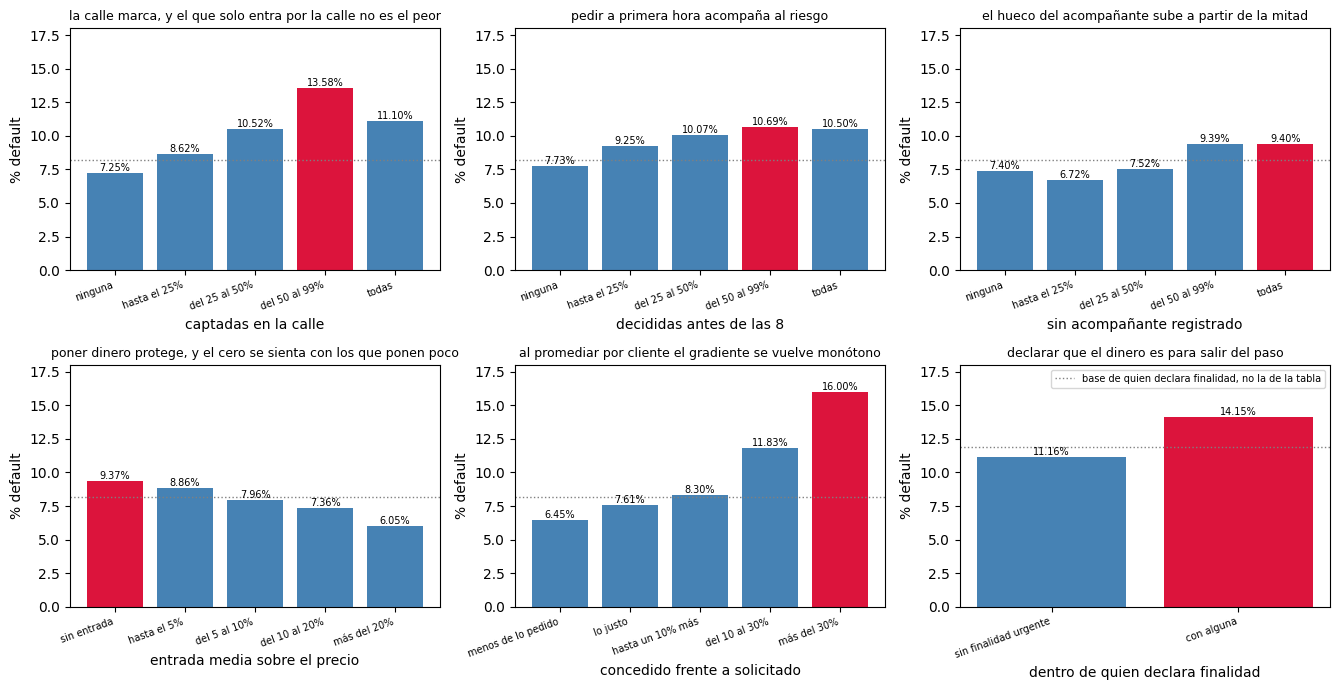

In [139]:
fig, ax = plt.subplots(2, 3, figsize=(13.5, 7))
paneles = [
    (ax[0][0], grad_captacion["PREV_STREET_RATIO"], "captadas en la calle",
     "la calle marca, y el que solo entra por la calle no es el peor"),
    (ax[0][1], grad_captacion["PREV_EARLY_HOUR_RATIO"], "decididas antes de las 8",
     "pedir a primera hora acompaña al riesgo"),
    (ax[0][2], grad_captacion["PREV_NO_SUITE_RATIO"], "sin acompañante registrado",
     "el hueco del acompañante sube a partir de la mitad"),
    (ax[1][0], grad_entrada, "entrada media sobre el precio",
     "poner dinero protege, y el cero se sienta con los que ponen poco"),
    (ax[1][1], grad_conc, "concedido frente a solicitado",
     "al promediar por cliente el gradiente se vuelve monótono"),
]
for eje, tabla, etiqueta, titulo in paneles:
    colores = [COLOR_DEF if v == tabla["% default"].max() else COLOR_NODEF
               for v in tabla["% default"]]
    eje.bar(tabla.index.astype(str), tabla["% default"], color=colores)
    eje.bar_label(eje.containers[0], fmt="%.2f%%", fontsize=7)
    eje.axhline(train.loc[con_prev, "TARGET"].mean() * 100, color="gray", ls=":", lw=1)
    eje.set(ylabel="% default", xlabel=etiqueta, ylim=(0, 18))
    eje.set_title(titulo, fontsize=9)
    plt.setp(eje.get_xticklabels(), rotation=20, ha="right", fontsize=7)

urgentes = pd.Series({"sin finalidad urgente": train["TARGET"][con_finalidad & ~urg].mean() * 100,
                      "con alguna": train["TARGET"][con_finalidad & urg].mean() * 100})
ax[1][2].bar(urgentes.index, urgentes.values, color=[COLOR_NODEF, COLOR_DEF])
ax[1][2].bar_label(ax[1][2].containers[0], fmt="%.2f%%", fontsize=7)
ax[1][2].axhline(train["TARGET"][con_finalidad].mean() * 100, color="gray", ls=":", lw=1,
                 label="base de quien declara finalidad, no la de la tabla")
ax[1][2].set(ylabel="% default", xlabel="dentro de quien declara finalidad", ylim=(0, 18))
ax[1][2].set_title("declarar que el dinero es para salir del paso", fontsize=9)
ax[1][2].legend(fontsize=7)
plt.setp(ax[1][2].get_xticklabels(), rotation=20, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

In [140]:
# los dos marcadores raros: celdas pequeñas, así que el contraste va con Fisher y la cobertura
# de cartera se declara al lado del delta para que la severidad no se lea como importancia
raros = []
for c in ["PREV_PHANTOM_FLAG", "PREV_REFUSED_LONG_TERM_FLAG"]:
    m, o = con_prev & train[c].eq(1).values, con_prev & train[c].eq(0).values
    marcados, resto = train["TARGET"][m], train["TARGET"][o]
    tabla = [[int((resto == 0).sum()), int(resto.sum())],
             [int((marcados == 0).sum()), int(marcados.sum())]]
    d, _ = delta_z(marcados, resto)
    raros.append({"bandera": c, "clientes": int(m.sum()),
                  "% de la cartera con previas": round(m.sum() / con_prev.sum() * 100, 3),
                  "% default": round(marcados.mean() * 100, 2),
                  "% default del resto": round(resto.mean() * 100, 2),
                  "delta (pp)": round(d, 2), "Fisher p": fisher_exact(tabla)[1]})
raros = pd.DataFrame(raros).set_index("bandera")
display(raros)
ev_cli.evaluar_flags([("PREV_PHANTOM_FLAG", train["PREV_PHANTOM_FLAG"].values, None,
                       "global (relleno 0)"),
                      ("PREV_PHANTOM_FLAG", train["PREV_PHANTOM_FLAG"].values, con_prev,
                       "con previas"),
                      ("PREV_REFUSED_LONG_TERM_FLAG", train["PREV_REFUSED_LONG_TERM_FLAG"].values,
                       None, "global (relleno 0)"),
                      ("PREV_REFUSED_LONG_TERM_FLAG", train["PREV_REFUSED_LONG_TERM_FLAG"].values,
                       con_prev, "con previas")])

# la población en la que se decide cada feature no es la misma para todas, así que la declaro una
# vez y la consultan la figura y el control de composición, en lugar de deducirla del nombre
POB_MEDICION = {"PREV_REFUSED_SCOFR_FLAG": scofr,
                "PREV_URGENT_PURPOSE_RATIO": con_finalidad,
                "PREV_EARLY_SETTLED_FLAG": formalizado}
TIPO = {e["feature"]: e["tipo"] for e in ev_cli.fb_flags + ev_cli.fb_cont}


def poblacion(c):
    """población en la que se decidió la feature; por defecto, tener alguna solicitud previa"""
    return POB_MEDICION.get(c, con_prev)


,clientes,% de la cartera con previas,% default,% default del resto,delta (pp),Fisher p
bandera,,,,,,
PREV_PHANTOM_FLAG,284,0.098,19.72,8.18,11.54,7.777151e-10
PREV_REFUSED_LONG_TERM_FLAG,78,0.027,21.79,8.19,13.61,1.627406e-04


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
PREV_PHANTOM_FLAG,global (relleno 0),19.72% (n=284),8.06% (n=307227),+11.66 pp,7.2,5.702674599555853e-13
PREV_PHANTOM_FLAG,con previas,19.72% (n=284),8.18% (n=290773),+11.54 pp,7.1,1.3819264722494622e-12
PREV_REFUSED_LONG_TERM_FLAG,global (relleno 0),21.79% (n=78),8.07% (n=307433),+13.73 pp,4.4,8.6184852124715e-06
PREV_REFUSED_LONG_TERM_FLAG,con previas,21.79% (n=78),8.19% (n=290979),+13.61 pp,4.4,1.1815450664349678e-05


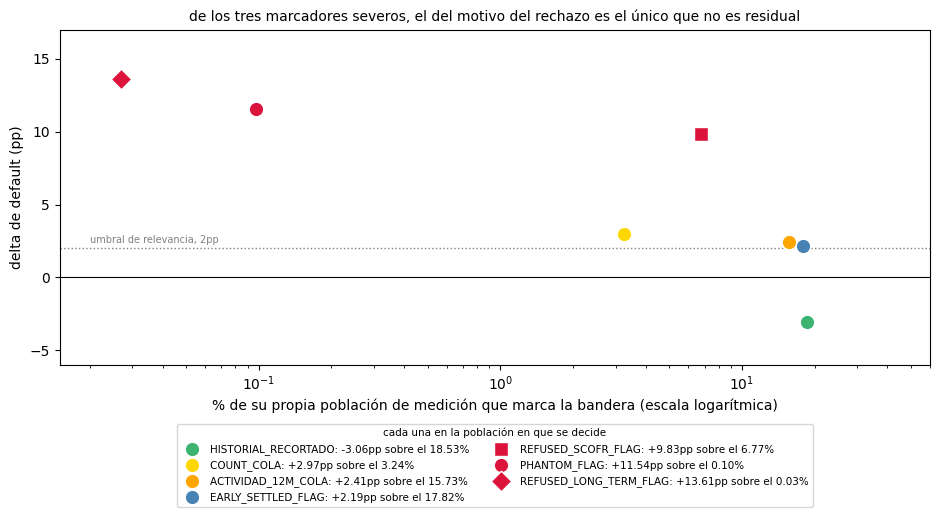

In [141]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
BANDERAS_TODAS = ["PREV_HISTORIAL_RECORTADO", "PREV_COUNT_COLA", "PREV_ACTIVIDAD_12M_COLA",
                  "PREV_EARLY_SETTLED_FLAG", "PREV_REFUSED_SCOFR_FLAG", "PREV_PHANTOM_FLAG",
                  "PREV_REFUSED_LONG_TERM_FLAG"]
# paleta del proyecto: los tres marcadores de riesgo severo comparten color y se separan por forma
PALETA = ["mediumseagreen", "gold", "orange", COLOR_NODEF, COLOR_DEF, COLOR_DEF, COLOR_DEF]
FORMAS = ["o", "o", "o", "o", "s", "o", "D"]
for c, color, forma in zip(BANDERAS_TODAS, PALETA, FORMAS):
    pob = poblacion(c)  # cada una en la suya, que es donde se decide y donde la mide el ranking
    m, o = pob & train[c].eq(1).values, pob & train[c].eq(0).values
    d, _ = delta_z(train["TARGET"][m], train["TARGET"][o])
    cobertura_pp = m.sum() / pob.sum() * 100
    ax.scatter(cobertura_pp, d, s=110, color=color, marker=forma, edgecolor="white", zorder=3,
               label=f"{c.replace('PREV_', '')}: {d:+.2f}pp sobre el {cobertura_pp:.2f}%")
ax.axhline(2, color="gray", ls=":", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.annotate("umbral de relevancia, 2pp", (0.02, 2.4), fontsize=7, color="gray")
ax.set_xscale("log")
ax.set(xlabel="% de su propia población de medición que marca la bandera (escala logarítmica)",
       ylabel="delta de default (pp)", xlim=(0.015, 60), ylim=(-6, 17))
ax.set_title("de los tres marcadores severos, el del motivo del rechazo es el único que no es "
             "residual", fontsize=10)
# la leyenda va debajo: en la esquina superior derecha tapaba el punto del motivo del rechazo
ax.legend(fontsize=7.5, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          title="cada una en la población en que se decide", title_fontsize=7.5)
plt.tight_layout()
plt.show()

`PREV_STREET_RATIO` (0,0924): la proporción captada en la calle va del 7,25% de quien nunca entra
por ahí al 13,58% de quien lo hace entre la mitad y casi todas sus solicitudes, con 8,62% y 10,52%
en medio. El que entra solo por la calle no es el peor, con 11,10%, lo que encaja con que sea un
cliente de un único producto y no un buscador de financiación. No es el volumen disfrazado, con
0,1176 de correlación con el conteo de solicitudes, pero sí es rehén de la ventana: rinde 0,0080 en
quien no pide desde hace más de dos años y 0,1303 de seis a doce meses, así que fuera del pasado
reciente no dice nada.

`PREV_EARLY_HOUR_RATIO` (0,0502) y `PREV_NO_SUITE_RATIO` (0,0716): la hora temprana va del 7,73% al
10,69% y la ausencia de acompañante del 7,40% al 9,40%, las dos en banda débil y con el mismo patrón
de depender de la ventana. La del acompañante tiene un detalle que no anticipaba: no es monótona por
abajo, porque quien tiene hasta un cuarto de sus solicitudes sin acompañante da 6,72%, por debajo
del 7,40% de quien las tiene todas registradas. La señal vive en la mitad alta, con 9,39% y 9,40%.

`PREV_URGENT_PURPOSE_RATIO` (0,0474): 8.821 clientes, el 3,03% de los que tienen previas, declaran
alguna finalidad de liquidez urgente y dan 14,15% frente al 8,01% del resto, que son +6,14pp. Pero el
contraste honesto es contra quien también declara para qué quiere el dinero, porque los demás ni
siquiera tienen ese campo, y ahí quedan +2,99pp, que reproduce clavado el +3,00pp que tenía medido
por operación con el estado fijo. Y ese mismo razonamiento decide la codificación: contar las
solicitudes urgentes sobre todas las del cliente rinde 0,0241 y medir la proporción sobre las que sí
declaran finalidad rinde 0,0474, el doble, porque el conteo reparte el mismo numerador entre un
denominador que media cartera no tiene. Entra la proporción y el conteo se queda como control.

`PREV_DOWN_PAYMENT_RATE_MEAN` (0,0811): aquí está la desviación más interesante. Por operación la
entrada tenía estructura de tres niveles y el cero quedaba fuera del gradiente, con -1,44pp frente a
la entrada simbólica, así que había dejado dicho que no se binarizara nunca. Por cliente eso deja de
cumplirse: los dos niveles bajos ya no se distinguen, con +0,50pp y p = 0,017, que no cruza ni los
dos puntos porcentuales ni el alfa de esta pasada, y lo que queda es un gradiente monótono del 9,37%
al 6,05%, con -2,81pp del tramo alto frente al simbólico. El motivo está medido y no supuesto: de las
operaciones de consumo de los 72.373 clientes cuya media es exactamente cero, el 99,47% viene sin
entrada, así que el cero de cliente no es una operación suelta sin entrada sino quien nunca pone
dinero de su bolsillo. La instrucción de no binarizarla valía por operación y no se traslada al
nivel cliente.

`PREV_PHANTOM_FLAG` (+11,54pp) y `PREV_REFUSED_LONG_TERM_FLAG` (+13,61pp): 284 clientes al 19,72% y
78 al 21,79%, el 0,098% y el 0,027% de quienes tienen alguna solicitud previa, los dos con Fisher
por debajo de 1e-03. El plazo largo rechazado marcaba +15,09pp por operación y baja a +13,61pp por
cliente, porque las 118 operaciones se concentran en 78 personas que además tienen operaciones
normales que las diluyen. Conservo las dos por severidad, dejando dicho que su impacto de cartera es
mínimo y que sirven para explicar casos, no para mover el grueso del riesgo.

In [142]:
# el control de composición de toda la tabla: aquí el grupo ausente es el de menos riesgo,
# así que la medición global no enmascara como en el buró sino que infla. el tipo sale del propio
# registro del acumulador y la población de POB_MEDICION, nunca del nombre de la columna
comparadas = []
for c in NUEVAS:
    if TIPO[c] == "flag":
        v, pob = train[c].fillna(0).values, poblacion(c)
        dg, _ = delta_z(train["TARGET"][v == 1], train["TARGET"][v == 0])
        dc, _ = delta_z(train["TARGET"][pob & (v == 1)], train["TARGET"][pob & (v == 0)])
        comparadas.append({"feature": c, "medida": "delta (pp)", "global": round(dg, 2),
                           "condicionada": round(dc, 2), "sesgo": round(dg - dc, 2)})
    else:
        filas = []
        for s, pob in [(train[c].fillna(0), None), (train[c], poblacion(c))]:
            m = s.notna().values if pob is None else (s.notna().values & pob)
            v, t = s[m], train["TARGET"][m]
            u, _ = mannwhitneyu(v[t == 0], v[t == 1])
            filas.append(abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1))
        comparadas.append({"feature": c, "medida": "r_rb", "global": round(filas[0], 4),
                           "condicionada": round(filas[1], 4),
                           "sesgo": round(filas[0] - filas[1], 4)})
composicion = pd.DataFrame(comparadas).set_index("feature")
display(composicion)
infla = int((composicion["sesgo"] > 0).sum())
print(f"la global exagera la señal en {infla} de las {len(composicion)} y la enmascara en "
      f"{len(composicion) - infla}, que es el signo espejado del buró: como quien nunca pidió aquí "
      "es el más seguro, el relleno a cero le regala pendiente a lo que penaliza")
# las dos medidas no comparten escala, así que el mayor sesgo va declarado dentro de cada una
for medida, grupo in composicion.groupby("medida"):
    peor = grupo["sesgo"].abs().idxmax()
    print(f"  mayor sesgo en {medida}: {peor}, con {grupo.loc[peor, 'sesgo']}")

,medida,global,condicionada,sesgo
feature,,,,
PREV_REFUSED_RATIO,r_rb,0.1196,0.1204,-0.0008
PREV_REFUSED_COUNT,r_rb,0.1121,0.1122,-0.0001
PREV_REFUSED_SCOFR_FLAG,delta (pp),11.6800,9.8300,1.8400
PREV_CREDIT_APPLICATION_RATIO,r_rb,0.1480,0.1458,0.0022
PREV_OVERGRANTED_RATIO,r_rb,0.1208,0.1194,0.0015
PREV_CNT_PAYMENT_MEAN,r_rb,0.0850,0.0810,0.0040
PREV_STREET_RATIO,r_rb,0.0935,0.0924,0.0011
PREV_EARLY_HOUR_RATIO,r_rb,0.0512,0.0502,0.0010
PREV_NO_SUITE_RATIO,r_rb,0.0784,0.0716,0.0068


la global exagera la señal en 9 de las 13 y la enmascara en 4, que es el signo espejado del buró: como quien nunca pidió aquí es el más seguro, el relleno a cero le regala pendiente a lo que penaliza
  mayor sesgo en delta (pp): PREV_REFUSED_SCOFR_FLAG, con 1.84
  mayor sesgo en r_rb: PREV_URGENT_PURPOSE_RATIO, con -0.024


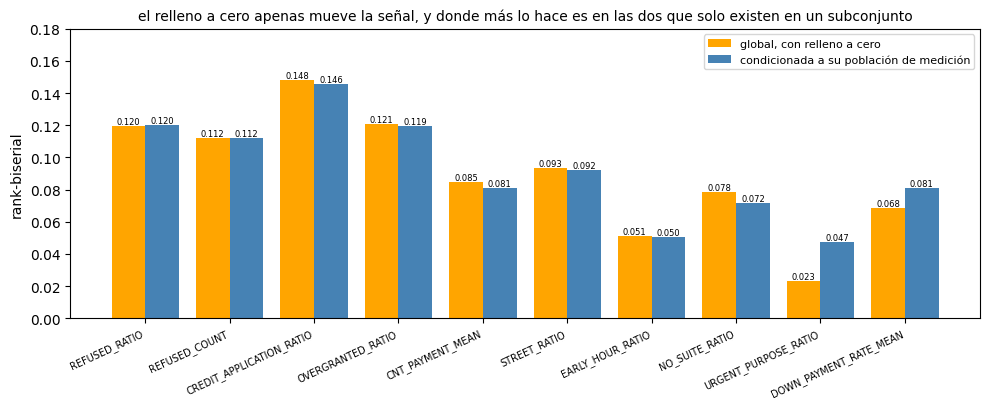

In [143]:
fig, ax = plt.subplots(figsize=(10, 4.2))
cont = composicion[composicion["medida"] == "r_rb"]
x = range(len(cont))
ax.bar([i - 0.2 for i in x], cont["global"], 0.4, color="orange", label="global, con relleno a cero")
ax.bar([i + 0.2 for i in x], cont["condicionada"], 0.4, color=COLOR_NODEF,
       label="condicionada a su población de medición")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=6)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace("PREV_", "") for c in cont.index], rotation=25, ha="right", fontsize=7)
ax.set(ylabel="rank-biserial", ylim=(0, 0.18))
ax.set_title("el relleno a cero apenas mueve la señal, y donde más lo hace es en las dos que "
             "solo existen en un subconjunto", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [144]:
# las veintiocho no se pueden ordenar sin saber cuáles son la misma: Pearson en las magnitudes
# y V de Cramér en las banderas, que responden preguntas distintas
MEDIDAS = ["PREV_HISTORIAL_RECORTADO", "PREV_APPLICATION_COUNT", "PREV_COUNT_COLA",
           "PREV_APPLICATIONS_PER_YEAR", "PREV_DAYS_DECISION_MIN", "PREV_DAYS_DECISION_MAX",
           "PREV_COUNT_12M", "PREV_ACTIVIDAD_12M_COLA", "PREV_EARLY_SETTLED_FLAG",
           "PREV_EARLY_SETTLED_COUNT", "PREV_EARLY_SETTLED_RATIO", "PREV_FUTURE_DUE_MAX",
           "PREV_IMPLIED_COST_MEAN", "PREV_IMPLIED_COST_MAX"]
TODAS = MEDIDAS + NUEVAS
assert len(TODAS) == 27 and len(set(TODAS)) == 27, "faltan o sobran candidatas"
print("HAS_PREV_APPLICATION queda fuera de la matriz: dentro de los que tienen previas vale 1 "
      "para todos y no tiene varianza que correlacionar")

cor_cli = train.loc[con_prev, TODAS].astype(float).corr()
pares_cli = [(a, b, cor_cli.loc[a, b]) for i, a in enumerate(TODAS) for b in TODAS[i + 1:]]
altos = sorted([p for p in pares_cli if abs(p[2]) > 0.70], key=lambda x: -abs(x[2]))
display(pd.DataFrame([{"par": f"{a} y {b}", "Pearson": round(r, 4)} for a, b, r in altos])
        .style.hide(axis="index"))
print(f"pares por encima de 0,70: {len(altos)} de {len(pares_cli)}")

BANDERAS = ["PREV_HISTORIAL_RECORTADO", "PREV_COUNT_COLA", "PREV_ACTIVIDAD_12M_COLA",
            "PREV_EARLY_SETTLED_FLAG", "PREV_REFUSED_SCOFR_FLAG", "PREV_PHANTOM_FLAG",
            "PREV_REFUSED_LONG_TERM_FLAG"]
v_max = max(cramer(train.loc[con_prev, a], train.loc[con_prev, b])
            for i, a in enumerate(BANDERAS) for b in BANDERAS[i + 1:])
print(f"y entre las {len(BANDERAS)} banderas el máximo de V de Cramér es {v_max:.4f}, muy por "
      "debajo del umbral de 0,50: ninguna pareja de banderas sobra")

# los pares que se quedan a las puertas del umbral tampoco se pueden dar por buenos solo porque no
# lo crucen, así que los paso por el mismo método que los que sí: cada una dentro de los estratos de
# la otra. los estratos van por quintiles para no tener que elegir cortes de negocio par a par
def estratos(col):
    """quintiles de una columna de cliente; las binarias van por su propio valor"""
    v = train[col]
    if v.dropna().nunique() <= 2:
        return v.astype("Int64").astype(str).where(v.notna())
    return pd.qcut(v, 5, duplicates="drop").astype(str).where(v.notna())


def rrb_en(col, pob):
    """rank-biserial de una columna de cliente dentro de una población"""
    v = train.loc[pob, col].dropna()
    if v.nunique() < 2:
        return None
    t = train["TARGET"].loc[v.index]
    u, pv = mannwhitneyu(v[t == 0], v[t == 1])
    return abs(2 * u / ((t == 0).sum() * (t == 1).sum()) - 1), len(v), pv


BORDE = sorted([q for q in pares_cli if 0.60 <= abs(q[2]) < 0.70], key=lambda x: -abs(x[2]))
print(f"\npares entre 0,60 y 0,70, que el umbral dejaría pasar sin mirarlos: {len(BORDE)}")
filas = []
for a, b, r in BORDE:
    for dentro, fuera in ((b, a), (a, b)):
        e = estratos(dentro)
        por_estrato = [x[0] for x in (rrb_en(fuera, con_prev & e.eq(k).values)
                                      for k in e.dropna().unique()) if x is not None]
        filas.append({"feature": fuera.replace("PREV_", ""),
                      "dentro de": dentro.replace("PREV_", ""), "|Pearson|": round(abs(r), 4),
                      "efecto propio": round(rrb_en(fuera, con_prev)[0], 4),
                      "estratos": len(por_estrato),
                      "mínimo dentro": round(min(por_estrato), 4),
                      "máximo dentro": round(max(por_estrato), 4)})
display(pd.DataFrame(filas).style.hide(axis="index"))
print("en los cinco pares una domina y la otra se desinfla sin llegar a anularse, así que las conservo\n"
      "todas y el desempate se decide por capacidad predictiva sobre el conjunto de entrenamiento")

# el único de los cinco que mueve el ranking se mira con detalle y con tramos de negocio, no con
# quintiles, porque de aquí salen las cifras con las que se argumenta la decisión
TR_12M = pd.cut(train["PREV_COUNT_12M"], [-0.5, 0.5, 1.5, 3.5, 200],
                labels=["0", "1", "de 2 a 3", "4 o más"])
TR_RITMO = pd.cut(train["PREV_APPLICATIONS_PER_YEAR"], [0, 0.5, 1, 2, 4, 100], labels=TRAMOS_INT)
print("\nel ritmo dentro de tramos de actividad reciente")
for k in TR_12M.cat.categories:
    r, nn, pv = rrb_en("PREV_APPLICATIONS_PER_YEAR", con_prev & TR_12M.eq(k).values)
    print(f"  {k:10s} r_rb {r:.4f} (n={nn:,}) p={pv:.1e}")
print("la actividad reciente dentro de tramos de ritmo, con su bandera al lado")
for k in TR_RITMO.cat.categories:
    pob = con_prev & TR_RITMO.eq(k).values
    r, nn, pv = rrb_en("PREV_COUNT_12M", pob)
    marc = pob & train["PREV_ACTIVIDAD_12M_COLA"].eq(1).values
    resto = pob & train["PREV_ACTIVIDAD_12M_COLA"].eq(0).values
    if min(int(marc.sum()), int(resto.sum())) > 200:
        d, pd_ = delta_z(train["TARGET"][marc], train["TARGET"][resto])
        extra = f" | bandera {d:+.2f}pp (p={pd_:.1e})"
    else:
        extra = f" | bandera sin muestra (marca a {int(marc.sum())})"
    print(f"  {k:12s} continua r_rb {r:.4f} (n={nn:,}) p={pv:.1e}{extra}")
print(f"parte de la brecha es mecánica: la actividad reciente está a cero en el "
      f"{train.loc[con_prev, 'PREV_COUNT_12M'].eq(0).mean() * 100:.2f}% de los que tienen previas y los "
      "empates aplastan su rank-biserial, mientras que el ritmo no tiene ceros")

# la bandera no aporta efecto propio sobre el ritmo, pero la interacción con la longitud sí es
# suya: el mismo cruce con un corte de ritmo de cobertura parecida se queda en nada
larga_4 = (train["PREV_RELACION_ANIOS"] >= 4).values
print("  la interacción con la relación larga, que es lo único que la bandera no cede al ritmo")
for etiqueta, activo in [("bandera, 4 o más en doce meses", train["PREV_ACTIVIDAD_12M_COLA"].eq(1).values),
                         ("ritmo, 2 o más al año", train["PREV_APPLICATIONS_PER_YEAR"].ge(2).fillna(False).values)]:
    celda = {(l, a): train["TARGET"][con_prev & (larga_4 == l) & (activo == a)].mean() * 100
             for l in (True, False) for a in (False, True)}
    aditivo = celda[(False, False)] + celda[(True, True)] - celda[(True, False)]
    print(f"    {etiqueta:32s} marca al {activo[con_prev].mean() * 100:5.2f}% | esquina "
          f"{celda[(False, True)]:.2f}% frente a {aditivo:.2f}% aditivo "
          f"({celda[(False, True)] - aditivo:+.2f}pp)")

HAS_PREV_APPLICATION queda fuera de la matriz: dentro de los que tienen previas vale 1 para todos y no tiene varianza que correlacionar


par,Pearson
PREV_IMPLIED_COST_MEAN y PREV_IMPLIED_COST_MAX,0.861600
PREV_EARLY_SETTLED_FLAG y PREV_EARLY_SETTLED_COUNT,0.858600
PREV_EARLY_SETTLED_FLAG y PREV_EARLY_SETTLED_RATIO,0.853900
PREV_EARLY_SETTLED_COUNT y PREV_EARLY_SETTLED_RATIO,0.784900
PREV_COUNT_12M y PREV_ACTIVIDAD_12M_COLA,0.782600
PREV_REFUSED_RATIO y PREV_REFUSED_COUNT,0.744700
PREV_APPLICATION_COUNT y PREV_REFUSED_COUNT,0.726800
PREV_APPLICATION_COUNT y PREV_COUNT_12M,0.720700


pares por encima de 0,70: 8 de 351


y entre las 7 banderas el máximo de V de Cramér es 0.3195, muy por debajo del umbral de 0,50: ninguna pareja de banderas sobra

pares entre 0,60 y 0,70, que el umbral dejaría pasar sin mirarlos: 5


feature,dentro de,|Pearson|,efecto propio,estratos,mínimo dentro,máximo dentro
APPLICATIONS_PER_YEAR,COUNT_12M,0.670200,0.114900,3,0.066300,0.175900
COUNT_12M,APPLICATIONS_PER_YEAR,0.670200,0.063900,5,0.015300,0.037700
CREDIT_APPLICATION_RATIO,OVERGRANTED_RATIO,0.650200,0.145800,3,0.055100,0.116500
OVERGRANTED_RATIO,CREDIT_APPLICATION_RATIO,0.650200,0.119400,5,0.005300,0.064900
CREDIT_APPLICATION_RATIO,DOWN_PAYMENT_RATE_MEAN,0.644800,0.145800,5,0.085000,0.140800
DOWN_PAYMENT_RATE_MEAN,CREDIT_APPLICATION_RATIO,0.644800,0.081100,5,0.004600,0.043000
APPLICATION_COUNT,COUNT_COLA,0.633400,0.021000,2,0.009300,0.033100
COUNT_COLA,APPLICATION_COUNT,0.633400,0.012400,1,0.038600,0.038600
IMPLIED_COST_MEAN,CNT_PAYMENT_MEAN,0.613300,0.133400,5,0.104000,0.156600
CNT_PAYMENT_MEAN,IMPLIED_COST_MEAN,0.613300,0.081000,5,0.010700,0.061100


en los cinco pares una domina y la otra se desinfla sin llegar a anularse, así que las conservo
todas y el desempate se decide por capacidad predictiva sobre el conjunto de entrenamiento

el ritmo dentro de tramos de actividad reciente
  0          r_rb 0.0411 (n=122,371) p=5.5e-11
  1          r_rb 0.1080 (n=61,480) p=1.0e-35
  de 2 a 3   r_rb 0.1348 (n=61,435) p=3.1e-58
  4 o más    r_rb 0.1759 (n=45,771) p=8.6e-87
la actividad reciente dentro de tramos de ritmo, con su bandera al lado
  hasta 0,5    continua r_rb 0.0115 (n=52,201) p=5.7e-02 | bandera sin muestra (marca a 0)
  de 0,5 a 1   continua r_rb 0.0231 (n=87,741) p=6.0e-04 | bandera +0.05pp (p=9.3e-01)
  de 1 a 2     continua r_rb 0.0291 (n=91,161) p=1.8e-05 | bandera -0.51pp (p=4.2e-02)
  de 2 a 4     continua r_rb 0.0329 (n=44,624) p=2.0e-04 | bandera -0.91pp (p=2.2e-03)
  más de 4     continua r_rb 0.0187 (n=15,330) p=1.6e-01 | bandera +0.77pp (p=3.0e-01)
parte de la brecha es mecánica: la actividad reciente está a cero en

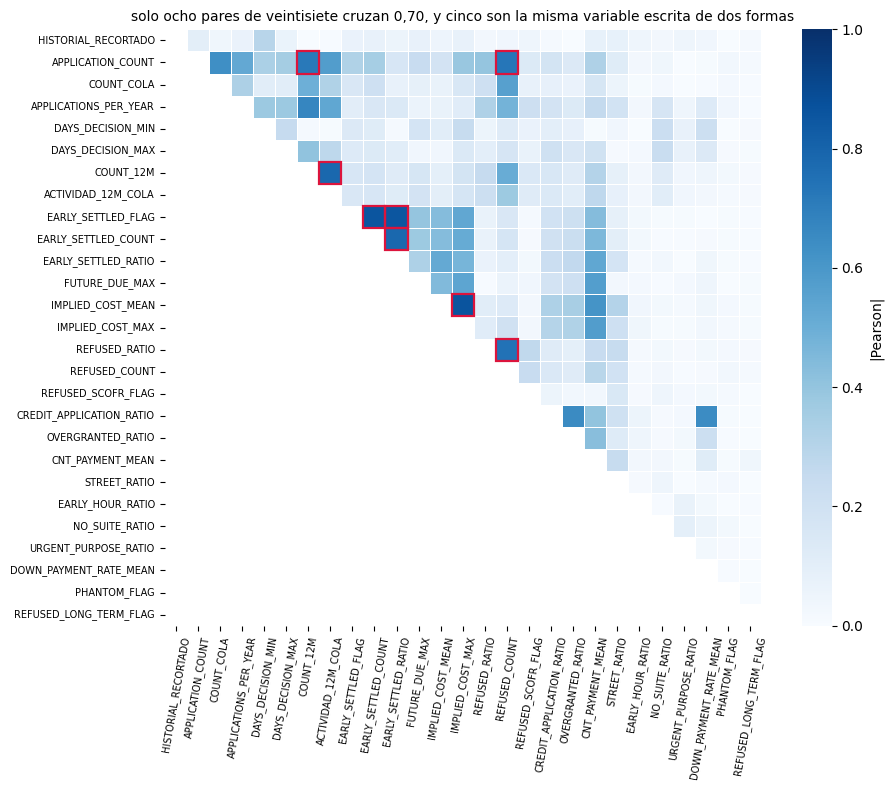

In [145]:
fig, ax = plt.subplots(figsize=(10, 8))
etiquetas = [c.replace("PREV_", "") for c in TODAS]
mostrada = cor_cli.abs()
mostrada.index = mostrada.columns = etiquetas
mascara = pd.DataFrame([[j <= i for j in range(len(TODAS))] for i in range(len(TODAS))],
                       index=etiquetas, columns=etiquetas)  # frame alineado, nunca una lista
sns.heatmap(mostrada, mask=mascara, cmap="Blues", vmin=0, vmax=1, linewidths=0.4, square=True,
            cbar_kws={"label": "|Pearson|"}, ax=ax)
for a, b, _ in altos:
    i, j = TODAS.index(a), TODAS.index(b)
    ax.add_patch(plt.Rectangle((max(i, j), min(i, j)), 1, 1, fill=False, edgecolor=COLOR_DEF, lw=1.6))
ax.set_title("solo ocho pares de veintisiete cruzan 0,70, y cinco son la misma variable escrita "
             "de dos formas", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=80, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [146]:
# lo que esta tabla aporta por encima de lo que ya hay, ahora con las trece nuevas dentro
CANDIDATAS = ["PREV_IMPLIED_COST_MEAN", "PREV_DAYS_DECISION_MIN", "PREV_DAYS_DECISION_MAX",
              "PREV_APPLICATIONS_PER_YEAR", "PREV_COUNT_12M", "PREV_EARLY_SETTLED_FLAG",
              "PREV_FUTURE_DUE_MAX", "PREV_REFUSED_RATIO", "PREV_CREDIT_APPLICATION_RATIO",
              "PREV_OVERGRANTED_RATIO", "PREV_CNT_PAYMENT_MEAN", "PREV_STREET_RATIO",
              "PREV_NO_SUITE_RATIO", "PREV_EARLY_HOUR_RATIO", "PREV_URGENT_PURPOSE_RATIO",
              "PREV_DOWN_PAYMENT_RATE_MEAN", "PREV_REFUSED_COUNT", "PREV_REFUSED_SCOFR_FLAG",
              "PREV_PHANTOM_FLAG", "PREV_REFUSED_LONG_TERM_FLAG"]
assert set(NUEVAS) <= set(CANDIDATAS), "el cruce tiene que llevar las trece nuevas"
dentro = train.loc[con_prev].reset_index(drop=True)
solape = pd.DataFrame({
    k: {c: round(dentro[c].astype(float).corr(
        pd.to_numeric(pd.Series(list(v)), errors="coerce")[con_prev].reset_index(drop=True)), 4)
        for c in CANDIDATAS} for k, v in YA_HAY.items()})
solape["|máximo|"] = solape.abs().max(axis=1)
solape = solape.sort_values("|máximo|", ascending=False)
display(solape)
print(f"el solape más alto sigue siendo {solape['|máximo|'].max():.4f} y lo pone la longitud de "
      "relación con la antigüedad del buró, que miden lo mismo por dos caminos")
print(f"de las trece nuevas, la que más se acerca a lo que ya hay es "
      f"{solape.loc[[c for c in solape.index if c in NUEVAS], '|máximo|'].idxmax()} con "
      f"{solape.loc[[c for c in solape.index if c in NUEVAS], '|máximo|'].max():.4f}, lejos del "
      "0,391 que en el buró obligó a condicionar las temporales al score")

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_ACTIVE_COUNT,BUREAU_DAYS_CREDIT_MIN,BUREAU_DEBT_CREDIT_RATIO,|máximo|
PREV_DAYS_DECISION_MIN,-0.1077,-0.0547,-0.1098,-0.0740,0.2652,0.0748,0.2652
PREV_REFUSED_RATIO,-0.0517,-0.0390,-0.1947,0.1336,-0.0076,0.0552,0.1947
PREV_REFUSED_COUNT,-0.0295,-0.0328,-0.1898,0.1499,-0.0314,0.0439,0.1898
PREV_APPLICATIONS_PER_YEAR,-0.0519,-0.0510,-0.1831,0.0481,0.1121,0.0491,0.1831
PREV_EARLY_HOUR_RATIO,-0.0353,-0.1544,0.0077,0.0107,-0.0006,-0.0084,0.1544
PREV_COUNT_12M,-0.0056,-0.0265,-0.1389,0.0660,0.0120,0.0084,0.1389
PREV_CNT_PAYMENT_MEAN,0.0924,0.0086,-0.0759,0.1216,-0.0541,0.0552,0.1216
PREV_DAYS_DECISION_MAX,-0.0409,-0.0320,-0.1114,0.0195,0.0688,0.0134,0.1114
PREV_REFUSED_SCOFR_FLAG,-0.0994,-0.0468,-0.1098,0.0224,0.0657,0.0454,0.1098
PREV_FUTURE_DUE_MAX,0.1062,0.0182,0.0083,0.0392,-0.0754,-0.0065,0.1062


el solape más alto sigue siendo 0.2652 y lo pone la longitud de relación con la antigüedad del buró, que miden lo mismo por dos caminos
de las trece nuevas, la que más se acerca a lo que ya hay es PREV_REFUSED_RATIO con 0.1947, lejos del 0,391 que en el buró obligó a condicionar las temporales al score


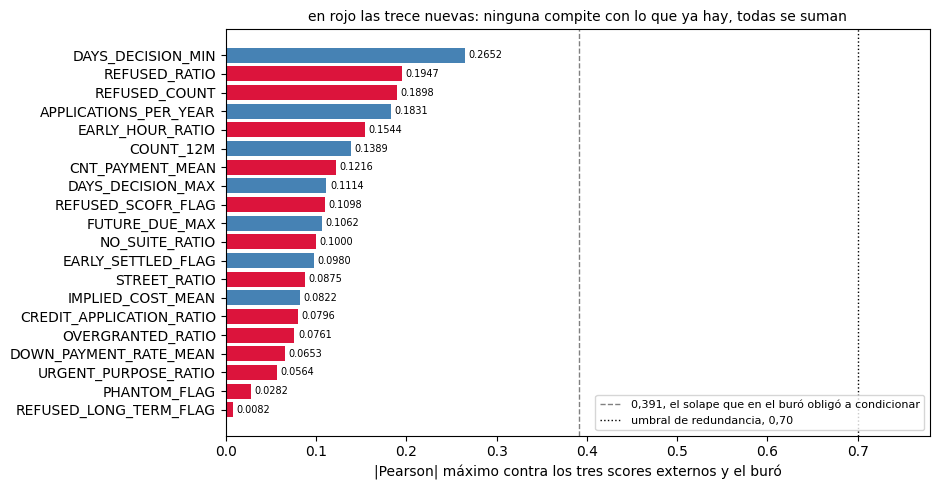

In [147]:
fig, ax = plt.subplots(figsize=(9.5, 5))
orden = solape.sort_values("|máximo|")
colores = [COLOR_DEF if c in NUEVAS else COLOR_NODEF for c in orden.index]
ax.barh([c.replace("PREV_", "") for c in orden.index], orden["|máximo|"], color=colores)
for i, v in enumerate(orden["|máximo|"]):
    ax.text(v + 0.004, i, f"{v:.4f}", va="center", fontsize=7)
ax.axvline(0.391, color="gray", ls="--", lw=1,
           label="0,391, el solape que en el buró obligó a condicionar")
ax.axvline(0.70, color="black", ls=":", lw=1, label="umbral de redundancia, 0,70")
ax.set(xlabel="|Pearson| máximo contra los tres scores externos y el buró", xlim=(0, 0.78))
ax.set_title("en rojo las trece nuevas: ninguna compite con lo que ya hay, todas se suman",
             fontsize=10)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

El relleno con cero apenas mueve nada en esta tabla, y eso también es un resultado. Exagera la señal
en nueve de las trece y la enmascara en cuatro, y los dos sesgos mayores no son los que habría
apostado: 0,0240 en la finalidad urgente y 0,0128 en la entrada, los dos enmascarando. Las dos
comparten mecanismo, que es vivir en un subconjunto de la cartera: la finalidad solo existe donde el
cliente la declara y la entrada solo donde hay crédito al consumo, así que rellenar con cero no mete
ahí a quien no ha pedido nunca, sino a quien no tiene ese campo, y eso aplana la pendiente en vez de
regalarla. Entre las banderas el mayor sesgo es el del motivo del rechazo, con +1,84pp, y responde
al mismo mecanismo llevado al extremo, porque su población de medición es la más estrecha de todas.
Las dos escalas no se comparan entre sí, así que ese sesgo se lee aparte del de las continuas.
Frente al buró, donde este control llegó a cambiar decisiones, aquí sigue sin alterar el
orden de nada.

De los 351 pares entre las veintisiete candidatas con varianza, ocho cruzan 0,70 y cinco son la misma
variable escrita de dos formas: el trío de la liquidación anticipada, la media con el máximo del
coste implícito y el conteo de doce meses con su bandera. Los otros tres son el ratio con el conteo
de rechazos, ya resuelto a favor del ratio, el conteo de solicitudes con el de rechazos y el conteo
de solicitudes con el de los últimos doce meses. Entre las siete banderas el máximo de V de Cramér es
0,3195, muy por debajo del umbral, así que ninguna pareja de banderas sobra.

El umbral de 0,70 tiene el defecto de todos los umbrales, que es dejar pasar sin mirar lo que se
queda justo debajo. Entre 0,60 y 0,70 hay **cinco** pares, y los paso todos por los estratos
cruzados, que es como resolví los que sí lo cruzan. El patrón se repite en los cinco: una domina y la
otra se desinfla sin llegar a anularse. El ratio de concesión se come a la sobreconcesión (0,6502) y
a la entrada media (0,6448), que caen a un máximo de 0,0649 y 0,0430 dentro de sus estratos mientras
él aguanta por encima de 0,08 en casi todos; el coste implícito se come al plazo medio (0,6133), que
baja a 0,0612 como mucho mientras el coste no baja de 0,1040; y el conteo de solicitudes con su
bandera de cola (0,6334) es la misma relación de fuente y corte que ya está resuelta por diseño.
Ninguno de esos cuatro mueve el ranking, porque en cada uno la dominada conserva lectura de negocio
propia y un residuo que no es ruido, así que las conservo todas y dejo el desempate a la capacidad
predictiva sobre el conjunto de entrenamiento.

El quinto sí lo mueve, y es el de la actividad de los últimos doce meses con el ritmo de solicitudes
por año, que dan 0,6702. Ahí el resultado no admite mucha discusión. El ritmo aguanta dentro de los cuatro tramos de actividad
reciente y encima crece, del 0,0411 de quien no ha pedido nada en el año al 0,1759 de quien acumula
cuatro o más, de modo que en tres de los cuatro rinde por encima de su propio 0,1149. La actividad
reciente hace lo contrario dentro de los tramos de ritmo: 0,0115, 0,0231, 0,0291, 0,0329 y 0,0187, y
en el primero y el último ni siquiera alcanza significancia. Fijado el ritmo, saber cuántas
solicitudes ha hecho alguien en el último año no añade nada.

Parte de esa diferencia es mecánica y conviene decirla: la actividad reciente está a cero en el
42,04% de los clientes con previas y los empates aplastan el rank-biserial, mientras que el ritmo no
tiene ceros porque su denominador es la ventana observada. Es el mismo efecto que hundía el conteo
del motivo de rechazo, en versión suave.

Así que el eje se lo lleva el ritmo, y la actividad reciente baja a ser lo que siempre fue por
debajo, el material del que sale su bandera. Pero la bandera no se cae con ella, y aquí está el
matiz que no esperaba. Como efecto propio tampoco aporta sobre el ritmo, con +0,05, -0,51, -0,91 y
+0,77pp dentro de sus cuatro tramos, ninguno cerca del umbral de dos puntos y dos de ellos con el
signo cambiado. Lo que sí es suyo es la interacción con la relación larga: cruzada con ella da
+1,61pp de superaditividad, y el mismo cruce hecho con un corte de ritmo de cobertura parecida se
queda en +0,40pp. La bandera se queda, por tanto, no como predictor por derecho propio sino como el
término de esa interacción, que es lo único que el ritmo no absorbe. Y como todo esto se decide
contra el objetivo sobre la cartera completa, el descarte de la continua es provisional y hay que
reconfirmarlo, al contrario que los de redundancia estructural.

El cruce contra lo que ya tengo aguanta con las veintiocho dentro: el solape máximo sigue siendo
0,2652, entre la longitud de relación y la antigüedad del historial del buró, que miden lo mismo por
dos caminos, y de las trece nuevas la que más se acerca es el ratio de rechazo con 0,1947 contra el
tercer score externo. Sigue muy lejos del 0,391 que en el buró obligó a exigirle a las temporales que
demostraran valor por encima del score. Esta tabla no compite con lo que ya hay, se suma.

De las trece, doce se conservan y una queda degradada a denominador, que es el conteo de rechazos.
Las tres más fuertes son proporciones de la relación entre cifras del contrato y no magnitudes, con
lo concedido frente a lo pedido a la cabeza, y eso repite por tercera vez el patrón de esta tabla: el
tamaño de la operación describe al cliente solvente y lo que marca riesgo es la relación entre lo que
pide, lo que le dan y a qué precio.

Quedan cuatro cosas abiertas. El mínimo de denominador del ratio de rechazo hay que fijarlo con la
disyuntiva ya medida delante, 0,1204 con cobertura total frente a 0,1558 cubriendo el 81,95%. Los
cortes medidos aquí, las quince solicitudes, las cuatro en doce meses, el año de adelanto, las
sesenta cuotas y el nuevo diez por ciento de exceso, se refijan sobre el conjunto de entrenamiento.
Todas las tasas de default están calculadas sobre la cartera completa y hay que recomputarlas sobre
ese mismo conjunto. Y las tres variables de captación entran condicionadas a que la última solicitud
sea reciente, porque fuera de esa ventana no discriminan.

In [148]:
# cierre de la sección: familia de contrastes y comprobación de que el acumulador quedó como toca
familia_10 = (len(ev_cli.fb_comparisons) - familia_base + len(ev_ctrl.fb_comparisons)
              + 4 + 4 + 3 + 9   # denominador mínimo, recencia, recorte y estratos cruzados
              + 12              # barrido del corte de sobreconcesión, en sus dos codificaciones
              + 12              # las tres de captación dentro de cada ventana
              + 4 + 2           # finalidad urgente, entrada y los dos marcadores raros
              + 26              # la tabla del control de composición
              + 2 + 2 + 7)      # media frente a máximo, el denominador de uno y el motivo
print(f"familia de {familia_10} contrastes en la sección, alfa de Bonferroni {0.05 / familia_10:.2e}")

registradas = [e["feature"] for e in ev_cli.fb_flags + ev_cli.fb_cont]
assert len(registradas) == 28, f"el acumulador tiene {len(registradas)} features y no 28"
assert len(set(registradas)) == 28, "hay una feature registrada dos veces"
assert set(NUEVAS) <= set(registradas), "alguna de las trece no llegó al acumulador"
previas = [e for e in ev_cli.fb_flags + ev_cli.fb_cont if e["feature"] not in NUEVAS]
assert len(previas) == 15, "las quince anteriores no siguen enteras"
print(f"acumulador de cliente: {len(registradas)} features, las 15 anteriores intactas y las 13 "
      "nuevas añadidas al final")
print("poblaciones de medición de las quince anteriores: "
      + ", ".join(sorted({e["poblacion"] for e in previas})))

familia de 120 contrastes en la sección, alfa de Bonferroni 4.17e-04
acumulador de cliente: 28 features, las 15 anteriores intactas y las 13 nuevas añadidas al final
poblaciones de medición de las quince anteriores: con operación terminada, con previas, global, no nulos (auto-cond.)


### 11. Conclusiones y features candidatas

In [149]:
# ranking consolidado a nivel cliente: una decisión por feature, sobre la población en que se midió
ESTADO = {
    "HAS_PREV_APPLICATION": "conservar (control y protectora)",
    "PREV_HISTORIAL_RECORTADO": "conservar (protectora y control)",
    "PREV_COUNT_COLA": "conservar (corte medido en 15)",
    "PREV_ACTIVIDAD_12M_COLA": "conservar (solo en la interacción con la longitud)",
    "PREV_EARLY_SETTLED_FLAG": "conservar (o tramos de conteo)",
    "PREV_PHANTOM_FLAG": "conservar (severidad)",
    "PREV_REFUSED_LONG_TERM_FLAG": "conservar (severidad)",
    "PREV_CREDIT_APPLICATION_RATIO": "conservar (1er orden, la media)",
    "PREV_IMPLIED_COST_MEAN": "conservar (1er orden, en seis tramos)",
    "PREV_REFUSED_RATIO": "conservar (1er orden)",
    "PREV_OVERGRANTED_RATIO": "conservar (1er orden, corte 1,1)",
    "PREV_APPLICATIONS_PER_YEAR": "conservar (1er orden)",
    "PREV_DAYS_DECISION_MIN": "conservar (con el recorte al lado)",
    "PREV_REFUSED_COUNT": "denominador del ratio",
    "PREV_STREET_RATIO": "conservar (con la recencia al lado)",
    "PREV_IMPLIED_COST_MAX": "descartar (redundancia con la media)",
    "PREV_FUTURE_DUE_MAX": "conservar (la magnitud, no la presencia)",
    "PREV_DOWN_PAYMENT_RATE_MEAN": "conservar (continua monótona)",
    "PREV_CNT_PAYMENT_MEAN": "conservar",
    "PREV_NO_SUITE_RATIO": "conservar (la mitad alta)",
    "PREV_REFUSED_SCOFR_FLAG": "conservar (el motivo del rechazo)",
    "PREV_COUNT_12M": "fuente de la bandera de actividad",
    "PREV_EARLY_HOUR_RATIO": "IV (banda débil)",
    "PREV_DAYS_DECISION_MAX": "IV (banda débil)",
    "PREV_EARLY_SETTLED_RATIO": "descartar (redundancia con la bandera)",
    "PREV_EARLY_SETTLED_COUNT": "descartar (redundancia con la bandera)",
    "PREV_URGENT_PURPOSE_RATIO": "conservar (sobre finalidad declarada)",
    "PREV_APPLICATION_COUNT": "denominador de ratios",
}

n_feat = len(ev_cli.fb_flags) + len(ev_cli.fb_cont)   # familia válida: una decisión por feature
alpha = 0.05 / n_feat
alpha_consv = 0.05 / len(ev_cli.fb_comparisons)       # todas las emitidas, referencia conservadora


def consolidar(acumulador):
    """tabla de decisión: efecto, significancia tras Bonferroni y estado de cada feature."""
    d = pd.DataFrame(acumulador).copy()
    d["sig"] = d["p"] < alpha
    d["estado"] = d["feature"].map(ESTADO)
    assert d["feature"].is_unique, "feature duplicada en el acumulador"
    assert d["estado"].notna().all(), f"sin estado: {d.loc[d.estado.isna(), 'feature'].tolist()}"
    return d.sort_values("efecto", key=abs, ascending=False)


rank_flags, rank_cont = consolidar(ev_cli.fb_flags), consolidar(ev_cli.fb_cont)
rank_flags["practico"] = rank_flags["efecto"].abs() > 2
assert n_feat == 28 and len(rank_flags) == 8 and len(rank_cont) == 20, "el ranking no cubre las 28"
assert set(ESTADO) == set(rank_flags["feature"]) | set(rank_cont["feature"]), "ESTADO no cuadra"

print(f"features únicas: {n_feat} (familia válida) | comparaciones emitidas por el acumulador de "
      f"cliente: {len(ev_cli.fb_comparisons)}")
print(f"Bonferroni: alfa = {alpha:.2e} (familia válida) | {alpha_consv:.2e} (conservador)")
print("los efectos no son comparables entre poblaciones distintas: 'poblacion' dice sobre quién se")
print("midió cada uno, y lo que decide es el tamaño del efecto más el umbral de 2pp, no el p-valor")

COLS = ["feature", "tipo", "poblacion", "efecto", "p", "n_pos", "sig"]
print("\nBanderas, por delta de default en pp ('practico' = cruza el umbral práctico de 2pp):")
display(rank_flags[COLS + ["practico", "estado"]].style.hide(axis="index").format(
    {"efecto": "{:+.2f} pp", "p": "{:.2e}"}))
print("Continuas, por rank-biserial (menos de 0,10 pequeño, de 0,10 a 0,30 moderado):")
display(rank_cont[COLS + ["estado"]].style.hide(axis="index").format(
    {"efecto": "{:.4f}", "p": "{:.2e}"}))

todas = pd.concat([rank_flags, rank_cont])
no_pasan = todas.query("not sig")["feature"].tolist()
print(f"no superan Bonferroni: {no_pasan if no_pasan else 'ninguna, las 28 son significativas'}")
familia = lambda e: ("conservar" if e.startswith("conservar") else
                     "IV" if e.startswith("IV") else
                     "descartar" if e.startswith("descartar") else "degradada")
print("balance de decisiones: " + " | ".join(f"{k} {v}" for k, v in
                                             todas["estado"].map(familia).value_counts().items()))

# los ocho pares por encima de 0,70 no pueden quedarse sin resolver: cada uno tiene que decir
# quién entra y quién se cae, y sale del propio estado asignado arriba, no de una lista aparte
resueltos = pd.DataFrame([{"par": f"{a} y {b}", "Pearson": round(r, 4),
                           "decisión de la primera": ESTADO[a],
                           "decisión de la segunda": ESTADO[b]} for a, b, r in altos])
print("\nLos ocho pares redundantes, resueltos:")
display(resueltos.style.hide(axis="index"))

features únicas: 28 (familia válida) | comparaciones emitidas por el acumulador de cliente: 47
Bonferroni: alfa = 1.79e-03 (familia válida) | 1.06e-03 (conservador)
los efectos no son comparables entre poblaciones distintas: 'poblacion' dice sobre quién se
midió cada uno, y lo que decide es el tamaño del efecto más el umbral de 2pp, no el p-valor

Banderas, por delta de default en pp ('practico' = cruza el umbral práctico de 2pp):


feature,tipo,poblacion,efecto,p,n_pos,sig,practico,estado
PREV_REFUSED_LONG_TERM_FLAG,flag,con previas,+13.61 pp,1.18e-05,78,True,True,conservar (severidad)
PREV_PHANTOM_FLAG,flag,con previas,+11.54 pp,1.38e-12,284,True,True,conservar (severidad)
PREV_REFUSED_SCOFR_FLAG,flag,con algún rechazo,+9.83 pp,8.09e-146,6788,True,True,conservar (el motivo del rechazo)
PREV_HISTORIAL_RECORTADO,flag,con previas,-3.06 pp,2.46e-121,53934,True,True,conservar (protectora y control)
PREV_COUNT_COLA,flag,con previas,+2.97 pp,4.07e-25,9422,True,True,conservar (corte medido en 15)
PREV_ACTIVIDAD_12M_COLA,flag,con previas,+2.41 pp,1.10e-66,45771,True,True,conservar (solo en la interacción con la longitud)
HAS_PREV_APPLICATION,flag,global,+2.24 pp,1.24e-24,291057,True,True,conservar (control y protectora)
PREV_EARLY_SETTLED_FLAG,flag,con operación terminada,+2.19 pp,1.63e-57,47682,True,True,conservar (o tramos de conteo)


Continuas, por rank-biserial (menos de 0,10 pequeño, de 0,10 a 0,30 moderado):


feature,tipo,poblacion,efecto,p,n_pos,sig,estado
PREV_CREDIT_APPLICATION_RATIO,continua,con previas,0.1458,7.81e-305,290042,True,"conservar (1er orden, la media)"
PREV_IMPLIED_COST_MEAN,continua,no nulos (auto-cond.),0.1334,8.91e-252,287433,True,"conservar (1er orden, en seis tramos)"
PREV_REFUSED_RATIO,continua,con previas,0.1204,3.32e-290,291057,True,conservar (1er orden)
PREV_OVERGRANTED_RATIO,continua,con previas,0.1194,1.34e-232,290042,True,"conservar (1er orden, corte 1,1)"
PREV_APPLICATIONS_PER_YEAR,continua,no nulos (auto-cond.),0.1149,1.40e-190,291057,True,conservar (1er orden)
PREV_DAYS_DECISION_MIN,continua,no nulos (auto-cond.),0.1129,4.76e-184,291057,True,conservar (con el recorte al lado)
PREV_REFUSED_COUNT,continua,con previas,0.1122,6.87e-254,291057,True,denominador del ratio
PREV_STREET_RATIO,continua,con previas,0.0924,5.11e-167,291057,True,conservar (con la recencia al lado)
PREV_IMPLIED_COST_MAX,continua,no nulos (auto-cond.),0.0852,4.62e-104,287433,True,descartar (redundancia con la media)
PREV_FUTURE_DUE_MAX,continua,no nulos (auto-cond.),0.0842,4.67e-54,147954,True,"conservar (la magnitud, no la presencia)"


no superan Bonferroni: ninguna, las 28 son significativas
balance de decisiones: conservar 20 | degradada 3 | descartar 3 | IV 2

Los ocho pares redundantes, resueltos:


par,Pearson,decisión de la primera,decisión de la segunda
PREV_IMPLIED_COST_MEAN y PREV_IMPLIED_COST_MAX,0.861600,"conservar (1er orden, en seis tramos)",descartar (redundancia con la media)
PREV_EARLY_SETTLED_FLAG y PREV_EARLY_SETTLED_COUNT,0.858600,conservar (o tramos de conteo),descartar (redundancia con la bandera)
PREV_EARLY_SETTLED_FLAG y PREV_EARLY_SETTLED_RATIO,0.853900,conservar (o tramos de conteo),descartar (redundancia con la bandera)
PREV_EARLY_SETTLED_COUNT y PREV_EARLY_SETTLED_RATIO,0.784900,descartar (redundancia con la bandera),descartar (redundancia con la bandera)
PREV_COUNT_12M y PREV_ACTIVIDAD_12M_COLA,0.782600,fuente de la bandera de actividad,conservar (solo en la interacción con la longitud)
PREV_REFUSED_RATIO y PREV_REFUSED_COUNT,0.744700,conservar (1er orden),denominador del ratio
PREV_APPLICATION_COUNT y PREV_REFUSED_COUNT,0.726800,denominador de ratios,denominador del ratio
PREV_APPLICATION_COUNT y PREV_COUNT_12M,0.720700,denominador de ratios,fuente de la bandera de actividad


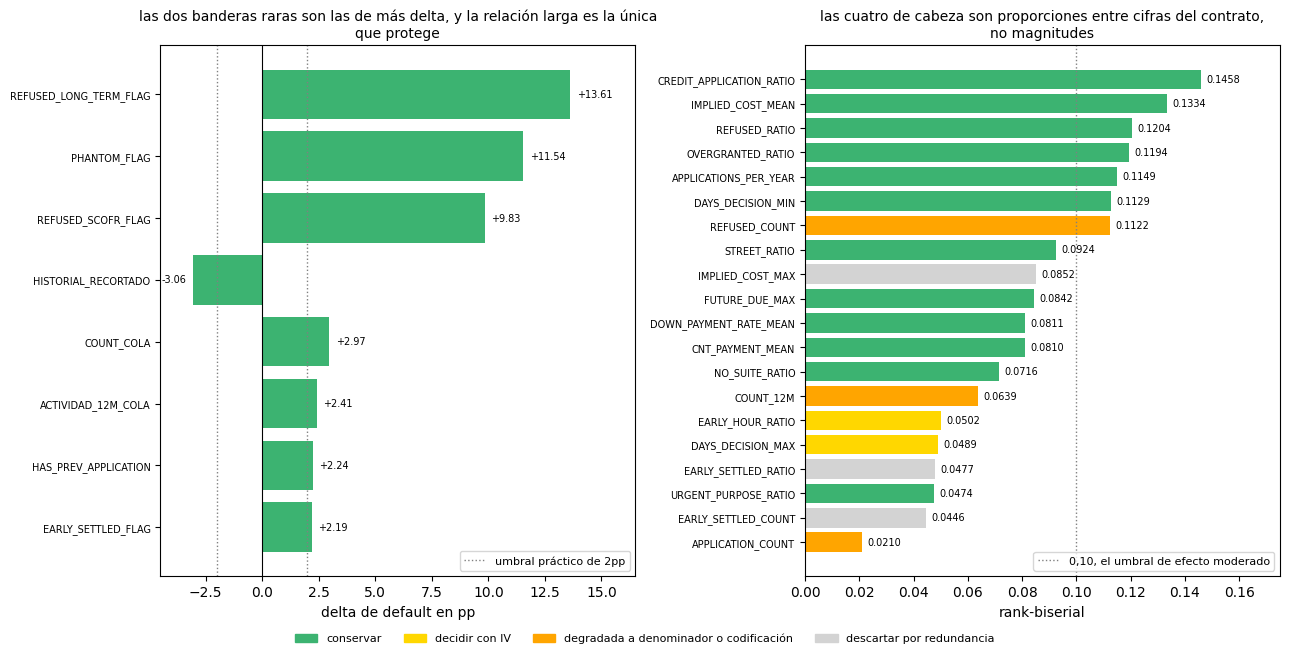

In [150]:
# el veredicto de un vistazo: se dibuja desde los mismos frames del ranking, así que la figura
# no puede decir una cosa distinta de la tabla
COLOR_ESTADO = {"conservar": "mediumseagreen", "IV": "gold", "degradada": "orange",
                "descartar": "lightgray"}
fig, ax = plt.subplots(1, 2, figsize=(13, 6.4))

izq = rank_flags.sort_values("efecto", key=abs)
ax[0].barh([re.sub(r"^PREV_", "", f) for f in izq["feature"]], izq["efecto"],
           color=[COLOR_ESTADO[familia(e)] for e in izq["estado"]])
for i, v in enumerate(izq["efecto"]):
    ax[0].text(v + (0.3 if v >= 0 else -0.3), i, f"{v:+.2f}", va="center", fontsize=7,
               ha="left" if v >= 0 else "right")
for x, etiq in ((-2, "umbral práctico de 2pp"), (2, None)):
    ax[0].axvline(x, color="gray", ls=":", lw=1, label=etiq)
ax[0].axvline(0, color="black", lw=0.8)
ax[0].set(xlabel="delta de default en pp", xlim=(-4.5, 16.5))
ax[0].legend(fontsize=8, loc="lower right")
ax[0].set_title("las dos banderas raras son las de más delta, y la relación larga es la única\n"
                "que protege", fontsize=10)

der = rank_cont.sort_values("efecto")
ax[1].barh([re.sub(r"^PREV_", "", f) for f in der["feature"]], der["efecto"],
           color=[COLOR_ESTADO[familia(e)] for e in der["estado"]])
for i, v in enumerate(der["efecto"]):
    ax[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=7)
ax[1].axvline(0.10, color="gray", ls=":", lw=1, label="0,10, el umbral de efecto moderado")
ax[1].set(xlabel="rank-biserial", xlim=(0, 0.175))
ax[1].set_title("las cuatro de cabeza son proporciones entre cifras del contrato,\nno magnitudes",
                fontsize=10)
ax[1].legend(fontsize=8, loc="lower right")

for a in ax:
    plt.setp(a.get_yticklabels(), fontsize=7)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_ESTADO.values()],
           labels=["conservar", "decidir con IV", "degradada a denominador o codificación",
                   "descartar por redundancia"],
           loc="lower center", ncol=4, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()

In [151]:
# la receta se exporta desde el ranking, así que no puede desincronizarse de las decisiones de arriba
# lleva la decisión y su justificación; cómo se construye cada feature es cosa del código de FE
import yaml
import src

receta = {
    "tabla": "previous_application",
    "nivel": "SK_ID_CURR (enlace directo, sin tabla puente)",
    "nota": ("cobertura del 94,65% de train, la más alta de las tres auxiliares. Quien no tiene "
             "solicitudes previas es de menor riesgo (5,96% frente a 8,19%), así que el relleno con "
             "cero infla lo que penaliza en lugar de enmascararlo. Cruces con TARGET sobre train "
             "completo: las dos que quedan a decidir por IV son provisionales y se reconfirman "
             "sobre el split; los tres descartes por redundancia estructural son firmes. Sobre el "
             "split hay que fijar el mínimo de denominador del ratio de rechazo (0,1204 con "
             "cobertura total frente a 0,1558 cubriendo el 81,95%) y refijar los cortes medidos "
             "aquí: las 15 solicitudes, las 4 en doce meses, el año de adelanto en la "
             "liquidación, las 60 cuotas y el 1,1 de sobreconcesión."),
    "features": {},
}
for d in (rank_flags, rank_cont):
    for _, r in d.iterrows():
        receta["features"][r["feature"]] = {
            "tipo": r["tipo"],
            "poblacion_medicion": r["poblacion"],
            "efecto": round(float(r["efecto"]), 4),
            "estado": r["estado"],
        }

out = Path(src.__file__).resolve().parents[1] / "config" / "previous_application_features.yaml"
out.write_text(yaml.safe_dump(receta, allow_unicode=True, sort_keys=False))
print(f"receta escrita en {out.relative_to(Path.cwd().parent)} con {len(receta['features'])} features")

receta escrita en config/previous_application_features.yaml con 28 features


Cierro `previous_application` con veintiocho features medidas a nivel cliente y una decisión tomada para cada una. La pregunta que motivaba la tabla era si el comportamiento con el propio prestamista aporta algo que el buró no ve, y la respuesta es que sí, por un motivo que ninguna otra fuente puede cubrir: el buró registra la deuda que el cliente tiene fuera, y aquí queda registrado qué le contestó esta casa, a qué precio se lo concedió y por qué le dijo que no. El solape máximo de todas las candidatas contra los tres `EXT_SOURCE` y contra lo que conservo del buró es 0,2652, y lo pone la longitud de relación contra la antigüedad del historial en el buró, que miden lo mismo por dos caminos. De las trece últimas en construirse la que más se acerca es la proporción de rechazos, con 0,1947 contra `EXT_SOURCE_3`, lejos del 0,391 que en el buró me obligó a exigirle a las temporales que demostraran aportación por encima del score. Aquí no hace falta esa condición y ninguna candidata se cae por redundancia con lo que ya tengo.

Con las veintiocho, el umbral de Bonferroni queda en 1,79e-03 y lo superan todas. Es la primera de las tres tablas auxiliares donde la corrección múltiple no descarta nada, y no es mérito de las features sino del tamaño de la cartera: con 291.057 clientes, hasta el conteo de solicitudes, que rinde 0,0210 y no pienso usar como predictor, sale con p = 5,80e-08. Por eso quien decide aquí es el tamaño del efecto y el umbral práctico de 2pp, y el p-valor no descarta ni rescata a nadie.

Las cuatro señales de cabeza son proporciones entre cifras del contrato y ninguna es una magnitud. Lo concedido frente a lo pedido rinde 0,1458 y ordena el riesgo del 6,45% de quien de media recibe menos de lo que solicita al 16,00% de quien recibe más de un 30% de más. Detrás van el coste implícito medio con 0,1334, la proporción de rechazos con 0,1204 y la sobreconcesión con 0,1194. Es la tercera vez que la tabla dice lo mismo por un camino distinto: a nivel solicitud ninguna de las nueve magnitudes llegaba a 0,09 sobre dato real, y en la cola de lo solicitado el importe grande describía al cliente solvente y no al arriesgado. Aquí el tamaño de la operación no es el riesgo, lo es la relación entre lo que se pide, lo que se concede y lo que se acaba devolviendo.

En las banderas la señal vive en lo raro y severo, que es exactamente lo que no quiero perder. Pedir más de 60 cuotas y no obtenerlas da +13,61pp sobre 78 clientes, el 0,027% de los que tienen previas, y el registro que no llegó a definirse ni en tipo ni en producto da +11,54pp sobre 284, el 0,098%. Las dos superan Bonferroni con p = 1,18e-05 y p = 1,38e-12 pese a marcar a poca gente, que son los p del z-test con el que el ranking mide todas las banderas por igual; con Fisher, que es el que corresponde a celdas tan pequeñas y el que uso al mirarlas de cerca, quedan en 1,63e-04 y 7,78e-10 y las dos siguen pasando. Y las dos tienen el perfil del sobregiro del buró: severidad extrema con impacto de cartera mínimo. Detrás entra el rechazo por scoring externo con +9,83pp, que ya no es un marcador de nicho porque toca al 6,77% de quien acumula algún rechazo, y que solo aparece con esa fuerza si se codifica como bandera. La única bandera protectora es el historial recortado, con -3,06pp, y su lectura de negocio importa más que su cifra, porque el cliente de relación larga (5,70%) tiene prácticamente el mismo riesgo que quien nunca ha pasado por aquí (5,96%) y el riesgo se concentra en el de relación corta y enteramente visible (8,76%). No es que ver menos historial proteja, es que llevar años siendo cliente protege.

Ocho pares de los 351 posibles cruzan el umbral de redundancia de 0,70 y ninguno queda sin resolver. Cinco son la misma variable escrita de dos formas: el trío de la liquidación anticipada (de 0,7849 a 0,8586), donde se queda la bandera porque el conteo y la proporción rinden 0,0446 y 0,0477 frente a sus +2,19pp; las dos agregaciones del coste implícito (0,8616), donde gana la media porque el coste no es un suceso que ocurre una vez sino un rasgo del perfil de contratación; y el conteo de los últimos doce meses con su bandera de cola (0,7826). Los otros tres se resuelven a favor de la proporción o de la ventana reciente: el ratio de rechazo frente a su conteo (0,7447), el conteo total frente al de rechazos (0,7268) y el conteo total frente al de doce meses (0,7207). Entre las siete banderas el máximo de V de Cramér es 0,3195, muy por debajo de 0,50, así que ninguna pareja de banderas sobra. Y como un umbral deja pasar sin mirar lo que se le queda justo debajo, paso también por los estratos cruzados los cinco pares entre 0,60 y 0,70. En cuatro la dominada conserva lectura propia y un residuo que no es ruido, así que las mantengo todas y dejo el desempate a la capacidad predictiva: el ratio de concesión domina a la sobreconcesión y a la entrada media, el coste implícito domina al plazo medio, y el conteo de solicitudes con su bandera de cola es la misma relación de fuente y corte que ya estaba resuelta. El quinto es el que sí decide algo.

Ese último grupo obliga a un cambio respecto a lo que venía anticipando, y acaba siendo el contrario del que esperaba. La bandera de cuatro o más solicitudes en doce meses y su continua solapan 0,7826, así que una de las dos sobra, y durante un tiempo di por hecho que la que entraba era la continua troceada. Lo que decide de verdad es un tercer nombre: el ritmo de solicitudes por año, que solapa 0,6702 con la continua y se la come entera en estratos cruzados, porque el ritmo aguanta dentro de los cuatro tramos de actividad reciente creciendo de 0,0411 a 0,1759 mientras la actividad reciente se queda entre 0,0115 y 0,0329 dentro de los tramos de ritmo, sin significancia en dos de los cinco. La continua baja entonces a ser la fuente de la bandera, y la bandera se queda por un motivo distinto del que tenía escrito: no por sus +2,41pp, que tampoco sobreviven al ritmo (+0,05, -0,51, -0,91 y +0,77pp dentro de sus tramos), sino porque es el término de la única interacción que se sostiene, la de la relación corta con mucha actividad, con +1,61pp de superaditividad frente a los +0,40pp que da el mismo cruce montado sobre el ritmo. El conteo total de solicitudes y el de rechazos bajan a denominador por el mismo motivo, y conviene decir que ese par cruza 0,70 entre sí sin que eso decida nada, porque ninguno de los dos entra como predictor.

Lo que conservo tiene que entrar con la codificación que cada una pide, y no es la misma para todas:

- El coste implícito en seis tramos y no en uno. El tramo de más de 1,4 declaraba un 11,53% y dentro convivían un 11,43% sobre 60.783 clientes y un 18,19% sobre 907.
- La sobreconcesión con el corte en 1,1, que es donde el barrido pone el máximo (0,1194, frente a 0,0455 en el 1,3 que traía heredado del binning y 0,0094 en 1,5). Como bandera el delta crece con el corte simplemente porque marca a menos gente, y decidir por ahí habría tirado dos tercios de la señal.
- El motivo del rechazo como bandera y nunca como conteo, y por eso al ranking va la bandera. Contado está a cero en el 97,67% de los clientes y los empates aplastan el rank-biserial hasta 0,0351; como bandera, medida dentro de quien acumula algún rechazo, vale +9,83pp, y dentro de cada tramo de conteo de rechazos tener alguno por scoring externo suma +6,53pp con un rechazo, +7,85pp con dos o tres y +12,23pp con cuatro o más.
- La finalidad urgente como proporción sobre quien declara finalidad, no como conteo sobre todas las solicitudes: 0,0474 frente a 0,0241, porque media cartera no tiene ese campo y contarla sobre todas diluye el denominador.
- La entrada como continua monótona, del 9,37% de quien nunca pone dinero al 6,05% de quien de media pone más de un quinto del precio. La estructura de tres niveles que era obligatoria por operación no sobrevive al agregar, porque el cero de cliente no es una operación suelta sin entrada sino alguien que nunca la pone, con el 99,47% de sus operaciones de consumo sin ella.
- Los ausentes como tramo propio y nunca imputados. No tener longitud de relación ni ritmo es no haber pedido nunca aquí, que es el grupo más protector de todos con 5,96%; no tener nada por vencer es no deber nada hoy a esta casa; y no tener coste implícito es no haber llegado a formalizar. Los tres son hechos y una mediana inventaría una relación que no existió.
- Las tres de captación con la recencia al lado. La proporción captada en la calle rinde 0,1303 en quien pidió hace de seis a doce meses y 0,0080 en quien no pide desde hace más de dos años, así que fuera de ventana reciente no dice nada.

Del lado de la calidad del dato no queda nada que revertir. Las dos únicas incoherencias de orden entre fechas, las 273 operaciones que cierran antes de su última cuota (0,042%) y las 6 que disponen antes de la decisión, caen enteras dentro de las dos columnas que ya se caen por otro motivo, la terminación por ser el último vencimiento más una semana de trámite y la primera disposición por ser la decisión con otro nombre. Ninguna de las dos alimenta una variable de cliente, así que el único arreglo por validez de dominio de toda la tabla siguen siendo las dos entradas negativas llevadas a cero.

Los descartes prefiero separarlos por firmeza, porque no todos valen lo mismo. Firmes y target-independientes los tres de redundancia estructural, que son el máximo del coste contra su media y el conteo y la proporción de liquidación anticipada contra su bandera. Provisionales los dos que dejo a decidir por capacidad predictiva, la hora temprana (0,0502) y la recencia de la última solicitud (0,0489), que reconfirmaré sobre el conjunto de entrenamiento antes de eliminarlos de verdad. Conservar de más es barato y eliminar mirando toda la etiqueta no lo es. De la recencia de la última solicitud conviene precisar qué se está decidiendo, porque no es si se queda sino si entra como predictor: como control se queda igual, ya que ni la proporción de rechazos ni las tres de captación se pueden leer sin ella, que es la misma relación que tienen la longitud de relación y la marca de historial recortado.

Hay cinco cosas más que medí y que no llegan al ranking, y las dejo dichas para que no parezcan olvido. La trayectoria de rechazo rinde 0,0777 frente al 0,1604 de la simple proporción en su misma población, así que lo que marca es cuántos rechazos acumula alguien y no si se concentran al final. La completitud agregada correlaciona 0,9205 con la tasa de aprobación y rinde menos, o sea que es la aprobación por el reverso. La proporción de canceladas no mide comportamiento sino recencia (0,3937), porque la cancelación desaparece del registro pasados dos años. El conteo de contratos vivos se queda en 0,0118, muy lejos del conteo de créditos activos del buró, porque la exposición viva con el propio prestamista ya pasó por su filtro de riesgo. Y el máximo del ratio de concesión rinde 0,1161 frente al 0,1458 de la media.

Sobre los perfiles de riesgo, esta tabla es la que más aporta al de búsqueda activa de financiación y lo confirma con sus marcadores más operativos: el rechazo acumulado, que ordena el riesgo del 7,07% de quien nunca ha recibido un no al 17,79% de quien acumula más de tres cuartas partes de rechazos, con el motivo por scoring externo encima; el ritmo de solicitudes por año, que rinde 0,1149 y aguanta dentro de los cinco tramos de longitud de relación; la liquidación anticipada, que resulta ser refinanciación encadenada y no buen comportamiento, porque el 55,80% de quien liquida con más de un año de adelanto tiene otra solicitud pegada al cierre frente al 38,91% del resto; y la sobreconcesión. Lo matiza en tres puntos que conviene no pasar por alto. La recencia de la última solicitud aquí no pertenece al perfil (0,0489 frente al 0,1606 de su equivalente del buró), porque una operación recién aprobada acaba de pasar el filtro de riesgo de la casa mientras que una consulta reciente al buró es exposición que el prestamista no vio. Quien entra solo por la calle tampoco es el peor, con 11,10% frente al 13,58% de quien alterna la calle con la venta cruzada, lo que encaja con que sea un cliente de un único producto y no alguien buscando financiación por todas las vías. Y apilar sus marcadores rinde menos que la suma: coste alto con sobreconcesión alta da 12,88% cuando lo aditivo predice 14,70%, o sea -1,82pp, porque en buena parte marcan a la misma gente. La interacción solo paga cuando cruza dos perfiles distintos, como la relación corta con mucha actividad reciente, que sí se refuerza con +1,61pp.

De los demás perfiles, el de cliente premium queda confirmado por un camino nuevo, que es poner dinero propio en la operación, y el de joven sin historial queda matizado en algo que importa para no extenderlo de más: no haber pedido nunca aquí da 5,96% de default, por debajo de la base, así que es protector y no pertenece a ese perfil, al revés que la opacidad del buró, que da 10,12%. Del deudor con mora activa y de la familia numerosa esta tabla no dice nada, y prefiero dejarlo escrito a que se lea como si hubiera mirado y no hubiera encontrado.

De las veintiocho, veinte se conservan, tres bajan a denominador o a codificación de otra, tres se descartan por redundancia estructural y dos quedan a decidir por capacidad predictiva. Las tres cosas que quedan abiertas y hay que resolver con los datos de entrenamiento delante son el mínimo de denominador de la proporción de rechazos, que es una disyuntiva ya medida entre 0,1204 cubriendo a todos y 0,1558 cubriendo al 81,95% (los 52.533 clientes de una sola solicitud son el 18,05% y su ratio, que solo puede valer 0% o 100%, da +1,63pp con p = 0,35); los cortes medidos aquí, que son las 15 solicitudes, las 4 en doce meses, el año de adelanto en la liquidación, las 60 cuotas y el 1,1 de la sobreconcesión; y todas las tasas de default de este análisis, calculadas sobre train completo. Con eso queda cerrado el trabajo exploratorio de las cuatro tablas del alcance.